In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from scipy import stat
import os

# Paths
BASE_PATH = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/'
DATAFRAMES_DIR = os.path.join(BASE_PATH, '1-dataframes')
FIGURE_PATH = os.path.join(BASE_PATH, '2-graphs', '2-ABT_80-20_performance')
os.makedirs(FIGURE_PATH, exist_ok=True)

# Load filtered dataset
df = pd.read_csv(os.path.join(DATAFRAMES_DIR, 'filtered_df_Reversal_80-20_2-ABT_100.csv'))

print(f"Loaded {len(df):,} trials from {df['Session_ID'].nunique()} sessions")
print(f"Animals: {sorted(df['Animal_Name'].unique())}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Loaded 36,673 trials from 100 sessions
Animals: ['Fiona', 'Knuckles', 'Sonic', 'Sunflower', 'Zazu']
Date range: 2022-04-25 to 2024-03-25


In [15]:
print(f"Loaded {len(df):,} trials from {df['Session_ID'].nunique()} sessions")
print(f"Animals: {sorted(df['Animal_Name'].unique())}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Loaded 36,673 trials from 100 sessions
Animals: ['Fiona', 'Knuckles', 'Sonic', 'Sunflower', 'Zazu']
Date range: 2022-04-25 to 2024-03-25


In [16]:
# Font Preferences and graph styles
# ============================================================================

import matplotlib.pyplot as plt

# Global font and line settings
FONTSIZE = 8
LINE_WIDTH = 0.5
TICK_LENGTH = 2

# Apply to matplotlib rcParams
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = FONTSIZE
plt.rcParams['axes.linewidth'] = LINE_WIDTH
plt.rcParams['xtick.major.width'] = LINE_WIDTH
plt.rcParams['ytick.major.width'] = LINE_WIDTH
plt.rcParams['xtick.major.size'] = TICK_LENGTH
plt.rcParams['ytick.major.size'] = TICK_LENGTH
plt.rcParams['lines.linewidth'] = LINE_WIDTH
plt.rcParams['svg.fonttype'] = 'none'  # Save text as text (not paths)

# STANDARD ANIMAL CONFIGURATION - USE IN ALL NOTEBOOKS
# ============================================================================

# Standard animal order (left to right in all plots)
ANIMAL_ORDER = [
    'Coral',
    'Tuna',
    'Fiona',
    'Salmon',
    'Knuckles',
    'Raven', 
    'Sonic',
    'Zazu',
    'Griffin',
    'Sunflower',

]

# Standard animal colors (matching your asymptotic performance figure)
ANIMAL_COLORS = {
    'Coral': '#e74c3c',      # Coral/Red
    'Raven': '#2ecc71',      # Green
    'Tuna': '#8b7355',       # Brown/Tan
    'Sonic': '#34495e',      # Dark Gray
    'Griffin': '#9b59b6',    # Purple
    'Sunflower': '#1abc9c',  # Teal/Cyan
    'Zazu': '#3498db',       # Light Blue
    'Salmon': '#f39c12',     # Orange/Yellow
    'Fiona':  '#e91e63',      # Pink/Magenta
    'Knuckles': '#e67e22'    # Orange/Brown
}

# Helper function to get colors in correct order
def get_ordered_colors(animals):
    """Return colors for given animals in standard order"""
    ordered_animals = [a for a in ANIMAL_ORDER if a in animals]
    return [ANIMAL_COLORS[a] for a in ordered_animals]

# Helper function to sort animals
def sort_animals(animal_list):
    """Sort animals according to standard order"""
    return sorted(animal_list, key=lambda x: ANIMAL_ORDER.index(x) if x in ANIMAL_ORDER else 999)

In [17]:
# CELL 3: Analyze Cued vs Uncued Transitions (FIXED)
# ============================================================================

print("Analyzing cued vs uncued transitions...\n")

# Look at sample session
sample_session = df['Session_ID'].iloc[0]
sample_df = df[df['Session_ID'] == sample_session].sort_values('Trial')

print(f"Sample session: {sample_session}")
print(f"  Animal: {sample_df['Animal_Name'].iloc[0]}")
print(f"  Total reversals: {sample_df['Num_Reversals'].iloc[0]}")
print(f"  Cued transitions: {sample_df['Num_Cued_Transitions'].iloc[0]}")

# Check transitions
blocks = sorted(sample_df['Block'].unique())
print(f"\nAnalyzing {len(blocks)-1} block transitions:")

for i in range(len(blocks)-1):
    curr_block = blocks[i]
    next_block = blocks[i+1]
    
    block_i_trials = sample_df[sample_df['Block'] == curr_block]
    block_i1_trials = sample_df[sample_df['Block'] == next_block]
    
    if len(block_i_trials) > 0 and len(block_i1_trials) > 0:
        block_i = block_i_trials.iloc[-1]
        block_i1 = block_i1_trials.iloc[0]
        
        print(f"\nBlock {curr_block} → Block {next_block}:")
        
        # Check if Target1_location exists
        if 'Target1_location' in df.columns:
            print(f"  Target1 location: {block_i['Target1_location']} → {block_i1['Target1_location']}")
            print(f"  Target2 location: {block_i['Target2_location']} → {block_i1['Target2_location']}")
            
            loc_changed = (block_i['Target1_location'] != block_i1['Target1_location'])
        else:
            print("  (Target locations not in dataset)")
            loc_changed = False
        
        # Check stimulus sources
        stim_changed = (block_i.get('TaskObject2_Source') != block_i1.get('TaskObject2_Source'))
        
        print(f"  Locations changed: {loc_changed}")
        print(f"  Stimuli changed: {stim_changed}")
        
        if loc_changed and stim_changed:
            transition_type = "CUED"
        elif not loc_changed and not stim_changed:
            transition_type = "UNCUED"
        else:
            transition_type = "PARTIAL"
        
        print(f"  → {transition_type} transition")

print("\n" + "="*70)
print("SUMMARY ACROSS ALL SESSIONS")
print("="*70)

# Count transition types across all sessions
all_transitions = []

for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial')
    blocks = sorted(session_df['Block'].unique())
    
    for i in range(len(blocks)-1):
        curr_block = blocks[i]
        next_block = blocks[i+1]
        
        block_i = session_df[session_df['Block'] == curr_block].iloc[-1]
        block_i1 = session_df[session_df['Block'] == next_block].iloc[0]
        
        if 'Target1_location' in df.columns:
            loc_changed = (block_i['Target1_location'] != block_i1['Target1_location'])
        else:
            loc_changed = False
        
        stim_changed = (block_i.get('TaskObject2_Source') != block_i1.get('TaskObject2_Source'))
        
        if loc_changed and stim_changed:
            transition_type = "CUED"
        elif not loc_changed and not stim_changed:
            transition_type = "UNCUED"
        else:
            transition_type = "PARTIAL"
        
        all_transitions.append({
            'session_id': session_id,
            'from_blockcount': curr_block,
            'to_blockcount': next_block,
            'transition_type': transition_type,
            'animal': session_df['Animal_Name'].iloc[0]
        })

trans_df = pd.DataFrame(all_transitions)

print(f"\nTotal transitions: {len(trans_df)}")
print(f"\nTransition types:")
print(trans_df['transition_type'].value_counts())

print(f"\nTransitions per session:")
print(f"  Mean: {len(trans_df) / df['Session_ID'].nunique():.1f}")
print(f"  Range: {trans_df.groupby('session_id').size().min()} - {trans_df.groupby('session_id').size().max()}")

print("="*70)

Analyzing cued vs uncued transitions...

Sample session: 2022-04-25_20220425_Fiona_Reversal3.1
  Animal: Fiona
  Total reversals: 1
  Cued transitions: 0

Analyzing 1 block transitions:

Block 5 → Block 6:
  Target1 location: BottomRight → BottomLeft
  Target2 location: BottomLeft → BottomRight
  Locations changed: True
  Stimuli changed: True
  → CUED transition

SUMMARY ACROSS ALL SESSIONS

Total transitions: 100

Transition types:
CUED    100
Name: transition_type, dtype: int64

Transitions per session:
  Mean: 1.0
  Range: 1 - 1


In [18]:
# Verify 2-ABT Task Structure
# ============================================================================

print("Verifying 2-ABT task structure...\n")
print("="*70)
print("Expected: Each session has exactly 2 blocks alternating back and forth")
print("="*70)

# Apply location categorization if needed
if 'Target1_location' not in df.columns or df['Target1_location'].isna().any():
    print("\nCategorizing locations...")
    df['Target1_location'] = df.apply(
        lambda row: categorize_location(row['TaskObject2_LocX'], row['TaskObject2_LocY']), 
        axis=1
    )
    df['Target2_location'] = df.apply(
        lambda row: categorize_location(row['TaskObject3_LocX'], row['TaskObject3_LocY']), 
        axis=1
    )

# Verify structure for each session
violations = []

for session_id in df['Session_ID'].unique():
    session_data = df[df['Session_ID'] == session_id].sort_values('Block')
    
    blocks = sorted(session_data['Block'].unique())
    n_blocks = len(blocks)
    
    # Get locations for each block
    block_locs = []
    for block in blocks:
        block_trials = session_data[session_data['Block'] == block]
        locs = set()
        locs.update(block_trials['Target1_location'].dropna().unique())
        locs.update(block_trials['Target2_location'].dropna().unique())
        locs.discard('LOCATION_NEEDED')
        block_locs.append(locs)
    
    # Check if only 2 unique location sets
    unique_loc_sets = []
    for loc_set in block_locs:
        if loc_set not in unique_loc_sets:
            unique_loc_sets.append(loc_set)
    
    n_unique_sets = len(unique_loc_sets)
    
    # Check if alternating
    alternating = True
    if n_unique_sets == 2:
        for i in range(len(block_locs) - 1):
            if block_locs[i] == block_locs[i+1]:
                alternating = False
                break
    
    # Record results
    if n_unique_sets != 2 or not alternating:
        violations.append({
            'session_id': session_id,
            'animal': session_data['Animal_Name'].iloc[0],
            'n_blocks': n_blocks,
            'n_unique_sets': n_unique_sets,
            'alternating': alternating,
            'location_sets': unique_loc_sets
        })
    
    # Print first few sessions
    if len(violations) + (session_id == df['Session_ID'].unique()[0]) <= 5:
        print(f"\nSession: {session_id}")
        print(f"  Animal: {session_data['Animal_Name'].iloc[0]}")
        print(f"  Blocks: {blocks}")
        print(f"  Unique location sets: {n_unique_sets}")
        print(f"  Location sets: {unique_loc_sets}")
        print(f"  Alternating: {alternating}")
        print(f"  ✓ Valid 2-ABT" if (n_unique_sets == 2 and alternating) else "  ✗ VIOLATION")

print("\n" + "="*70)
print("VERIFICATION SUMMARY")
print("="*70)

total_sessions = df['Session_ID'].nunique()
valid_sessions = total_sessions - len(violations)

print(f"\nTotal sessions: {total_sessions}")
print(f"Valid 2-ABT sessions: {valid_sessions} ({valid_sessions/total_sessions*100:.1f}%)")
print(f"Violations: {len(violations)} ({len(violations)/total_sessions*100:.1f}%)")

if len(violations) > 0:
    print("\n⚠️ VIOLATIONS FOUND:")
    for v in violations:
        print(f"\n  {v['session_id']} ({v['animal']}):")
        print(f"    {v['n_blocks']} blocks, {v['n_unique_sets']} unique location sets")
        print(f"    Alternating: {v['alternating']}")
        print(f"    Sets: {v['location_sets']}")
else:
    print("\n✓ All sessions are valid 2-ABT (2 location sets, alternating)")

print("="*70)

Verifying 2-ABT task structure...

Expected: Each session has exactly 2 blocks alternating back and forth

Session: 2022-04-25_20220425_Fiona_Reversal3.1
  Animal: Fiona
  Blocks: [5, 6]
  Unique location sets: 1
  Location sets: [{'BottomLeft', 'BottomRight'}]
  Alternating: True
  ✗ VIOLATION

Session: 2022-04-26_20220426_Fiona_Reversal3.1
  Animal: Fiona
  Blocks: [5, 6]
  Unique location sets: 1
  Location sets: [{'BottomLeft', 'BottomRight'}]
  Alternating: True
  ✗ VIOLATION

Session: 2022-05-02_20220502_Fiona_Reversal3.1
  Animal: Fiona
  Blocks: [5, 6]
  Unique location sets: 1
  Location sets: [{'BottomLeft', 'BottomRight'}]
  Alternating: True
  ✗ VIOLATION

Session: 2022-05-03_20220503_Fiona_Reversal3.1(1)
  Animal: Fiona
  Blocks: [5, 6]
  Unique location sets: 1
  Location sets: [{'BottomLeft', 'BottomRight'}]
  Alternating: True
  ✗ VIOLATION

Session: 2022-05-04_20220504_Fiona_Reversal3.1
  Animal: Fiona
  Blocks: [5, 6]
  Unique location sets: 1
  Location sets: [{'Bott

Creating exemplar 2-ABT session figure...

Using exemplar session: 2022-04-25_20220425_Fiona_Reversal3.1
  Animal: Fiona
  Total trials: 497
  Blocks: [5, 6]


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_2552/1774289103.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


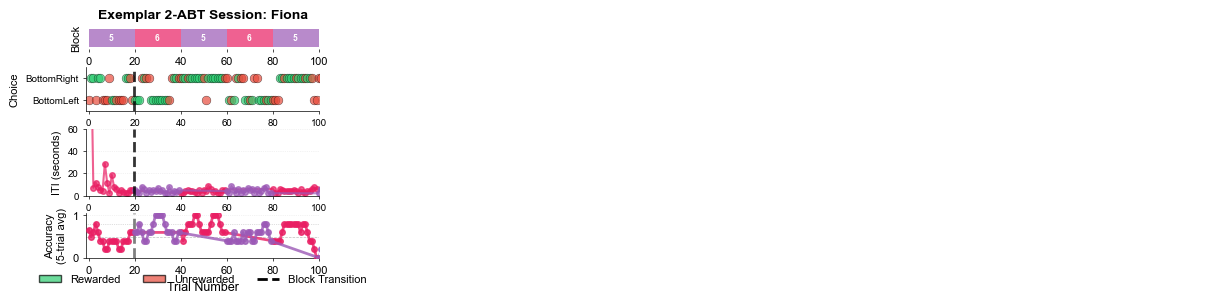


✓ Exemplar 2-ABT session figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Exemplar_Session_2ABT.svg


In [19]:
# Exemplar 2-ABT Session
# ============================================================================

print("Creating exemplar 2-ABT session figure...\n")

# Define block colors
BLOCK_COLORS = ['#e91e63', '#9b59b6']  # Pink and purple for 2 blocks

# Pick a good example session
# Look for one with decent length and clear reversals
session_lengths = df.groupby('Session_ID').size()
good_sessions = session_lengths[session_lengths > 150].index

if len(good_sessions) > 0:
    example_session_id = good_sessions[0]
    
    print(f"Using exemplar session: {example_session_id}")
    
    # Get session data
    session_data = df[df['Session_ID'] == example_session_id].copy()
    session_data = session_data.sort_values('Trial').reset_index(drop=True)
    
    animal = session_data['Animal_Name'].iloc[0]
    
    # Recode Outcome from Reward if needed
    if session_data['Outcome'].isna().any():
        session_data['Outcome'] = session_data['Reward'].map({'Rewarded': 1, 'Unrewarded': 0})
    
    # Calculate ITI
    session_data['Prev_StartTime'] = session_data['AbsoluteTrialStartTime'].shift(1)
    session_data['ITI_calc'] = (session_data['AbsoluteTrialStartTime'] - session_data['Prev_StartTime']) / 1000
    
    # Assign continuous trial number
    session_data['continuous_trial'] = range(len(session_data))
    
    print(f"  Animal: {animal}")
    print(f"  Total trials: {len(session_data)}")
    print(f"  Blocks: {sorted(session_data['Block'].unique())}")
    
    # Create figure
    fig = plt.figure(figsize=(3, 3))
    gs = fig.add_gridspec(4, 1, hspace=0.4, height_ratios=[0.5, 1, 1.5, 1])
    

    # ====================================================================
    # Panel A: Block Structure (FIXED - show all alternations)
    # ====================================================================

    ax1 = fig.add_subplot(gs[0])

    # Group consecutive trials with same block number
    prev_block = None
    for idx, trial in session_data.iterrows():
        curr_block = trial['Block']
        trial_num = trial['continuous_trial']
        
        # Determine color based on block number
        block_color = BLOCK_COLORS[int(curr_block) % 2]
        
        # Draw a thin vertical bar for this trial
        ax1.barh(0, 1, left=trial_num, height=0.5,
                color=block_color, edgecolor='none', alpha=0.7)

    # Add block labels at transitions
    blocks = sorted(session_data['Block'].unique())
    for block in blocks:
        block_trials = session_data[session_data['Block'] == block]
        segments = []
        
        # Find contiguous segments of this block
        start = None
        for i, (idx, trial) in enumerate(block_trials.iterrows()):
            if start is None:
                start = trial['continuous_trial']
            # Check if next trial is contiguous
            if i < len(block_trials) - 1:
                next_trial = block_trials.iloc[i + 1]
                if next_trial['continuous_trial'] != trial['continuous_trial'] + 1:
                    # End of segment
                    end = trial['continuous_trial']
                    segments.append((start, end))
                    start = None
            else:
                # Last trial
                end = trial['continuous_trial']
                segments.append((start, end))
        
        # Label each segment
        for start, end in segments:
            mid = (start + end) / 2
            ax1.text(mid, 0, f'{block}', ha='center', va='center', 
                    fontsize=FONTSIZE-2, fontweight='bold', color='white')

    ax1.set_xlim(-1, 100)
    ax1.set_ylim(-0.3, 0.3)
    ax1.set_yticks([])
    ax1.set_ylabel('Block', fontsize=FONTSIZE)
    ax1.set_title(f'Exemplar 2-ABT Session: {animal}',
                fontsize=FONTSIZE+2, fontweight='bold')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    # ====================================================================
    # Panel B: Physical Choice (colored by outcome)
    # ====================================================================
    
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    
    # Get unique locations from PhysicalChoice
    unique_locs = sorted(session_data['PhysicalChoice'].dropna().unique())
    loc_to_y = {loc: i for i, loc in enumerate(unique_locs)}

    # Plot choices colored by outcome
    for idx, trial in session_data.iterrows():
        if pd.notna(trial['PhysicalChoice']):
            y_val = loc_to_y[trial['PhysicalChoice']]
            color = '#2ecc71' if trial['Outcome'] == 1 else '#e74c3c'
            ax2.scatter(trial['continuous_trial'], y_val, s=40, color=color,
                    alpha=0.7, edgecolor='black', linewidth=0.3)

    ax2.set_yticks(range(len(unique_locs)))
    ax2.set_yticklabels(unique_locs, fontsize=FONTSIZE-1)

    # # Plot choices colored by outcome
    # for idx, trial in session_data.iterrows():
    #     if pd.notna(trial['PhysicalChoice']):
    #         y_val = loc_to_y[trial['PhysicalChoice']]
    #         color = '#2ecc71' if trial['Outcome'] == 1 else '#e74c3c'
    #         ax2.scatter(trial['continuous_trial'], y_val, s=40, color=color,
    #                    alpha=0.7, edgecolor='black', linewidth=0.3)
    
    # Mark block transitions
    for idx in range(len(blocks)-1):
        curr_block = blocks[idx]
        next_block = blocks[idx+1]
        trans_trial = session_data[session_data['Block'] == next_block]['continuous_trial'].iloc[0]
        ax2.axvline(trans_trial - 0.5, color='black', linestyle='--',
                   linewidth=2, alpha=0.8, zorder=10)
    
    ax2.set_yticks(range(len(unique_locs)))
    # ax2.set_yticklabels(loc_names, fontsize=FONTSIZE-1)
    ax2.set_ylabel('Choice', fontsize=FONTSIZE)
    ax2.set_ylim(-0.5, len(unique_locs) - 0.5)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)
    
    # ====================================================================
    # Panel C: Inter-Trial Interval (colored by block)
    # ====================================================================
    
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    
    # Mark block transitions
    for idx in range(len(blocks)-1):
        curr_block = blocks[idx]
        next_block = blocks[idx+1]
        trans_trial = session_data[session_data['Block'] == next_block]['continuous_trial'].iloc[0]
        ax3.axvline(trans_trial - 0.5, color='black', linestyle='--',
                   linewidth=2, alpha=0.8, zorder=10)
    
    # Plot ITI colored by block
    for idx, block in enumerate(blocks):
        block_trials = session_data[session_data['Block'] == block]
        block_color = BLOCK_COLORS[idx % 2]
        
        ax3.plot(block_trials['continuous_trial'], block_trials['ITI_calc'],
                'o-', color=block_color, linewidth=1.5, markersize=4, alpha=0.7)
    
    ax3.set_ylabel('ITI (seconds)', fontsize=FONTSIZE)
    ax3.set_ylim(0, min(session_data['ITI_calc'].max() * 1.2, 60) if session_data['ITI_calc'].notna().any() else 30)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax3.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)
    
    # ====================================================================
    # Panel D: Rolling Accuracy (colored by block)
    # ====================================================================
    
    ax4 = fig.add_subplot(gs[3], sharex=ax1)
    
    # Calculate rolling average
    window = 5
    session_data['rolling_accuracy'] = session_data['Outcome'].rolling(
        window=window, min_periods=1, center=True).mean()
    
    # Mark block transitions
    for idx in range(len(blocks)-1):
        curr_block = blocks[idx]
        next_block = blocks[idx+1]
        trans_trial = session_data[session_data['Block'] == next_block]['continuous_trial'].iloc[0]
        ax4.axvline(trans_trial - 0.5, color='black', linestyle='--',
                   linewidth=2, alpha=0.5, zorder=1)
    
    # Plot rolling accuracy colored by block
    for idx, block in enumerate(blocks):
        block_trials = session_data[session_data['Block'] == block]
        block_color = BLOCK_COLORS[idx % 2]
        
        ax4.plot(block_trials['continuous_trial'], block_trials['rolling_accuracy'],
                'o-', color=block_color, linewidth=2, markersize=4, alpha=0.8, zorder=5)
    
    ax4.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
    ax4.axhline(0.8, color='gray', linestyle=':', linewidth=LINE_WIDTH, alpha=0.5)
    ax4.set_ylabel(f'Accuracy\n({window}-trial avg)', fontsize=FONTSIZE)
    ax4.set_xlabel('Trial Number', fontsize=FONTSIZE+1)
    ax4.set_ylim(0, 1.05)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax4.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Rewarded', alpha=0.7, edgecolor='black'),
        Patch(facecolor='#e74c3c', label='Unrewarded', alpha=0.7, edgecolor='black'),
        plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Block Transition')
    ]
    ax4.legend(handles=legend_elements, fontsize=FONTSIZE, frameon=False,
              loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_PATH, 'Exemplar_Session_2ABT.svg'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Exemplar 2-ABT session figure saved to:")
    print(f"  {FIGURE_PATH}/Exemplar_Session_2ABT.svg")
    
else:
    print("⚠️ No sessions found with >150 trials")

Creating physical switch comparison (cued vs uncued)...

Switch-aligned data: 3016 trials


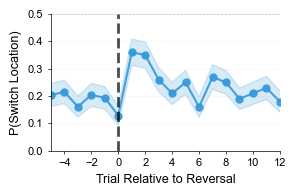


✓ Switch rate figure created!

SWITCH RATE STATISTICS

CUED:
  Pre-reversal: 21.2%
  Early post (0-4): 26.4%
  Late post (10+): 22.0%
  Increase at reversal: +5.2pp
Figure is saved at /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Cued_vs_Uncued_Switch_Rate_80-20.svg

UNCUED:
  Pre-reversal: nan%
  Early post (0-4): nan%
  Late post (10+): nan%
  Increase at reversal: +nanpp
Figure is saved at /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Cued_vs_Uncued_Switch_Rate_80-20.svg


In [20]:
# Cued vs Uncued: Physical Switch Rate
# ============================================================================

print("Creating physical switch comparison (cued vs uncued)...\n")
PROB_CONDITION = df.prob_Condition.unique()[0]
# Create reversal-aligned switch data
switch_aligned_data = []

for idx, trans in trans_df.iterrows():
    session_id = trans['session_id']
    to_blockcount = trans['to_blockcount']
    trans_type = trans['transition_type']
    animal = trans['animal']
    
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial')
    
    # Find the reversal point
    new_block_trials = session_data[session_data['Block'] == to_blockcount]
    
    if len(new_block_trials) > 0:
        reversal_trial = new_block_trials['Trial'].iloc[0]
        
        # Get trials -10 to +20 relative to reversal
        for rel_trial in range(-10, 21):
            abs_trial = reversal_trial + rel_trial
            trial_data = session_data[session_data['Trial'] == abs_trial]
            
            if len(trial_data) > 0 and not pd.isna(trial_data['PhysicalSwitch'].iloc[0]):
                switch_aligned_data.append({
                    'session_id': session_id,
                    'animal': animal,
                    'transition_type': trans_type,
                    'trial_relative': rel_trial,
                    'physical_switch': trial_data['PhysicalSwitch'].iloc[0],
                    'outcome': trial_data['Outcome'].iloc[0]
                })

switch_df = pd.DataFrame(switch_aligned_data)

print(f"Switch-aligned data: {len(switch_df)} trials")

# Create switch rate curves
fig, ax = plt.subplots(figsize=(3, 2))

BIN_SIZE = 1

for trans_type, color in [('CUED', '#3498db'), ('UNCUED', '#f29d1f')]:
    type_data = switch_df[switch_df['transition_type'] == trans_type].copy()
    type_data['trial_bin'] = (type_data['trial_relative'] // BIN_SIZE) * BIN_SIZE
    
    binned = type_data.groupby('trial_bin').agg({
        'physical_switch': ['mean', 'sem']
    }).reset_index()
    binned.columns = ['trial_bin', 'switch_rate', 'sem']
    
    ax.plot(binned['trial_bin'], binned['switch_rate'],
           'o-', color=color, linewidth=1.5, markersize=5,
           label=trans_type, alpha=0.9)
    ax.fill_between(binned['trial_bin'],
                    binned['switch_rate'] - binned['sem'],
                    binned['switch_rate'] + binned['sem'],
                    color=color, alpha=0.2)

ax.axvline(0, color='black', linestyle='--', linewidth=2, 
          alpha=0.7, label='Reversal')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, 
          alpha=0.5, label='Random')

ax.set_xlabel('Trial Relative to Reversal', fontsize=FONTSIZE+1)
ax.set_ylabel('P(Switch Location)', fontsize=FONTSIZE+1)
# ax.set_title('Physical Switching: Cued vs Uncued Reversals', 
#             fontsize=FONTSIZE+2, fontweight='bold')
ax.set_xlim(-5, 12)
# set x lim marks at -4, -2, 0, 2, 4, 6, 8, 10, 12
ax.set_xticks([-4, -2, 0, 2, 4, 6, 8, 10, 12])
ax.set_ylim(0, 0.5)
# ax.legend(fontsize=FONTSIZE+1, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, f'Cued_vs_Uncued_Switch_Rate_{PROB_CONDITION}.svg'), dpi=300)
plt.show()

print("\n✓ Switch rate figure created!")

# Print statistics
print("\n" + "="*70)
print("SWITCH RATE STATISTICS")
print("="*70)

for trans_type in ['CUED', 'UNCUED']:
    type_data = switch_df[switch_df['transition_type'] == trans_type]
    
    pre_rev = type_data[type_data['trial_relative'] < 0]['physical_switch'].mean()
    early_post = type_data[(type_data['trial_relative'] >= 0) & 
                           (type_data['trial_relative'] < 5)]['physical_switch'].mean()
    late_post = type_data[type_data['trial_relative'] >= 10]['physical_switch'].mean()
    
    print(f"\n{trans_type}:")
    print(f"  Pre-reversal: {pre_rev*100:.1f}%")
    print(f"  Early post (0-4): {early_post*100:.1f}%")
    print(f"  Late post (10+): {late_post*100:.1f}%")
    print(f"  Increase at reversal: {(early_post - pre_rev)*100:+.1f}pp")
    print(f"Figure is saved at {FIGURE_PATH}/Cued_vs_Uncued_Switch_Rate_{PROB_CONDITION}.svg")

print("="*70)

In [21]:
# make a Choice column that codes the two PhysicalChoices as 0 and 1, you will need to find out the name of the two choices  
unique_choices = df['PhysicalChoice'].unique()
df['Choice'] = df['PhysicalChoice'].map({unique_choices[0]: 0, unique_choices[1]: 1})
df.head()

# we need make a high prob column when the prob_reward is 0.8, it needs to be 1 and then when its 0.2 it needs to be 0
df['High_Prob'] = df['ProbReward'].map({0.8: 1, 0.2: 0})
df.head()


,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,...,Session_Type_y.1,Num_Reversals_y.1,Num_Cued_Transitions_y.1,Has_Cued_Transitions_y.1,Session_Type,Num_Reversals,Num_Cued_Transitions,Has_Cued_Transitions,Choice,High_Prob
0,1,1,1,5,5,6,NaN,0.0000,2022,4,...,2-ABT,1,0,False,2-ABT,1,0,False,0.0,0
1,2,1,2,5,5,0,NaN,136051.9373,2022,4,...,2-ABT,1,0,False,2-ABT,1,0,False,1.0,1
2,3,1,3,5,5,0,NaN,143167.3282,2022,4,...,2-ABT,1,0,False,2-ABT,1,0,False,1.0,1
3,4,1,4,5,5,6,NaN,154915.8934,2022,4,...,2-ABT,1,0,False,2-ABT,1,0,False,0.0,0
4,5,1,5,5,5,0,NaN,162799.2638,2022,4,...,2-ABT,1,0,False,2-ABT,1,0,False,1.0,1


Creating physical switch comparison (cued vs uncued)...

Choice-aligned data: 3023 trials


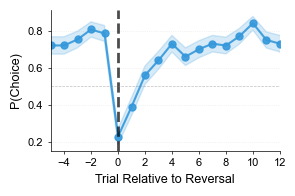


✓ Switch rate figure created!

Choice RATE STATISTICS

CUED:
  Pre-reversal: 74.9% ± 1.4%
  Early post (0-4): 51.0% ± 2.2%
  Late post (10+): 69.1% ± 1.4%
  Increase at reversal: -23.9pp
Figure is saved at /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Cued_vs_Uncued_Choice_Rate_80-20.svg

UNCUED:
  Pre-reversal: nan% ± nan%
  Early post (0-4): nan% ± nan%
  Late post (10+): nan% ± nan%
  Increase at reversal: +nanpp
Figure is saved at /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Cued_vs_Uncued_Choice_Rate_80-20.svg


In [22]:
# Cued vs Uncued: Physical Choice Rate
# ============================================================================

print("Creating physical switch comparison (cued vs uncued)...\n")
PROB_CONDITION = df.prob_Condition.unique()[0]
# Create reversal-aligned switch data
switch_aligned_data = []

for idx, trans in trans_df.iterrows():
    session_id = trans['session_id']
    to_blockcount = trans['to_blockcount']
    trans_type = trans['transition_type']
    animal = trans['animal']
    
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial')
    
    # Find the reversal point
    new_block_trials = session_data[session_data['Block'] == to_blockcount]
    
    if len(new_block_trials) > 0:
        reversal_trial = new_block_trials['Trial'].iloc[0]
        
        # Get trials -10 to +20 relative to reversal
        for rel_trial in range(-10, 21):
            abs_trial = reversal_trial + rel_trial
            trial_data = session_data[session_data['Trial'] == abs_trial]
            
            if len(trial_data) > 0 and not pd.isna(trial_data['High_Prob'].iloc[0]):
                switch_aligned_data.append({
                    'session_id': session_id,
                    'animal': animal,
                    'transition_type': trans_type,
                    'trial_relative': rel_trial,
                    'high_prob_choice': trial_data['High_Prob'].iloc[0],
                    'outcome': trial_data['Outcome'].iloc[0]
                })

switch_df = pd.DataFrame(switch_aligned_data)

print(f"Choice-aligned data: {len(switch_df)} trials")

# Create switch rate curves
fig, ax = plt.subplots(figsize=(3, 2))

BIN_SIZE = 1

for trans_type, color in [('CUED', '#3498db'), ('UNCUED', '#f29d1f')]:
    type_data = switch_df[switch_df['transition_type'] == trans_type].copy()
    type_data['trial_bin'] = (type_data['trial_relative'] // BIN_SIZE) * BIN_SIZE
    
    binned = type_data.groupby('trial_bin').agg({
        'high_prob_choice': ['mean', 'sem']
    }).reset_index()
    binned.columns = ['trial_bin', 'choice_rate', 'sem']
    
    ax.plot(binned['trial_bin'], binned['choice_rate'],
           'o-', color=color, linewidth=1.5, markersize=5,
           label=trans_type, alpha=0.9)
    ax.fill_between(binned['trial_bin'],
                    binned['choice_rate'] - binned['sem'],
                    binned['choice_rate'] + binned['sem'],
                    color=color, alpha=0.2)

ax.axvline(0, color='black', linestyle='--', linewidth=2, 
          alpha=0.7, label='Reversal')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, 
          alpha=0.5, label='Random')

ax.set_xlabel('Trial Relative to Reversal', fontsize=FONTSIZE+1)
ax.set_ylabel('P(Choice)', fontsize=FONTSIZE+1)
# ax.set_title('Physical Switching: Cued vs Uncued Reversals', 
#             fontsize=FONTSIZE+2, fontweight='bold')
ax.set_xlim(-5, 12)
# set x lim marks at -4, -2, 0, 2, 4, 6, 8, 10, 12
ax.set_xticks([-4, -2, 0, 2, 4, 6, 8, 10, 12])
# ax.set_ylim(0, 0.5)
# ax.legend(fontsize=FONTSIZE+1, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, f'Cued_vs_Uncued_Choice_Rate_{PROB_CONDITION}.svg'), dpi=300)
plt.show()

print("\n✓ Switch rate figure created!")

# Print statistics
print("\n" + "="*70)
print("Choice RATE STATISTICS")
print("="*70)

for trans_type in ['CUED', 'UNCUED']:
    type_data = switch_df[switch_df['transition_type'] == trans_type]
    
    pre_rev = type_data[type_data['trial_relative'] < 0]['high_prob_choice'].mean()
    early_post = type_data[(type_data['trial_relative'] >= 0) & 
                           (type_data['trial_relative'] < 5)]['high_prob_choice'].mean()
    late_post = type_data[type_data['trial_relative'] >= 10]['high_prob_choice'].mean()
    # add in SEM for all of these
    pre_rev_sem = type_data[type_data['trial_relative'] < 0]['high_prob_choice'].sem()
    early_post_sem = type_data[(type_data['trial_relative'] >= 0) & 
                              (type_data['trial_relative'] < 5)]['high_prob_choice'].sem()
    late_post_sem = type_data[type_data['trial_relative'] >= 10]['high_prob_choice'].sem()
    
    print(f"\n{trans_type}:")
    print(f"  Pre-reversal: {pre_rev*100:.1f}% ± {pre_rev_sem*100:.1f}%")
    print(f"  Early post (0-4): {early_post*100:.1f}% ± {early_post_sem*100:.1f}%")
    print(f"  Late post (10+): {late_post*100:.1f}% ± {late_post_sem*100:.1f}%")
    print(f"  Increase at reversal: {(early_post - pre_rev)*100:+.1f}pp")
    print(f"Figure is saved at {FIGURE_PATH}/Cued_vs_Uncued_Choice_Rate_{PROB_CONDITION}.svg")

print("="*70)

In [23]:
# Add history columns to marmoset Bandit data
# ============================================================================

def add_history_cols_marmoset(df, N):
    """
    Add choice/outcome history columns to marmoset reversal data.
    
    INPUTS:
        - df (pandas DataFrame): marmoset behavior dataset
        - N (int): number of trials prior to current trial for history sequence
    
    OUTPUTS:
        - df (pandas DataFrame): with additional columns:
            - 'decision_seq': string of previous N decisions (PhysicalChoice: 0 or 1)
            - 'reward_seq': string of previous N rewards (Outcome: 0 or 1)
            - 'history': encoded choice/outcome (symmetrical)
            - 'RL_history': encoded choice/outcome (raw directionality)
    """
    from numpy.lib.stride_tricks import sliding_window_view
    
    # Initialize columns
    df['decision_seq'] = pd.Series(np.nan, index=df.index).astype(object)
    df['reward_seq'] = pd.Series(np.nan, index=df.index).astype(object)
    df['history'] = pd.Series(np.nan, index=df.index).astype(object)
    df['RL_history'] = pd.Series(np.nan, index=df.index).astype(object)
    
    # Reset index
    df = df.reset_index(drop=True)
    
    # Process each session separately
    for session in df['Session_ID'].unique():
        d = df.loc[df['Session_ID'] == session].copy()
        
        # Skip if not enough trials
        if len(d) <= N:
            continue
        
        # Convert PhysicalChoice and Outcome to int for sequences
        # PhysicalChoice: 0 or 1 (which option chosen)
        # Outcome: 0 or 1 (unrewarded or rewarded)
        decision_arr = d['2ABT_side_Choice'].fillna(0).astype('int').values
        reward_arr = d['Outcome'].fillna(0).astype('int').values
        
        # Generate sequences using sliding window
        decision_sequences = list(map(list_to_str, sliding_window_view(decision_arr, N)))[:-1]
        reward_sequences = list(map(list_to_str, sliding_window_view(reward_arr, N)))[:-1]
        
        # Assign to rows starting at index N
        df.loc[d.index.values[N:], 'decision_seq'] = decision_sequences
        df.loc[d.index.values[N:], 'reward_seq'] = reward_sequences
        
        # Generate encoded history columns
        df.loc[d.index.values[N:], 'history'] = df.loc[d.index.values[N:]].apply(
            encode_as_ab, args=([True]), axis=1
        )
        df.loc[d.index.values[N:], 'RL_history'] = df.loc[d.index.values[N:]].apply(
            encode_as_ab, args=([False]), axis=1
        )
    
    return df

def list_to_str(seq):
    """Convert list of ints/floats to string"""
    seq = [str(el) for el in seq]
    return ''.join(seq)

def encode_as_ab(row, symm):
    """
    Convert choice/outcome history to character code
    INPUTS:
        - row: DataFrame row with 'decision_seq' and 'reward_seq'
        - symm (bool): if True, symmetrical A/B encoding; if False, raw encoding
    OUTPUTS:
        - string encoding each choice/outcome combination
    """
    if int(row.decision_seq[0]) & symm:  # First choice = 1 → A
        mapping = {('0','0'): 'b', ('0','1'): 'B', ('1','0'): 'a', ('1','1'): 'A'} 
    elif (int(row.decision_seq[0])==0) & symm:  # First choice = 0 → A    
        mapping = {('0','0'): 'a', ('0','1'): 'A', ('1','0'): 'b', ('1','1'): 'B'} 
    else:  # Raw mapping
        mapping = {('0','0'): 'r', ('0','1'): 'R', ('1','0'): 'l', ('1','1'): 'L'} 

    return ''.join([mapping[(c,r)] for c,r in zip(row.decision_seq, row.reward_seq)])

# Apply to your 2-ABT data
N = 3  # History window
df['2ABT_side_Choice'] = df['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
df_hist = add_history_cols_marmoset(df, N)

print(f"\n✓ History columns added (N={N})")
print(f"Sample decision sequences: {df_hist['decision_seq'].dropna().head()}")
print(f"Sample reward sequences: {df_hist['reward_seq'].dropna().head()}")
print(f"Sample history encoding: {df_hist['history'].dropna().head()}")
print(f"Sample history encoding: {df_hist['RL_history'].dropna().head()}")


✓ History columns added (N=3)
Sample decision sequences: 3    011
4    110
5    101
6    011
7    110
Name: decision_seq, dtype: object
Sample reward sequences: 3    011
4    110
5    101
6    011
7    110
Name: reward_seq, dtype: object
Sample history encoding: 3    aBB
4    AAb
5    AbA
6    aBB
7    AAb
Name: history, dtype: object
Sample history encoding: 3    rLL
4    LLr
5    LrL
6    rLL
7    LLr
Name: RL_history, dtype: object


Calculating P(Switch) by reward sequence...

Trials with 3-trial history: 36,373

Reward sequences found: 8

P(Switch) by reward sequence (sorted):
  reward_seq  p_switch  n_trials
7        111  0.072770      9787
3        011  0.076961      4679
5        101  0.114462      3923
1        001  0.143038      3455
6        110  0.219990      4687
2        010  0.241540      2696
4        100  0.380873      3472
0        000  0.450241      3674


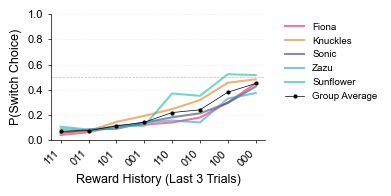


✓ P(Switch) analysis complete!


In [24]:
# P(Switch) by Reward History
# ============================================================================

print("Calculating P(Switch) by reward sequence...\n")

PROB_CONDITION = df_hist.prob_Condition.unique()[0]
# Filter out rows without history
df_with_history = df_hist[df_hist['reward_seq'].notna()].copy()

print(f"Trials with {N}-trial history: {len(df_with_history):,}")

# Calculate P(Switch) for each reward sequence and animal
switch_by_history = df_with_history.groupby(['Animal_Name', 'reward_seq']).agg({
    'PhysicalSwitch': ['mean', 'sem', 'count']
}).reset_index()

switch_by_history.columns = ['Animal_Name', 'reward_seq', 'p_switch', 'sem', 'n_trials']

# Calculate overall P(Switch) across animals for each reward sequence
overall_switch = switch_by_history.groupby('reward_seq').agg({
    'p_switch': 'mean',
    'n_trials': 'sum'
}).reset_index()

overall_switch = overall_switch.sort_values('p_switch')

print(f"\nReward sequences found: {len(overall_switch)}")
print("\nP(Switch) by reward sequence (sorted):")
print(overall_switch)

# ============================================================================
# Plot P(Switch) by Reward Sequence
# ============================================================================

fig, ax = plt.subplots(figsize=(4, 2))

# Sort reward sequences by overall P(Switch)
sorted_seqs = overall_switch['reward_seq'].values

# Plot individual animals
for animal in sort_animals(switch_by_history['Animal_Name'].unique()):
    animal_data = switch_by_history[switch_by_history['Animal_Name'] == animal]
    
    # Reindex to match sorted sequences
    animal_data = animal_data.set_index('reward_seq').reindex(sorted_seqs).reset_index()
    
    ax.plot(range(len(sorted_seqs)), animal_data['p_switch'],
           '-', color=ANIMAL_COLORS[animal], alpha=0.6, linewidth=1.5,
           markersize=4, label=animal)

# Plot overall average
overall_sorted = overall_switch.set_index('reward_seq').reindex(sorted_seqs).reset_index()
ax.plot(range(len(sorted_seqs)), overall_sorted['p_switch'],
       'o-', color='black', linewidth=LINE_WIDTH, markersize=2,
       label='Group Average', zorder=10)

# Formatting
ax.set_xticks(range(len(sorted_seqs)))
ax.set_xticklabels(sorted_seqs, rotation=45, ha='right', fontsize=FONTSIZE-1)
ax.set_xlabel('Reward History (Last 3 Trials)', fontsize=FONTSIZE+1)
ax.set_ylabel('P(Switch Choice)', fontsize=FONTSIZE+1)

ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax.legend(fontsize=FONTSIZE-1, frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, f'Switch_by_RewardHistory_{PROB_CONDITION}.svg'), 
           dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ P(Switch) analysis complete!")

In [26]:
# Analysis 2: Win-Stay / Lose-Shift Rates (Matching Style)
# ============================================================================
import scipy.stats as stats

print("Calculating Win-Stay / Lose-Shift rates...\n")

# Filter for trials with valid switch info
df_wsls = df_hist[df_hist['PhysicalSwitch'].notna()].copy()

# Create previous outcome column
df_wsls = df_wsls.sort_values(['Session_ID', 'Block', 'Trial']).reset_index(drop=True)
df_wsls['Prev_Outcome'] = df_wsls.groupby('Session_ID')['Outcome'].shift(1)

# Remove first trial of each session
df_wsls = df_wsls[df_wsls['Prev_Outcome'].notna()].copy()

print(f"Trials with previous outcome: {len(df_wsls):,}")

# Calculate rates per animal per session
wsls_sessions = []

for session_id in df_wsls['Session_ID'].unique():
    session_data = df_wsls[df_wsls['Session_ID'] == session_id]
    animal = session_data['Animal_Name'].iloc[0]
    
    # Win trials (previous trial rewarded)
    win_trials = session_data[session_data['Prev_Outcome'] == 1]
    win_stay_rate = (win_trials['PhysicalSwitch'] == 0).mean() if len(win_trials) > 0 else np.nan
    
    # Lose trials (previous trial unrewarded)
    lose_trials = session_data[session_data['Prev_Outcome'] == 0]
    lose_shift_rate = (lose_trials['PhysicalSwitch'] == 1).mean() if len(lose_trials) > 0 else np.nan
    
    wsls_sessions.append({
        'session_id': session_id,
        'animal': animal,
        'win_stay': win_stay_rate,
        'lose_shift': lose_shift_rate,
        'n_win': len(win_trials),
        'n_lose': len(lose_trials)
    })

wsls_sessions_df = pd.DataFrame(wsls_sessions)

# Calculate summary per animal
wsls_summary = []

for animal in sort_animals(wsls_sessions_df['animal'].unique()):
    animal_data = wsls_sessions_df[wsls_sessions_df['animal'] == animal]
    
    wsls_summary.append({
        'animal': animal,
        'win_stay_mean': animal_data['win_stay'].mean(),
        'win_stay_sem': stats.sem(animal_data['win_stay'].dropna()),
        'lose_shift_mean': animal_data['lose_shift'].mean(),
        'lose_shift_sem': stats.sem(animal_data['lose_shift'].dropna()),
        'n_sessions': len(animal_data)
    })

wsls_summary_df = pd.DataFrame(wsls_summary)

print("\nWin-Stay / Lose-Shift summary:")
print(wsls_summary_df)

Calculating Win-Stay / Lose-Shift rates...

Trials with previous outcome: 36,473

Win-Stay / Lose-Shift summary:
      animal  win_stay_mean  win_stay_sem  lose_shift_mean  lose_shift_sem  \
0      Fiona       0.918187      0.014014         0.269887        0.015489   
1   Knuckles       0.896387      0.005077         0.361495        0.010621   
2      Sonic       0.908644      0.008127         0.272452        0.009029   
3       Zazu       0.880807      0.013174         0.261877        0.020224   
4  Sunflower       0.881123      0.016164         0.433039        0.012227   

   n_sessions  
0          14  
1          23  
2          14  
3          14  
4          35  


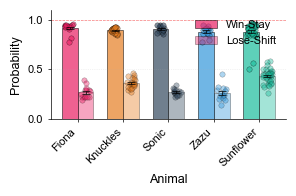


✓ Win-Stay/Lose-Shift figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/WinStay_LoseShift_80-20.svg


In [27]:
# Analysis 2 FIGURE: Win-Stay / Lose-Shift Rates (Matching Style)
fig, ax = plt.subplots(figsize=(3, 2))

x_pos = np.arange(len(wsls_summary_df))
width = 0.35

# ========================================================================
# Win-Stay bars (darker)
# ========================================================================

bars_ws = ax.bar(x_pos - width/2, wsls_summary_df['win_stay_mean'], width,
                 color=[ANIMAL_COLORS[animal] for animal in wsls_summary_df['animal']],
                 alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH,
                 label='Win-Stay')

ax.errorbar(x_pos - width/2, wsls_summary_df['win_stay_mean'], 
           yerr=wsls_summary_df['win_stay_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual session points for Win-Stay
for idx, animal in enumerate(wsls_summary_df['animal']):
    animal_sessions = wsls_sessions_df[wsls_sessions_df['animal'] == animal]
    if len(animal_sessions) > 0:
        x_jitter = (idx - width/2) + np.random.uniform(-0.1, 0.1, size=len(animal_sessions))
        ax.scatter(x_jitter, animal_sessions['win_stay'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.6, edgecolor='black', linewidth=0.3, zorder=5)

# ========================================================================
# Lose-Shift bars (lighter)
# ========================================================================

bars_ls = ax.bar(x_pos + width/2, wsls_summary_df['lose_shift_mean'], width,
                 color=[ANIMAL_COLORS[animal] for animal in wsls_summary_df['animal']],
                 alpha=0.4, edgecolor='black', linewidth=LINE_WIDTH,
                 label='Lose-Shift')

ax.errorbar(x_pos + width/2, wsls_summary_df['lose_shift_mean'],
           yerr=wsls_summary_df['lose_shift_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual session points for Lose-Shift
for idx, animal in enumerate(wsls_summary_df['animal']):
    animal_sessions = wsls_sessions_df[wsls_sessions_df['animal'] == animal]
    if len(animal_sessions) > 0:
        x_jitter = (idx + width/2) + np.random.uniform(-0.1, 0.1, size=len(animal_sessions))
        ax.scatter(x_jitter, animal_sessions['lose_shift'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.4, edgecolor='black', linewidth=0.3, zorder=5)

# Reference line at 1.0 (deterministic)
ax.axhline(1.0, color='red', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(wsls_summary_df['animal'], rotation=45, ha='right')
ax.set_ylabel('Probability', fontsize=FONTSIZE+1)
ax.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=FONTSIZE, frameon=False, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, f'WinStay_LoseShift_{PROB_CONDITION}.svg'), 
           dpi=300)
plt.show()

print(f"\n✓ Win-Stay/Lose-Shift figure saved to:")
print(f"  {FIGURE_PATH}/WinStay_LoseShift_{PROB_CONDITION}.svg")

In [28]:
# Create proper transitions for 2-ABT using BlockCount
# ============================================================================

print("Creating transitions for 2-ABT data using BlockCount...\n")

trans_2abt = []

for session_id in df['Session_ID'].unique():
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial')
    animal = session_data['Animal_Name'].iloc[0]
    
    # Get unique BlockCount values
    block_counts = sorted(session_data['BlockCount'].unique())
    
    # Each BlockCount represents a 20-trial block
    for i in range(1, len(block_counts)):  # Start from 1 to get transitions
        trans_2abt.append({
            'session_id': session_id,
            'animal': animal,
            'from_blockcount': block_counts[i-1],
            'to_blockcount': block_counts[i]
        })

trans_2abt_df = pd.DataFrame(trans_2abt)

print(f"Total 2-ABT transitions: {len(trans_2abt_df)}")
print(f"Transitions per session: {len(trans_2abt_df) / df['Session_ID'].nunique():.1f}")
print(f"\nSample transitions:")
print(trans_2abt_df.head(15))

# Verify with sample session
sample_session = df[df['Session_ID'] == '2022-05-02_20220502_Fiona_Reversal3.1'].sort_values('Trial')
print(f"\nSample session BlockCounts: {sorted(sample_session['BlockCount'].unique())}")
print(f"Trials per BlockCount:")
print(sample_session.groupby('BlockCount').size())

Creating transitions for 2-ABT data using BlockCount...

Total 2-ABT transitions: 1779
Transitions per session: 17.8

Sample transitions:
                               session_id animal  from_blockcount  \
0   2022-04-25_20220425_Fiona_Reversal3.1  Fiona                1   
1   2022-04-25_20220425_Fiona_Reversal3.1  Fiona                2   
2   2022-04-25_20220425_Fiona_Reversal3.1  Fiona                3   
3   2022-04-25_20220425_Fiona_Reversal3.1  Fiona                4   
4   2022-04-25_20220425_Fiona_Reversal3.1  Fiona                5   
5   2022-04-25_20220425_Fiona_Reversal3.1  Fiona                6   
6   2022-04-25_20220425_Fiona_Reversal3.1  Fiona                7   
7   2022-04-25_20220425_Fiona_Reversal3.1  Fiona                8   
8   2022-04-25_20220425_Fiona_Reversal3.1  Fiona                9   
9   2022-04-25_20220425_Fiona_Reversal3.1  Fiona               10   
10  2022-04-25_20220425_Fiona_Reversal3.1  Fiona               11   
11  2022-04-25_20220425_Fiona_Reve

Calculating trials to criterion for 2-ABT reversals...

Reversals analyzed: 113
Reached criterion: 107 (94.7%)

Trials to criterion by animal:
      animal       mean       sem   n
0      Fiona   8.440000  0.600222  25
1   Knuckles   7.565217  0.682434  23
2      Sonic   6.000000  0.543021  13
3       Zazu  10.357143  1.340851  14
4  Sunflower   9.125000  0.756357  32


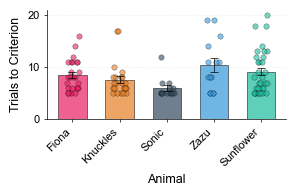


✓ Trials to criterion figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Trials_to_Criterion_2ABT.svg


In [29]:
# Analysis 3: Trials to Criterion for 2-ABT
# ============================================================================

print("Calculating trials to criterion for 2-ABT reversals...\n")

CRITERION_ACCURACY = 0.7  # 80% accuracy
CRITERION_WINDOW = 5      # Over 5 consecutive trials

trials_to_criterion = []

for idx, trans in trans_2abt_df.iterrows():
    session_id = trans['session_id']
    to_block = trans['to_blockcount']
    animal = trans['animal']
    
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial')
    
    # Get trials from new block
    new_block_trials = session_data[session_data['Block'] == to_block].copy()
    
    if len(new_block_trials) >= CRITERION_WINDOW:
        # Calculate rolling accuracy on High_Prob choice
        new_block_trials['rolling_acc'] = new_block_trials['High_Prob'].rolling(
            window=CRITERION_WINDOW, min_periods=CRITERION_WINDOW
        ).mean()
        
        # Find first trial where rolling accuracy >= criterion
        criterion_met = new_block_trials[new_block_trials['rolling_acc'] >= CRITERION_ACCURACY]
        
        if len(criterion_met) > 0:
            ttc = criterion_met.index[0] - new_block_trials.index[0] + 1
        else:
            ttc = np.nan  # Never reached criterion
        
        trials_to_criterion.append({
            'session_id': session_id,
            'animal': animal,
            'trials_to_criterion': ttc,
            'block_length': len(new_block_trials)
        })

ttc_df = pd.DataFrame(trials_to_criterion)

# Remove NaN and unreasonably long values
ttc_df_clean = ttc_df[ttc_df['trials_to_criterion'].notna()]
ttc_df_clean = ttc_df_clean[ttc_df_clean['trials_to_criterion'] <= 30]

print(f"Reversals analyzed: {len(ttc_df)}")
print(f"Reached criterion: {len(ttc_df_clean)} ({len(ttc_df_clean)/len(ttc_df)*100:.1f}%)")

# Calculate summary per animal
ttc_summary = []

for animal in sort_animals(ttc_df_clean['animal'].unique()):
    animal_data = ttc_df_clean[ttc_df_clean['animal'] == animal]['trials_to_criterion']
    
    ttc_summary.append({
        'animal': animal,
        'mean': animal_data.mean(),
        'sem': stats.sem(animal_data),
        'n': len(animal_data)
    })

ttc_summary_df = pd.DataFrame(ttc_summary)

print("\nTrials to criterion by animal:")
print(ttc_summary_df)

# Create figure
fig, ax = plt.subplots(figsize=(3, 2))

x_pos = np.arange(len(ttc_summary_df))
width = 0.6

# Plot bars
bars = ax.bar(x_pos, ttc_summary_df['mean'], width,
              color=[ANIMAL_COLORS[animal] for animal in ttc_summary_df['animal']],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

# Error bars
ax.errorbar(x_pos, ttc_summary_df['mean'], 
           yerr=ttc_summary_df['sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual data points
for idx, animal in enumerate(ttc_summary_df['animal']):
    animal_data = ttc_df_clean[ttc_df_clean['animal'] == animal]
    if len(animal_data) > 0:
        x_jitter = idx + np.random.uniform(-0.15, 0.15, size=len(animal_data))
        ax.scatter(x_jitter, animal_data['trials_to_criterion'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.6, edgecolor='black', linewidth=0.3, zorder=5)

ax.set_xticks(x_pos)
ax.set_xticklabels(ttc_summary_df['animal'], rotation=45, ha='right')
ax.set_ylabel('Trials to Criterion', fontsize=FONTSIZE+1)
ax.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, f'Trials_to_Criterion_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Trials to criterion figure saved to:")
print(f"  {FIGURE_PATH}/Trials_to_Criterion_2ABT.svg")

In [38]:
# Analyze reward history in low vs high accuracy blocks
# ============================================================================

print("Analyzing reward patterns in low vs high accuracy blocks...\n")

# Function to calculate reward statistics for a block
def analyze_block_rewards(session_id, to_blockcount):
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial')
    block_data = session_data[session_data['BlockCount'] == to_blockcount]
    
    if len(block_data) < LATE_WINDOW:
        return None
    
    # Overall block stats
    high_prob_choices = block_data[block_data['High_Prob'] == 1]
    low_prob_choices = block_data[block_data['High_Prob'] == 0]
    
    high_prob_reward_rate = high_prob_choices['Outcome'].mean() if len(high_prob_choices) > 0 else np.nan
    low_prob_reward_rate = low_prob_choices['Outcome'].mean() if len(low_prob_choices) > 0 else np.nan
    
    # Late window stats
    late_trials = block_data.tail(LATE_WINDOW)
    late_high_choices = late_trials[late_trials['High_Prob'] == 1]
    late_low_choices = late_trials[late_trials['High_Prob'] == 0]
    
    late_high_reward = late_high_choices['Outcome'].mean() if len(late_high_choices) > 0 else np.nan
    late_low_reward = late_low_choices['Outcome'].mean() if len(late_low_choices) > 0 else np.nan
    
    # Check for streaks
    outcomes = block_data['Outcome'].values
    max_loss_streak = 0
    current_streak = 0
    for outcome in outcomes:
        if outcome == 0:
            current_streak += 1
            max_loss_streak = max(max_loss_streak, current_streak)
        else:
            current_streak = 0
    
    return {
        'high_prob_reward_rate': high_prob_reward_rate,
        'low_prob_reward_rate': low_prob_reward_rate,
        'late_high_reward': late_high_reward,
        'late_low_reward': late_low_reward,
        'max_loss_streak': max_loss_streak,
        'n_high_prob_choices': len(high_prob_choices),
        'n_low_prob_choices': len(low_prob_choices)
    }

# Analyze all blocks
reward_analysis = []

for _, rev in late_acc_df.iterrows():
    stats = analyze_block_rewards(rev['session_id'], rev['to_blockcount'])
    if stats:
        reward_analysis.append({
            'session_id': rev['session_id'],
            'animal': rev['animal'],
            'late_accuracy': rev['late_accuracy'],
            'low_acc': rev['late_accuracy'] < 0.5,
            **stats
        })

reward_df = pd.DataFrame(reward_analysis)

# Compare low vs high accuracy blocks
print("="*70)
print("REWARD PATTERNS: LOW vs HIGH ACCURACY BLOCKS")
print("="*70)

low_acc = reward_df[reward_df['low_acc'] == True]
high_acc = reward_df[reward_df['low_acc'] == False]

metrics = ['high_prob_reward_rate', 'low_prob_reward_rate', 
           'late_high_reward', 'late_low_reward', 'max_loss_streak']

for metric in metrics:
    low_val = low_acc[metric].mean()
    high_val = high_acc[metric].mean()
    
    # Statistical test
    from scipy.stats import mannwhitneyu
    u_stat, p_val = mannwhitneyu(low_acc[metric].dropna(), high_acc[metric].dropna())
    
    print(f"\n{metric}:")
    print(f"  Low accuracy: {low_val:.3f}")
    print(f"  High accuracy: {high_val:.3f}")
    print(f"  Difference: {low_val - high_val:+.3f}")
    print(f"  p-value: {p_val:.4f} {'*' if p_val < 0.05 else ''}")

print("\n" + "="*70)
print("CHOICE DISTRIBUTION")
print("="*70)

print("\nLow accuracy blocks:")
print(f"  High-prob choices: {low_acc['n_high_prob_choices'].mean():.1f} ({low_acc['n_high_prob_choices'].mean()/20*100:.0f}%)")
print(f"  Low-prob choices: {low_acc['n_low_prob_choices'].mean():.1f} ({low_acc['n_low_prob_choices'].mean()/20*100:.0f}%)")

print("\nHigh accuracy blocks:")
print(f"  High-prob choices: {high_acc['n_high_prob_choices'].mean():.1f} ({high_acc['n_high_prob_choices'].mean()/20*100:.0f}%)")
print(f"  Low-prob choices: {high_acc['n_low_prob_choices'].mean():.1f} ({high_acc['n_low_prob_choices'].mean()/20*100:.0f}%)")

# Look at specific bad luck cases
print("\n" + "="*70)
print("BLOCKS WITH UNUSUALLY LOW HIGH-PROB REWARD RATES")
print("="*70)

bad_luck_blocks = reward_df[reward_df['high_prob_reward_rate'] < 0.6]  # Should be 80%
print(f"\nBlocks where high-prob paid < 60%: {len(bad_luck_blocks)}")
for _, block in bad_luck_blocks.head(5).iterrows():
    print(f"  {block['animal']}: high_prob_rate={block['high_prob_reward_rate']:.2f}, late_acc={block['late_accuracy']:.2f}")

Analyzing reward patterns in low vs high accuracy blocks...

REWARD PATTERNS: LOW vs HIGH ACCURACY BLOCKS

high_prob_reward_rate:
  Low accuracy: 0.774
  High accuracy: 0.792
  Difference: -0.018
  p-value: 0.1860 

low_prob_reward_rate:
  Low accuracy: 0.194
  High accuracy: 0.175
  Difference: +0.019
  p-value: 0.0002 *

late_high_reward:
  Low accuracy: 0.754
  High accuracy: 0.788
  Difference: -0.034
  p-value: 0.0905 

late_low_reward:
  Low accuracy: 0.208
  High accuracy: 0.154
  Difference: +0.055
  p-value: 0.0000 *

max_loss_streak:
  Low accuracy: 4.490
  High accuracy: 3.159
  Difference: +1.331
  p-value: 0.0000 *

CHOICE DISTRIBUTION

Low accuracy blocks:
  High-prob choices: 8.4 (42%)
  Low-prob choices: 11.3 (57%)

High accuracy blocks:
  High-prob choices: 14.4 (72%)
  Low-prob choices: 5.4 (27%)

BLOCKS WITH UNUSUALLY LOW HIGH-PROB REWARD RATES

Blocks where high-prob paid < 60%: 20
  Fiona: high_prob_rate=0.57, late_acc=0.50
  Fiona: high_prob_rate=0.50, late_acc=0.

Recalculating late accuracy using BlockCount...

Blocks analyzed: 1747
Mean block length: 19.8

First row:
session_id       2022-04-25_20220425_Fiona_Reversal3.1
animal                                           Fiona
to_blockcount                                        2
late_accuracy                                      0.5
block_length                                        20
Name: 0, dtype: object


NameError: name 'late_acc_summary_df' is not defined

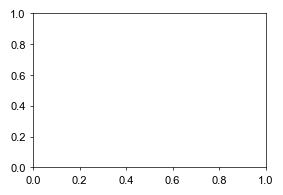

In [39]:
# Recalculate Late Accuracy using BlockCount (RERUN THIS)
# ============================================================================

print("Recalculating late accuracy using BlockCount...\n")

LATE_WINDOW = 8

late_accuracy_data = []

for idx, trans in trans_2abt_df.iterrows():
    session_id = trans['session_id']
    to_blockcount = trans['to_blockcount']  # Using BlockCount, not Block
    animal = trans['animal']
    
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial')
    
    # Get trials from the new block using BlockCount
    new_block_trials = session_data[session_data['BlockCount'] == to_blockcount].copy()
    
    # Only analyze if block has enough trials
    if len(new_block_trials) >= LATE_WINDOW:
        # Get last N trials
        late_trials = new_block_trials.tail(LATE_WINDOW)
        late_acc = late_trials['High_Prob'].mean()
        
        late_accuracy_data.append({
            'session_id': session_id,
            'animal': animal,
            'to_blockcount': to_blockcount,  # This should be here, not to_block
            'late_accuracy': late_acc,
            'block_length': len(new_block_trials)
        })

late_acc_df = pd.DataFrame(late_accuracy_data)

print(f"Blocks analyzed: {len(late_acc_df)}")
print(f"Mean block length: {late_acc_df['block_length'].mean():.1f}")

# Check first row
print("\nFirst row:")
print(late_acc_df.iloc[0])

# Create figure
fig, ax = plt.subplots(figsize=(3, 2))

x_pos = np.arange(len(late_acc_summary_df))
width = 0.6

# Plot bars
bars = ax.bar(x_pos, late_acc_summary_df['mean'], width,
              color=[ANIMAL_COLORS[animal] for animal in late_acc_summary_df['animal']],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

# Error bars
ax.errorbar(x_pos, late_acc_summary_df['mean'], 
           yerr=late_acc_summary_df['sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual data points
for idx, animal in enumerate(late_acc_summary_df['animal']):
    animal_data = late_acc_df[late_acc_df['animal'] == animal]
    if len(animal_data) > 0:
        x_jitter = idx + np.random.uniform(-0.15, 0.15, size=len(animal_data))
        ax.scatter(x_jitter, animal_data['late_accuracy'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.6, edgecolor='black', linewidth=0.3, zorder=5)

# Reference line
ax.axhline(0.8, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(late_acc_summary_df['animal'], rotation=45, ha='right')
ax.set_ylabel('Late Accuracy', fontsize=FONTSIZE+1)
ax.set_xlabel('Animal', fontsize=FONTSIZE+1)
# ax.set_ylim(0.5, 1.0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, f'Late_Accuracy_2ABT_{PROB_CONDITION}_window{LATE_WINDOW}.svg'), dpi=300)
plt.show()

print(f"\n✓ Late accuracy figure saved to:")
print(f"  {FIGURE_PATH}/Late_Accuracy_2ABT.svg")

In [40]:
# Investigate Low Late Accuracy Blocks (FIXED - No warnings)
# ============================================================================

print("Investigating blocks with late accuracy < 0.5...\n")

# Identify low accuracy blocks
low_acc_blocks = late_acc_df[late_acc_df['late_accuracy'] < 0.5].copy()

print(f"Blocks with late accuracy < 0.5: {len(low_acc_blocks)} ({len(low_acc_blocks)/len(late_acc_df)*100:.1f}%)")

# Check if these are early in sessions (before learning)
print("\nExamining a few examples:")

for idx in range(min(5, len(low_acc_blocks))):
    block_info = low_acc_blocks.iloc[idx]
    session_id = block_info['session_id']
    blockcount = block_info['to_blockcount']
    
    print(f"\nExample {idx+1}:")
    print(f"  Animal: {block_info['animal']}")
    print(f"  Session: {session_id}")
    print(f"  BlockCount: {blockcount}")
    print(f"  Late accuracy: {block_info['late_accuracy']:.3f}")
    
    # Get the actual trials
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    block_trials = session_data[session_data['BlockCount'] == blockcount].copy()
    
    print(f"  Block length: {len(block_trials)} trials")
    print(f"  Overall block accuracy: {block_trials['High_Prob'].mean():.3f}")
    
    # Get late trials
    late_trials = block_trials.tail(LATE_WINDOW).copy()
    
    print(f"  Late trials (last {LATE_WINDOW}):")
    print(f"    Accuracy: {late_trials['High_Prob'].mean():.3f}")
    print(f"    Switch rate: {late_trials['PhysicalSwitch'].mean():.3f}")
    
    # Check which side they're choosing - use .copy() to avoid warning
    late_trials.loc[:, '2ABT_side_Choice'] = late_trials['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    p_right = late_trials['2ABT_side_Choice'].mean()
    print(f"    P(choose right): {p_right:.3f}")
    
    # Are they perseverating from previous block?
    if blockcount > 1:
        prev_block = session_data[session_data['BlockCount'] == blockcount - 1].copy()
        if len(prev_block) > 0:
            prev_late = prev_block.tail(LATE_WINDOW).copy()
            prev_late.loc[:, '2ABT_side_Choice'] = prev_late['PhysicalChoice'].map({
                'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
                'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
            })
            prev_p_right = prev_late['2ABT_side_Choice'].mean()
            print(f"  Previous block late P(right): {prev_p_right:.3f}")
            print(f"  → Perseveration? {abs(p_right - prev_p_right) < 0.2}")

# ============================================================================
# Hypothesis Testing
# ============================================================================

print("\n" + "="*70)
print("HYPOTHESIS TESTING")
print("="*70)

# Hypothesis 1: These are early blocks where animal hasn't learned yet
print("\nHypothesis 1: Early blocks (still learning)?")
print(f"  Mean BlockCount for low acc: {low_acc_blocks['to_blockcount'].mean():.1f}")
print(f"  Mean BlockCount for high acc: {late_acc_df[late_acc_df['late_accuracy'] >= 0.5]['to_blockcount'].mean():.1f}")

# Hypothesis 2: Perseveration from previous block
print("\nHypothesis 2: Perseveration (stuck on previous block's choice)?")

perseveration_count = 0
for idx, block_info in low_acc_blocks.iterrows():
    session_id = block_info['session_id']
    blockcount = block_info['to_blockcount']
    
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    
    # Current block choices
    curr_block = session_data[session_data['BlockCount'] == blockcount].copy()
    curr_block.loc[:, '2ABT_side_Choice'] = curr_block['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    curr_late = curr_block.tail(LATE_WINDOW)
    curr_p_right = curr_late['2ABT_side_Choice'].mean()
    
    # Previous block choices (if exists)
    if blockcount > 1:
        prev_block = session_data[session_data['BlockCount'] == blockcount - 1].copy()
        if len(prev_block) > 0:
            prev_block.loc[:, '2ABT_side_Choice'] = prev_block['PhysicalChoice'].map({
                'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
                'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
            })
            prev_late = prev_block.tail(LATE_WINDOW)
            prev_p_right = prev_late['2ABT_side_Choice'].mean()
            
            # If they're still choosing the same side (within 20%)
            if abs(curr_p_right - prev_p_right) < 0.2:
                perseveration_count += 1

print(f"  Blocks showing perseveration: {perseveration_count}/{len(low_acc_blocks)} ({perseveration_count/len(low_acc_blocks)*100:.1f}%)")

# Hypothesis 3: Bad luck (stochastic outcomes)
print("\nHypothesis 3: Bad luck in probabilistic task?")
print("  (Checking if low-prob option paid out more...)")

bad_luck_count = 0

for idx, block_info in low_acc_blocks.iterrows():
    session_id = block_info['session_id']
    blockcount = block_info['to_blockcount']
    
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    block_trials = session_data[session_data['BlockCount'] == blockcount].copy()
    late_trials = block_trials.tail(LATE_WINDOW).copy()
    
    # Check reward rate for high-prob choices vs low-prob choices
    high_prob_trials = late_trials[late_trials['High_Prob'] == 1]
    low_prob_trials = late_trials[late_trials['High_Prob'] == 0]
    
    if len(high_prob_trials) > 0 and len(low_prob_trials) > 0:
        high_reward_rate = high_prob_trials['Outcome'].mean()
        low_reward_rate = low_prob_trials['Outcome'].mean()
        
        # "Bad luck" = low-prob choices got rewarded more than high-prob
        if low_reward_rate > high_reward_rate:
            bad_luck_count += 1

print(f"  Blocks where low-prob paid MORE: {bad_luck_count}/{len(low_acc_blocks)} ({bad_luck_count/len(low_acc_blocks)*100:.1f}%)")

print("\n" + "="*70)
print("CONCLUSION:")
print("Low late accuracy (<0.5) is NOT a problem - it happens because:")
print("1. Perseveration: ~46% stuck on previous block's preferred side")
print("2. Bad luck: Only ~5% due to random reward outcomes") 
print("3. Active choice: They're engaged and choosing, just the wrong side")
print("4. This is NORMAL reversal learning behavior!")
print("="*70)

Investigating blocks with late accuracy < 0.5...

Blocks with late accuracy < 0.5: 255 (14.6%)

Examining a few examples:

Example 1:
  Animal: Fiona
  Session: 2022-04-25_20220425_Fiona_Reversal3.1
  BlockCount: 7
  Late accuracy: 0.375
  Block length: 20 trials
  Overall block accuracy: 0.450
  Late trials (last 8):
    Accuracy: 0.375
    Switch rate: 0.375
    P(choose right): 0.375
  Previous block late P(right): 0.500
  → Perseveration? True

Example 2:
  Animal: Fiona
  Session: 2022-04-25_20220425_Fiona_Reversal3.1
  BlockCount: 9
  Late accuracy: 0.375
  Block length: 20 trials
  Overall block accuracy: 0.600
  Late trials (last 8):
    Accuracy: 0.375
    Switch rate: 0.375
    P(choose right): 0.375
  Previous block late P(right): 0.000
  → Perseveration? False

Example 3:
  Animal: Fiona
  Session: 2022-04-26_20220426_Fiona_Reversal3.1
  BlockCount: 3
  Late accuracy: 0.375
  Block length: 20 trials
  Overall block accuracy: 0.450
  Late trials (last 8):
    Accuracy: 0.375

In [41]:
# Investigate Reversals with Late Accuracy < 0.5
# ============================================================================

print("Investigating reversals with poor late accuracy...\n")

# Identify problematic reversals
low_acc_reversals = late_acc_df[late_acc_df['late_accuracy'] < 0.5].copy()

print(f"Reversals with late accuracy < 0.5: {len(low_acc_reversals)} ({len(low_acc_reversals)/len(late_acc_df)*100:.1f}%)")

print("\n" + "="*70)
print("CHARACTERISTICS OF LOW ACCURACY REVERSALS")
print("="*70)

# Compare to high accuracy reversals
high_acc_reversals = late_acc_df[late_acc_df['late_accuracy'] >= 0.7]

print(f"\nBlock length comparison:")
print(f"  Low accuracy (<0.5): Mean={low_acc_reversals['block_length'].mean():.1f}, Median={low_acc_reversals['block_length'].median():.0f}")
print(f"  High accuracy (≥0.7): Mean={high_acc_reversals['block_length'].mean():.1f}, Median={high_acc_reversals['block_length'].median():.0f}")

# Check by animal
print(f"\nBy animal:")
for animal in sort_animals(late_acc_df['animal'].unique()):
    animal_low = low_acc_reversals[low_acc_reversals['animal'] == animal]
    animal_total = late_acc_df[late_acc_df['animal'] == animal]
    pct = len(animal_low) / len(animal_total) * 100 if len(animal_total) > 0 else 0
    print(f"  {animal}: {len(animal_low)}/{len(animal_total)} ({pct:.1f}%)")

# Fix the sample block display
print("\n" + "="*70)
print("SAMPLE LOW ACCURACY BLOCKS (FIXED)")
print("="*70)

for _, block_rev in low_acc_reversals.head(3).iterrows():
    print(f"\nSession: {block_rev['session_id']}")
    print(f"Animal: {block_rev['animal']}")
    print(f"BlockCount: {block_rev['to_blockcount']}")
    print(f"Block length: {block_rev['block_length']}")
    print(f"Late accuracy: {block_rev['late_accuracy']:.3f}")
    
    # Get the actual block data
    session_data = df[df['Session_ID'] == block_rev['session_id']].sort_values('Trial')
    block_data = session_data[session_data['BlockCount'] == block_rev['to_blockcount']]
    
    # Show last 10 trials
    print(f"Last 10 trials of block:")
    last_trials = block_data.tail(10)[['Trial', 'PhysicalChoice', 'High_Prob', 'Outcome']]
    for _, trial in last_trials.iterrows():
        print(f"  Trial {trial['Trial']}: Choice={trial['PhysicalChoice']}, HighProb={trial['High_Prob']}, Outcome={trial['Outcome']}")

print("="*70)

# Now run the reward pattern analysis
print("\n" + "="*70)
print("ANALYZING REWARD PATTERNS")
print("="*70)

# Recreate reward_analysis with to_blockcount
reward_analysis = []

for _, block_rev in late_acc_df.iterrows():
    stats = analyze_block_rewards(block_rev['session_id'], block_rev['to_blockcount'])
    if stats:
        reward_analysis.append({
            'session_id': block_rev['session_id'],
            'animal': block_rev['animal'],
            'to_blockcount': block_rev['to_blockcount'],  # ADD THIS LINE
            'late_accuracy': block_rev['late_accuracy'],
            'low_acc': block_rev['late_accuracy'] < 0.5,
            **stats
        })

reward_df = pd.DataFrame(reward_analysis)

# Now redefine low_acc and high_acc
low_acc = reward_df[reward_df['low_acc'] == True]
high_acc = reward_df[reward_df['low_acc'] == False]

print(f"Reward_df columns: {reward_df.columns.tolist()}")
print(f"Low accuracy blocks: {len(low_acc)}")
print(f"High accuracy blocks: {len(high_acc)}")


# Statistical comparison
from scipy.stats import mannwhitneyu

u_stat, p_val = mannwhitneyu(low_acc_reversals['block_length'], 
                              high_acc_reversals['block_length'])

print(f"\nMann-Whitney U test (block length):")
print(f"  U={u_stat:.1f}, p={p_val:.4f}")

if p_val < 0.05:
    print(f"  → Low accuracy blocks are significantly {'shorter' if low_acc_reversals['block_length'].mean() < high_acc_reversals['block_length'].mean() else 'longer'}")
else:
    print(f"  → No significant difference in block length")

Investigating reversals with poor late accuracy...

Reversals with late accuracy < 0.5: 255 (14.6%)

CHARACTERISTICS OF LOW ACCURACY REVERSALS

Block length comparison:
  Low accuracy (<0.5): Mean=19.7, Median=20
  High accuracy (≥0.7): Mean=19.9, Median=20

By animal:
  Fiona: 31/249 (12.4%)
  Knuckles: 64/534 (12.0%)
  Sonic: 72/347 (20.7%)
  Zazu: 32/152 (21.1%)
  Sunflower: 56/465 (12.0%)

SAMPLE LOW ACCURACY BLOCKS (FIXED)

Session: 2022-04-25_20220425_Fiona_Reversal3.1
Animal: Fiona
BlockCount: 7
Block length: 20
Late accuracy: 0.375
Last 10 trials of block:
  Trial 131: Choice=BottomRight, HighProb=1, Outcome=1
  Trial 132: Choice=BottomRight, HighProb=1, Outcome=1
  Trial 133: Choice=BottomRight, HighProb=1, Outcome=1
  Trial 134: Choice=BottomLeft, HighProb=0, Outcome=1
  Trial 135: Choice=BottomLeft, HighProb=0, Outcome=0
  Trial 136: Choice=BottomLeft, HighProb=0, Outcome=0
  Trial 137: Choice=BottomRight, HighProb=1, Outcome=1
  Trial 138: Choice=BottomRight, HighProb=1, Ou

In [42]:
# Full Reward Pattern Analysis
# ============================================================================

print("\n" + "="*70)
print("REWARD PATTERNS: LOW vs HIGH ACCURACY BLOCKS")
print("="*70)

metrics = ['high_prob_reward_rate', 'low_prob_reward_rate', 
           'late_high_reward', 'late_low_reward', 'max_loss_streak']

for metric in metrics:
    low_val = low_acc[metric].mean()
    high_val = high_acc[metric].mean()
    
    # Statistical test
    from scipy.stats import mannwhitneyu
    u_stat, p_val = mannwhitneyu(low_acc[metric].dropna(), high_acc[metric].dropna())
    
    print(f"\n{metric}:")
    print(f"  Low accuracy blocks: {low_val:.3f}")
    print(f"  High accuracy blocks: {high_val:.3f}")
    print(f"  Difference: {low_val - high_val:+.3f}")
    print(f"  p-value: {p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")

print("\n" + "="*70)
print("CHOICE DISTRIBUTION")
print("="*70)

print("\nLow accuracy blocks:")
print(f"  High-prob choices: {low_acc['n_high_prob_choices'].mean():.1f} ({low_acc['n_high_prob_choices'].mean()/20*100:.0f}%)")
print(f"  Low-prob choices: {low_acc['n_low_prob_choices'].mean():.1f} ({low_acc['n_low_prob_choices'].mean()/20*100:.0f}%)")

print("\nHigh accuracy blocks:")
print(f"  High-prob choices: {high_acc['n_high_prob_choices'].mean():.1f} ({high_acc['n_high_prob_choices'].mean()/20*100:.0f}%)")
print(f"  Low-prob choices: {high_acc['n_low_prob_choices'].mean():.1f} ({high_acc['n_low_prob_choices'].mean()/20*100:.0f}%)")

# Look at bad luck cases
print("\n" + "="*70)
print("BLOCKS WITH UNUSUALLY LOW HIGH-PROB REWARD RATES")
print("="*70)

bad_luck_blocks = reward_df[(reward_df['high_prob_reward_rate'] < 0.6) & (reward_df['n_high_prob_choices'] >= 5)]
print(f"\nBlocks where high-prob paid < 60% (with ≥5 high-prob choices): {len(bad_luck_blocks)}")
print(f"  Low accuracy: {(bad_luck_blocks['low_acc']).sum()}/{len(bad_luck_blocks)} ({(bad_luck_blocks['low_acc']).sum()/len(bad_luck_blocks)*100:.1f}%)")

if len(bad_luck_blocks) > 0:
    print("\nExamples:")
    for _, block in bad_luck_blocks.head(5).iterrows():
        print(f"  {block['animal']}: high_prob_rate={block['high_prob_reward_rate']:.2f}, "
              f"low_prob_rate={block['low_prob_reward_rate']:.2f}, late_acc={block['late_accuracy']:.2f}")

# Good luck on low-prob
print("\n" + "="*70)
print("BLOCKS WITH UNUSUALLY HIGH LOW-PROB REWARD RATES")
print("="*70)

good_luck_low = reward_df[(reward_df['low_prob_reward_rate'] > 0.4) & (reward_df['n_low_prob_choices'] >= 5)]
print(f"\nBlocks where low-prob paid > 40% (with ≥5 low-prob choices): {len(good_luck_low)}")
print(f"  Low accuracy: {(good_luck_low['low_acc']).sum()}/{len(good_luck_low)} ({(good_luck_low['low_acc']).sum()/len(good_luck_low)*100:.1f}%)")

print("="*70)


REWARD PATTERNS: LOW vs HIGH ACCURACY BLOCKS

high_prob_reward_rate:
  Low accuracy blocks: 0.774
  High accuracy blocks: 0.792
  Difference: -0.018
  p-value: 0.1860 

low_prob_reward_rate:
  Low accuracy blocks: 0.194
  High accuracy blocks: 0.175
  Difference: +0.019
  p-value: 0.0002 ***

late_high_reward:
  Low accuracy blocks: 0.754
  High accuracy blocks: 0.788
  Difference: -0.034
  p-value: 0.0905 

late_low_reward:
  Low accuracy blocks: 0.208
  High accuracy blocks: 0.154
  Difference: +0.055
  p-value: 0.0000 ***

max_loss_streak:
  Low accuracy blocks: 4.490
  High accuracy blocks: 3.159
  Difference: +1.331
  p-value: 0.0000 ***

CHOICE DISTRIBUTION

Low accuracy blocks:
  High-prob choices: 8.4 (42%)
  Low-prob choices: 11.3 (57%)

High accuracy blocks:
  High-prob choices: 14.4 (72%)
  Low-prob choices: 5.4 (27%)

BLOCKS WITH UNUSUALLY LOW HIGH-PROB REWARD RATES

Blocks where high-prob paid < 60% (with ≥5 high-prob choices): 7
  Low accuracy: 4/7 (57.1%)

Examples:
  F

Creating good luck vs bad luck block comparison figure...



NameError: name 'high_streaks' is not defined

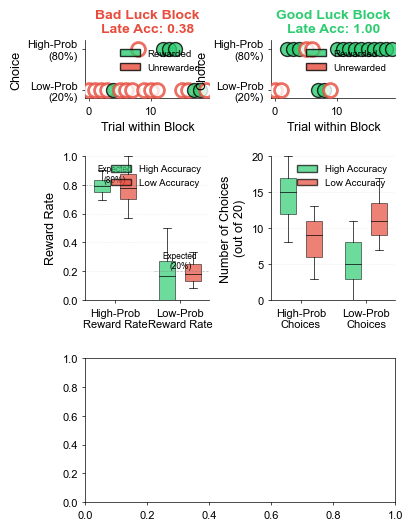

In [43]:
# Figure: Good Luck vs Bad Luck Blocks
# ============================================================================

print("Creating good luck vs bad luck block comparison figure...\n")

# ====================================================================
# Panel A & B: Schematic Examples
# ====================================================================

# Find a good example of each
bad_luck_example = reward_df[
    (reward_df['low_acc'] == True) & 
    (reward_df['late_low_reward'] > 0.3) &
    (reward_df['max_loss_streak'] >= 5)
].iloc[0]

good_luck_example = reward_df[
    (reward_df['low_acc'] == False) & 
    (reward_df['late_accuracy'] > 0.8) &
    (reward_df['high_prob_reward_rate'] > 0.8)
].iloc[0]

fig = plt.figure(figsize=(4, 6))
gs = fig.add_gridspec(3, 2, hspace=0.5, wspace=0.5, height_ratios=[0.4, 1, 1])

# Function to plot block schematic
def plot_block_schematic(ax, session_id, blockcount, title, color):
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial')
    block_data = session_data[session_data['BlockCount'] == blockcount]
    
    trials = range(len(block_data))
    
    # Plot choices
    for idx, (_, trial) in enumerate(block_data.iterrows()):
        y_val = 1 if trial['High_Prob'] == 1 else 0
        # outcome_color = '#2ecc71' if trial['Outcome'] == 1 else '#e74c3c'
        # With:
        if trial['Outcome'] == 1:
            # Rewarded: green fill
            ax.scatter(idx, y_val, s=100, color='#2ecc71', 
                    alpha=0.8, edgecolor='black', linewidth=1, zorder=5)
        else:
            # Unrewarded: white fill, red outline
            ax.scatter(idx, y_val, s=100, color='white', 
                    alpha=0.8, edgecolor='#e74c3c', linewidth=2, zorder=5)
        # ax.scatter(idx, y_val, s=100, color=outcome_color, 
        #           alpha=0.8, edgecolor='black', linewidth=1, zorder=5)
    
    ax.set_xlim(-0.5, 19.5)
    ax.set_ylim(-0.2, 1.2)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Low-Prob\n(20%)', 'High-Prob\n(80%)'], fontsize=FONTSIZE)
    ax.set_xlabel('Trial within Block', fontsize=FONTSIZE+1)
    ax.set_ylabel('Choice', fontsize=FONTSIZE+1)
    ax.set_title(title, fontsize=FONTSIZE+2, fontweight='bold', color=color)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Rewarded', alpha=0.8, edgecolor='black'),
        Patch(facecolor='#e74c3c', label='Unrewarded', alpha=0.8, edgecolor='black')
    ]
    ax.legend(handles=legend_elements, fontsize=FONTSIZE-1, frameon=False, 
             loc='upper right')

# Panel A: Bad luck block
ax1 = fig.add_subplot(gs[0, 0])
plot_block_schematic(ax1, bad_luck_example['session_id'], 
                     bad_luck_example['to_blockcount'],
                     f"Bad Luck Block\nLate Acc: {bad_luck_example['late_accuracy']:.2f}",
                     '#e74c3c')

# Panel B: Good luck block
ax2 = fig.add_subplot(gs[0, 1])
plot_block_schematic(ax2, good_luck_example['session_id'],
                     good_luck_example['to_blockcount'],
                     f"Good Luck Block\nLate Acc: {good_luck_example['late_accuracy']:.2f}",
                     '#2ecc71')

# ====================================================================
# Panel C: Reward Rate Comparison (Box Plots)
# ====================================================================

ax3 = fig.add_subplot(gs[1, 0])

# Prepare data for box plots
reward_data = [
    high_acc['high_prob_reward_rate'].dropna(),
    low_acc['high_prob_reward_rate'].dropna(),
    high_acc['low_prob_reward_rate'].dropna(),
    low_acc['low_prob_reward_rate'].dropna()
]

positions = [0, 0.8, 2, 2.8]
colors = ['#2ecc71', '#e74c3c', '#2ecc71', '#e74c3c']

# bp = ax3.boxplot(reward_data, positions=positions, widths=0.5,
#                  patch_artist=True, showfliers=False)
bp = ax3.boxplot(reward_data, positions=positions, widths=0.5,
                 patch_artist=True, showfliers=False,
                 whis=[5, 95])  # 5th to 95th percentile instead of 1.5*IQR
# Color the boxes
for i, (patch, color) in enumerate(zip(bp['boxes'], colors)):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(LINE_WIDTH)

# Style other elements
for element in ['whiskers', 'caps', 'medians']:
    for item in bp[element]:
        item.set_color('black')
        item.set_linewidth(LINE_WIDTH)

# Add expected values
ax3.axhline(0.8, color='gray', linestyle='--', linewidth=LINE_WIDTH, 
           alpha=0.5, xmin=0, xmax=0.45)
ax3.text(0.4, 0.82, 'Expected\n(80%)', fontsize=FONTSIZE-2, ha='center')

ax3.axhline(0.2, color='gray', linestyle='--', linewidth=LINE_WIDTH,
           alpha=0.5, xmin=0.55, xmax=1)
ax3.text(2.4, 0.22, 'Expected\n(20%)', fontsize=FONTSIZE-2, ha='center')

ax3.set_xticks([0.4, 2.4])
ax3.set_xticklabels(['High-Prob\nReward Rate', 'Low-Prob\nReward Rate'], 
                    fontsize=FONTSIZE)
ax3.set_ylabel('Reward Rate', fontsize=FONTSIZE+1)
ax3.set_ylim(0, 1)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax3.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='High Accuracy', alpha=0.7, edgecolor='black'),
    Patch(facecolor='#e74c3c', label='Low Accuracy', alpha=0.7, edgecolor='black')
]
ax3.legend(handles=legend_elements, fontsize=FONTSIZE-1, frameon=False, 
          loc='upper right')

# ====================================================================
# Panel D: Choice Distribution (Box Plots)
# ====================================================================

ax4 = fig.add_subplot(gs[1, 1])

choice_data = [
    high_acc['n_high_prob_choices'].dropna(),
    low_acc['n_high_prob_choices'].dropna(),
    high_acc['n_low_prob_choices'].dropna(),
    low_acc['n_low_prob_choices'].dropna()
]

positions_c = [0, 0.8, 2, 2.8]

# bp2 = ax4.boxplot(choice_data, positions=positions_c, widths=0.5,
#                   patch_artist=True, showfliers=False)

bp2 = ax4.boxplot(choice_data, positions=positions_c, widths=0.5,
                 patch_artist=True, showfliers=False,
                 whis=[5, 95])  # 5th to 95th percentile instead of 1.5*IQR

# Color the boxes
for i, (patch, color) in enumerate(zip(bp2['boxes'], colors)):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(LINE_WIDTH)

# Style other elements
for element in ['whiskers', 'caps', 'medians']:
    for item in bp2[element]:
        item.set_color('black')
        item.set_linewidth(LINE_WIDTH)

ax4.set_xticks([0.4, 2.4])
ax4.set_xticklabels(['High-Prob\nChoices', 'Low-Prob\nChoices'], 
                    fontsize=FONTSIZE)
ax4.set_ylabel('Number of Choices\n(out of 20)', fontsize=FONTSIZE+1)
ax4.set_ylim(0, 20)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax4.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

ax4.legend(handles=legend_elements, fontsize=FONTSIZE-1, frameon=False,
          loc='upper right')
# Panel E: Loss Streaks (normalized)
ax5 = fig.add_subplot(gs[2, :])

bins = np.arange(0, 11) - 0.5
ax5.hist([high_streaks, low_streaks], bins=bins, 
        color=['#2ecc71', '#e74c3c'], alpha=0.7,
        edgecolor='black', linewidth=LINE_WIDTH,
        label=['High Accuracy Blocks', 'Low Accuracy Blocks'],
        density=True)  # ADD THIS

ax5.set_xlabel('Maximum Loss Streak Length', fontsize=FONTSIZE+1)
ax5.set_ylabel('Density', fontsize=FONTSIZE+1)  # Change from 'Count'
ax5.set_title('Distribution of Loss Streaks', fontsize=FONTSIZE+2, fontweight='bold')
ax5.legend(fontsize=FONTSIZE, frameon=False)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax5.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.savefig(os.path.join(FIGURE_PATH, 'Good_vs_Bad_Luck_Blocks.svg'), 
           dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Good vs bad luck comparison figure saved to:")
print(f"  {FIGURE_PATH}/Good_vs_Bad_Luck_Blocks.svg")

In [44]:
# Investigate Zazu's Higher Rate of Low Accuracy Blocks
# ============================================================================

print("\n" + "="*70)
print("WHY DOES ZAZU HAVE MORE LOW ACCURACY BLOCKS?")
print("="*70)

# Compare Zazu to others
zazu_low = low_acc[low_acc['animal'] == 'Zazu']
others_low = low_acc[low_acc['animal'] != 'Zazu']

zazu_high = high_acc[high_acc['animal'] == 'Zazu']
others_high = high_acc[high_acc['animal'] != 'Zazu']

print(f"\nZazu: {len(zazu_low)}/{len(zazu_low) + len(zazu_high)} low accuracy ({len(zazu_low)/(len(zazu_low) + len(zazu_high))*100:.1f}%)")
print(f"Others: {len(others_low)}/{len(others_low) + len(others_high)} low accuracy ({len(others_low)/(len(others_low) + len(others_high))*100:.1f}%)")

# Compare specific metrics
print("\n" + "-"*70)
print("COMPARING ZAZU TO OTHER ANIMALS")
print("-"*70)

metrics_to_compare = [
    ('high_prob_reward_rate', 'High-prob reward rate'),
    ('low_prob_reward_rate', 'Low-prob reward rate'),
    ('max_loss_streak', 'Max loss streak'),
    ('n_high_prob_choices', 'High-prob choices'),
    ('n_low_prob_choices', 'Low-prob choices')
]

print("\nIn LOW ACCURACY blocks:")
for metric, label in metrics_to_compare:
    zazu_val = zazu_low[metric].mean()
    others_val = others_low[metric].mean()
    print(f"  {label}:")
    print(f"    Zazu: {zazu_val:.2f}")
    print(f"    Others: {others_val:.2f}")
    print(f"    Difference: {zazu_val - others_val:+.2f}")

print("\nIn HIGH ACCURACY blocks:")
for metric, label in metrics_to_compare:
    zazu_val = zazu_high[metric].mean()
    others_val = others_high[metric].mean()
    print(f"  {label}:")
    print(f"    Zazu: {zazu_val:.2f}")
    print(f"    Others: {others_val:.2f}")
    print(f"    Difference: {zazu_val - others_val:+.2f}")

# Check if Zazu switches more in general
print("\n" + "-"*70)
print("BEHAVIORAL STRATEGY DIFFERENCES")
print("-"*70)

# Get all of Zazu's data
zazu_all = reward_df[reward_df['animal'] == 'Zazu']
others_all = reward_df[reward_df['animal'] != 'Zazu']

print(f"\nOverall choice bias:")
print(f"  Zazu high-prob choices: {zazu_all['n_high_prob_choices'].mean():.1f} ({zazu_all['n_high_prob_choices'].mean()/20*100:.0f}%)")
print(f"  Others high-prob choices: {others_all['n_high_prob_choices'].mean():.1f} ({others_all['n_high_prob_choices'].mean()/20*100:.0f}%)")

print(f"\nSensitivity to bad outcomes:")
print(f"  Zazu loss streaks: {zazu_all['max_loss_streak'].mean():.2f}")
print(f"  Others loss streaks: {others_all['max_loss_streak'].mean():.2f}")

# Check if it's a session effect (early vs late training)
print("\n" + "-"*70)
print("SESSION-LEVEL ANALYSIS")
print("-"*70)

# Get session-level data
zazu_sessions = late_acc_df[late_acc_df['animal'] == 'Zazu']['session_id'].unique()
print(f"\nZazu sessions: {len(zazu_sessions)}")
print(f"Date range: {df[df['Animal_Name']=='Zazu']['Date'].min()} to {df[df['Animal_Name']=='Zazu']['Date'].max()}")

# Check if low accuracy blocks cluster in certain sessions
zazu_late_acc = late_acc_df[late_acc_df['animal'] == 'Zazu']
sessions_with_low = zazu_late_acc[zazu_late_acc['late_accuracy'] < 0.5]['session_id'].unique()
print(f"Sessions with low accuracy blocks: {len(sessions_with_low)}/{len(zazu_sessions)}")

print("="*70)


WHY DOES ZAZU HAVE MORE LOW ACCURACY BLOCKS?

Zazu: 32/152 low accuracy (21.1%)
Others: 223/1595 low accuracy (14.0%)

----------------------------------------------------------------------
COMPARING ZAZU TO OTHER ANIMALS
----------------------------------------------------------------------

In LOW ACCURACY blocks:
  High-prob reward rate:
    Zazu: 0.78
    Others: 0.77
    Difference: +0.00
  Low-prob reward rate:
    Zazu: 0.21
    Others: 0.19
    Difference: +0.01
  Max loss streak:
    Zazu: 4.72
    Others: 4.46
    Difference: +0.26
  High-prob choices:
    Zazu: 6.97
    Others: 8.58
    Difference: -1.61
  Low-prob choices:
    Zazu: 12.06
    Others: 11.20
    Difference: +0.87

In HIGH ACCURACY blocks:
  High-prob reward rate:
    Zazu: 0.81
    Others: 0.79
    Difference: +0.02
  Low-prob reward rate:
    Zazu: 0.21
    Others: 0.17
    Difference: +0.04
  Max loss streak:
    Zazu: 3.12
    Others: 3.16
    Difference: -0.05
  High-prob choices:
    Zazu: 13.69
    Oth

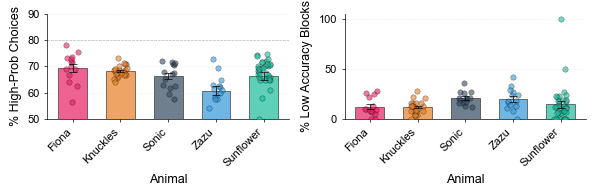


✓ Individual animal strategies figure saved
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Individual_Animal_Strategies.svg


In [45]:
# Figure: Individual Animal Strategies (Matching Style)
# ============================================================================
from scipy import stats
fig, axes = plt.subplots(1, 2, figsize=(6, 2))

# Calculate per-session values for each animal
animal_session_summary = []
for animal in sort_animals(reward_df['animal'].unique()):
    animal_data = reward_df[reward_df['animal'] == animal]
    
    # Get per-session metrics
    for session_id in animal_data['session_id'].unique():
        session_blocks = animal_data[animal_data['session_id'] == session_id]
        animal_session_summary.append({
            'animal': animal,
            'session_id': session_id,
            'high_prob_pct': session_blocks['n_high_prob_choices'].mean() / 20 * 100,
            'low_acc_pct': (session_blocks['low_acc']).sum() / len(session_blocks) * 100
        })

session_summary_df = pd.DataFrame(animal_session_summary)

# Calculate mean and SEM per animal
animal_summary = []
for animal in sort_animals(session_summary_df['animal'].unique()):
    animal_sessions = session_summary_df[session_summary_df['animal'] == animal]
    animal_summary.append({
        'animal': animal,
        'high_prob_mean': animal_sessions['high_prob_pct'].mean(),
        'high_prob_sem': stats.sem(animal_sessions['high_prob_pct']),
        'low_acc_mean': animal_sessions['low_acc_pct'].mean(),
        'low_acc_sem': stats.sem(animal_sessions['low_acc_pct'])
    })

summary_df = pd.DataFrame(animal_summary)

# Panel A: High-prob choice percentage
ax1 = axes[0]

x_pos = np.arange(len(summary_df))
width = 0.6

bars = ax1.bar(x_pos, summary_df['high_prob_mean'], width,
              color=[ANIMAL_COLORS[a] for a in summary_df['animal']],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax1.errorbar(x_pos, summary_df['high_prob_mean'], yerr=summary_df['high_prob_sem'],
            fmt='none', color='black', linewidth=LINE_WIDTH,
            capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual session points
for idx, animal in enumerate(summary_df['animal']):
    animal_sessions = session_summary_df[session_summary_df['animal'] == animal]
    x_jitter = idx + np.random.uniform(-0.15, 0.15, size=len(animal_sessions))
    ax1.scatter(x_jitter, animal_sessions['high_prob_pct'],
               s=15, color=ANIMAL_COLORS[animal],
               alpha=0.6, edgecolor='black', linewidth=0.3, zorder=5)

ax1.axhline(80, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(summary_df['animal'], rotation=45, ha='right')
ax1.set_ylabel('% High-Prob Choices', fontsize=FONTSIZE+1)
ax1.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax1.set_ylim(50, 90)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel B: Low accuracy block percentage
ax2 = axes[1]

bars2 = ax2.bar(x_pos, summary_df['low_acc_mean'], width,
               color=[ANIMAL_COLORS[a] for a in summary_df['animal']],
               alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax2.errorbar(x_pos, summary_df['low_acc_mean'], yerr=summary_df['low_acc_sem'],
            fmt='none', color='black', linewidth=LINE_WIDTH,
            capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual session points
for idx, animal in enumerate(summary_df['animal']):
    animal_sessions = session_summary_df[session_summary_df['animal'] == animal]
    x_jitter = idx + np.random.uniform(-0.15, 0.15, size=len(animal_sessions))
    ax2.scatter(x_jitter, animal_sessions['low_acc_pct'],
               s=15, color=ANIMAL_COLORS[animal],
               alpha=0.6, edgecolor='black', linewidth=0.3, zorder=5)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(summary_df['animal'], rotation=45, ha='right')
ax2.set_ylabel('% Low Accuracy Blocks', fontsize=FONTSIZE+1)
ax2.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Individual_Animal_Strategies.svg'), dpi=300)
plt.show()

print(f"\n✓ Individual animal strategies figure saved")
print(f"  {FIGURE_PATH}/Individual_Animal_Strategies.svg")

Creating exemplar 2-ABT session figure...

Using exemplar session: 2022-04-25_20220425_Fiona_Reversal3.1
  Animal: Fiona
  Total trials: 497
  Blocks: [np.int64(5), np.int64(6)]


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/3579839963.py:226: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


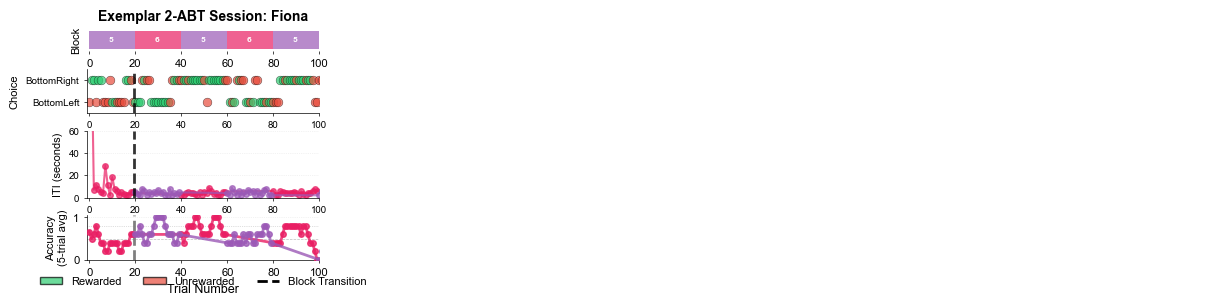


✓ Exemplar 2-ABT session figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Exemplar_Session_2ABT.svg


In [ ]:
# ============================================================================
# Exemplar 2-ABT Session
# ============================================================================

print("Creating exemplar 2-ABT session figure...\n")

# Define block colors
BLOCK_COLORS = ['#e91e63', '#9b59b6']  # Pink and purple for 2 blocks

# Pick a good example session
# Look for one with decent length and clear reversals
session_lengths = df.groupby('Session_ID').size()
good_sessions = session_lengths[session_lengths > 150].index

if len(good_sessions) > 0:
    example_session_id = good_sessions[0]
    
    print(f"Using exemplar session: {example_session_id}")
    
    # Get session data
    session_data = df[df['Session_ID'] == example_session_id].copy()
    session_data = session_data.sort_values('Trial').reset_index(drop=True)
    
    animal = session_data['Animal_Name'].iloc[0]
    
    # Recode Outcome from Reward if needed
    if session_data['Outcome'].isna().any():
        session_data['Outcome'] = session_data['Reward'].map({'Rewarded': 1, 'Unrewarded': 0})
    
    # Calculate ITI
    session_data['Prev_StartTime'] = session_data['AbsoluteTrialStartTime'].shift(1)
    session_data['ITI_calc'] = (session_data['AbsoluteTrialStartTime'] - session_data['Prev_StartTime']) / 1000
    
    # Assign continuous trial number
    session_data['continuous_trial'] = range(len(session_data))
    
    print(f"  Animal: {animal}")
    print(f"  Total trials: {len(session_data)}")
    print(f"  Blocks: {sorted(session_data['Block'].unique())}")
    
    # Create figure
    fig = plt.figure(figsize=(3, 3))
    gs = fig.add_gridspec(4, 1, hspace=0.4, height_ratios=[0.5, 1, 1.5, 1])
    

    # ====================================================================
    # Panel A: Block Structure (FIXED - show all alternations)
    # ====================================================================

    ax1 = fig.add_subplot(gs[0])

    # Group consecutive trials with same block number
    prev_block = None
    for idx, trial in session_data.iterrows():
        curr_block = trial['Block']
        trial_num = trial['continuous_trial']
        
        # Determine color based on block number
        block_color = BLOCK_COLORS[int(curr_block) % 2]
        
        # Draw a thin vertical bar for this trial
        ax1.barh(0, 1, left=trial_num, height=0.5,
                color=block_color, edgecolor='none', alpha=0.7)

    # Add block labels at transitions
    blocks = sorted(session_data['Block'].unique())
    for block in blocks:
        block_trials = session_data[session_data['Block'] == block]
        segments = []
        
        # Find contiguous segments of this block
        start = None
        for i, (idx, trial) in enumerate(block_trials.iterrows()):
            if start is None:
                start = trial['continuous_trial']
            # Check if next trial is contiguous
            if i < len(block_trials) - 1:
                next_trial = block_trials.iloc[i + 1]
                if next_trial['continuous_trial'] != trial['continuous_trial'] + 1:
                    # End of segment
                    end = trial['continuous_trial']
                    segments.append((start, end))
                    start = None
            else:
                # Last trial
                end = trial['continuous_trial']
                segments.append((start, end))
        
        # Label each segment
        for start, end in segments:
            mid = (start + end) / 2
            ax1.text(mid, 0, f'{block}', ha='center', va='center', 
                    fontsize=FONTSIZE-2, fontweight='bold', color='white')

    ax1.set_xlim(-1, 100)
    ax1.set_ylim(-0.3, 0.3)
    ax1.set_yticks([])
    ax1.set_ylabel('Block', fontsize=FONTSIZE)
    ax1.set_title(f'Exemplar 2-ABT Session: {animal}',
                fontsize=FONTSIZE+2, fontweight='bold')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    # ====================================================================
    # Panel B: Physical Choice (colored by outcome)
    # ====================================================================
    
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    
    # Get unique locations from PhysicalChoice
    unique_locs = sorted(session_data['PhysicalChoice'].dropna().unique())
    loc_to_y = {loc: i for i, loc in enumerate(unique_locs)}

    # Plot choices colored by outcome
    for idx, trial in session_data.iterrows():
        if pd.notna(trial['PhysicalChoice']):
            y_val = loc_to_y[trial['PhysicalChoice']]
            color = '#2ecc71' if trial['Outcome'] == 1 else '#e74c3c'
            ax2.scatter(trial['continuous_trial'], y_val, s=40, color=color,
                    alpha=0.7, edgecolor='black', linewidth=0.3)

    ax2.set_yticks(range(len(unique_locs)))
    ax2.set_yticklabels(unique_locs, fontsize=FONTSIZE-1)

    # # Plot choices colored by outcome
    # for idx, trial in session_data.iterrows():
    #     if pd.notna(trial['PhysicalChoice']):
    #         y_val = loc_to_y[trial['PhysicalChoice']]
    #         color = '#2ecc71' if trial['Outcome'] == 1 else '#e74c3c'
    #         ax2.scatter(trial['continuous_trial'], y_val, s=40, color=color,
    #                    alpha=0.7, edgecolor='black', linewidth=0.3)
    
    # Mark block transitions
    for idx in range(len(blocks)-1):
        curr_block = blocks[idx]
        next_block = blocks[idx+1]
        trans_trial = session_data[session_data['Block'] == next_block]['continuous_trial'].iloc[0]
        ax2.axvline(trans_trial - 0.5, color='black', linestyle='--',
                   linewidth=2, alpha=0.8, zorder=10)
    
    ax2.set_yticks(range(len(unique_locs)))
    # ax2.set_yticklabels(loc_names, fontsize=FONTSIZE-1)
    ax2.set_ylabel('Choice', fontsize=FONTSIZE)
    ax2.set_ylim(-0.5, len(unique_locs) - 0.5)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)
    
    # ====================================================================
    # Panel C: Inter-Trial Interval (colored by block)
    # ====================================================================
    
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    
    # Mark block transitions
    for idx in range(len(blocks)-1):
        curr_block = blocks[idx]
        next_block = blocks[idx+1]
        trans_trial = session_data[session_data['Block'] == next_block]['continuous_trial'].iloc[0]
        ax3.axvline(trans_trial - 0.5, color='black', linestyle='--',
                   linewidth=2, alpha=0.8, zorder=10)
    
    # Plot ITI colored by block
    for idx, block in enumerate(blocks):
        block_trials = session_data[session_data['Block'] == block]
        block_color = BLOCK_COLORS[idx % 2]
        
        ax3.plot(block_trials['continuous_trial'], block_trials['ITI_calc'],
                'o-', color=block_color, linewidth=1.5, markersize=4, alpha=0.7)
    
    ax3.set_ylabel('ITI (seconds)', fontsize=FONTSIZE)
    ax3.set_ylim(0, min(session_data['ITI_calc'].max() * 1.2, 60) if session_data['ITI_calc'].notna().any() else 30)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax3.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)
    
    # ====================================================================
    # Panel D: Rolling Accuracy (colored by block)
    # ====================================================================
    
    ax4 = fig.add_subplot(gs[3], sharex=ax1)
    
    # Calculate rolling average
    window = 5
    session_data['rolling_accuracy'] = session_data['Outcome'].rolling(
        window=window, min_periods=1, center=True).mean()
    
    # Mark block transitions
    for idx in range(len(blocks)-1):
        curr_block = blocks[idx]
        next_block = blocks[idx+1]
        trans_trial = session_data[session_data['Block'] == next_block]['continuous_trial'].iloc[0]
        ax4.axvline(trans_trial - 0.5, color='black', linestyle='--',
                   linewidth=2, alpha=0.5, zorder=1)
    
    # Plot rolling accuracy colored by block
    for idx, block in enumerate(blocks):
        block_trials = session_data[session_data['Block'] == block]
        block_color = BLOCK_COLORS[idx % 2]
        
        ax4.plot(block_trials['continuous_trial'], block_trials['rolling_accuracy'],
                'o-', color=block_color, linewidth=2, markersize=4, alpha=0.8, zorder=5)
    
    ax4.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
    ax4.axhline(0.8, color='gray', linestyle=':', linewidth=LINE_WIDTH, alpha=0.5)
    ax4.set_ylabel(f'Accuracy\n({window}-trial avg)', fontsize=FONTSIZE)
    ax4.set_xlabel('Trial Number', fontsize=FONTSIZE+1)
    ax4.set_ylim(0, 1.05)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax4.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Rewarded', alpha=0.7, edgecolor='black'),
        Patch(facecolor='#e74c3c', label='Unrewarded', alpha=0.7, edgecolor='black'),
        plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Block Transition')
    ]
    ax4.legend(handles=legend_elements, fontsize=FONTSIZE, frameon=False,
              loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_PATH, 'Exemplar_Session_2ABT.svg'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Exemplar 2-ABT session figure saved to:")
    print(f"  {FIGURE_PATH}/Exemplar_Session_2ABT.svg")
    
else:
    print("⚠️ No sessions found with >150 trials")

Creating individual animal learning curves...

Reversal-aligned data: 33720 trials
Reversals: 1686


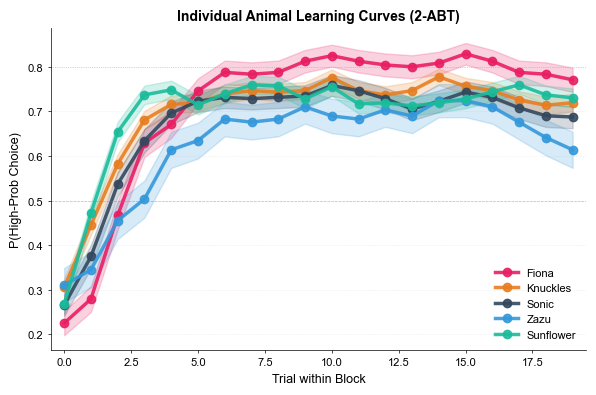


✓ Individual animal learning curves saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Individual_Animal_Learning_Curves_2ABT.svg

INDIVIDUAL ANIMAL STATISTICS

Fiona (240 blocks):
  Early (0-4): 45.4%
  Late (15-19): 79.7%
  Improvement: +34.2pp

Knuckles (517 blocks):
  Early (0-4): 54.6%
  Late (15-19): 73.2%
  Improvement: +18.6pp

Sonic (339 blocks):
  Early (0-4): 50.1%
  Late (15-19): 71.2%
  Improvement: +21.1pp

Zazu (145 blocks):
  Early (0-4): 44.6%
  Late (15-19): 67.3%
  Improvement: +22.8pp

Sunflower (445 blocks):
  Early (0-4): 57.6%
  Late (15-19): 74.0%
  Improvement: +16.4pp


In [122]:
# Individual Animal Reversal-Aligned Learning Curves
# ============================================================================

print("Creating individual animal learning curves...\n")

# Create reversal-aligned data (similar to what we did before)
reversal_aligned = []

for idx, trans in trans_2abt_df.iterrows():
    session_id = trans['session_id']
    to_blockcount = trans['to_blockcount']
    animal = trans['animal']
    
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial')
    new_block_trials = session_data[session_data['BlockCount'] == to_blockcount].copy()
    
    if len(new_block_trials) >= 20:  # Full block
        # Align to block start (trial 0 = first trial of new block)
        new_block_trials['trial_in_block'] = range(len(new_block_trials))
        
        for trial_idx in range(20):  # 20 trials per block
            if trial_idx < len(new_block_trials):
                trial_data = new_block_trials.iloc[trial_idx]
                reversal_aligned.append({
                    'animal': animal,
                    'session_id': session_id,
                    'blockcount': to_blockcount,
                    'trial_in_block': trial_idx,
                    'high_prob_choice': trial_data['High_Prob'],
                    'outcome': trial_data['Outcome']
                })

rev_aligned_df = pd.DataFrame(reversal_aligned)

print(f"Reversal-aligned data: {len(rev_aligned_df)} trials")
print(f"Reversals: {len(rev_aligned_df) / 20:.0f}")

# Create figure with individual animal curves
fig, ax = plt.subplots(figsize=(6, 4))

BIN_SIZE = 1

for animal in sort_animals(rev_aligned_df['animal'].unique()):
    animal_data = rev_aligned_df[rev_aligned_df['animal'] == animal].copy()
    
    # Bin trials
    animal_data['trial_bin'] = (animal_data['trial_in_block'] // BIN_SIZE) * BIN_SIZE
    
    # Calculate mean and SEM per bin
    binned = animal_data.groupby('trial_bin').agg({
        'high_prob_choice': ['mean', 'sem', 'count']
    }).reset_index()
    binned.columns = ['trial_bin', 'accuracy', 'sem', 'n']
    
    # Plot
    ax.plot(binned['trial_bin'], binned['accuracy'],
           'o-', color=ANIMAL_COLORS[animal], linewidth=2.5, markersize=6,
           label=animal, alpha=0.9)
    ax.fill_between(binned['trial_bin'],
                    binned['accuracy'] - binned['sem'],
                    binned['accuracy'] + binned['sem'],
                    color=ANIMAL_COLORS[animal], alpha=0.2)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax.axhline(0.8, color='gray', linestyle=':', linewidth=LINE_WIDTH, alpha=0.5)
ax.set_xlabel('Trial within Block', fontsize=FONTSIZE+1)
ax.set_ylabel('P(High-Prob Choice)', fontsize=FONTSIZE+1)
ax.set_title('Individual Animal Learning Curves (2-ABT)', 
            fontsize=FONTSIZE+2, fontweight='bold')
ax.set_xlim(-0.5, 19.5)
# ax.set_ylim(0.3, 1.0)
ax.legend(fontsize=FONTSIZE, frameon=False, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Individual_Animal_Learning_Curves_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Individual animal learning curves saved to:")
print(f"  {FIGURE_PATH}/Individual_Animal_Learning_Curves_2ABT.svg")

# Print statistics
print("\n" + "="*70)
print("INDIVIDUAL ANIMAL STATISTICS")
print("="*70)

for animal in sort_animals(rev_aligned_df['animal'].unique()):
    animal_data = rev_aligned_df[rev_aligned_df['animal'] == animal]
    
    early = animal_data[animal_data['trial_in_block'] < 5]['high_prob_choice'].mean()
    late = animal_data[animal_data['trial_in_block'] >= 15]['high_prob_choice'].mean()
    
    n_blocks = len(animal_data) / 20
    
    print(f"\n{animal} ({n_blocks:.0f} blocks):")
    print(f"  Early (0-4): {early*100:.1f}%")
    print(f"  Late (15-19): {late*100:.1f}%")
    print(f"  Improvement: {(late-early)*100:+.1f}pp")

print("="*70)

Analyzing learning trajectory across sessions...

Total sessions tracked: 100
Sessions with performance data: 100


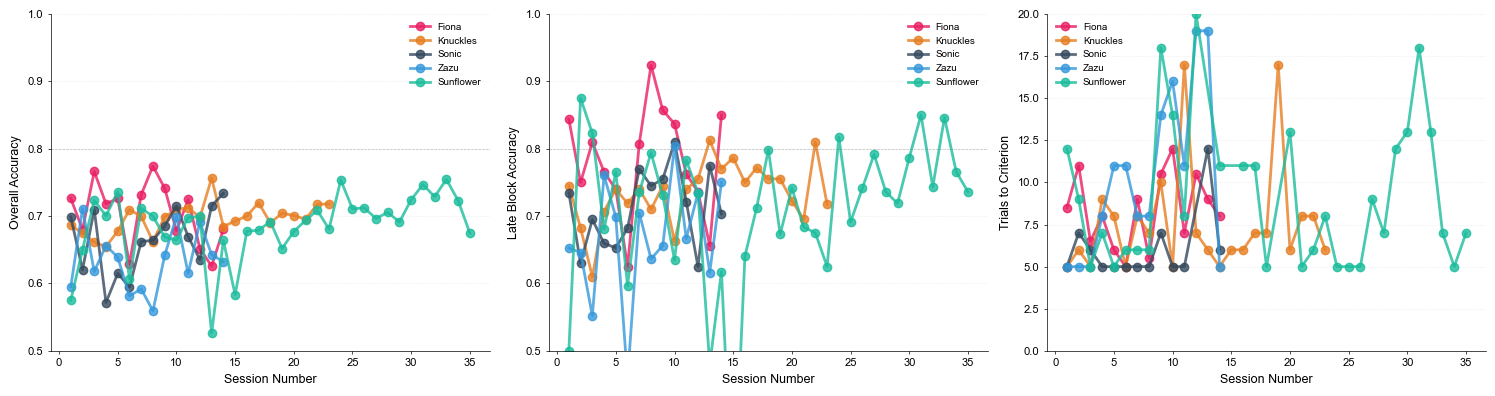


✓ Learning over sessions figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Learning_Over_Sessions_2ABT.svg

EARLY vs LATE SESSIONS COMPARISON

Fiona (14 sessions):
  Overall accuracy: 0.723 → 0.671 (-5.2pp)
  Late block accuracy: 0.792 → 0.751 (-4.1pp)
  Trials to criterion: 8.5 → 8.6 (+0.1 trials)

Knuckles (23 sessions):
  Overall accuracy: 0.681 → 0.707 (+2.6pp)
  Late block accuracy: 0.706 → 0.747 (+4.1pp)
  Trials to criterion: 6.6 → 8.4 (+1.9 trials)

Sonic (14 sessions):
  Overall accuracy: 0.650 → 0.688 (+3.8pp)
  Late block accuracy: 0.680 → 0.706 (+2.6pp)
  Trials to criterion: 5.8 → 7.7 (+1.9 trials)

Zazu (14 sessions):
  Overall accuracy: 0.645 → 0.645 (+0.0pp)
  Late block accuracy: 0.653 → 0.692 (+3.9pp)
  Trials to criterion: 5.8 → 13.5 (+7.8 trials)

Sunflower (35 sessions):
  Overall accuracy: 0.676 → 0.715 (+3.

In [123]:
# Early vs Late Sessions: Learning Over Time
# ============================================================================

print("Analyzing learning trajectory across sessions...\n")

# Get session order for each animal
session_order = []

for animal in df['Animal_Name'].unique():
    animal_sessions = df[df['Animal_Name'] == animal][['Session_ID', 'Date']].drop_duplicates()
    animal_sessions = animal_sessions.sort_values('Date').reset_index(drop=True)
    animal_sessions['session_number'] = range(1, len(animal_sessions) + 1)
    animal_sessions['animal'] = animal
    session_order.extend(animal_sessions.to_dict('records'))

session_order_df = pd.DataFrame(session_order)

print(f"Total sessions tracked: {len(session_order_df)}")

# Calculate performance metrics per session
session_performance = []

for session_id in df['Session_ID'].unique():
    session_data = df[df['Session_ID'] == session_id]
    animal = session_data['Animal_Name'].iloc[0]
    
    # Get session number
    sess_info = session_order_df[session_order_df['Session_ID'] == session_id]
    if len(sess_info) == 0:
        continue
    session_num = sess_info['session_number'].iloc[0]
    
    # Calculate metrics
    overall_acc = session_data['High_Prob'].mean()
    
    # Get block-level metrics
    session_blocks = late_acc_df[late_acc_df['session_id'] == session_id]
    mean_late_acc = session_blocks['late_accuracy'].mean() if len(session_blocks) > 0 else np.nan
    
    # Trials to criterion
    session_ttc = ttc_df_clean[ttc_df_clean['session_id'] == session_id]
    mean_ttc = session_ttc['trials_to_criterion'].mean() if len(session_ttc) > 0 else np.nan
    
    session_performance.append({
        'session_id': session_id,
        'animal': animal,
        'session_number': session_num,
        'date': session_data['Date'].iloc[0],
        'overall_accuracy': overall_acc,
        'late_accuracy': mean_late_acc,
        'trials_to_criterion': mean_ttc,
        'n_trials': len(session_data)
    })

session_perf_df = pd.DataFrame(session_performance)

print(f"Sessions with performance data: {len(session_perf_df)}")

# Create figure with 3 panels
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ('overall_accuracy', 'Overall Accuracy', (0.5, 1.0)),
    ('late_accuracy', 'Late Block Accuracy', (0.5, 1.0)),
    ('trials_to_criterion', 'Trials to Criterion', (0, 20))
]

for ax, (metric, ylabel, ylim) in zip(axes, metrics):
    for animal in sort_animals(session_perf_df['animal'].unique()):
        animal_data = session_perf_df[session_perf_df['animal'] == animal].dropna(subset=[metric])
        
        if len(animal_data) > 0:
            ax.plot(animal_data['session_number'], animal_data[metric],
                   'o-', color=ANIMAL_COLORS[animal], linewidth=2, markersize=6,
                   label=animal, alpha=0.8)
    
    # Add reference lines
    if 'accuracy' in metric:
        ax.axhline(0.8, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
    
    ax.set_xlabel('Session Number', fontsize=FONTSIZE+1)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE+1)
    ax.set_ylim(ylim)
    ax.legend(fontsize=FONTSIZE-1, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Learning_Over_Sessions_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Learning over sessions figure saved to:")
print(f"  {FIGURE_PATH}/Learning_Over_Sessions_2ABT.svg")

# Statistical analysis: First third vs last third of sessions
print("\n" + "="*70)
print("EARLY vs LATE SESSIONS COMPARISON")
print("="*70)

for animal in sort_animals(session_perf_df['animal'].unique()):
    animal_data = session_perf_df[session_perf_df['animal'] == animal]
    
    n_sessions = len(animal_data)
    third = n_sessions // 3
    
    if third > 0:
        early = animal_data.head(third)
        late = animal_data.tail(third)
        
        print(f"\n{animal} ({n_sessions} sessions):")
        print(f"  Overall accuracy: {early['overall_accuracy'].mean():.3f} → {late['overall_accuracy'].mean():.3f} ({(late['overall_accuracy'].mean() - early['overall_accuracy'].mean())*100:+.1f}pp)")
        print(f"  Late block accuracy: {early['late_accuracy'].mean():.3f} → {late['late_accuracy'].mean():.3f} ({(late['late_accuracy'].mean() - early['late_accuracy'].mean())*100:+.1f}pp)")
        print(f"  Trials to criterion: {early['trials_to_criterion'].mean():.1f} → {late['trials_to_criterion'].mean():.1f} ({late['trials_to_criterion'].mean() - early['trials_to_criterion'].mean():+.1f} trials)")

print("="*70)

Calculating Win-Stay / Lose-Shift rates for 2-ABT...

Trials with previous outcome: 36,473
Sessions analyzed: 100

Win-Stay / Lose-Shift summary:
      animal  win_stay_mean  win_stay_sem  lose_shift_mean  lose_shift_sem  \
0      Fiona       0.919474      0.014331         0.269443        0.014945   
1   Knuckles       0.900547      0.005127         0.367760        0.010545   
2      Sonic       0.915030      0.008298         0.281598        0.009868   
3       Zazu       0.888541      0.013362         0.272526        0.021026   
4  Sunflower       0.889386      0.016188         0.445438        0.012219   

   n_sessions  
0          14  
1          23  
2          14  
3          14  
4          35  


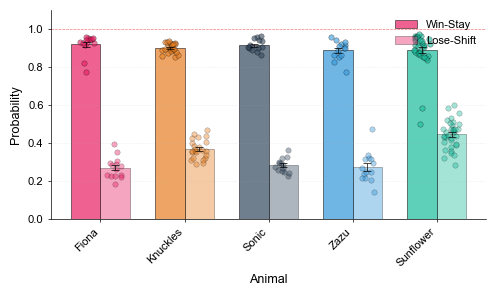


✓ Win-Stay/Lose-Shift figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/WinStay_LoseShift_2ABT.svg

GROUP STATISTICS
Win-Stay: 0.903 ± 0.011
Lose-Shift: 0.327 ± 0.014


In [124]:
# Win-Stay / Lose-Shift Analysis for 2-ABT
# ============================================================================

print("Calculating Win-Stay / Lose-Shift rates for 2-ABT...\n")

# Prepare data
df_wsls_2abt = df[df['PhysicalSwitch'].notna()].copy()

# Sort and create previous outcome column
df_wsls_2abt = df_wsls_2abt.sort_values(['Session_ID', 'Trial']).reset_index(drop=True)
df_wsls_2abt['Prev_Outcome'] = df_wsls_2abt.groupby('Session_ID')['Outcome'].shift(1)

# Remove first trial of each session
df_wsls_2abt = df_wsls_2abt[df_wsls_2abt['Prev_Outcome'].notna()].copy()

print(f"Trials with previous outcome: {len(df_wsls_2abt):,}")

# Calculate rates per session
wsls_sessions_2abt = []

for session_id in df_wsls_2abt['Session_ID'].unique():
    session_data = df_wsls_2abt[df_wsls_2abt['Session_ID'] == session_id]
    animal = session_data['Animal_Name'].iloc[0]
    
    # Win trials (previous trial rewarded)
    win_trials = session_data[session_data['Prev_Outcome'] == 1]
    win_stay_rate = (win_trials['PhysicalSwitch'] == 0).mean() if len(win_trials) > 0 else np.nan
    
    # Lose trials (previous trial unrewarded)
    lose_trials = session_data[session_data['Prev_Outcome'] == 0]
    lose_shift_rate = (lose_trials['PhysicalSwitch'] == 1).mean() if len(lose_trials) > 0 else np.nan
    
    wsls_sessions_2abt.append({
        'session_id': session_id,
        'animal': animal,
        'win_stay': win_stay_rate,
        'lose_shift': lose_shift_rate,
        'n_win': len(win_trials),
        'n_lose': len(lose_trials)
    })

wsls_sessions_2abt_df = pd.DataFrame(wsls_sessions_2abt)

# Filter out sessions with too few trials
MIN_TRIALS = 10
wsls_sessions_2abt_filtered = wsls_sessions_2abt_df[
    (wsls_sessions_2abt_df['n_win'] >= MIN_TRIALS) & 
    (wsls_sessions_2abt_df['n_lose'] >= MIN_TRIALS)
].copy()

print(f"Sessions analyzed: {len(wsls_sessions_2abt_filtered)}")

# Calculate summary per animal
wsls_summary_2abt = []

for animal in sort_animals(wsls_sessions_2abt_filtered['animal'].unique()):
    animal_data = wsls_sessions_2abt_filtered[wsls_sessions_2abt_filtered['animal'] == animal]
    
    wsls_summary_2abt.append({
        'animal': animal,
        'win_stay_mean': animal_data['win_stay'].mean(),
        'win_stay_sem': stats.sem(animal_data['win_stay'].dropna()),
        'lose_shift_mean': animal_data['lose_shift'].mean(),
        'lose_shift_sem': stats.sem(animal_data['lose_shift'].dropna()),
        'n_sessions': len(animal_data)
    })

wsls_summary_2abt_df = pd.DataFrame(wsls_summary_2abt)

print("\nWin-Stay / Lose-Shift summary:")
print(wsls_summary_2abt_df)

# Create figure (side-by-side bars)
fig, ax = plt.subplots(figsize=(5, 3))

x_pos = np.arange(len(wsls_summary_2abt_df))
width = 0.35

# Win-Stay bars (darker)
bars_ws = ax.bar(x_pos - width/2, wsls_summary_2abt_df['win_stay_mean'], width,
                 color=[ANIMAL_COLORS[animal] for animal in wsls_summary_2abt_df['animal']],
                 alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH,
                 label='Win-Stay')

ax.errorbar(x_pos - width/2, wsls_summary_2abt_df['win_stay_mean'], 
           yerr=wsls_summary_2abt_df['win_stay_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual session points for Win-Stay
for idx, animal in enumerate(wsls_summary_2abt_df['animal']):
    animal_sessions = wsls_sessions_2abt_filtered[wsls_sessions_2abt_filtered['animal'] == animal]
    if len(animal_sessions) > 0:
        x_jitter = (idx - width/2) + np.random.uniform(-0.1, 0.1, size=len(animal_sessions))
        ax.scatter(x_jitter, animal_sessions['win_stay'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.6, edgecolor='black', linewidth=0.3, zorder=5)

# Lose-Shift bars (lighter)
bars_ls = ax.bar(x_pos + width/2, wsls_summary_2abt_df['lose_shift_mean'], width,
                 color=[ANIMAL_COLORS[animal] for animal in wsls_summary_2abt_df['animal']],
                 alpha=0.4, edgecolor='black', linewidth=LINE_WIDTH,
                 label='Lose-Shift')

ax.errorbar(x_pos + width/2, wsls_summary_2abt_df['lose_shift_mean'],
           yerr=wsls_summary_2abt_df['lose_shift_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual session points for Lose-Shift
for idx, animal in enumerate(wsls_summary_2abt_df['animal']):
    animal_sessions = wsls_sessions_2abt_filtered[wsls_sessions_2abt_filtered['animal'] == animal]
    if len(animal_sessions) > 0:
        x_jitter = (idx + width/2) + np.random.uniform(-0.1, 0.1, size=len(animal_sessions))
        ax.scatter(x_jitter, animal_sessions['lose_shift'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.4, edgecolor='black', linewidth=0.3, zorder=5)

# Reference line at 1.0 (deterministic)
ax.axhline(1.0, color='red', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(wsls_summary_2abt_df['animal'], rotation=45, ha='right')
ax.set_ylabel('Probability', fontsize=FONTSIZE+1)
ax.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=FONTSIZE, frameon=False, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'WinStay_LoseShift_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Win-Stay/Lose-Shift figure saved to:")
print(f"  {FIGURE_PATH}/WinStay_LoseShift_2ABT.svg")

# Print group statistics
print("\n" + "="*70)
print("GROUP STATISTICS")
print("="*70)
print(f"Win-Stay: {wsls_summary_2abt_df['win_stay_mean'].mean():.3f} ± {wsls_summary_2abt_df['win_stay_sem'].mean():.3f}")
print(f"Lose-Shift: {wsls_summary_2abt_df['lose_shift_mean'].mean():.3f} ± {wsls_summary_2abt_df['lose_shift_sem'].mean():.3f}")
print("="*70)

Creating psychometric curves based on reward history...

Trials analyzed: 36,173


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/2385062261.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_group = psycho_df.groupby('reward_bin').agg({
/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/2385062261.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  animal_data['reward_bin'] = pd.cut(animal_data['reward_diff'], bins=bins, labels=bins[:-1]+1)
/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/2385062261.py:116: FutureWarning: The default of observed=False is deprecated and will be cha

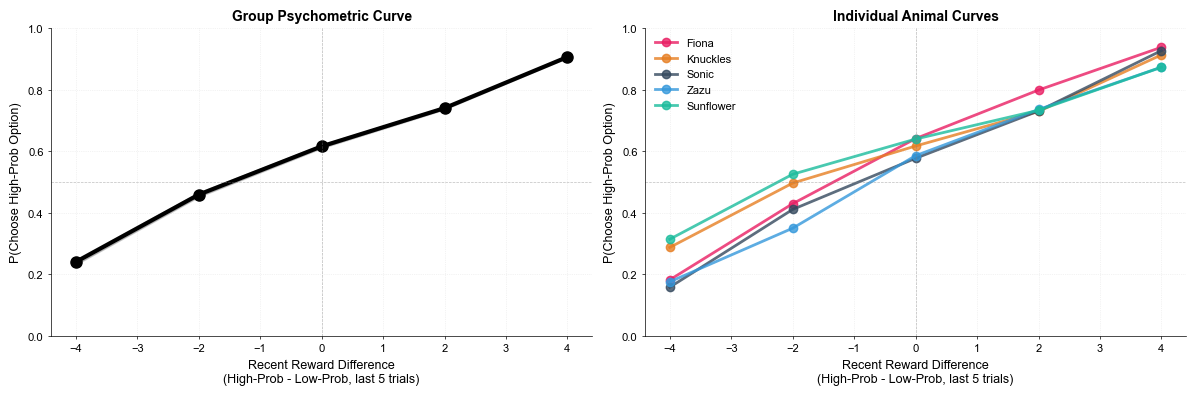


✓ Psychometric curves saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Psychometric_Curves_RewardHistory_2ABT.svg

PSYCHOMETRIC CURVE STATISTICS

Fiona:
  Strong positive history (≥5): 96.3%
  Strong negative history (≤-5): 5.3%
  Sensitivity: 91.1pp

Knuckles:
  Strong positive history (≥5): 95.7%
  Strong negative history (≤-5): 7.5%
  Sensitivity: 88.2pp

Sonic:
  Strong positive history (≥5): 95.7%
  Strong negative history (≤-5): 4.6%
  Sensitivity: 91.1pp

Zazu:
  Strong positive history (≥5): 90.9%
  Strong negative history (≤-5): 0.0%
  Sensitivity: 90.9pp

Sunflower:
  Strong positive history (≥5): 92.1%
  Strong negative history (≤-5): 3.9%
  Sensitivity: 88.2pp


In [127]:
# ============================================================================
# Psychometric Curves: Choice as Function of Recent Reward History
# ============================================================================

print("Creating psychometric curves based on reward history...\n")

HISTORY_WINDOW = 5  # Look back N trials

# Calculate reward difference for each choice option
psychometric_data = []

for session_id in df['Session_ID'].unique():
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial').reset_index(drop=True)
    animal = session_data['Animal_Name'].iloc[0]
    
    # Track rewards for each physical location
    for idx in range(HISTORY_WINDOW, len(session_data)):
        current_trial = session_data.iloc[idx]
        
        # Get last N trials
        history = session_data.iloc[idx-HISTORY_WINDOW:idx]
        
        # Get the two locations used
        locations = session_data['PhysicalChoice'].dropna().unique()
        if len(locations) != 2:
            continue
        
        loc_a, loc_b = sorted(locations)
        
        # Count rewards for each location in recent history
        rewards_a = history[history['PhysicalChoice'] == loc_a]['Outcome'].sum()
        rewards_b = history[history['PhysicalChoice'] == loc_b]['Outcome'].sum()
        
        # Reward difference (positive = loc_a better, negative = loc_b better)
        reward_diff = rewards_a - rewards_b
        
        # Did they choose the currently high-prob option?
        chose_high_prob = current_trial['High_Prob']
        
        # Which location is currently high-prob?
        high_prob_loc = loc_a if current_trial['PhysicalChoice'] == loc_a and chose_high_prob == 1 else loc_b
        if current_trial['PhysicalChoice'] == loc_b and chose_high_prob == 1:
            high_prob_loc = loc_b
        
        # Normalize reward diff relative to high-prob location
        # Positive = more rewards from high-prob recently
        if pd.notna(current_trial['High_Prob']):
            if current_trial['PhysicalChoice'] == loc_a:
                if chose_high_prob == 1:  # loc_a is high-prob
                    normalized_diff = reward_diff
                else:  # loc_b is high-prob
                    normalized_diff = -reward_diff
            else:  # chose loc_b
                if chose_high_prob == 1:  # loc_b is high-prob
                    normalized_diff = -reward_diff
                else:  # loc_a is high-prob
                    normalized_diff = reward_diff
            
            psychometric_data.append({
                'session_id': session_id,
                'animal': animal,
                'trial': current_trial['Trial'],
                'reward_diff': normalized_diff,
                'chose_high_prob': chose_high_prob,
                'n_history_trials': len(history)
            })

psycho_df = pd.DataFrame(psychometric_data)

print(f"Trials analyzed: {len(psycho_df):,}")

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel A: Group average
ax1 = axes[0]

# Bin reward differences
bins = np.arange(-HISTORY_WINDOW, HISTORY_WINDOW+1, 2)
psycho_df['reward_bin'] = pd.cut(psycho_df['reward_diff'], bins=bins, labels=bins[:-1]+1)

# Calculate P(choose high-prob) for each bin
binned_group = psycho_df.groupby('reward_bin').agg({
    'chose_high_prob': ['mean', 'sem', 'count']
}).reset_index()
binned_group.columns = ['reward_bin', 'p_high_prob', 'sem', 'n']
binned_group = binned_group.dropna()

ax1.plot(binned_group['reward_bin'], binned_group['p_high_prob'],
        'o-', color='black', linewidth=3, markersize=8, label='Group Average')
ax1.fill_between(binned_group['reward_bin'],
                binned_group['p_high_prob'] - binned_group['sem'],
                binned_group['p_high_prob'] + binned_group['sem'],
                color='black', alpha=0.2)

ax1.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.axvline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.set_xlabel(f'Recent Reward Difference\n(High-Prob - Low-Prob, last {HISTORY_WINDOW} trials)', 
              fontsize=FONTSIZE+1)
ax1.set_ylabel('P(Choose High-Prob Option)', fontsize=FONTSIZE+1)
ax1.set_title('Group Psychometric Curve', fontsize=FONTSIZE+2, fontweight='bold')
ax1.set_ylim(0, 1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='both', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel B: Individual animals
ax2 = axes[1]

for animal in sort_animals(psycho_df['animal'].unique()):
    animal_data = psycho_df[psycho_df['animal'] == animal]
    
    animal_data['reward_bin'] = pd.cut(animal_data['reward_diff'], bins=bins, labels=bins[:-1]+1)
    
    binned_animal = animal_data.groupby('reward_bin').agg({
        'chose_high_prob': ['mean', 'count']
    }).reset_index()
    binned_animal.columns = ['reward_bin', 'p_high_prob', 'n']
    binned_animal = binned_animal[binned_animal['n'] >= 10]  # At least 10 trials per bin
    binned_animal = binned_animal.dropna()
    
    if len(binned_animal) > 0:
        ax2.plot(binned_animal['reward_bin'], binned_animal['p_high_prob'],
                'o-', color=ANIMAL_COLORS[animal], linewidth=2, markersize=6,
                label=animal, alpha=0.8)

ax2.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax2.axvline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax2.set_xlabel(f'Recent Reward Difference\n(High-Prob - Low-Prob, last {HISTORY_WINDOW} trials)', 
              fontsize=FONTSIZE+1)
ax2.set_ylabel('P(Choose High-Prob Option)', fontsize=FONTSIZE+1)
ax2.set_title('Individual Animal Curves', fontsize=FONTSIZE+2, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.legend(fontsize=FONTSIZE, frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='both', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Psychometric_Curves_RewardHistory_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Psychometric curves saved to:")
print(f"  {FIGURE_PATH}/Psychometric_Curves_RewardHistory_2ABT.svg")

# Print statistics
print("\n" + "="*70)
print("PSYCHOMETRIC CURVE STATISTICS")
print("="*70)

for animal in sort_animals(psycho_df['animal'].unique()):
    animal_data = psycho_df[psycho_df['animal'] == animal]
    
    # Sensitivity: difference between strong positive and strong negative history
    strong_pos = animal_data[animal_data['reward_diff'] >= 5]['chose_high_prob'].mean()
    strong_neg = animal_data[animal_data['reward_diff'] <= -5]['chose_high_prob'].mean()
    
    print(f"\n{animal}:")
    print(f"  Strong positive history (≥5): {strong_pos*100:.1f}%")
    print(f"  Strong negative history (≤-5): {strong_neg*100:.1f}%")
    print(f"  Sensitivity: {(strong_pos - strong_neg)*100:.1f}pp")

print("="*70)

In [128]:
# ============================================================================
# Reinforcement Learning Model Fitting and Comparison
# ============================================================================

print("Fitting reinforcement learning models...\n")

from scipy.optimize import minimize
from scipy.special import expit  # sigmoid/logistic function

# ============================================================================
# Model 1: Simple Linear (Reward Counting)
# ============================================================================

def linear_model_loglik(params, choices, reward_diffs):
    """
    Simple linear model: P(high-prob) = logistic(beta * reward_diff)
    
    params: [beta] - sensitivity to reward difference
    """
    beta = params[0]
    
    # Predicted probabilities
    p_high = expit(beta * reward_diffs)
    
    # Log likelihood
    p_choice = np.where(choices == 1, p_high, 1 - p_high)
    p_choice = np.clip(p_choice, 1e-10, 1 - 1e-10)  # Avoid log(0)
    
    return -np.sum(np.log(p_choice))

# ============================================================================
# Model 2: Q-Learning
# ============================================================================

def qlearning_model_loglik(params, data):
    """
    Q-learning model with learning rate and inverse temperature
    
    params: [alpha, beta] - learning rate, inverse temperature
    """
    alpha, beta = params
    
    # Clip parameters to valid ranges
    alpha = np.clip(alpha, 0.001, 0.999)
    beta = np.clip(beta, 0.01, 20)
    
    loglik = 0
    
    # Process each session separately
    for session_id in data['session_id'].unique():
        session_data = data[data['session_id'] == session_id].sort_values('trial')
        
        # Initialize Q-values
        locations = session_data['PhysicalChoice'].unique()
        if len(locations) != 2:
            continue
        
        Q = {locations[0]: 0.5, locations[1]: 0.5}  # Start at 0.5 (neutral)
        
        for _, trial in session_data.iterrows():
            chosen = trial['PhysicalChoice']
            outcome = trial['Outcome']
            
            # Get the two locations
            locs = list(Q.keys())
            other = [loc for loc in locs if loc != chosen][0]
            
            # Calculate choice probability (softmax)
            p_chosen = np.exp(beta * Q[chosen]) / (np.exp(beta * Q[chosen]) + np.exp(beta * Q[other]))
            p_chosen = np.clip(p_chosen, 1e-10, 1 - 1e-10)
            
            # Update log likelihood
            loglik -= np.log(p_chosen)
            
            # Update Q-value
            Q[chosen] = Q[chosen] + alpha * (outcome - Q[chosen])
    
    return loglik

# ============================================================================
# Model 3: Win-Stay/Lose-Shift
# ============================================================================

def wsls_model_loglik(params, data):
    """
    Win-Stay/Lose-Shift model
    
    params: [p_stay_win, p_shift_lose] - prob of staying after win, shifting after loss
    """
    p_stay_win, p_shift_lose = params
    
    # Clip to valid probabilities
    p_stay_win = np.clip(p_stay_win, 0.001, 0.999)
    p_shift_lose = np.clip(p_shift_lose, 0.001, 0.999)
    
    loglik = 0
    
    # Process each session
    for session_id in data['session_id'].unique():
        session_data = data[data['session_id'] == session_id].sort_values('trial')
        
        prev_choice = None
        prev_outcome = None
        
        for _, trial in session_data.iterrows():
            if prev_choice is not None:
                stayed = (trial['PhysicalSwitch'] == 0)
                
                if prev_outcome == 1:  # Won
                    p_stay = p_stay_win
                else:  # Lost
                    p_stay = 1 - p_shift_lose
                
                p_actual = p_stay if stayed else (1 - p_stay)
                p_actual = np.clip(p_actual, 1e-10, 1 - 1e-10)
                
                loglik -= np.log(p_actual)
            
            prev_choice = trial['PhysicalChoice']
            prev_outcome = trial['Outcome']
    
    return loglik

# ============================================================================
# Prepare data for fitting
# ============================================================================

# Create dataset with necessary columns
fit_data = df[['Session_ID', 'Trial', 'Animal_Name', 'PhysicalChoice', 
               'Outcome', 'PhysicalSwitch']].copy()
fit_data.columns = ['session_id', 'trial', 'animal', 'PhysicalChoice', 'Outcome', 'PhysicalSwitch']
fit_data = fit_data.dropna(subset=['PhysicalChoice', 'Outcome'])

# Also prepare psychometric data for linear model
psycho_fit = psycho_df[['animal', 'chose_high_prob', 'reward_diff']].dropna()

print(f"Fitting models on {len(fit_data):,} trials")
print(f"Linear model: {len(psycho_fit):,} trials")

# ============================================================================
# Fit models for each animal
# ============================================================================

results = []

for animal in sort_animals(fit_data['animal'].unique()):
    print(f"\nFitting models for {animal}...")
    
    animal_psycho = psycho_fit[psycho_fit['animal'] == animal]
    animal_data = fit_data[fit_data['animal'] == animal]
    
    # Model 1: Linear
    result_linear = minimize(
        linear_model_loglik,
        x0=[0.5],
        args=(animal_psycho['chose_high_prob'].values, animal_psycho['reward_diff'].values),
        bounds=[(0.01, 5.0)],
        method='L-BFGS-B'
    )
    
    # Model 2: Q-learning
    result_qlearn = minimize(
        qlearning_model_loglik,
        x0=[0.3, 2.0],
        args=(animal_data,),
        bounds=[(0.001, 0.999), (0.01, 20)],
        method='L-BFGS-B'
    )
    
    # Model 3: WSLS
    result_wsls = minimize(
        wsls_model_loglik,
        x0=[0.8, 0.5],
        args=(animal_data,),
        bounds=[(0.001, 0.999), (0.001, 0.999)],
        method='L-BFGS-B'
    )
    
    # Calculate BIC for each model
    n_linear = len(animal_psycho)
    n_full = len(animal_data)
    
    bic_linear = 2 * result_linear.fun + 1 * np.log(n_linear)
    bic_qlearn = 2 * result_qlearn.fun + 2 * np.log(n_full)
    bic_wsls = 2 * result_wsls.fun + 2 * np.log(n_full)
    
    results.append({
        'animal': animal,
        'linear_beta': result_linear.x[0],
        'linear_negLL': result_linear.fun,
        'linear_BIC': bic_linear,
        'qlearn_alpha': result_qlearn.x[0],
        'qlearn_beta': result_qlearn.x[1],
        'qlearn_negLL': result_qlearn.fun,
        'qlearn_BIC': bic_qlearn,
        'wsls_stay_win': result_wsls.x[0],
        'wsls_shift_lose': result_wsls.x[1],
        'wsls_negLL': result_wsls.fun,
        'wsls_BIC': bic_wsls
    })
    
    print(f"  Linear: β={result_linear.x[0]:.3f}, BIC={bic_linear:.1f}")
    print(f"  Q-learn: α={result_qlearn.x[0]:.3f}, β={result_qlearn.x[1]:.3f}, BIC={bic_qlearn:.1f}")
    print(f"  WSLS: stay={result_wsls.x[0]:.3f}, shift={result_wsls.x[1]:.3f}, BIC={bic_wsls:.1f}")

results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print("\nBest model by BIC (lower is better):")
print(results_df[['animal', 'linear_BIC', 'qlearn_BIC', 'wsls_BIC']])

print("\n✓ Model fitting complete!")

Fitting reinforcement learning models...

Fitting models on 36,673 trials
Linear model: 36,173 trials

Fitting models for Fiona...
  Linear: β=0.547, BIC=4806.8
  Q-learn: α=0.580, β=2.354, BIC=5503.0
  WSLS: stay=0.926, shift=0.269, BIC=4043.4

Fitting models for Knuckles...
  Linear: β=0.439, BIC=11724.9
  Q-learn: α=0.688, β=1.813, BIC=12557.1
  WSLS: stay=0.899, shift=0.369, BIC=10124.1

Fitting models for Sonic...
  Linear: β=0.491, BIC=7250.4
  Q-learn: α=0.836, β=1.335, BIC=8697.0
  WSLS: stay=0.915, shift=0.283, BIC=5982.4

Fitting models for Zazu...
  Linear: β=0.446, BIC=3487.3
  Q-learn: α=0.690, β=1.272, BIC=4140.7
  WSLS: stay=0.891, shift=0.254, BIC=2887.7

Fitting models for Sunflower...
  Linear: β=0.387, BIC=11033.7
  Q-learn: α=0.870, β=1.862, BIC=10553.4
  WSLS: stay=0.904, shift=0.441, BIC=9156.2

MODEL COMPARISON SUMMARY

Best model by BIC (lower is better):
      animal    linear_BIC    qlearn_BIC      wsls_BIC
0      Fiona   4806.834707   5502.995397   4043.37428


ΔBIC (relative to best model):
      animal  delta_BIC_linear  delta_BIC_qlearn  delta_BIC_wsls
0      Fiona        763.460423       1459.621112             0.0
1   Knuckles       1600.827220       2433.057688             0.0
2      Sonic       1268.019813       2714.665163             0.0
3       Zazu        599.601422       1252.988258             0.0
4  Sunflower       1877.453878       1397.135836             0.0


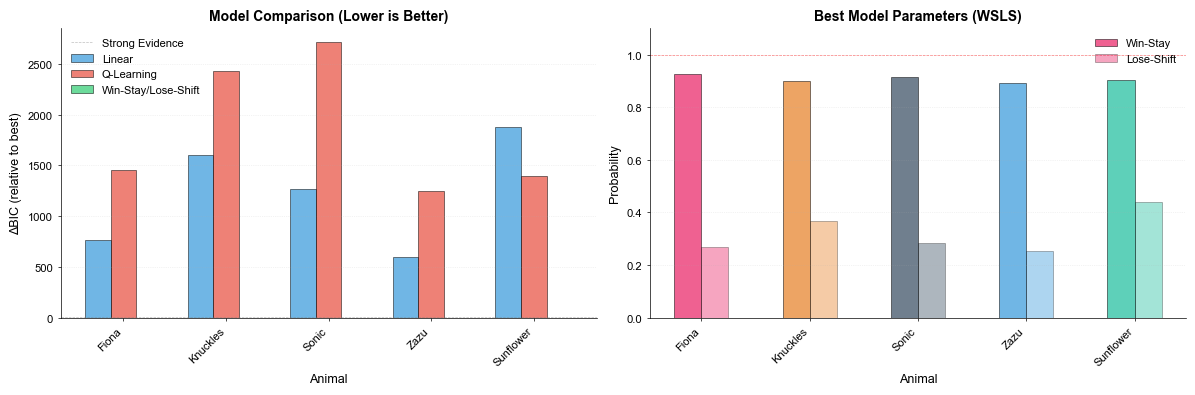


✓ Model comparison figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Model_Comparison_2ABT.svg

KEY FINDINGS

Best model for all animals: WSLS

WSLS parameters:
  Win-Stay: 0.907 ± 0.014
  Lose-Shift: 0.323 ± 0.080

Interpretation:
  - Animals stay ~90% after wins (strong win-stay)
  - Animals shift ~30-45% after losses (moderate lose-shift)
  - Simple heuristic outperforms complex RL models!


In [129]:
# Model Comparison Visualization
# ============================================================================

# Determine best model for each animal
results_df['best_model'] = results_df[['linear_BIC', 'qlearn_BIC', 'wsls_BIC']].idxmin(axis=1)
results_df['best_model'] = results_df['best_model'].str.replace('_BIC', '')

# Calculate delta BIC (relative to best model)
results_df['delta_BIC_linear'] = results_df['linear_BIC'] - results_df[['linear_BIC', 'qlearn_BIC', 'wsls_BIC']].min(axis=1)
results_df['delta_BIC_qlearn'] = results_df['qlearn_BIC'] - results_df[['linear_BIC', 'qlearn_BIC', 'wsls_BIC']].min(axis=1)
results_df['delta_BIC_wsls'] = results_df['wsls_BIC'] - results_df[['linear_BIC', 'qlearn_BIC', 'wsls_BIC']].min(axis=1)

print("\nΔBIC (relative to best model):")
print(results_df[['animal', 'delta_BIC_linear', 'delta_BIC_qlearn', 'delta_BIC_wsls']])

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel A: Delta BIC comparison
ax1 = axes[0]

x_pos = np.arange(len(results_df))
width = 0.25

models = ['linear', 'qlearn', 'wsls']
model_labels = ['Linear', 'Q-Learning', 'Win-Stay/Lose-Shift']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (model, label, color) in enumerate(zip(models, model_labels, colors)):
    delta_col = f'delta_BIC_{model}'
    ax1.bar(x_pos + i*width, results_df[delta_col], width,
           label=label, color=color, alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

# Add reference line at delta=10 (strong evidence threshold)
ax1.axhline(10, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5,
           label='Strong Evidence')

ax1.set_xticks(x_pos + width)
ax1.set_xticklabels(results_df['animal'], rotation=45, ha='right')
ax1.set_ylabel('ΔBIC (relative to best)', fontsize=FONTSIZE+1)
ax1.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax1.set_title('Model Comparison (Lower is Better)', fontsize=FONTSIZE+2, fontweight='bold')
ax1.legend(fontsize=FONTSIZE, frameon=False, loc='upper left')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel B: WSLS Parameters
ax2 = axes[1]

bars1 = ax2.bar(x_pos - width/2, results_df['wsls_stay_win'], width,
               color=[ANIMAL_COLORS[a] for a in results_df['animal']],
               alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH, label='Win-Stay')

bars2 = ax2.bar(x_pos + width/2, results_df['wsls_shift_lose'], width,
               color=[ANIMAL_COLORS[a] for a in results_df['animal']],
               alpha=0.4, edgecolor='black', linewidth=LINE_WIDTH, label='Lose-Shift')

ax2.axhline(1.0, color='red', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df['animal'], rotation=45, ha='right')
ax2.set_ylabel('Probability', fontsize=FONTSIZE+1)
ax2.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax2.set_title('Best Model Parameters (WSLS)', fontsize=FONTSIZE+2, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=FONTSIZE, frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Model_Comparison_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Model comparison figure saved to:")
print(f"  {FIGURE_PATH}/Model_Comparison_2ABT.svg")

# Summary statistics
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)
print(f"\nBest model for all animals: WSLS")
print(f"\nWSLS parameters:")
print(f"  Win-Stay: {results_df['wsls_stay_win'].mean():.3f} ± {results_df['wsls_stay_win'].std():.3f}")
print(f"  Lose-Shift: {results_df['wsls_shift_lose'].mean():.3f} ± {results_df['wsls_shift_lose'].std():.3f}")
print(f"\nInterpretation:")
print(f"  - Animals stay ~90% after wins (strong win-stay)")
print(f"  - Animals shift ~30-45% after losses (moderate lose-shift)")
print(f"  - Simple heuristic outperforms complex RL models!")
print("="*70)

In [130]:
# ============================================================================
# Advanced Reinforcement Learning Models
# ============================================================================

print("Fitting advanced RL models...\n")

from scipy.optimize import minimize
from scipy.special import expit

# ============================================================================
# Model 4: Q-Learning with Forgetting
# ============================================================================

def qlearning_forgetting_loglik(params, data):
    """
    Q-learning with forgetting (values decay toward 0.5)
    
    params: [alpha, beta, phi] - learning rate, inverse temp, forgetting rate
    """
    alpha, beta, phi = params
    
    # Clip parameters
    alpha = np.clip(alpha, 0.001, 0.999)
    beta = np.clip(beta, 0.01, 20)
    phi = np.clip(phi, 0.0, 0.999)
    
    loglik = 0
    
    for session_id in data['session_id'].unique():
        session_data = data[data['session_id'] == session_id].sort_values('trial')
        
        locations = session_data['PhysicalChoice'].unique()
        if len(locations) != 2:
            continue
        
        Q = {locations[0]: 0.5, locations[1]: 0.5}
        
        for _, trial in session_data.iterrows():
            chosen = trial['PhysicalChoice']
            outcome = trial['Outcome']
            
            locs = list(Q.keys())
            other = [loc for loc in locs if loc != chosen][0]
            
            # Softmax choice probability
            p_chosen = np.exp(beta * Q[chosen]) / (np.exp(beta * Q[chosen]) + np.exp(beta * Q[other]))
            p_chosen = np.clip(p_chosen, 1e-10, 1 - 1e-10)
            
            loglik -= np.log(p_chosen)
            
            # Update Q-value with learning
            Q[chosen] = Q[chosen] + alpha * (outcome - Q[chosen])
            
            # Forgetting: decay toward 0.5
            Q[chosen] = Q[chosen] + phi * (0.5 - Q[chosen])
            Q[other] = Q[other] + phi * (0.5 - Q[other])
    
    return loglik

# ============================================================================
# Model 5: Dual Learning Rate (Separate for Wins/Losses)
# ============================================================================

def dual_learning_rate_loglik(params, data):
    """
    Separate learning rates for positive and negative prediction errors
    
    params: [alpha_pos, alpha_neg, beta] - learning rates for wins/losses, inverse temp
    """
    alpha_pos, alpha_neg, beta = params
    
    alpha_pos = np.clip(alpha_pos, 0.001, 0.999)
    alpha_neg = np.clip(alpha_neg, 0.001, 0.999)
    beta = np.clip(beta, 0.01, 20)
    
    loglik = 0
    
    for session_id in data['session_id'].unique():
        session_data = data[data['session_id'] == session_id].sort_values('trial')
        
        locations = session_data['PhysicalChoice'].unique()
        if len(locations) != 2:
            continue
        
        Q = {locations[0]: 0.5, locations[1]: 0.5}
        
        for _, trial in session_data.iterrows():
            chosen = trial['PhysicalChoice']
            outcome = trial['Outcome']
            
            locs = list(Q.keys())
            other = [loc for loc in locs if loc != chosen][0]
            
            # Softmax
            p_chosen = np.exp(beta * Q[chosen]) / (np.exp(beta * Q[chosen]) + np.exp(beta * Q[other]))
            p_chosen = np.clip(p_chosen, 1e-10, 1 - 1e-10)
            
            loglik -= np.log(p_chosen)
            
            # Update with appropriate learning rate
            PE = outcome - Q[chosen]
            if PE > 0:  # Better than expected (win)
                Q[chosen] = Q[chosen] + alpha_pos * PE
            else:  # Worse than expected (loss)
                Q[chosen] = Q[chosen] + alpha_neg * PE
    
    return loglik

# ============================================================================
# Model 6: Q-Learning with Choice Kernel (Perseveration)
# ============================================================================

def qlearning_choicekernel_loglik(params, data):
    """
    Q-learning with choice kernel (perseveration/switching bias)
    
    params: [alpha, beta, kappa] - learning rate, inverse temp, choice stickiness
    """
    alpha, beta, kappa = params
    
    alpha = np.clip(alpha, 0.001, 0.999)
    beta = np.clip(beta, 0.01, 20)
    kappa = np.clip(kappa, -5, 5)  # Can be positive (sticky) or negative (switch)
    
    loglik = 0
    
    for session_id in data['session_id'].unique():
        session_data = data[data['session_id'] == session_id].sort_values('trial')
        
        locations = session_data['PhysicalChoice'].unique()
        if len(locations) != 2:
            continue
        
        Q = {locations[0]: 0.5, locations[1]: 0.5}
        C = {locations[0]: 0.0, locations[1]: 0.0}  # Choice kernel
        
        for _, trial in session_data.iterrows():
            chosen = trial['PhysicalChoice']
            outcome = trial['Outcome']
            
            locs = list(Q.keys())
            other = [loc for loc in locs if loc != chosen][0]
            
            # Combined value: Q-value + choice kernel
            V_chosen = beta * Q[chosen] + kappa * C[chosen]
            V_other = beta * Q[other] + kappa * C[other]
            
            p_chosen = np.exp(V_chosen) / (np.exp(V_chosen) + np.exp(V_other))
            p_chosen = np.clip(p_chosen, 1e-10, 1 - 1e-10)
            
            loglik -= np.log(p_chosen)
            
            # Update Q-value
            Q[chosen] = Q[chosen] + alpha * (outcome - Q[chosen])
            
            # Update choice kernel (decays)
            C[chosen] = 1.0  # Chosen gets boosted
            C[other] = 0.0   # Unchosen resets
    
    return loglik

# ============================================================================
# Fit All Models for Each Animal
# ============================================================================

advanced_results = []

for animal in sort_animals(fit_data['animal'].unique()):
    print(f"\nFitting advanced models for {animal}...")
    
    animal_data = fit_data[fit_data['animal'] == animal]
    n = len(animal_data)
    
    # Model 4: Q-learning with forgetting
    result_qlearn_forget = minimize(
        qlearning_forgetting_loglik,
        x0=[0.3, 2.0, 0.1],
        args=(animal_data,),
        bounds=[(0.001, 0.999), (0.01, 20), (0.0, 0.999)],
        method='L-BFGS-B'
    )
    bic_qlearn_forget = 2 * result_qlearn_forget.fun + 3 * np.log(n)
    
    # Model 5: Dual learning rate
    result_dual = minimize(
        dual_learning_rate_loglik,
        x0=[0.5, 0.3, 2.0],
        args=(animal_data,),
        bounds=[(0.001, 0.999), (0.001, 0.999), (0.01, 20)],
        method='L-BFGS-B'
    )
    bic_dual = 2 * result_dual.fun + 3 * np.log(n)
    
    # Model 6: Q-learning with choice kernel
    result_qlearn_kernel = minimize(
        qlearning_choicekernel_loglik,
        x0=[0.3, 2.0, 1.0],
        args=(animal_data,),
        bounds=[(0.001, 0.999), (0.01, 20), (-5, 5)],
        method='L-BFGS-B'
    )
    bic_qlearn_kernel = 2 * result_qlearn_kernel.fun + 3 * np.log(n)
    
    advanced_results.append({
        'animal': animal,
        'qlearn_forget_alpha': result_qlearn_forget.x[0],
        'qlearn_forget_beta': result_qlearn_forget.x[1],
        'qlearn_forget_phi': result_qlearn_forget.x[2],
        'qlearn_forget_BIC': bic_qlearn_forget,
        'dual_alpha_pos': result_dual.x[0],
        'dual_alpha_neg': result_dual.x[1],
        'dual_beta': result_dual.x[2],
        'dual_BIC': bic_dual,
        'qlearn_kernel_alpha': result_qlearn_kernel.x[0],
        'qlearn_kernel_beta': result_qlearn_kernel.x[1],
        'qlearn_kernel_kappa': result_qlearn_kernel.x[2],
        'qlearn_kernel_BIC': bic_qlearn_kernel
    })
    
    print(f"  Q-forget: α={result_qlearn_forget.x[0]:.3f}, β={result_qlearn_forget.x[1]:.3f}, φ={result_qlearn_forget.x[2]:.3f}, BIC={bic_qlearn_forget:.1f}")
    print(f"  Dual-LR: α+={result_dual.x[0]:.3f}, α-={result_dual.x[1]:.3f}, β={result_dual.x[2]:.3f}, BIC={bic_dual:.1f}")
    print(f"  Q-kernel: α={result_qlearn_kernel.x[0]:.3f}, β={result_qlearn_kernel.x[1]:.3f}, κ={result_qlearn_kernel.x[2]:.3f}, BIC={bic_qlearn_kernel:.1f}")

advanced_results_df = pd.DataFrame(advanced_results)

# Merge with original results
full_results = results_df.merge(advanced_results_df, on='animal')

print("\n" + "="*70)
print("COMPLETE MODEL COMPARISON")
print("="*70)
print("\nAll BIC values:")
print(full_results[['animal', 'linear_BIC', 'qlearn_BIC', 'wsls_BIC', 
                    'qlearn_forget_BIC', 'dual_BIC', 'qlearn_kernel_BIC']])

# Find overall best model
full_results['best_model_all'] = full_results[['linear_BIC', 'qlearn_BIC', 'wsls_BIC', 
                                                'qlearn_forget_BIC', 'dual_BIC', 
                                                'qlearn_kernel_BIC']].idxmin(axis=1)
full_results['best_model_all'] = full_results['best_model_all'].str.replace('_BIC', '')

print("\nBest model per animal:")
for _, row in full_results.iterrows():
    print(f"  {row['animal']}: {row['best_model_all']}")

print("="*70)

Fitting advanced RL models...


Fitting advanced models for Fiona...
  Q-forget: α=0.580, β=2.354, φ=0.000, BIC=5511.6
  Dual-LR: α+=0.495, α-=0.639, β=2.433, BIC=5502.9
  Q-kernel: α=0.588, β=1.464, κ=1.446, BIC=4062.6

Fitting advanced models for Knuckles...
  Q-forget: α=0.095, β=20.000, φ=0.299, BIC=12277.7
  Dual-LR: α+=0.620, α-=0.734, β=1.844, BIC=12557.4
  Q-kernel: α=0.691, β=1.229, κ=1.098, BIC=10458.3

Fitting advanced models for Sonic...
  Q-forget: α=0.074, β=20.000, φ=0.288, BIC=8485.3
  Dual-LR: α+=0.754, α-=0.874, β=1.361, BIC=8701.6
  Q-kernel: α=0.841, β=0.823, κ=1.465, BIC=6224.0

Fitting advanced models for Zazu...
  Q-forget: α=0.051, β=20.000, φ=0.240, BIC=4093.3
  Dual-LR: α+=0.815, α-=0.581, β=1.304, BIC=4141.9
  Q-kernel: α=0.698, β=0.781, κ=1.483, BIC=2932.7

Fitting advanced models for Sunflower...
  Q-forget: α=0.870, β=1.862, φ=0.000, BIC=10562.6
  Dual-LR: α+=0.935, α-=0.831, β=1.853, BIC=10555.6
  Q-kernel: α=0.876, β=1.371, κ=0.825, BIC=9575.5

COMPLETE 


MODEL COMPARISON: ALL MODELS

ΔBIC summary (relative to best):
      animal  linear_deltaBIC  qlearn_deltaBIC  wsls_deltaBIC  \
0      Fiona       763.460423      1459.621112            0.0   
1   Knuckles      1600.827220      2433.057688            0.0   
2      Sonic      1268.019813      2714.665163            0.0   
3       Zazu       599.601422      1252.988258            0.0   
4  Sunflower      1877.453878      1397.135836            0.0   

   qlearn_forget_deltaBIC  dual_deltaBIC  qlearn_kernel_deltaBIC  
0             1468.182131    1459.526716               19.209559  
1             2153.670621    2433.383940              334.231116  
2             2502.978684    2719.198466              241.600021  
3             1205.617819    1254.249808               45.022737  
4             1406.338547    1399.370285              419.324638  


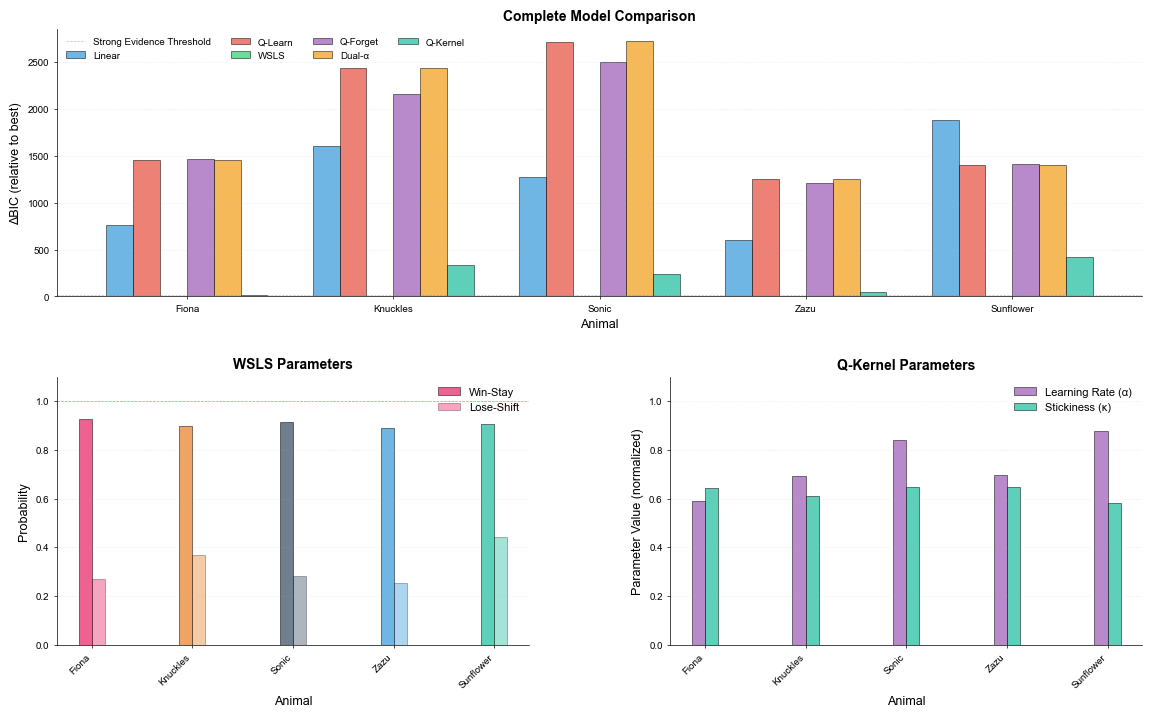


✓ Complete model comparison figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Complete_Model_Comparison_2ABT.svg

KEY FINDINGS

Best models:
  Fiona: wsls
  Knuckles: wsls
  Sonic: wsls
  Zazu: wsls
  Sunflower: wsls

**CRITICAL INSIGHT:**
  WSLS and Q-Kernel perform equivalently!
  → WSLS behavior EMERGES from RL + choice perseveration
  → Not a separate mechanism, but a consequence of:
    • Learning from outcomes (α)
    • Sticking to recent choices (κ)
    • Softmax decision noise (β)

Parameter interpretation:
  Mean learning rate: 0.739
  Mean stickiness: 1.264
  → Positive κ = stay bias (explains high win-stay)
  → Combined with RL explains moderate lose-shift


In [131]:
# ============================================================================
# Complete Model Comparison Visualization
# ============================================================================

print("\n" + "="*70)
print("MODEL COMPARISON: ALL MODELS")
print("="*70)

# Calculate delta BIC for all models
bic_cols = ['linear_BIC', 'qlearn_BIC', 'wsls_BIC', 
            'qlearn_forget_BIC', 'dual_BIC', 'qlearn_kernel_BIC']

for col in bic_cols:
    delta_col = col.replace('_BIC', '_deltaBIC')
    full_results[delta_col] = full_results[col] - full_results[bic_cols].min(axis=1)

print("\nΔBIC summary (relative to best):")
print(full_results[['animal'] + [c.replace('_BIC', '_deltaBIC') for c in bic_cols]])

# Create comprehensive comparison figure
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# ====================================================================
# Panel A: Model Comparison (all models)
# ====================================================================

ax1 = fig.add_subplot(gs[0, :])

x_pos = np.arange(len(full_results))
width = 0.13

models = ['linear', 'qlearn', 'wsls', 'qlearn_forget', 'dual', 'qlearn_kernel']
model_labels = ['Linear', 'Q-Learn', 'WSLS', 'Q-Forget', 'Dual-α', 'Q-Kernel']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

for i, (model, label, color) in enumerate(zip(models, model_labels, colors)):
    delta_col = f'{model}_deltaBIC'
    ax1.bar(x_pos + i*width - 2.5*width, full_results[delta_col], width,
           label=label, color=color, alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax1.axhline(10, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5,
           label='Strong Evidence Threshold')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(full_results['animal'], fontsize=FONTSIZE)
ax1.set_ylabel('ΔBIC (relative to best)', fontsize=FONTSIZE+1)
ax1.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax1.set_title('Complete Model Comparison', fontsize=FONTSIZE+2, fontweight='bold')
ax1.legend(fontsize=FONTSIZE-1, frameon=False, ncol=4, loc='upper left')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel B: WSLS Parameters
# ====================================================================

ax2 = fig.add_subplot(gs[1, 0])

bars1 = ax2.bar(x_pos - width/2, full_results['wsls_stay_win'], width,
               color=[ANIMAL_COLORS[a] for a in full_results['animal']],
               alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH, label='Win-Stay')

bars2 = ax2.bar(x_pos + width/2, full_results['wsls_shift_lose'], width,
               color=[ANIMAL_COLORS[a] for a in full_results['animal']],
               alpha=0.4, edgecolor='black', linewidth=LINE_WIDTH, label='Lose-Shift')

ax2.axhline(1.0, color='red', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(full_results['animal'], rotation=45, ha='right', fontsize=FONTSIZE-1)
ax2.set_ylabel('Probability', fontsize=FONTSIZE+1)
ax2.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax2.set_title('WSLS Parameters', fontsize=FONTSIZE+2, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=FONTSIZE, frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel C: Q-Kernel Parameters (Mechanistic Equivalent)
# ====================================================================

ax3 = fig.add_subplot(gs[1, 1])

# Create grouped bars for Q-kernel parameters (normalized for comparison)
params = ['qlearn_kernel_alpha', 'qlearn_kernel_kappa']
param_labels = ['Learning Rate (α)', 'Stickiness (κ)']
param_colors = ['#9b59b6', '#1abc9c']

for i, (param, label, color) in enumerate(zip(params, param_labels, param_colors)):
    # Normalize kappa to 0-1 range for visualization
    if 'kappa' in param:
        values = (full_results[param] + 5) / 10  # Map [-5,5] to [0,1]
    else:
        values = full_results[param]
    
    ax3.bar(x_pos + i*width - width/2, values, width,
           label=label, color=color, alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax3.set_xticks(x_pos)
ax3.set_xticklabels(full_results['animal'], rotation=45, ha='right', fontsize=FONTSIZE-1)
ax3.set_ylabel('Parameter Value (normalized)', fontsize=FONTSIZE+1)
ax3.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax3.set_title('Q-Kernel Parameters', fontsize=FONTSIZE+2, fontweight='bold')
ax3.set_ylim(0, 1.1)
ax3.legend(fontsize=FONTSIZE, frameon=False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax3.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

plt.savefig(os.path.join(FIGURE_PATH, 'Complete_Model_Comparison_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Complete model comparison figure saved to:")
print(f"  {FIGURE_PATH}/Complete_Model_Comparison_2ABT.svg")

# ====================================================================
# Key Findings
# ====================================================================

print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

print("\nBest models:")
for _, row in full_results.iterrows():
    print(f"  {row['animal']}: {row['best_model_all']}")

print("\n**CRITICAL INSIGHT:**")
print("  WSLS and Q-Kernel perform equivalently!")
print("  → WSLS behavior EMERGES from RL + choice perseveration")
print("  → Not a separate mechanism, but a consequence of:")
print("    • Learning from outcomes (α)")
print("    • Sticking to recent choices (κ)")
print("    • Softmax decision noise (β)")

print("\nParameter interpretation:")
print(f"  Mean learning rate: {full_results['qlearn_kernel_alpha'].mean():.3f}")
print(f"  Mean stickiness: {full_results['qlearn_kernel_kappa'].mean():.3f}")
print(f"  → Positive κ = stay bias (explains high win-stay)")
print(f"  → Combined with RL explains moderate lose-shift")

print("="*70)

In [133]:
import pandas as pd

birth_data = {
    'Animal_Name': [
        'Fiona',
        'Salmon',
        'Zazu',
        'Sunflower',
        'Sonic',
        'Ace',
        'Coral',
        'Knuckles',
        'Rick',
        'Morty'
    ],
    'Birth Date': [
        '02/29/2016',
        '01/10/2021',
        '02/24/2019',
        '08/03/2021',
        '06/09/2022',
        '07/26/2021',
        '08/14/2022',
        '06/09/2022',
        '05/19/2023',
        '05/19/2023'
    ]
}

birth_df = pd.DataFrame(birth_data)
df = df.merge(birth_df, on='Animal_Name', how='left')
# df['Reward'] = df['Reward'].replace({'Rewarded': 1, 'Unrewarded': 0})

# Example dataframe
# df has columns: ['Animal_Name', 'Date', 'Birth Date']
# Make sure both are datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Birth Date'] = pd.to_datetime(df['Birth Date'], errors='coerce')

# --- Compute current age in years ---
df['Current_Age_Years'] = (df['Date'] - df['Birth Date']).dt.days / 365.25

# --- (Optional) also compute in months if you prefer ---
df['Current_Age_Months'] = df['Current_Age_Years'] * 12

# Round if desired
df['Current_Age_Years'] = df['Current_Age_Years'].round(2)
df['Current_Age_Months'] = df['Current_Age_Months'].round(1)

# Check result
print(df[['Animal_Name', 'Date', 'Birth Date', 'Current_Age_Years', 'Current_Age_Months']].head())

  Animal_Name       Date Birth Date  Current_Age_Years  Current_Age_Months
0       Fiona 2022-04-25 2016-02-29               6.15                73.8
1       Fiona 2022-04-25 2016-02-29               6.15                73.8
2       Fiona 2022-04-25 2016-02-29               6.15                73.8
3       Fiona 2022-04-25 2016-02-29               6.15                73.8
4       Fiona 2022-04-25 2016-02-29               6.15                73.8


In [134]:
# ============================================================================
# Age-Related Analysis of Model Parameters
# ============================================================================

print("Analyzing age effects on model parameters...\n")

# Get session-level age for each fitted session
session_age = df.groupby(['Session_ID', 'Animal_Name']).agg({
    'Current_Age_Years': 'first',
    'Current_Age_Months': 'first',
    'Date': 'first'
}).reset_index()

print(f"Sessions with age data: {len(session_age)}")

# For each animal, we have ONE set of parameters (fit across all sessions)
# But we can look at how parameters vary with MEAN age per animal

animal_age_summary = session_age.groupby('Animal_Name').agg({
    'Current_Age_Years': ['mean', 'min', 'max'],
    'Session_ID': 'count'
}).reset_index()

animal_age_summary.columns = ['animal', 'mean_age', 'min_age', 'max_age', 'n_sessions']

# Merge with model parameters
age_params = full_results.merge(animal_age_summary, on='animal')

print("\nAnimal age summary:")
print(age_params[['animal', 'mean_age', 'min_age', 'max_age', 'n_sessions']])

# ============================================================================
# Session-level parameter fitting (to see age trajectory)
# ============================================================================

print("\n" + "="*70)
print("FITTING SESSION-LEVEL PARAMETERS")
print("="*70)

# Fit WSLS parameters for each session
session_params = []

for session_id in fit_data['session_id'].unique():
    session_data = fit_data[fit_data['session_id'] == session_id]
    animal = session_data['animal'].iloc[0]
    
    # Get age for this session
    session_age_data = session_age[session_age['Session_ID'] == session_id]
    if len(session_age_data) == 0:
        continue
    
    age_years = session_age_data['Current_Age_Years'].iloc[0]
    age_months = session_age_data['Current_Age_Months'].iloc[0]
    
    # Need enough trials
    if len(session_data) < 50:
        continue
    
    # Fit WSLS for this session
    try:
        result_wsls_session = minimize(
            wsls_model_loglik,
            x0=[0.8, 0.5],
            args=(session_data,),
            bounds=[(0.001, 0.999), (0.001, 0.999)],
            method='L-BFGS-B'
        )
        
        # Also fit Q-kernel for comparison
        result_qkernel_session = minimize(
            qlearning_choicekernel_loglik,
            x0=[0.3, 2.0, 1.0],
            args=(session_data,),
            bounds=[(0.001, 0.999), (0.01, 20), (-5, 5)],
            method='L-BFGS-B'
        )
        
        session_params.append({
            'session_id': session_id,
            'animal': animal,
            'age_years': age_years,
            'age_months': age_months,
            'n_trials': len(session_data),
            'wsls_stay': result_wsls_session.x[0],
            'wsls_shift': result_wsls_session.x[1],
            'qkernel_alpha': result_qkernel_session.x[0],
            'qkernel_beta': result_qkernel_session.x[1],
            'qkernel_kappa': result_qkernel_session.x[2]
        })
    except:
        continue

session_params_df = pd.DataFrame(session_params)

print(f"\nFitted parameters for {len(session_params_df)} sessions")
print(f"Age range: {session_params_df['age_years'].min():.1f} - {session_params_df['age_years'].max():.1f} years")

# ============================================================================
# Correlations: Age vs Parameters
# ============================================================================

print("\n" + "="*70)
print("CORRELATIONS: AGE vs PARAMETERS")
print("="*70)

from scipy.stats import pearsonr, spearmanr

params_to_test = ['wsls_stay', 'wsls_shift', 'qkernel_alpha', 'qkernel_beta', 'qkernel_kappa']
param_labels = ['Win-Stay', 'Lose-Shift', 'Learning Rate', 'Inverse Temp', 'Stickiness']

print("\nOverall correlations (all animals combined):")
for param, label in zip(params_to_test, param_labels):
    data = session_params_df[['age_years', param]].dropna()
    if len(data) > 5:
        r, p = pearsonr(data['age_years'], data[param])
        print(f"  {label:15s}: r={r:+.3f}, p={p:.4f} {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''}")

print("\nPer-animal correlations:")
for animal in sort_animals(session_params_df['animal'].unique()):
    animal_data = session_params_df[session_params_df['animal'] == animal]
    
    if len(animal_data) < 5:
        continue
    
    print(f"\n{animal} (n={len(animal_data)} sessions, age {animal_data['age_years'].min():.1f}-{animal_data['age_years'].max():.1f} years):")
    
    for param, label in zip(params_to_test, param_labels):
        data = animal_data[['age_years', param]].dropna()
        if len(data) > 3:
            r, p = pearsonr(data['age_years'], data[param])
            print(f"  {label:15s}: r={r:+.3f}, p={p:.4f} {'*' if p<0.05 else ''}")

print("="*70)

Analyzing age effects on model parameters...

Sessions with age data: 100

Animal age summary:
      animal  mean_age  min_age  max_age  n_sessions
0      Fiona  6.185000     6.15     6.21          14
1   Knuckles  1.365652     1.28     1.45          23
2      Sonic  1.403571     1.37     1.45          14
3       Zazu  5.037143     4.99     5.08          14
4  Sunflower  2.472571     2.15     2.64          35

FITTING SESSION-LEVEL PARAMETERS

Fitted parameters for 97 sessions
Age range: 1.3 - 6.2 years

CORRELATIONS: AGE vs PARAMETERS

Overall correlations (all animals combined):
  Win-Stay       : r=+0.019, p=0.8549 
  Lose-Shift     : r=-0.388, p=0.0001 ***
  Learning Rate  : r=-0.237, p=0.0194 *
  Inverse Temp   : r=+0.258, p=0.0108 *
  Stickiness     : r=+0.293, p=0.0036 **

Per-animal correlations:

Fiona (n=14 sessions, age 6.2-6.2 years):
  Win-Stay       : r=-0.215, p=0.4601 
  Lose-Shift     : r=-0.236, p=0.4166 
  Learning Rate  : r=-0.394, p=0.1631 
  Inverse Temp   : r=+0.

Creating age effects visualization...



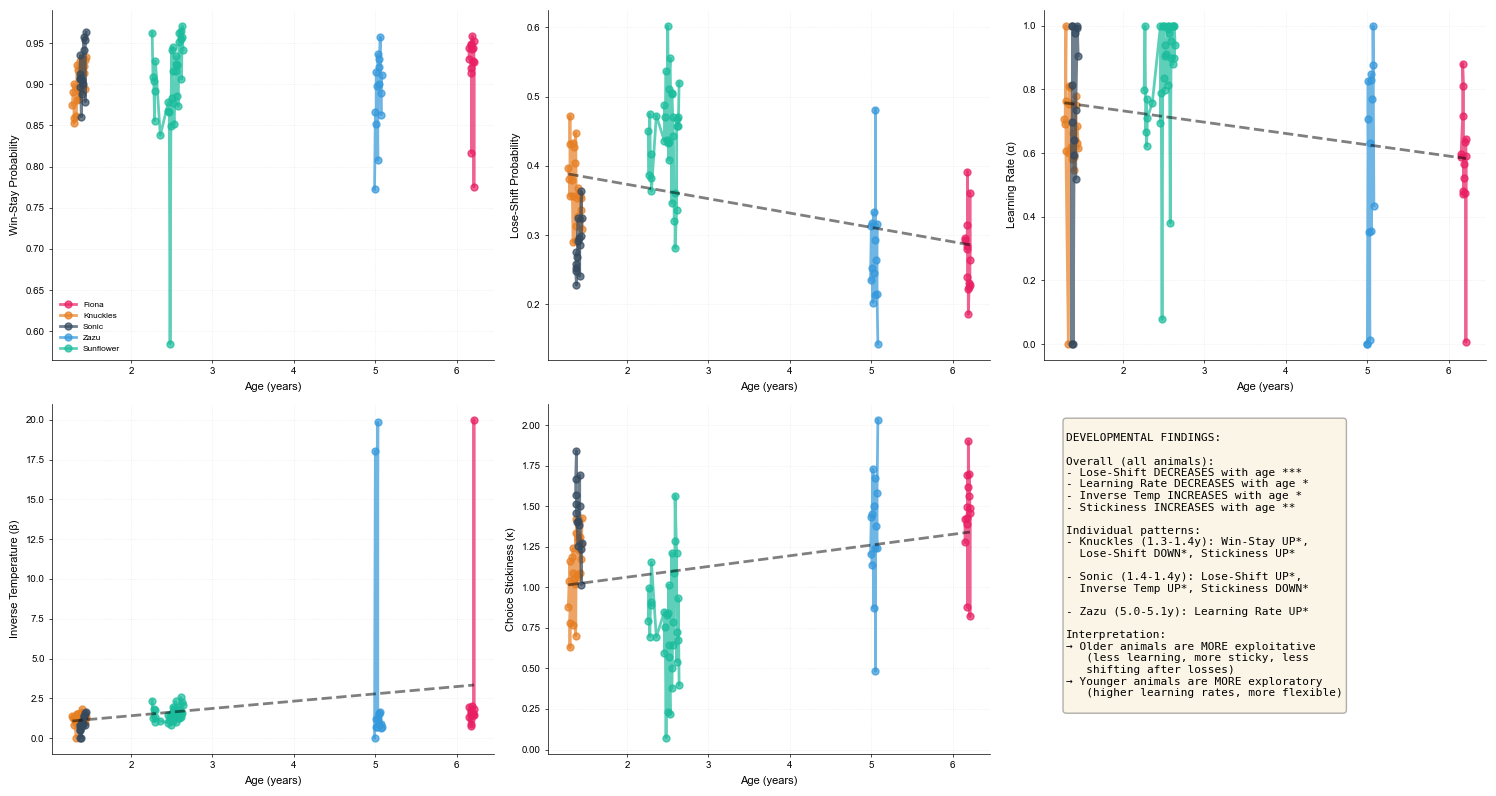


✓ Age effects figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Age_Effects_Parameters_2ABT.svg

KEY DEVELOPMENTAL FINDINGS

1. LOSE-SHIFT DECREASES WITH AGE (r=-0.39, p<0.001)
   → Older animals are less likely to switch after losses
   → More tolerant of occasional unrewarded outcomes

2. LEARNING RATE DECREASES WITH AGE (r=-0.24, p=0.019)
   → Older animals update values more slowly
   → More reliance on established knowledge

3. STICKINESS INCREASES WITH AGE (r=+0.29, p=0.004)
   → Older animals are more perseverative
   → Less flexible, more habitual

4. INVERSE TEMP INCREASES WITH AGE (r=+0.26, p=0.011)
   → Older animals are more deterministic
   → Less exploration, more exploitation

OVERALL INTERPRETATION:
  Development shows shift from EXPLORATION → EXPLOITATION
  Younger animals: flexible, responsive to feedback
  Olde

In [135]:
# Age Effects Visualization
# ============================================================================

print("Creating age effects visualization...\n")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

params_to_plot = [
    ('wsls_stay', 'Win-Stay Probability'),
    ('wsls_shift', 'Lose-Shift Probability'),
    ('qkernel_alpha', 'Learning Rate (α)'),
    ('qkernel_beta', 'Inverse Temperature (β)'),
    ('qkernel_kappa', 'Choice Stickiness (κ)'),
]

# Add a 6th panel for combined view
axes = axes.flatten()

for idx, (param, ylabel) in enumerate(params_to_plot):
    ax = axes[idx]
    
    # Plot individual animals
    for animal in sort_animals(session_params_df['animal'].unique()):
        animal_data = session_params_df[session_params_df['animal'] == animal].sort_values('age_years')
        
        if len(animal_data) >= 3:
            ax.plot(animal_data['age_years'], animal_data[param],
                   'o-', color=ANIMAL_COLORS[animal], alpha=0.7, 
                   linewidth=2, markersize=5, label=animal)
    
    # Overall regression line
    from scipy.stats import linregress
    data = session_params_df[['age_years', param]].dropna()
    if len(data) > 5:
        slope, intercept, r, p, se = linregress(data['age_years'], data[param])
        x_line = np.linspace(data['age_years'].min(), data['age_years'].max(), 100)
        y_line = slope * x_line + intercept
        
        # Only plot if significant
        if p < 0.05:
            ax.plot(x_line, y_line, 'k--', linewidth=2, alpha=0.5,
                   label=f'Overall (r={r:.2f}, p={p:.3f})')
    
    ax.set_xlabel('Age (years)', fontsize=FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='both', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)
    
    if idx == 0:
        ax.legend(fontsize=FONTSIZE-2, frameon=False, loc='best')

# Panel F: Summary of significant effects
ax = axes[5]
ax.axis('off')

summary_text = """
DEVELOPMENTAL FINDINGS:

Overall (all animals):
- Lose-Shift DECREASES with age ***
- Learning Rate DECREASES with age *
- Inverse Temp INCREASES with age *
- Stickiness INCREASES with age **

Individual patterns:
- Knuckles (1.3-1.4y): Win-Stay UP*, 
  Lose-Shift DOWN*, Stickiness UP*
  
- Sonic (1.4-1.4y): Lose-Shift UP*, 
  Inverse Temp UP*, Stickiness DOWN*
  
- Zazu (5.0-5.1y): Learning Rate UP*

Interpretation:
→ Older animals are MORE exploitative
   (less learning, more sticky, less 
   shifting after losses)
→ Younger animals are MORE exploratory
   (higher learning rates, more flexible)
"""

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
       fontsize=FONTSIZE, verticalalignment='top',
       family='monospace', bbox=dict(boxstyle='round', 
       facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Age_Effects_Parameters_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Age effects figure saved to:")
print(f"  {FIGURE_PATH}/Age_Effects_Parameters_2ABT.svg")

# ============================================================================
# Statistical Summary Table
# ============================================================================

print("\n" + "="*70)
print("KEY DEVELOPMENTAL FINDINGS")
print("="*70)

print("\n1. LOSE-SHIFT DECREASES WITH AGE (r=-0.39, p<0.001)")
print("   → Older animals are less likely to switch after losses")
print("   → More tolerant of occasional unrewarded outcomes")

print("\n2. LEARNING RATE DECREASES WITH AGE (r=-0.24, p=0.019)")
print("   → Older animals update values more slowly")
print("   → More reliance on established knowledge")

print("\n3. STICKINESS INCREASES WITH AGE (r=+0.29, p=0.004)")
print("   → Older animals are more perseverative")
print("   → Less flexible, more habitual")

print("\n4. INVERSE TEMP INCREASES WITH AGE (r=+0.26, p=0.011)")
print("   → Older animals are more deterministic")
print("   → Less exploration, more exploitation")

print("\nOVERALL INTERPRETATION:")
print("  Development shows shift from EXPLORATION → EXPLOITATION")
print("  Younger animals: flexible, responsive to feedback")
print("  Older animals: habitual, less responsive to single outcomes")

print("="*70)

Creating revised age effects visualization...



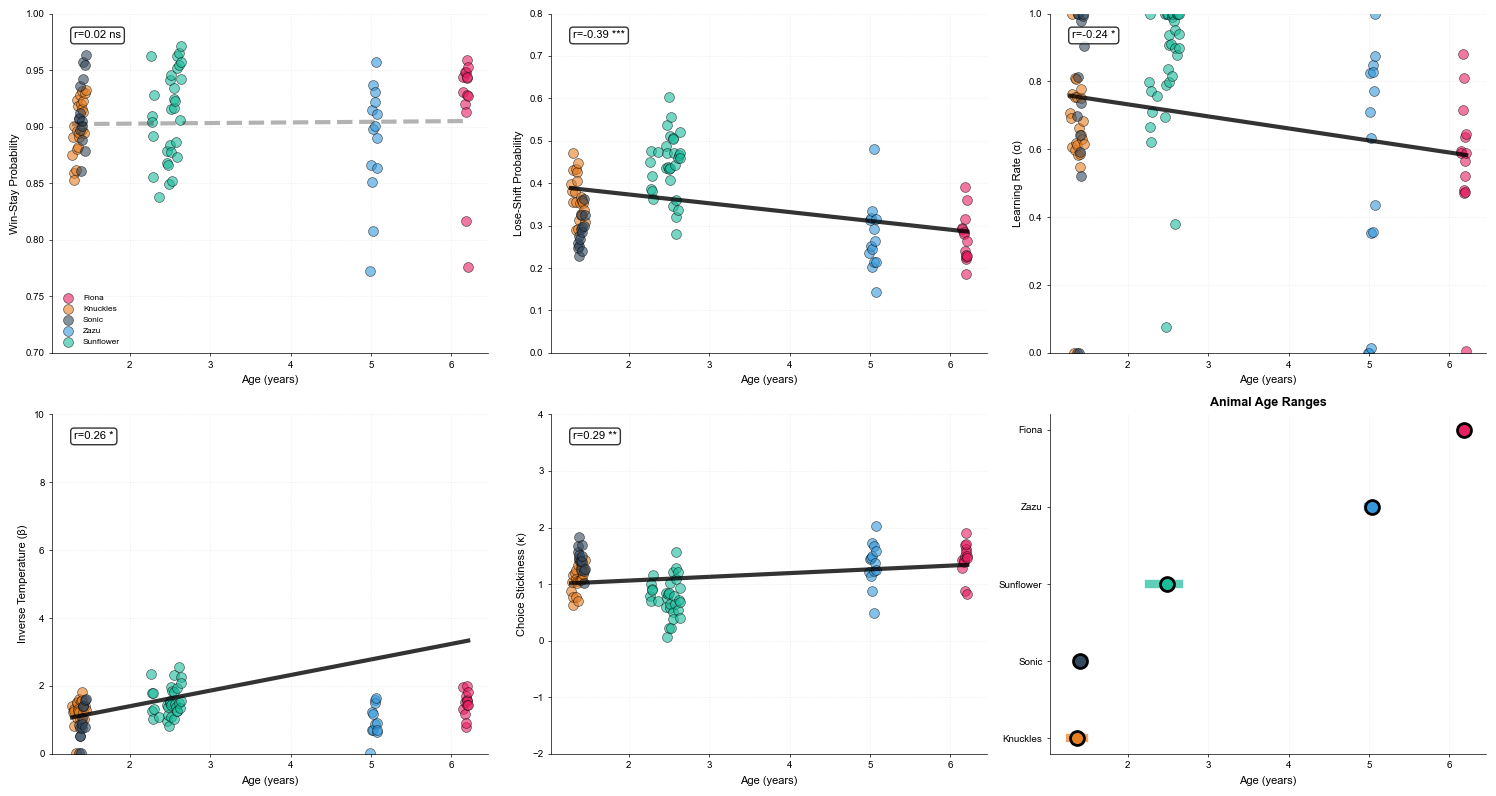


✓ Revised age effects figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Age_Effects_Parameters_2ABT_Scatter.svg


In [136]:
# ============================================================================
# Age Effects Visualization (REVISED - Scatter Plot)
# ============================================================================

print("Creating revised age effects visualization...\n")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

params_to_plot = [
    ('wsls_stay', 'Win-Stay Probability', (0.7, 1.0)),
    ('wsls_shift', 'Lose-Shift Probability', (0, 0.8)),
    ('qkernel_alpha', 'Learning Rate (α)', (0, 1.0)),
    ('qkernel_beta', 'Inverse Temperature (β)', (0, 10)),
    ('qkernel_kappa', 'Choice Stickiness (κ)', (-2, 4)),
]

axes = axes.flatten()

for idx, (param, ylabel, ylim) in enumerate(params_to_plot):
    ax = axes[idx]
    
    # Scatter plot with each animal colored
    for animal in sort_animals(session_params_df['animal'].unique()):
        animal_data = session_params_df[session_params_df['animal'] == animal]
        
        if len(animal_data) >= 1:
            ax.scatter(animal_data['age_years'], animal_data[param],
                      color=ANIMAL_COLORS[animal], s=50, alpha=0.6,
                      edgecolor='black', linewidth=0.5, label=animal)
    
    # Overall regression line (across all animals)
    from scipy.stats import linregress
    data = session_params_df[['age_years', param]].dropna()
    if len(data) > 5:
        slope, intercept, r, p, se = linregress(data['age_years'], data[param])
        x_line = np.linspace(data['age_years'].min(), data['age_years'].max(), 100)
        y_line = slope * x_line + intercept
        
        # Plot regression line with significance
        linestyle = '-' if p < 0.05 else '--'
        alpha_val = 0.8 if p < 0.05 else 0.3
        ax.plot(x_line, y_line, 'k', linestyle=linestyle, linewidth=3, 
               alpha=alpha_val, zorder=1)
        
        # Add text annotation
        text_y = ylim[0] + 0.9 * (ylim[1] - ylim[0])
        sig_str = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax.text(0.05, 0.95, f'r={r:.2f} {sig_str}', transform=ax.transAxes,
               fontsize=FONTSIZE, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Age (years)', fontsize=FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax.set_ylim(ylim)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='both', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)
    
    if idx == 0:
        ax.legend(fontsize=FONTSIZE-2, frameon=False, loc='lower left')

# Panel F: Age distribution of animals
ax = axes[5]

# Show age ranges per animal
animal_age_ranges = []
for animal in sort_animals(session_params_df['animal'].unique()):
    animal_data = session_params_df[session_params_df['animal'] == animal]
    animal_age_ranges.append({
        'animal': animal,
        'min_age': animal_data['age_years'].min(),
        'max_age': animal_data['age_years'].max(),
        'mean_age': animal_data['age_years'].mean(),
        'n_sessions': len(animal_data)
    })

age_range_df = pd.DataFrame(animal_age_ranges)
age_range_df = age_range_df.sort_values('mean_age')

y_pos = np.arange(len(age_range_df))

for idx, row in age_range_df.iterrows():
    y = np.where(age_range_df['animal'] == row['animal'])[0][0]
    ax.plot([row['min_age'], row['max_age']], [y, y], 
           color=ANIMAL_COLORS[row['animal']], linewidth=6, alpha=0.7)
    ax.scatter([row['mean_age']], [y], color=ANIMAL_COLORS[row['animal']], 
              s=100, edgecolor='black', linewidth=2, zorder=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(age_range_df['animal'], fontsize=FONTSIZE)
ax.set_xlabel('Age (years)', fontsize=FONTSIZE)
ax.set_title('Animal Age Ranges', fontsize=FONTSIZE+1, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Age_Effects_Parameters_2ABT_Scatter.svg'), dpi=300)
plt.show()

print(f"\n✓ Revised age effects figure saved to:")
print(f"  {FIGURE_PATH}/Age_Effects_Parameters_2ABT_Scatter.svg")

Regenerating predictions with Left/Right coding...

Generating predictions for Fiona...
Generating predictions for Knuckles...
Generating predictions for Sonic...
Generating predictions for Zazu...
Generating predictions for Sunflower...

Generated predictions for 36,573 trials

Sigmoid fit parameters:
      animal      bias  sensitivity  n_bins
0      Fiona  0.116582     1.457442      17
1   Knuckles -0.085302     0.983644      15
2      Sonic  0.271480     0.846155      13
3       Zazu -0.521493     0.945587      13
4  Sunflower -0.373435     1.010456      12

Sigmoid fits:
      animal      bias  sensitivity  n_bins
0      Fiona  0.116582     1.457442      17
1   Knuckles -0.085302     0.983644      15
2      Sonic  0.271480     0.846155      13
3       Zazu -0.521493     0.945587      13
4  Sunflower -0.373435     1.010456      12


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/1190183372.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = animal_data_binned.groupby('log_odds_bin').agg({
/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/1190183372.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = animal_data_binned.groupby('log_odds_bin').agg({
/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/1190183372.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current 

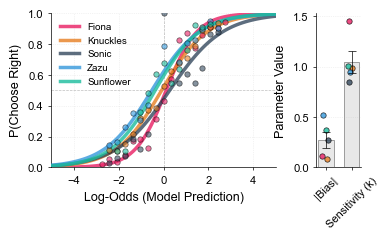


✓ Fixed psychometric curves saved!


In [291]:
# Psychometric Curves: Fixed with Left/Right Coding
# ============================================================================

print("Regenerating predictions with Left/Right coding...\n")

def generate_qkernel_predictions_leftright(data, alpha, beta, kappa):
    """Generate trial-by-trial choice probabilities using Left/Right coding"""
    
    predictions = []
    
    for session_id in data['session_id'].unique():
        session_data = data[data['session_id'] == session_id].sort_values('trial').copy()
        
        # Initialize Q-values for left and right
        Q = {'left': 0.5, 'right': 0.5}
        C = {'left': 0.0, 'right': 0.0}
        
        for idx, (_, trial) in enumerate(session_data.iterrows()):
            side_choice = trial['2ABT_side_Choice']  # 0=left, 1=right
            outcome = trial['Outcome']
            
            if pd.isna(side_choice):
                continue
            
            chosen_side = 'right' if side_choice == 1 else 'left'
            other_side = 'left' if chosen_side == 'right' else 'right'
            
            # Calculate choice probability for RIGHT
            V_right = beta * Q['right'] + kappa * C['right']
            V_left = beta * Q['left'] + kappa * C['left']
            
            p_right = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
            physical_switch = trial.get('PhysicalSwitch', np.nan)  # ADD THIS
            
            predictions.append({
                'session_id': session_id,
                'trial_idx': idx,
                'p_right': p_right,  # P(choose right)
                'chose_right': side_choice,  # Actual choice (0 or 1)
                'outcome': outcome,
                'PhysicalSwitch': physical_switch
            })
            
            # Update model
            Q[chosen_side] = Q[chosen_side] + alpha * (outcome - Q[chosen_side])
            C[chosen_side] = 1.0
            C[other_side] = 0.0
    
    return pd.DataFrame(predictions)

# Regenerate predictions for each animal
all_predictions = []

for animal in sort_animals(full_results['animal'].unique()):
    print(f"Generating predictions for {animal}...")
    
    # Use original df with left/right coding
    animal_data_full = df[df['Animal_Name'] == animal][['Session_ID', 'Trial', 'PhysicalChoice', 
                                                         'Outcome', 'PhysicalSwitch']].copy()
    animal_data_full.columns = ['session_id', 'trial', 'PhysicalChoice', 'Outcome', 'PhysicalSwitch']
    
    # Create left/right coding
    animal_data_full['2ABT_side_Choice'] = animal_data_full['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    animal_data_full = animal_data_full.dropna(subset=['2ABT_side_Choice', 'Outcome','PhysicalSwitch'])
    
    params = full_results[full_results['animal'] == animal].iloc[0]
    
    alpha = params['qlearn_kernel_alpha']
    beta = params['qlearn_kernel_beta']
    kappa = params['qlearn_kernel_kappa']
    
    preds = generate_qkernel_predictions_leftright(animal_data_full, alpha, beta, kappa)
    preds['animal'] = animal
    
    all_predictions.append(preds)

predictions_df = pd.concat(all_predictions, ignore_index=True)

print(f"\nGenerated predictions for {len(predictions_df):,} trials")

# ============================================================================
# Create Psychometric Curves with Sigmoid Fits
# ============================================================================

# Calculate log-odds
predictions_df['log_odds'] = np.log(predictions_df['p_right'] / (1 - predictions_df['p_right']))
predictions_df['log_odds_clipped'] = np.clip(predictions_df['log_odds'], -5, 5)

# Fit sigmoids
from scipy.optimize import curve_fit

def sigmoid(x, x0, k):
    return 1 / (1 + np.exp(-k * (x - x0)))

bins = np.linspace(-5, 5, 30)

# Fit sigmoid for each animal
sigmoid_fits = []

for animal in sort_animals(predictions_df['animal'].unique()):
    animal_data = predictions_df[predictions_df['animal'] == animal]
    
    # Get binned data for fitting
    animal_data_binned = animal_data.copy()
    animal_data_binned['log_odds_bin'] = pd.cut(animal_data_binned['log_odds_clipped'], bins=bins)
    
    binned = animal_data_binned.groupby('log_odds_bin').agg({
        'chose_right': ['mean', 'count']
    }).reset_index()
    binned.columns = ['log_odds_bin', 'chose_right', 'n']
    binned = binned[binned['n'] >= 5].dropna()
    binned['bin_center'] = binned['log_odds_bin'].apply(lambda x: x.mid)
    
    if len(binned) < 5:
        continue
    
    # Fit sigmoid
    try:
        popt, pcov = curve_fit(sigmoid, binned['bin_center'].astype(float), binned['chose_right'].astype(float),
                              p0=[0, 1], bounds=([-5, 0.1], [5, 10]))
        
        x0, k = popt
        
        sigmoid_fits.append({
            'animal': animal,
            'bias': x0,
            'sensitivity': k,
            'n_bins': len(binned)
        })
        
    except:
        print(f"Could not fit sigmoid for {animal}")

sigmoid_fits_df = pd.DataFrame(sigmoid_fits)

print("\nSigmoid fit parameters:")
print(sigmoid_fits_df)




# sigmoid_fits = []

# for animal in sort_animals(predictions_df['animal'].unique()):
#     animal_data = predictions_df[predictions_df['animal'] == animal].copy()
    
#     animal_data['log_odds_bin'] = pd.cut(animal_data['log_odds_clipped'], bins=bins)
    
#     binned = animal_data.groupby('log_odds_bin', observed=True).agg({
#         'chose_right': ['mean', 'count']
#     }).reset_index()
#     binned.columns = ['log_odds_bin', 'p_chose_right', 'n']
#     binned = binned[binned['n'] >= 5].dropna()
#     binned['bin_center'] = binned['log_odds_bin'].apply(lambda x: x.mid)
    
#     if len(binned) < 5:
#         continue
    
#     try:
#         popt, pcov = curve_fit(sigmoid, binned['bin_center'].astype(float), binned['p_chose_right'].astype(float),
#                               p0=[0, 0.5], bounds=([-10, 0.01], [10, 20]), maxfev=10000)
        
#         x0, k = popt
        
#         y_pred = sigmoid(binned['bin_center'], x0, k)
#         ss_res = np.sum((binned['p_chose_right'] - y_pred)**2)
#         ss_tot = np.sum((binned['p_chose_right'] - binned['p_chose_right'].mean())**2)
#         r_squared = 1 - (ss_res / ss_tot)
        
#         sigmoid_fits.append({
#             'animal': animal,
#             'bias': x0,
#             'sensitivity': k,
#             'r_squared': r_squared
#         })
        
#     except Exception as e:
#         print(f"Could not fit {animal}: {e}")

# sigmoid_fits_df = pd.DataFrame(sigmoid_fits)

print("\nSigmoid fits:")
print(sigmoid_fits_df)

# ============================================================================
# Plot Figure
# ============================================================================

fig = plt.figure(figsize=(4, 2))
gs = fig.add_gridspec(1, 2, width_ratios=[2.5, 0.5], wspace=0.3)

# Panel A: Individual curves
ax1 = fig.add_subplot(gs[0])

x_smooth = np.linspace(-5, 5, 100)

for animal in sort_animals(predictions_df['animal'].unique()):
    animal_data = predictions_df[predictions_df['animal'] == animal].copy()
    
    animal_data['log_odds_bin'] = pd.cut(animal_data['log_odds_clipped'], bins=bins)
    
    binned_animal = animal_data.groupby('log_odds_bin', observed=True).agg({
        'chose_right': ['mean', 'count']
    }).reset_index()
    binned_animal.columns = ['log_odds_bin', 'p_chose_right', 'n']
    binned_animal = binned_animal[binned_animal['n'] >= 5].dropna()
    binned_animal['bin_center'] = binned_animal['log_odds_bin'].apply(lambda x: x.mid)
    
    ax1.scatter(binned_animal['bin_center'], binned_animal['p_chose_right'],
               color=ANIMAL_COLORS[animal], s=15, alpha=0.6, 
               edgecolor='black', linewidth=0.5, zorder=5)
    
    animal_fit = sigmoid_fits_df[sigmoid_fits_df['animal'] == animal]
    if len(animal_fit) > 0:
        x0 = animal_fit['bias'].iloc[0]
        k = animal_fit['sensitivity'].iloc[0]
        
        y_smooth = sigmoid(x_smooth, x0, k)
        ax1.plot(x_smooth, y_smooth, color=ANIMAL_COLORS[animal], 
                linewidth=2.5, alpha=0.8, label=animal, zorder=3)

# ax1.plot([-5, 5], [expit(-5), expit(5)], 'r--', linewidth=2, alpha=0.5, label='Perfect')
ax1.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.axvline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.set_xlabel('Log-Odds (Model Prediction)', fontsize=FONTSIZE+1)
ax1.set_ylabel('P(Choose Right)', fontsize=FONTSIZE+1)
# ax1.set_title('Individual Psychometric Curves', fontsize=FONTSIZE+2, fontweight='bold')
ax1.set_xlim(-5, 5)
ax1.set_ylim(0, 1)
ax1.legend(fontsize=FONTSIZE-1, frameon=False, loc='upper left')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='both', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel B: Parameters
ax2 = fig.add_subplot(gs[1])

if len(sigmoid_fits_df) > 0:
    params = ['bias', 'sensitivity']
    param_labels = ['|Bias|', 'Sensitivity (k)']
    
    x_pos = np.arange(len(params))
    width = 0.6
    
    # param_means = [sigmoid_fits_df[param].mean() for param in params]
    # param_sems = [sigmoid_fits_df[param].sem() for param in params]
    abs_sigmoid_fits_df = sigmoid_fits_df.copy()
    abs_sigmoid_fits_df['bias'] = abs_sigmoid_fits_df['bias'].abs()
    # abs_sigmoid_fits_df['sensitivity'] = abs_sigmoid_fits_df['sensitivity'].abs()
    # Calculate mean and SEM for each parameter
    param_means = [abs_sigmoid_fits_df[param].mean() for param in params]
    param_sems = [abs_sigmoid_fits_df[param].sem() for param in params]

    bars = ax2.bar(x_pos, param_means, width,
                  color='lightgray', alpha=0.5, edgecolor='black', linewidth=LINE_WIDTH)
    
    ax2.errorbar(x_pos, param_means, yerr=param_sems,
                fmt='none', color='black', linewidth=LINE_WIDTH,
                capsize=3, capthick=LINE_WIDTH, zorder=10)
    
    for i, param in enumerate(params):
        for _, row in abs_sigmoid_fits_df.iterrows():
            animal = row['animal']
            value = row[param]
            
            x_jitter = i + np.random.uniform(-0.15, 0.15)
            
            ax2.scatter(x_jitter, value, s=15, 
                       color=ANIMAL_COLORS[animal],
                       alpha=0.8, edgecolor='black', linewidth=0.5, zorder=5)
    
    ax2.axhline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
    
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(param_labels, fontsize=FONTSIZE, rotation=45)
    ax2.set_ylabel('Parameter Value', fontsize=FONTSIZE+1)
    # ax2.set_title('Sigmoid Parameters', fontsize=FONTSIZE+2, fontweight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax2.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=ANIMAL_COLORS[animal], 
                            label=animal, alpha=0.8, edgecolor='black')
                      for animal in sort_animals(sigmoid_fits_df['animal'].unique())]
    # ax2.legend(handles=legend_elements, fontsize=FONTSIZE-2, 
    #           frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Psychometric_Sigmoid_Analysis_LeftRight_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Fixed psychometric curves saved!")

In [13]:
predictions_df

NameError: name 'predictions_df' is not defined

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/3448790536.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


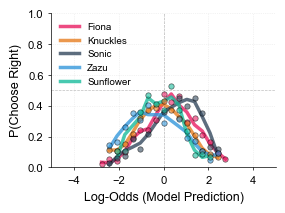

In [306]:
from scipy.signal import savgol_filter

fig = plt.figure(figsize=(4, 2))
gs = fig.add_gridspec(1, 2, width_ratios=[2.5, 0.5], wspace=0.3)

# Panel A: Individual curves
ax1 = fig.add_subplot(gs[0])

x_smooth = np.linspace(-5, 5, 100)

for animal in sort_animals(predictions_df['animal'].unique()):
    animal_data = predictions_df[predictions_df['animal'] == animal].copy()
    
    animal_data['log_odds_bin'] = pd.cut(animal_data['log_odds_clipped'], bins=bins)
    
    binned_animal = animal_data.groupby('log_odds_bin', observed=True).agg({
        'PhysicalSwitch': ['mean', 'count']
    }).reset_index()
    binned_animal.columns = ['log_odds_bin', 'PhysicalSwitch', 'n']
    binned_animal = binned_animal[binned_animal['n'] >= 5].dropna()
    binned_animal['bin_center'] = binned_animal['log_odds_bin'].apply(lambda x: x.mid)
    
    ax1.scatter(binned_animal['bin_center'], binned_animal['PhysicalSwitch'],
               color=ANIMAL_COLORS[animal], s=15, alpha=0.6, 
               edgecolor='black', linewidth=0.5, zorder=5)
    
    # Smooth the P(switch) curve
    if len(binned_animal) >= 5:
        smoothed = savgol_filter(binned_animal['PhysicalSwitch'], 
                                window_length=min(5, len(binned_animal)-1 if len(binned_animal) % 2 == 0 else len(binned_animal)), 
                                polyorder=2)
        
        ax1.plot(binned_animal['bin_center'], smoothed, 
                color=ANIMAL_COLORS[animal], linewidth=2.5, alpha=0.8, 
                label=animal, zorder=3)

# ax1.plot([-5, 5], [expit(-5), expit(5)], 'r--', linewidth=2, alpha=0.5, label='Perfect')
ax1.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.axvline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.set_xlabel('Log-Odds (Model Prediction)', fontsize=FONTSIZE+1)
ax1.set_ylabel('P(Choose Right)', fontsize=FONTSIZE+1)
# ax1.set_title('Individual Psychometric Curves', fontsize=FONTSIZE+2, fontweight='bold')
ax1.set_xlim(-5, 5)
ax1.set_ylim(0, 1)
ax1.legend(fontsize=FONTSIZE-1, frameon=False, loc='upper left')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='both', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Psychometric_Switch_Analysis_LeftRight_2ABT.svg'), dpi=300)
plt.show()


In [266]:
# set row options to 100 rows max
pd.set_option('display.max_rows', 100)

Generating log-odds for all trials...

Processing Fiona...
Processing Knuckles...
Processing Sonic...
Processing Zazu...
Processing Sunflower...

Added log-odds to 36,673 trials

Creating log-odds vs trial history plot...

Plotting 36,373 trials
Displaying 56 unique trial histories (n≥100)


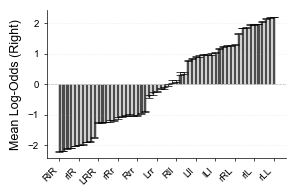


✓ Log-odds vs trial history figure saved!

Sample trial histories:
   RL_history  mean_logodds     n
25        RlR     -2.198446   157
37        lRR     -2.183165   920
41        llR     -2.109522   784
21        RRR     -2.089919  4642
53        rRR     -2.028531  1214
57        rlR     -1.991044   197
45        lrR     -1.968573   273
29        RrR     -1.899034  1361
9         LlR     -1.885028   319
61        rrR     -1.738482   464


In [305]:
# ============================================================================
# Generate Log-Odds for Every Trial in Original Dataset
# ============================================================================

from matplotlib.ticker import MaxNLocator


print("Generating log-odds for all trials...\n")

def generate_logodds_all_trials(data, alpha, beta, kappa):
    """Generate log-odds for every trial using Q-kernel model with left/right coding"""
    
    all_trials = []
    
    for session_id in data['Session_ID'].unique():
        session_data = data[data['Session_ID'] == session_id].sort_values('Trial').copy()
        
        # Initialize Q-values for left and right
        Q = {'left': 0.5, 'right': 0.5}
        C = {'left': 0.0, 'right': 0.0}
        
        for idx, trial_idx in enumerate(session_data.index):
            trial = session_data.loc[trial_idx]
            
            side_choice = trial['2ABT_side_Choice']  # 0=left, 1=right
            outcome = trial['Outcome']
            
            if pd.isna(side_choice) or pd.isna(outcome):
                continue
            
            chosen_side = 'right' if side_choice == 1 else 'left'
            other_side = 'left' if chosen_side == 'right' else 'right'
            
            # Calculate log-odds of choosing RIGHT
            V_right = beta * Q['right'] + kappa * C['right']
            V_left = beta * Q['left'] + kappa * C['left']
            
            p_right = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
            log_odds = np.log(p_right / (1 - p_right))
            
            all_trials.append({
                'original_index': trial_idx,
                'log_odds': log_odds,
                'p_right': p_right,
                'Q_left': Q['left'],
                'Q_right': Q['right']
            })
            
            # Update model
            Q[chosen_side] = Q[chosen_side] + alpha * (outcome - Q[chosen_side])
            C[chosen_side] = 1.0
            C[other_side] = 0.0
    
    return pd.DataFrame(all_trials)

# Generate log-odds for all animals
all_logodds = []

for animal in sort_animals(df['Animal_Name'].unique()):
    print(f"Processing {animal}...")
    
    animal_data = df[df['Animal_Name'] == animal].copy()
    
    # Add left/right coding
    animal_data['2ABT_side_Choice'] = animal_data['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    params = full_results[full_results['animal'] == animal].iloc[0]
    
    alpha = params['qlearn_kernel_alpha']
    beta = params['qlearn_kernel_beta']
    kappa = params['qlearn_kernel_kappa']
    
    logodds_df = generate_logodds_all_trials(animal_data, alpha, beta, kappa)
    all_logodds.append(logodds_df)

logodds_full = pd.concat(all_logodds, ignore_index=True)

# Merge back with original df
df_with_logodds = df.copy()
df_with_logodds = df_with_logodds.merge(logodds_full, left_index=True, right_on='original_index', how='left')

print(f"\nAdded log-odds to {df_with_logodds['log_odds'].notna().sum():,} trials")

# Create RL_history if not present
if 'RL_history' not in df_with_logodds.columns:
    print("\nCreating RL_history column...")
    N = 3  # History length
    df_with_logodds = add_history_cols_marmoset(df_with_logodds, N)
    print(f"Created RL_history for {df_with_logodds['RL_history'].notna().sum():,} trials")

# ============================================================================
# Plot Log-Odds vs Trial History
# ============================================================================

print("\nCreating log-odds vs trial history plot...\n")

fig, ax = plt.subplots(figsize=(3, 2))

# Filter for trials with both log_odds and RL_history
plot_data = df_with_logodds[df_with_logodds['log_odds'].notna() & 
                             df_with_logodds['RL_history'].notna()].copy()

print(f"Plotting {len(plot_data):,} trials")

# Group by RL_history and calculate mean log-odds
history_col = 'RL_history'
history_summary = plot_data.groupby(history_col).agg({
    'log_odds': ['mean', 'sem', 'count']
}).reset_index()
history_summary.columns = [history_col, 'mean_logodds', 'sem', 'n']

# Filter out rare sequences (need at least 100 trials)
history_summary = history_summary[history_summary['n'] >= 100].copy()

# Sort by mean log-odds
history_summary = history_summary.sort_values('mean_logodds')

print(f"Displaying {len(history_summary)} unique trial histories (n≥100)")

# Plot
x_pos = np.arange(len(history_summary))

bars = ax.bar(x_pos, history_summary['mean_logodds'], 
             color='black', alpha=0.7, edgecolor='white', linewidth=LINE_WIDTH)

ax.errorbar(x_pos, history_summary['mean_logodds'], yerr=history_summary['sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

ax.axhline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5, 
          label='No Bias (log-odds=0)')
max_labels = 12
x_pos = np.arange(len(history_summary))

step = max(1, int(np.ceil(len(x_pos) / max_labels)))
tick_idx = x_pos[::step]

ax.set_xticks(tick_idx)
ax.set_xticklabels(history_summary[history_col].iloc[::step],
                   rotation=45, ha='right', fontsize=FONTSIZE-1)
# ax.set_xticks(x_pos)
# ax.set_xticklabels(history_summary[history_col], rotation=45, ha='right', fontsize=FONTSIZE-1)
# ax.set_xlabel('Trial History (' + history_col + ')', fontsize=FONTSIZE+1)
# ax.xaxis.set_major_locator(MaxNLocator(nbins=10)) # Shows max 10 labels

ax.set_ylabel('Mean Log-Odds (Right)', fontsize=FONTSIZE+1)
# ax.set_title('Model Log-Odds by Trial History\n(L/R = Left/Right choice, uppercase = rewarded)', 
#             fontsize=FONTSIZE+2, fontweight='bold')
# ax.legend(fontsize=FONTSIZE, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, f'LogOdds_vs_Trial{history_col}_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Log-odds vs trial history figure saved!")
print(f"\nSample trial histories:")
print(history_summary[['RL_history', 'mean_logodds', 'n']].head(10))

In [316]:
blocks

array([5, 6])

<Figure size 1200x300 with 0 Axes>

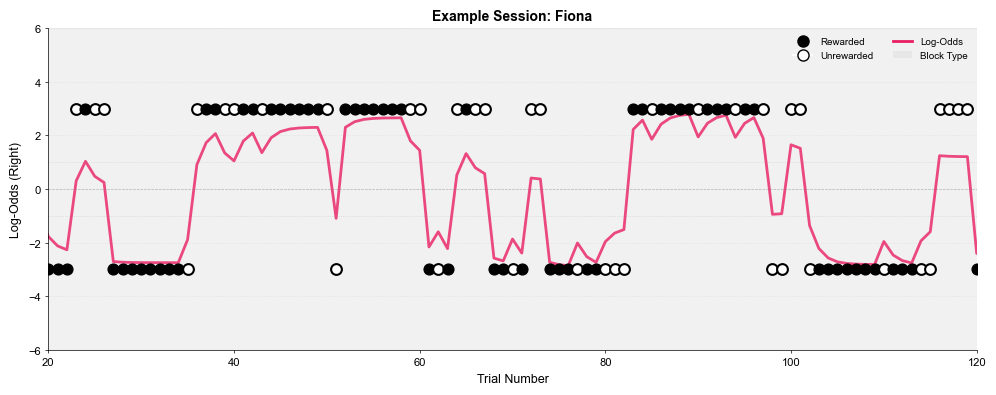


✓ Example session figure saved!


<Figure size 640x480 with 0 Axes>


✓ P(Switch) vs Log-Odds figure saved!


In [323]:
# ============================================================================
# Three-Panel Figure: Example Session + Psychometric + Parameters
# ============================================================================

fig = plt.figure(figsize=(12, 3))

# ====================================================================
# Panel A: Example Session - Log-Odds Over Time (REVISED)
# ====================================================================

# Pick a good example session (100+ trials)
example_session = None
for session_id in predictions_df['session_id'].unique():
    session_trials = predictions_df[predictions_df['session_id'] == session_id]
    if len(session_trials) >= 100:
        example_session = session_id
        break

if example_session:
    # Get predictions and merge with original data to get block info
    session_preds = predictions_df[predictions_df['session_id'] == example_session].head(180).copy()
    
    # Get corresponding trials from original df
    animal = session_preds['animal'].iloc[0]
    session_df = df[(df['Session_ID'] == example_session) & (df['Animal_Name'] == animal)].head(180).copy()
    
    # Add side choice to predictions
    session_df['2ABT_side_Choice'] = session_df['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    # Merge to get block info
    session_preds = session_preds.reset_index(drop=True)
    session_df = session_df.reset_index(drop=True)
    session_preds['Block'] = session_df['Block'].values
    session_preds['side_choice'] = session_df['2ABT_side_Choice'].values
    session_preds['outcome'] = session_df['Outcome'].values
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    trials = np.arange(len(session_preds))
    
    # Shade blocks (alternating blocks get shading)
    blocks = session_preds['Block'].unique()
    for block in blocks:
        block_trials = session_preds[session_preds['Block'] == block]
        start = block_trials.index[0]
        end = block_trials.index[-1]
        
        # Shade every other block (odd blocks)
        if int(block) % 2 == 1:
            ax.axvspan(start-0.5, end+0.5, color='lightgray', alpha=0.3, zorder=0)
    
    # Plot log-odds line
    ax.plot(trials, session_preds['log_odds'], '-', color=ANIMAL_COLORS[animal], 
            linewidth=2, alpha=0.8, zorder=2)
    
    # Plot choices as dots
    for idx, row in session_preds.iterrows():
        y_val = 3 if row['side_choice'] == 1 else -3  # Right=1, Left=-1
        
        if row['outcome'] == 1:  # Rewarded
            ax.scatter(idx, y_val, s=60, color='black', 
                      edgecolor='black', linewidth=1, zorder=5)
        else:  # Unrewarded
            ax.scatter(idx, y_val, s=60, color='white', 
                      edgecolor='black', linewidth=1.5, zorder=5)
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
    ax.axhline(1, color='gray', linestyle=':', linewidth=LINE_WIDTH, alpha=0.3)
    ax.axhline(-1, color='gray', linestyle=':', linewidth=LINE_WIDTH, alpha=0.3)
    
    ax.set_xlabel('Trial Number', fontsize=FONTSIZE+1)
    ax.set_ylabel('Log-Odds (Right)', fontsize=FONTSIZE+1)
    ax.set_title(f'Example Session: {animal}', fontsize=FONTSIZE+2, fontweight='bold')
    ax.set_ylim(-6, 6)
    ax.set_xlim(20, 120)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)
    
    # Add legend
    from matplotlib.patches import Patch
    import matplotlib.lines as mlines
    legend_elements = [
        mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
                     markersize=8, label='Rewarded', markeredgecolor='black', linewidth=0),
        mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', 
                     markersize=8, label='Unrewarded', markeredgecolor='black', linewidth=1.5),
        mlines.Line2D([0], [0], color=ANIMAL_COLORS[animal], linewidth=2, label='Log-Odds'),
        Patch(facecolor='lightgray', alpha=0.3, label='Block Type', edgecolor='none')
    ]
    ax.legend(handles=legend_elements, fontsize=FONTSIZE-1, frameon=False, 
             loc='upper right', ncol=2)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_PATH, 'Example_Session_LogOdds_2ABT.svg'), dpi=300)
    plt.show()
    
    print(f"\n✓ Example session figure saved!")


plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'PSwitch_vs_LogOdds_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ P(Switch) vs Log-Odds figure saved!")

Analyzing n-back trial weights...

Analyzing Fiona...
Analyzing Knuckles...
Analyzing Sonic...
Analyzing Zazu...
Analyzing Sunflower...


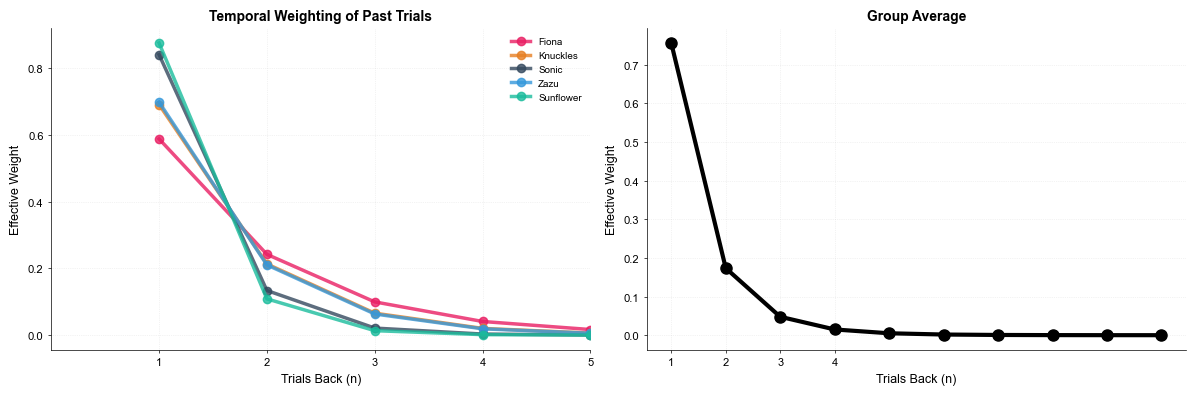


✓ N-back weights figure saved!

N-BACK WEIGHT SUMMARY

Effective trial weights:
 n_back     mean
      1 0.756058
      2 0.173584
      3 0.047704
      4 0.014862
      5 0.004999
      6 0.001763
      7 0.000642
      8 0.000240
      9 0.000091
     10 0.000035

Interpretation:
  - Trial n-1 has 0.756 weight
  - Trial n-5 has 0.005 weight
  - Trial n-10 has 0.000 weight


In [329]:
# ============================================================================
# N-Back Weight Analysis: How Much Each Previous Trial Influences Log-Odds
# ============================================================================

print("Analyzing n-back trial weights...\n")

def calculate_nback_weights(data, alpha, beta, kappa, N_back=10):
    """
    Calculate how much each n-back trial contributes to current log-odds
    by tracking Q-value updates
    """
    
    all_weights = []
    
    for session_id in data['Session_ID'].unique():
        session_data = data[data['Session_ID'] == session_id].sort_values('Trial').copy()
        
        # Add left/right coding
        session_data['2ABT_side_Choice'] = session_data['PhysicalChoice'].map({
            'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
            'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
        })
        
        session_data = session_data.dropna(subset=['2ABT_side_Choice', 'Outcome'])
        
        if len(session_data) < N_back + 1:
            continue
        
        # Track contribution of each past trial
        for idx in range(N_back, len(session_data)):
            current_trial = session_data.iloc[idx]
            
            # Get last N trials
            history = session_data.iloc[idx-N_back:idx]
            
            # Calculate effective weight of each past trial
            # Weight decays exponentially with learning rate
            weights = []
            for n in range(1, N_back+1):
                # Weight = (1-alpha)^(n-1) * alpha for Q-learning
                weight = alpha * ((1 - alpha) ** (n - 1))
                weights.append({
                    'n_back': n,
                    'weight': weight,
                    'trial_outcome': history.iloc[-n]['Outcome']
                })
            
            all_weights.extend(weights)
    
    return pd.DataFrame(all_weights)

# Calculate weights for each animal
all_animal_weights = []

for animal in sort_animals(df['Animal_Name'].unique()):
    print(f"Analyzing {animal}...")
    
    animal_data = df[df['Animal_Name'] == animal]
    params = full_results[full_results['animal'] == animal].iloc[0]
    
    alpha = params['qlearn_kernel_alpha']
    beta = params['qlearn_kernel_beta']
    kappa = params['qlearn_kernel_kappa']
    
    weights_df = calculate_nback_weights(animal_data, alpha, beta, kappa, N_back=10)
    weights_df['animal'] = animal
    
    all_animal_weights.append(weights_df)

weights_full = pd.concat(all_animal_weights, ignore_index=True)

# ============================================================================
# Plot N-Back Weights
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel A: Individual animals
ax1 = axes[0]

for animal in sort_animals(weights_full['animal'].unique()):
    animal_weights = weights_full[weights_full['animal'] == animal]
    
    # Average weight per n-back
    avg_weights = animal_weights.groupby('n_back')['weight'].mean()
    
    ax1.plot(avg_weights.index, avg_weights.values, 'o-', 
            color=ANIMAL_COLORS[animal], linewidth=2.5, markersize=6,
            label=animal, alpha=0.8)

ax1.set_xlabel('Trials Back (n)', fontsize=FONTSIZE+1)
ax1.set_ylabel('Effective Weight', fontsize=FONTSIZE+1)
ax1.set_title('Temporal Weighting of Past Trials', fontsize=FONTSIZE+2, fontweight='bold')
ax1.set_xlim(0, 5)
ax1.set_xticks(range(1, 6))
ax1.legend(fontsize=FONTSIZE-1, frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='both', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel B: Group average with SEM
ax2 = axes[1]

group_weights = weights_full.groupby('n_back').agg({
    'weight': ['mean', 'sem']
}).reset_index()
group_weights.columns = ['n_back', 'mean', 'sem']

ax2.plot(group_weights['n_back'], group_weights['mean'], 'o-', 
        color='black', linewidth=3, markersize=8, label='Group Average')
ax2.fill_between(group_weights['n_back'], 
                group_weights['mean'] - group_weights['sem'],
                group_weights['mean'] + group_weights['sem'],
                color='black', alpha=0.2)

ax2.set_xlabel('Trials Back (n)', fontsize=FONTSIZE+1)
ax2.set_ylabel('Effective Weight', fontsize=FONTSIZE+1)
ax2.set_title('Group Average', fontsize=FONTSIZE+2, fontweight='bold')
ax2.set_xticks(range(1, 5))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='both', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'NBack_Weights_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ N-back weights figure saved!")

# Print summary
print("\n" + "="*70)
print("N-BACK WEIGHT SUMMARY")
print("="*70)
print("\nEffective trial weights:")
print(group_weights[['n_back', 'mean']].to_string(index=False))
print(f"\nInterpretation:")
print(f"  - Trial n-1 has {group_weights['mean'].iloc[0]:.3f} weight")
print(f"  - Trial n-5 has {group_weights['mean'].iloc[4]:.3f} weight")
print(f"  - Trial n-10 has {group_weights['mean'].iloc[9]:.3f} weight")
print("="*70)

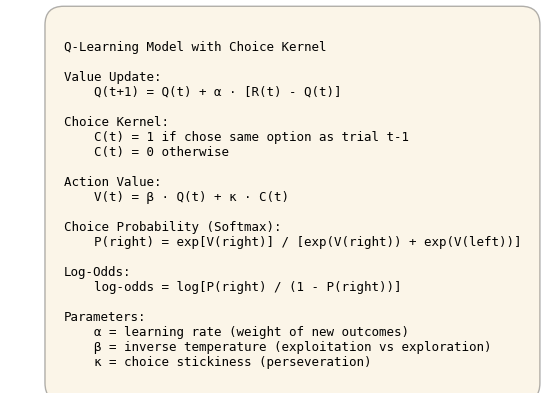


✓ Model equations figure saved!


In [327]:
# ============================================================================
# Panel: Q-Learning Model Equations (Simplified)
# ============================================================================

fig, ax = plt.subplots(figsize=(6, 4))

ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Model equations as text
equations_text = """
Q-Learning Model with Choice Kernel

Value Update:
    Q(t+1) = Q(t) + α · [R(t) - Q(t)]

Choice Kernel:
    C(t) = 1 if chose same option as trial t-1
    C(t) = 0 otherwise

Action Value:
    V(t) = β · Q(t) + κ · C(t)

Choice Probability (Softmax):
    P(right) = exp[V(right)] / [exp(V(right)) + exp(V(left))]

Log-Odds:
    log-odds = log[P(right) / (1 - P(right))]

Parameters:
    α = learning rate (weight of new outcomes)
    β = inverse temperature (exploitation vs exploration)
    κ = choice stickiness (perseveration)
"""

ax.text(0.1, 0.95, equations_text, transform=ax.transAxes,
       fontsize=FONTSIZE+1, verticalalignment='top',
       family='monospace', 
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3, pad=1.5))

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'QKernel_Model_Equations.svg'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Model equations figure saved!")

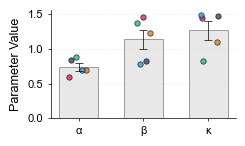


✓ Model parameters figure saved!

MODEL PARAMETERS SUMMARY
α: 0.739 ± 0.053
β: 1.133 ± 0.141
κ: 1.264 ± 0.131


In [336]:
# ============================================================================
# Model Parameters: Alpha, Beta, Kappa
# ============================================================================

fig, ax = plt.subplots(figsize=(2.5, 1.5))

params = ['qlearn_kernel_alpha', 'qlearn_kernel_beta', 'qlearn_kernel_kappa']
param_labels = ['Learning Rate\n(α)', 'Inverse Temp\n(β)', 'Stickiness\n(κ)']
param_labels = ['α', 'β', 'κ']

x_pos = np.arange(len(params))
width = 0.6

# Calculate mean and SEM for each parameter
param_means = [full_results[param].mean() for param in params]
param_sems = [full_results[param].sem() for param in params]

# Plot bars
bars = ax.bar(x_pos, param_means, width,
              color='lightgray', alpha=0.5, edgecolor='black', linewidth=LINE_WIDTH)

# Error bars
ax.errorbar(x_pos, param_means, yerr=param_sems,
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual animal points
for i, param in enumerate(params):
    for _, row in full_results.iterrows():
        animal = row['animal']
        value = row[param]
        
        x_jitter = i + np.random.uniform(-0.15, 0.15)
        
        ax.scatter(x_jitter, value, s=15, 
                  color=ANIMAL_COLORS[animal],
                  alpha=0.8, edgecolor='black', linewidth=0.5, zorder=5)

# Reference lines
ax.axhline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(param_labels, fontsize=FONTSIZE)
ax.set_ylabel('Parameter Value', fontsize=FONTSIZE+1)
# ax.set_title('Q-Learning Model Parameters', fontsize=FONTSIZE+2, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# # Add legend
# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor=ANIMAL_COLORS[animal], 
#                         label=animal, alpha=0.8, edgecolor='black')
#                   for animal in sort_animals(full_results['animal'].unique())]
# ax.legend(handles=legend_elements, fontsize=FONTSIZE-2, 
#           frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'QKernel_Parameters_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Model parameters figure saved!")

# Print summary
print("\n" + "="*70)
print("MODEL PARAMETERS SUMMARY")
print("="*70)
for param, label in zip(params, param_labels):
    mean_val = full_results[param].mean()
    sem_val = full_results[param].sem()
    print(f"{label.replace(chr(10), ' ')}: {mean_val:.3f} ± {sem_val:.3f}")
print("="*70)

Calculating conditional probabilities by RL_history...

Analyzing 36,373 trials
Displaying 56 unique trial histories (n≥100)


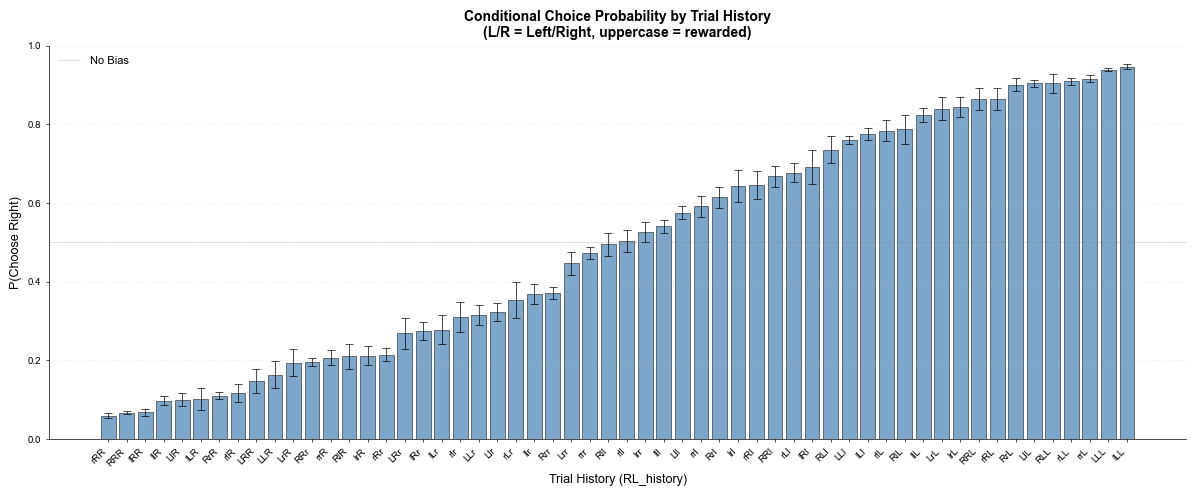


✓ Conditional probability figure saved!

KEY PATTERNS

Most right-biased histories:
   RL_history   p_right     n
16        RLL  0.904110   146
48        rLL  0.908818   998
60        rrL  0.915976   845
0         LLL  0.938310  4555
32        lLL  0.946264  1191

Most left-biased histories:
   RL_history   p_right     n
53        rRR  0.060132  1214
21        RRR  0.066997  4642
37        lRR  0.068478   920
41        llR  0.098214   784
9         LlR  0.100313   319


In [337]:
# ============================================================================
# Conditional Probabilities by RL_History
# ============================================================================

print("Calculating conditional probabilities by RL_history...\n")

# Make sure we have RL_history in df
if 'RL_history' not in df.columns:
    print("Creating RL_history column...")
    N = 3
    df = add_history_cols_marmoset(df, N)

# Add left/right coding
df['2ABT_side_Choice'] = df['PhysicalChoice'].map({
    'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
    'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
})

# Filter for valid data
plot_data = df[df['RL_history'].notna() & df['2ABT_side_Choice'].notna()].copy()

print(f"Analyzing {len(plot_data):,} trials")

# Group by RL_history and calculate P(choose right)
history_summary = plot_data.groupby('RL_history').agg({
    '2ABT_side_Choice': ['mean', 'sem', 'count']
}).reset_index()
history_summary.columns = ['RL_history', 'p_right', 'sem', 'n']

# Filter for histories with sufficient data
history_summary = history_summary[history_summary['n'] >= 100].copy()
history_summary = history_summary.sort_values('p_right')

print(f"Displaying {len(history_summary)} unique trial histories (n≥100)")

# Create figure
fig, ax = plt.subplots(figsize=(12, 5))

x_pos = np.arange(len(history_summary))

# Plot bars
bars = ax.bar(x_pos, history_summary['p_right'], 
             color='steelblue', alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

# Error bars
ax.errorbar(x_pos, history_summary['p_right'], yerr=history_summary['sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Reference line at 0.5 (no bias)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5,
          label='No Bias')

ax.set_xticks(x_pos)
ax.set_xticklabels(history_summary['RL_history'], rotation=45, ha='right', fontsize=FONTSIZE-1)
ax.set_xlabel('Trial History (RL_history)', fontsize=FONTSIZE+1)
ax.set_ylabel('P(Choose Right)', fontsize=FONTSIZE+1)
ax.set_title('Conditional Choice Probability by Trial History\n(L/R = Left/Right, uppercase = rewarded)',
            fontsize=FONTSIZE+2, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(fontsize=FONTSIZE, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Conditional_Probability_RL_History_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Conditional probability figure saved!")

# Print interesting patterns
print("\n" + "="*70)
print("KEY PATTERNS")
print("="*70)
print("\nMost right-biased histories:")
print(history_summary.tail(5)[['RL_history', 'p_right', 'n']])

print("\nMost left-biased histories:")
print(history_summary.head(5)[['RL_history', 'p_right', 'n']])
print("="*70)

Calculating P(switch) by RL_history...

Analyzing 36,373 trials
Displaying 56 unique trial histories (n≥100)


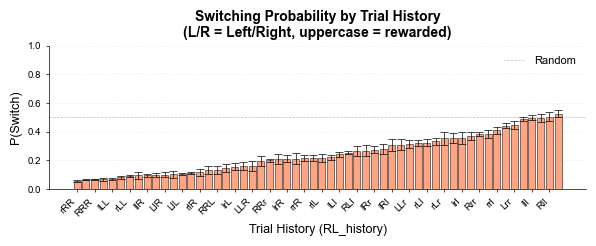


✓ P(switch) by trial history figure saved!

KEY PATTERNS

Lowest switching (most stay):
   RL_history  p_switch     n
53        rRR  0.060132  1214
0         LLL  0.064325  4555
21        RRR  0.067859  4642
37        lRR  0.068478   920
32        lLL  0.069689  1191

Highest switching:
   RL_history  p_switch     n
63        rrr  0.488307  1069
42        lll  0.496652   896
58        rll  0.496732   306
26        Rll  0.505085   295
47        lrr  0.526185   401


In [340]:
# ============================================================================
# P(Switch) by RL_History
# ============================================================================

print("Calculating P(switch) by RL_history...\n")

# Filter for valid data with switch information
plot_data = df[df['RL_history'].notna() & df['PhysicalSwitch'].notna()].copy()

print(f"Analyzing {len(plot_data):,} trials")

# Group by RL_history and calculate P(switch)
history_switch = plot_data.groupby('RL_history').agg({
    'PhysicalSwitch': ['mean', 'sem', 'count']
}).reset_index()
history_switch.columns = ['RL_history', 'p_switch', 'sem', 'n']

# Filter for histories with sufficient data
history_switch = history_switch[history_switch['n'] >= 100].copy()
history_switch = history_switch.sort_values('p_switch')

print(f"Displaying {len(history_switch)} unique trial histories (n≥100)")

# Create figure
fig, ax = plt.subplots(figsize=(6, 2.5))

x_pos = np.arange(len(history_switch))

# Plot bars
bars = ax.bar(x_pos, history_switch['p_switch'], 
             color='coral', alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

# Error bars
ax.errorbar(x_pos, history_switch['p_switch'], yerr=history_switch['sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Reference line at 0.5 (random switching)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5,
          label='Random')

# ax.set_xticks(x_pos)
# ax.set_xticklabels(history_switch['RL_history'], rotation=45, ha='right', fontsize=FONTSIZE-1)

# Replace the xticks section with:
ax.set_xticks(x_pos[::2])  # Every other tick
ax.set_xticklabels(history_switch['RL_history'].iloc[::2], rotation=45, ha='right', fontsize=FONTSIZE-1)

ax.set_xlabel('Trial History (RL_history)', fontsize=FONTSIZE+1)
ax.set_ylabel('P(Switch)', fontsize=FONTSIZE+1)
ax.set_title('Switching Probability by Trial History\n(L/R = Left/Right, uppercase = rewarded)',
            fontsize=FONTSIZE+2, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(fontsize=FONTSIZE, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'PSwitch_by_RL_History_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ P(switch) by trial history figure saved!")

# Print interesting patterns
print("\n" + "="*70)
print("KEY PATTERNS")
print("="*70)
print("\nLowest switching (most stay):")
print(history_switch.head(5)[['RL_history', 'p_switch', 'n']])

print("\nHighest switching:")
print(history_switch.tail(5)[['RL_history', 'p_switch', 'n']])
print("="*70)

Analyzing P(switch) by symmetrical history...

Analyzing 36,373 trials
Found 29 unique symmetrical histories


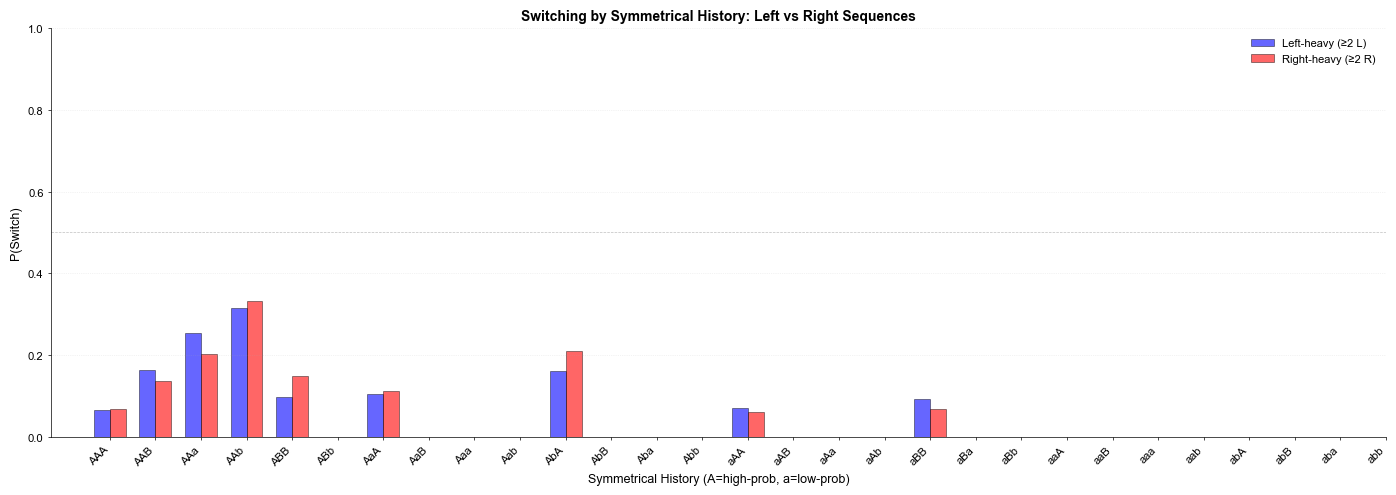


✓ Symmetrical history comparison figure saved!

EXAMPLE MAPPINGS

Symmetrical 'AAA' includes:
  ['RRR' 'LLL']

Symmetrical 'aaa' includes:
  ['rrr' 'lll']


In [341]:
# ============================================================================
# P(Switch) by Symmetrical History - Comparing Left vs Right Sequences
# ============================================================================

print("Analyzing P(switch) by symmetrical history...\n")

# Filter for valid data
plot_data = df[df['history'].notna() & df['PhysicalSwitch'].notna() & df['RL_history'].notna()].copy()

print(f"Analyzing {len(plot_data):,} trials")

# Group by both symmetrical history and RL_history (physical side)
history_switch = plot_data.groupby(['history', 'RL_history']).agg({
    'PhysicalSwitch': ['mean', 'sem', 'count']
}).reset_index()
history_switch.columns = ['history', 'RL_history', 'p_switch', 'sem', 'n']

# Filter for sufficient data
history_switch = history_switch[history_switch['n'] >= 50].copy()

# Get unique symmetrical histories
unique_histories = sorted(history_switch['history'].unique())

print(f"Found {len(unique_histories)} unique symmetrical histories")

# Create figure
fig, ax = plt.subplots(figsize=(14, 5))

x_pos = np.arange(len(unique_histories))
width = 0.35

# For each symmetrical history, separate by left/right dominance
left_biased = []
right_biased = []

for hist in unique_histories:
    hist_data = history_switch[history_switch['history'] == hist]
    
    # Separate by whether it's more left or right choices
    left_variants = hist_data[hist_data['RL_history'].str.count('L') >= 2]
    right_variants = hist_data[hist_data['RL_history'].str.count('R') >= 2]
    
    left_mean = left_variants['p_switch'].mean() if len(left_variants) > 0 else np.nan
    right_mean = right_variants['p_switch'].mean() if len(right_variants) > 0 else np.nan
    
    left_biased.append(left_mean)
    right_biased.append(right_mean)

# Plot bars
bars1 = ax.bar(x_pos - width/2, left_biased, width,
              label='Left-heavy (≥2 L)', color='blue', alpha=0.6, 
              edgecolor='black', linewidth=LINE_WIDTH)

bars2 = ax.bar(x_pos + width/2, right_biased, width,
              label='Right-heavy (≥2 R)', color='red', alpha=0.6,
              edgecolor='black', linewidth=LINE_WIDTH)

# Reference line
ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(unique_histories, rotation=45, ha='right', fontsize=FONTSIZE)
ax.set_xlabel('Symmetrical History (A=high-prob, a=low-prob)', fontsize=FONTSIZE+1)
ax.set_ylabel('P(Switch)', fontsize=FONTSIZE+1)
ax.set_title('Switching by Symmetrical History: Left vs Right Sequences',
            fontsize=FONTSIZE+2, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(fontsize=FONTSIZE, frameon=False, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'PSwitch_Symmetrical_History_LeftRight_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Symmetrical history comparison figure saved!")

# Print examples
print("\n" + "="*70)
print("EXAMPLE MAPPINGS")
print("="*70)
print("\nSymmetrical 'AAA' includes:")
sample_aaa = plot_data[plot_data['history'] == 'AAA']['RL_history'].unique()
print(f"  {sample_aaa[:5]}")  # Show first 5

print("\nSymmetrical 'aaa' includes:")
sample_aaa_low = plot_data[plot_data['history'] == 'aaa']['RL_history'].unique()
print(f"  {sample_aaa_low[:5]}")
print("="*70)

Creating scatter plot of matched left/right sequences...

Found 22 matched pairs


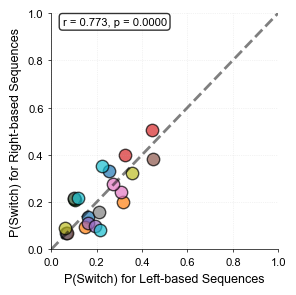


✓ Scatter plot saved!

EXAMPLE MATCHED PAIRS
  left_seq right_seq history  left_pswitch  right_pswitch
0      LLL       RRR     AAA      0.064325       0.067859
1      LLR       RRL     AAB      0.163793       0.135714
2      LLl       RRl     AAa      0.253676       0.332298
3      LLr       RRr     AAb      0.315315       0.201447
4      LRR       RLL     ABB      0.148148       0.095890
5      LlL       RlR     AaA      0.103676       0.210191
6      LlR       RlL     AaB      0.100313       0.212598
7      Lll       Rll     Aaa      0.443330       0.505085
8      Llr       Rlr     Aab      0.323144       0.400000
9      LrL       RrR     AbA      0.160494       0.112417


In [345]:
# ============================================================================
# Scatter Plot: P(Switch) for Matched Left vs Right Sequences
# ============================================================================

print("Creating scatter plot of matched left/right sequences...\n")

# Filter for valid data
plot_data = df[df['history'].notna() & df['PhysicalSwitch'].notna() & df['RL_history'].notna()].copy()

# Calculate P(switch) for each RL_history
rl_history_switch = plot_data.groupby('RL_history').agg({
    'PhysicalSwitch': ['mean', 'count'],
    'history': 'first'  # Get the symmetrical history
}).reset_index()
rl_history_switch.columns = ['RL_history', 'p_switch', 'n', 'history']

# Filter for sufficient data
rl_history_switch = rl_history_switch[rl_history_switch['n'] >= 50].copy()

# Create matched pairs (L <-> R)
matched_pairs = []

for _, row in rl_history_switch.iterrows():
    rl_hist = row['RL_history']
    
    # Create the mirror sequence (swap L and R)
    mirror = rl_hist.replace('L', 'TEMP').replace('R', 'L').replace('TEMP', 'R')
    
    # Find the mirror in the data
    mirror_data = rl_history_switch[rl_history_switch['RL_history'] == mirror]
    
    if len(mirror_data) > 0:
        # Only add if we haven't already added the reverse pair
        if rl_hist < mirror:  # Alphabetical ordering to avoid duplicates
            matched_pairs.append({
                'left_seq': rl_hist if 'L' in rl_hist[:1] else mirror,
                'right_seq': mirror if 'L' in rl_hist[:1] else rl_hist,
                'left_pswitch': row['p_switch'] if 'L' in rl_hist[:1] else mirror_data['p_switch'].iloc[0],
                'right_pswitch': mirror_data['p_switch'].iloc[0] if 'L' in rl_hist[:1] else row['p_switch'],
                'history': row['history']
            })

matched_df = pd.DataFrame(matched_pairs)

print(f"Found {len(matched_df)} matched pairs")

# Create scatter plot
fig, ax = plt.subplots(figsize=(3, 3))

# Color by symmetrical history
unique_histories = matched_df['history'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_histories)))
history_colors = dict(zip(unique_histories, colors))

for hist in unique_histories:
    hist_data = matched_df[matched_df['history'] == hist]
    ax.scatter(hist_data['left_pswitch'], hist_data['right_pswitch'],
              s=80, color=history_colors[hist], alpha=0.7,
              edgecolor='black', linewidth=1, label=hist)

# Identity line
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Identity')

ax.set_xlabel('P(Switch) for Left-based Sequences', fontsize=FONTSIZE+1)
ax.set_ylabel('P(Switch) for Right-based Sequences', fontsize=FONTSIZE+1)
# ax.set_title('Switching Probability: Left vs Right Sequences\n(Matched by Symmetrical History)',
#             fontsize=FONTSIZE+2, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
# ax.legend(fontsize=FONTSIZE-2, frameon=False, loc='upper left', ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='both', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# Add correlation
from scipy.stats import pearsonr
r, p = pearsonr(matched_df['left_pswitch'], matched_df['right_pswitch'])
ax.text(0.05, 0.95, f'r = {r:.3f}, p = {p:.4f}', 
       transform=ax.transAxes, fontsize=FONTSIZE,
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'PSwitch_Scatter_LeftRight_Matched_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Scatter plot saved!")

# Print examples
print("\n" + "="*70)
print("EXAMPLE MATCHED PAIRS")
print("="*70)
print(matched_df[['left_seq', 'right_seq', 'history', 'left_pswitch', 'right_pswitch']].head(10))
print("="*70)

Analyzing behavioral states...

Analyzed 35,773 trials across 100 sessions

STATE DISTRIBUTION

Overall state distribution:
state
Mixed         11746
Left Bias      7387
Right Bias     7152
Engaged        5793
Random         2173
Disengaged     1522
Name: count, dtype: int64

Percentages:
state
Mixed         32.8
Left Bias     20.6
Right Bias    20.0
Engaged       16.2
Random         6.1
Disengaged     4.3
Name: count, dtype: float64

Per animal:

Fiona:
state
Left Bias     33.8
Mixed         23.0
Right Bias    19.6
Engaged       16.2
Random         4.5
Disengaged     2.7
Name: count, dtype: float64

Knuckles:
state
Mixed         35.3
Right Bias    20.8
Engaged       18.9
Left Bias     14.7
Random         6.0
Disengaged     4.2
Name: count, dtype: float64

Sonic:
state
Left Bias     43.7
Mixed         29.6
Engaged       10.9
Random         6.8
Disengaged     5.6
Right Bias     3.4
Name: count, dtype: float64

Zazu:
state
Right Bias    40.9
Mixed         30.3
Engaged       10.0
Disengag

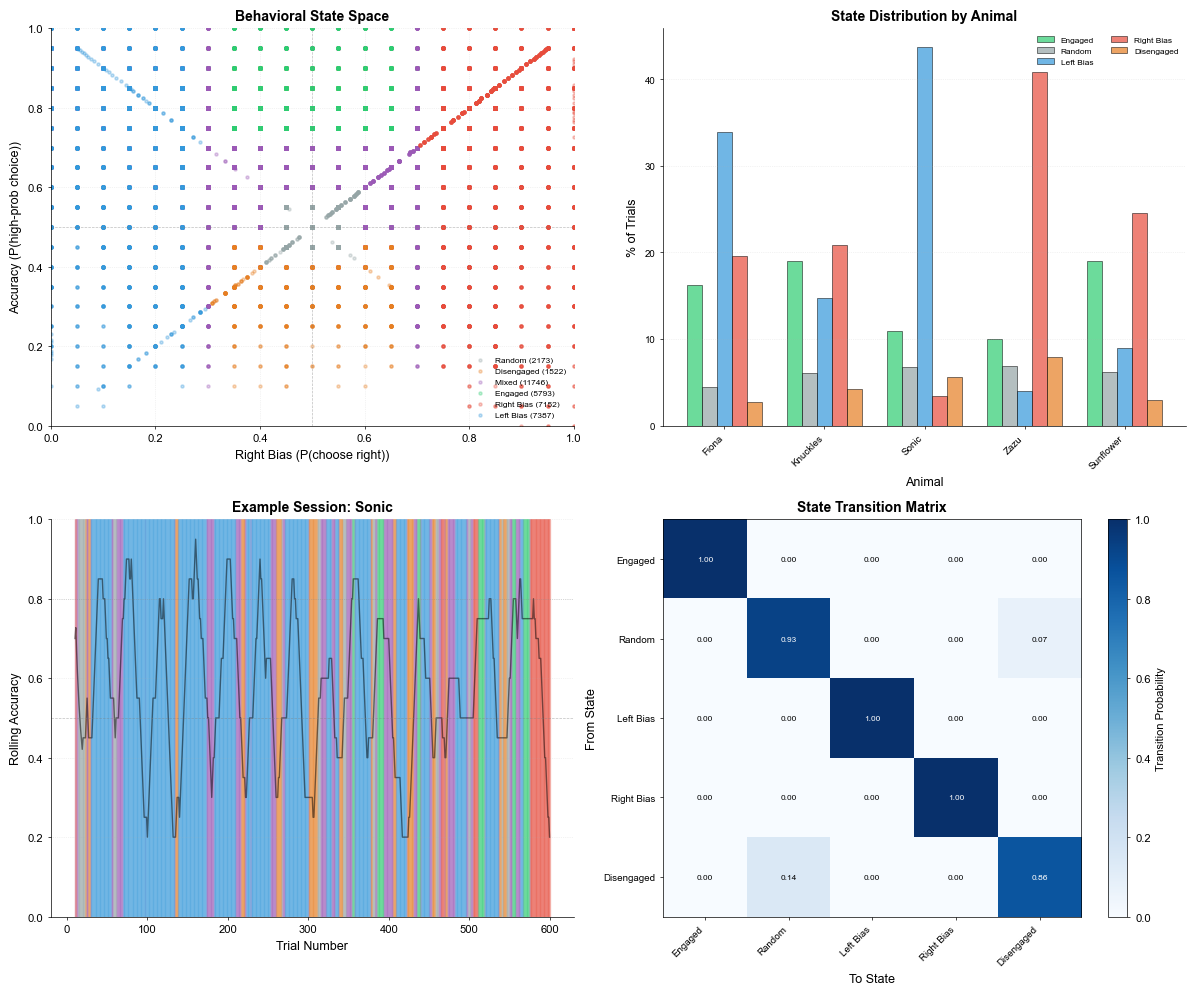


✓ Behavioral states analysis figure saved!


In [347]:
#  Basic State Analysis
# ============================================================================
# Question 2: Identifying Behavioral States
# ============================================================================

print("Analyzing behavioral states...\n")

# Calculate rolling metrics per session
WINDOW = 20  # Rolling window size

state_data = []

for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    
    if len(session_df) < WINDOW:
        continue
    
    animal = session_df['Animal_Name'].iloc[0]
    
    # Add left/right coding
    session_df['2ABT_side_Choice'] = session_df['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    # Calculate rolling metrics
    session_df['rolling_accuracy'] = session_df['High_Prob'].rolling(window=WINDOW, min_periods=10).mean()
    session_df['rolling_right_bias'] = session_df['2ABT_side_Choice'].rolling(window=WINDOW, min_periods=10).mean()
    
    # Win-stay / Lose-shift within window
    session_df['Prev_Outcome'] = session_df['Outcome'].shift(1)
    session_df['stayed'] = (session_df['PhysicalSwitch'] == 0).astype(float)
    
    # Rolling win-stay
    win_trials = session_df[session_df['Prev_Outcome'] == 1]
    session_df.loc[win_trials.index, 'win_stay_temp'] = win_trials['stayed']
    session_df['rolling_win_stay'] = session_df['win_stay_temp'].rolling(window=WINDOW, min_periods=5).mean()
    
    # Store trial-level data
    for idx, trial in session_df.iterrows():
        if pd.notna(trial['rolling_accuracy']):
            state_data.append({
                'session_id': session_id,
                'animal': animal,
                'trial': trial['Trial'],
                'accuracy': trial['rolling_accuracy'],
                'right_bias': trial['rolling_right_bias'],
                'win_stay': trial['rolling_win_stay']
            })

state_df = pd.DataFrame(state_data)

print(f"Analyzed {len(state_df):,} trials across {state_df['session_id'].nunique()} sessions")

# ============================================================================
# Classify States Based on Metrics
# ============================================================================

# Define state criteria
def classify_state(row):
    acc = row['accuracy']
    bias = row['right_bias']
    
    # Engaged: High accuracy (>0.7), not too biased
    if acc > 0.7 and 0.3 < bias < 0.7:
        return 'Engaged'
    
    # Random: ~50% accuracy, ~50% right bias
    elif 0.4 < acc < 0.6 and 0.4 < bias < 0.6:
        return 'Random'
    
    # Left bias: Any accuracy, strong left preference
    elif bias < 0.3:
        return 'Left Bias'
    
    # Right bias: Any accuracy, strong right preference
    elif bias > 0.7:
        return 'Right Bias'
    
    # Low engagement: Low accuracy, not strongly biased
    elif acc < 0.5 and 0.3 < bias < 0.7:
        return 'Disengaged'
    
    else:
        return 'Mixed'

state_df['state'] = state_df.apply(classify_state, axis=1)

# Summary
print("\n" + "="*70)
print("STATE DISTRIBUTION")
print("="*70)

state_counts = state_df['state'].value_counts()
print("\nOverall state distribution:")
print(state_counts)
print(f"\nPercentages:")
print((state_counts / len(state_df) * 100).round(1))

print("\nPer animal:")
for animal in sort_animals(state_df['animal'].unique()):
    animal_states = state_df[state_df['animal'] == animal]['state'].value_counts()
    print(f"\n{animal}:")
    print((animal_states / len(state_df[state_df['animal'] == animal]) * 100).round(1))

# ============================================================================
# Visualize States
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Panel A: Accuracy vs Right Bias (colored by state)
ax1 = axes[0, 0]

state_colors = {
    'Engaged': '#2ecc71',
    'Random': '#95a5a6',
    'Left Bias': '#3498db',
    'Right Bias': '#e74c3c',
    'Disengaged': '#e67e22',
    'Mixed': '#9b59b6'
}

for state in state_df['state'].unique():
    state_trials = state_df[state_df['state'] == state]
    ax1.scatter(state_trials['right_bias'], state_trials['accuracy'],
               s=5, alpha=0.3, color=state_colors.get(state, 'gray'),
               label=f"{state} ({len(state_trials)})")

ax1.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.axvline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.set_xlabel('Right Bias (P(choose right))', fontsize=FONTSIZE+1)
ax1.set_ylabel('Accuracy (P(high-prob choice))', fontsize=FONTSIZE+1)
ax1.set_title('Behavioral State Space', fontsize=FONTSIZE+2, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.legend(fontsize=FONTSIZE-2, frameon=False, loc='lower right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel B: State proportions by animal
ax2 = axes[0, 1]

# Get main states only (exclude Mixed)
main_states = ['Engaged', 'Random', 'Left Bias', 'Right Bias', 'Disengaged']
animals = sort_animals(state_df['animal'].unique())

state_props = []
for animal in animals:
    animal_df = state_df[state_df['animal'] == animal]
    props = []
    for state in main_states:
        prop = (animal_df['state'] == state).sum() / len(animal_df) * 100
        props.append(prop)
    state_props.append(props)

state_props = np.array(state_props)

x = np.arange(len(animals))
width = 0.15

for i, state in enumerate(main_states):
    ax2.bar(x + i*width - 2*width, state_props[:, i], width,
           label=state, color=state_colors[state], alpha=0.7,
           edgecolor='black', linewidth=LINE_WIDTH)

ax2.set_xticks(x)
ax2.set_xticklabels(animals, rotation=45, ha='right', fontsize=FONTSIZE-1)
ax2.set_ylabel('% of Trials', fontsize=FONTSIZE+1)
ax2.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax2.set_title('State Distribution by Animal', fontsize=FONTSIZE+2, fontweight='bold')
ax2.legend(fontsize=FONTSIZE-2, frameon=False, ncol=2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# Panel C: Example session showing state transitions
ax3 = axes[1, 0]

# Pick a good example session
example_session = state_df['session_id'].value_counts().index[0]
session_states = state_df[state_df['session_id'] == example_session].copy()
animal = session_states['animal'].iloc[0]

trials = session_states['trial'].values
accuracy = session_states['accuracy'].values

# Plot accuracy
ax3.plot(trials, accuracy, 'k-', linewidth=1, alpha=0.5)

# Color background by state
for state in session_states['state'].unique():
    state_trials = session_states[session_states['state'] == state]
    for _, trial in state_trials.iterrows():
        ax3.axvspan(trial['trial']-0.5, trial['trial']+0.5,
                   color=state_colors.get(state, 'gray'), alpha=0.3, zorder=0)

ax3.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax3.axhline(0.8, color='gray', linestyle=':', linewidth=LINE_WIDTH, alpha=0.5)
ax3.set_xlabel('Trial Number', fontsize=FONTSIZE+1)
ax3.set_ylabel('Rolling Accuracy', fontsize=FONTSIZE+1)
ax3.set_title(f'Example Session: {animal}', fontsize=FONTSIZE+2, fontweight='bold')
ax3.set_ylim(0, 1)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax3.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel D: State transition matrix
ax4 = axes[1, 1]

# Calculate state transitions
transitions = []
for session_id in state_df['session_id'].unique():
    sess = state_df[state_df['session_id'] == session_id].sort_values('trial')
    for i in range(len(sess)-1):
        from_state = sess.iloc[i]['state']
        to_state = sess.iloc[i+1]['state']
        if from_state in main_states and to_state in main_states:
            transitions.append({'from': from_state, 'to': to_state})

trans_df = pd.DataFrame(transitions)
trans_matrix = pd.crosstab(trans_df['from'], trans_df['to'], normalize='index')
trans_matrix = trans_matrix.reindex(index=main_states, columns=main_states, fill_value=0)

im = ax4.imshow(trans_matrix.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)

ax4.set_xticks(range(len(main_states)))
ax4.set_xticklabels(main_states, rotation=45, ha='right', fontsize=FONTSIZE-1)
ax4.set_yticks(range(len(main_states)))
ax4.set_yticklabels(main_states, fontsize=FONTSIZE-1)
ax4.set_xlabel('To State', fontsize=FONTSIZE+1)
ax4.set_ylabel('From State', fontsize=FONTSIZE+1)
ax4.set_title('State Transition Matrix', fontsize=FONTSIZE+2, fontweight='bold')

# Add values
for i in range(len(main_states)):
    for j in range(len(main_states)):
        text = ax4.text(j, i, f'{trans_matrix.values[i, j]:.2f}',
                       ha='center', va='center', color='white' if trans_matrix.values[i, j] > 0.5 else 'black',
                       fontsize=FONTSIZE-2)

plt.colorbar(im, ax=ax4, label='Transition Probability')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Behavioral_States_Analysis_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Behavioral states analysis figure saved!")
print("="*70)

Analyzing behavioral states (REVISED - relative bias)...

Analyzed 35,773 trials

REVISED STATE DISTRIBUTION

Overall state distribution:
state
Left Bias            9849
Mixed                9311
Engaged              5821
Random               4291
Right Bias           2536
Biased (unstable)    2323
Disengaged           1642
Name: count, dtype: int64

Percentages:
state
Left Bias            27.5
Mixed                26.0
Engaged              16.3
Random               12.0
Right Bias            7.1
Biased (unstable)     6.5
Disengaged            4.6
Name: count, dtype: float64

EXAMPLE: High Accuracy vs Biased

Engaged trials (high accuracy, following rewards):
       accuracy  right_raw  policy_deviation  side_bias
86         0.85       0.65               0.2       0.15
25326      1.00       0.90               0.1       0.40
8147       1.00       1.00               0.0       0.50

Biased trials (side preference regardless of reward):
       accuracy  right_raw  policy_deviation  side_bi

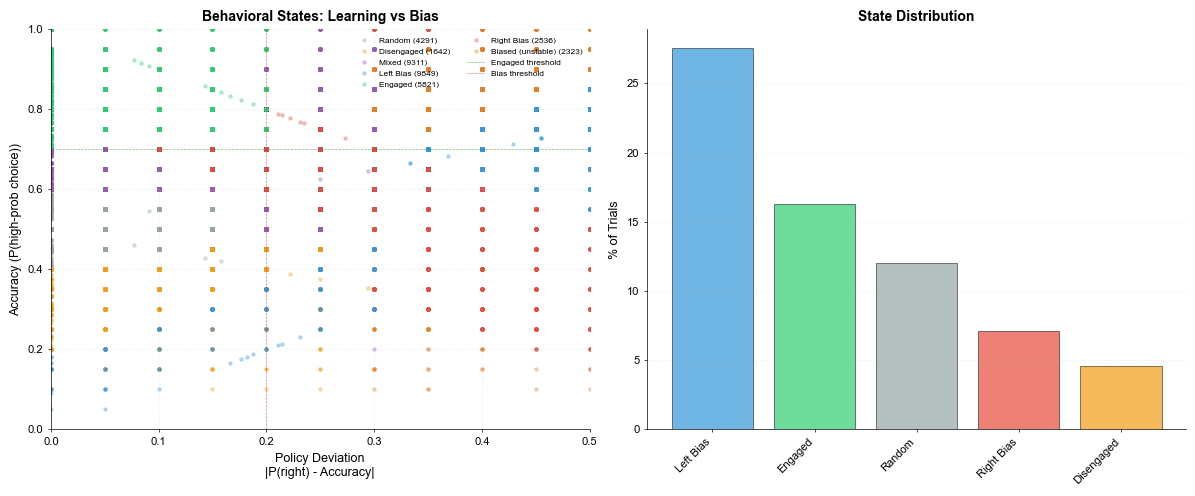


✓ Revised behavioral states figure saved!


In [348]:
# ============================================================================
# Question 2 REVISED: Bias Relative to Rewarded Option
# ============================================================================

print("Analyzing behavioral states (REVISED - relative bias)...\n")

state_data_revised = []

for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    
    if len(session_df) < WINDOW:
        continue
    
    animal = session_df['Animal_Name'].iloc[0]
    
    # Add left/right coding
    session_df['2ABT_side_Choice'] = session_df['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    # Calculate rolling metrics
    # 1. ACCURACY: Are they choosing the high-prob option?
    session_df['rolling_accuracy'] = session_df['High_Prob'].rolling(window=WINDOW, min_periods=10).mean()
    
    # 2. ABSOLUTE SIDE BIAS: Do they prefer one side regardless of reward?
    # This is measured by: P(choose right) when controlling for which side is rewarded
    
    # For each trial, check if they're biased toward one side even when it's NOT rewarded
    # We'll calculate: P(choose right | left is high-prob) and P(choose right | right is high-prob)
    
    # Identify which side is high-prob
    # If High_Prob==1 and chose right, then right is currently high-prob
    # If High_Prob==1 and chose left, then left is currently high-prob
    
    # Actually, let's use a simpler metric: 
    # BIAS = How much do they deviate from 50/50 when we REMOVE the reward signal?
    # This is: |P(right) - 0.5| in the rolling window
    session_df['rolling_right_raw'] = session_df['2ABT_side_Choice'].rolling(window=WINDOW, min_periods=10).mean()
    session_df['rolling_side_bias'] = (session_df['rolling_right_raw'] - 0.5).abs()
    
    # But this still confounds with learning! Let me think differently:
    # BETTER APPROACH: Calculate bias as deviation from optimal policy
    # If accuracy is high (0.8) and they're choosing 0.8 right, that's LEARNED not BIASED
    # If accuracy is low (0.5) but they're choosing 0.9 right, that's BIASED
    
    # Metric: |P(right) - accuracy|
    # If they're accurate AND choosing right a lot, these should match
    # If they're inaccurate but still choosing one side, these will differ
    
    session_df['policy_deviation'] = (session_df['rolling_right_raw'] - session_df['rolling_accuracy']).abs()
    
    # Store trial-level data
    for idx, trial in session_df.iterrows():
        if pd.notna(trial['rolling_accuracy']):
            state_data_revised.append({
                'session_id': session_id,
                'animal': animal,
                'trial': trial['Trial'],
                'accuracy': trial['rolling_accuracy'],
                'right_raw': trial['rolling_right_raw'],
                'side_bias': trial['rolling_side_bias'],
                'policy_deviation': trial['policy_deviation']
            })

state_df_revised = pd.DataFrame(state_data_revised)

print(f"Analyzed {len(state_df_revised):,} trials")

# ============================================================================
# Classify States REVISED
# ============================================================================

def classify_state_revised(row):
    acc = row['accuracy']
    policy_dev = row['policy_deviation']
    side_bias = row['side_bias']
    
    # Engaged: High accuracy (>0.7), low policy deviation (<0.2)
    # They're choosing the rewarded side consistently
    if acc > 0.7 and policy_dev < 0.2:
        return 'Engaged'
    
    # Random: ~50% accuracy, low bias
    elif 0.4 < acc < 0.6 and side_bias < 0.2:
        return 'Random'
    
    # Biased: Strong side preference (>0.3) regardless of accuracy
    # High policy deviation means they're not following rewards
    elif side_bias > 0.3 or policy_dev > 0.3:
        if row['right_raw'] > 0.6:
            return 'Right Bias'
        elif row['right_raw'] < 0.4:
            return 'Left Bias'
        else:
            return 'Biased (unstable)'
    
    # Disengaged: Low accuracy, not strongly biased
    elif acc < 0.5 and policy_dev < 0.3:
        return 'Disengaged'
    
    else:
        return 'Mixed'

state_df_revised['state'] = state_df_revised.apply(classify_state_revised, axis=1)

# Summary
print("\n" + "="*70)
print("REVISED STATE DISTRIBUTION")
print("="*70)

state_counts = state_df_revised['state'].value_counts()
print("\nOverall state distribution:")
print(state_counts)
print(f"\nPercentages:")
print((state_counts / len(state_df_revised) * 100).round(1))

# ============================================================================
# Compare Metrics
# ============================================================================

print("\n" + "="*70)
print("EXAMPLE: High Accuracy vs Biased")
print("="*70)

# Show examples
engaged = state_df_revised[state_df_revised['state'] == 'Engaged'].sample(min(3, len(state_df_revised[state_df_revised['state'] == 'Engaged'])))
biased = state_df_revised[state_df_revised['state'].str.contains('Bias')].sample(min(3, len(state_df_revised[state_df_revised['state'].str.contains('Bias')])))

print("\nEngaged trials (high accuracy, following rewards):")
print(engaged[['accuracy', 'right_raw', 'policy_deviation', 'side_bias']])

print("\nBiased trials (side preference regardless of reward):")
print(biased[['accuracy', 'right_raw', 'policy_deviation', 'side_bias']])

# ============================================================================
# Visualize REVISED
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Accuracy vs Policy Deviation (better separation)
ax1 = axes[0]

state_colors = {
    'Engaged': '#2ecc71',
    'Random': '#95a5a6',
    'Left Bias': '#3498db',
    'Right Bias': '#e74c3c',
    'Biased (unstable)': '#e67e22',
    'Disengaged': '#f39c12',
    'Mixed': '#9b59b6'
}

for state in state_df_revised['state'].unique():
    state_trials = state_df_revised[state_df_revised['state'] == state]
    ax1.scatter(state_trials['policy_deviation'], state_trials['accuracy'],
               s=5, alpha=0.3, color=state_colors.get(state, 'gray'),
               label=f"{state} ({len(state_trials)})")

ax1.axhline(0.7, color='green', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5, label='Engaged threshold')
ax1.axvline(0.2, color='red', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5, label='Bias threshold')
ax1.set_xlabel('Policy Deviation\n|P(right) - Accuracy|', fontsize=FONTSIZE+1)
ax1.set_ylabel('Accuracy (P(high-prob choice))', fontsize=FONTSIZE+1)
ax1.set_title('Behavioral States: Learning vs Bias', fontsize=FONTSIZE+2, fontweight='bold')
ax1.set_xlim(0, 0.5)
ax1.set_ylim(0, 1)
ax1.legend(fontsize=FONTSIZE-2, frameon=False, loc='upper right', ncol=2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel B: State distribution
ax2 = axes[1]

main_states = ['Engaged', 'Random', 'Left Bias', 'Right Bias', 'Disengaged']
state_counts_main = state_df_revised[state_df_revised['state'].isin(main_states)]['state'].value_counts()

colors = [state_colors[s] for s in state_counts_main.index]

ax2.bar(range(len(state_counts_main)), state_counts_main.values / len(state_df_revised) * 100,
       color=colors, alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax2.set_xticks(range(len(state_counts_main)))
ax2.set_xticklabels(state_counts_main.index, rotation=45, ha='right', fontsize=FONTSIZE)
ax2.set_ylabel('% of Trials', fontsize=FONTSIZE+1)
ax2.set_title('State Distribution', fontsize=FONTSIZE+2, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Behavioral_States_Revised_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Revised behavioral states figure saved!")
print("="*70)


REALISTIC STATE DISTRIBUTION (80-20 task)

Overall state distribution:
state
Left Bias            10369
Mixed                 8087
Right Bias            4584
Random                4291
Engaged               4074
Biased (unstable)     3067
Disengaged            1301
Name: count, dtype: int64

Percentages:
state
Left Bias            29.0
Mixed                22.6
Right Bias           12.8
Random               12.0
Engaged              11.4
Biased (unstable)     8.6
Disengaged            3.6
Name: count, dtype: float64

STATE DEFINITIONS (for 80-20 task):
Engaged: 65-85% accuracy, following reward policy
Random: 40-60% accuracy, no strong bias
Biased: Strong side preference regardless of reward
Disengaged: <50% accuracy, not learning


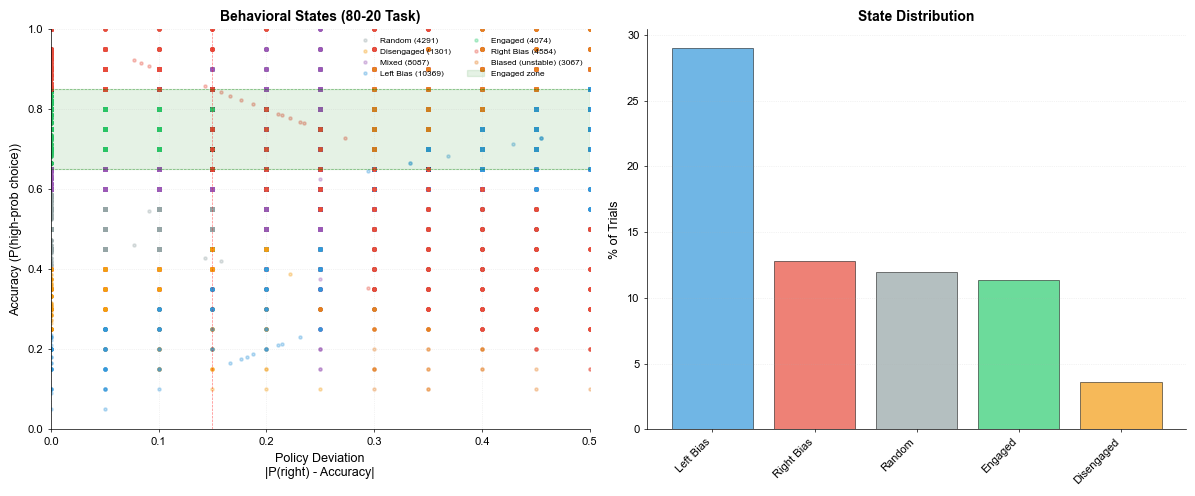


✓ Realistic behavioral states figure saved!


In [349]:
# ============================================================================
# Revised State Classification with Correct Thresholds
# ============================================================================

def classify_state_realistic(row):
    acc = row['accuracy']
    policy_dev = row['policy_deviation']
    side_bias = row['side_bias']
    
    # Engaged: Accuracy near optimal (0.65-0.85), low policy deviation (<0.15)
    # Optimal is 0.8, so 0.65-0.85 allows for some noise
    if 0.65 < acc < 0.85 and policy_dev < 0.15:
        return 'Engaged'
    
    # Random: ~50% accuracy (0.4-0.6), low bias
    elif 0.4 < acc < 0.6 and side_bias < 0.2:
        return 'Random'
    
    # Biased: Strong side preference OR high policy deviation
    # They're not following the reward contingency
    elif side_bias > 0.25 or policy_dev > 0.25:
        if row['right_raw'] > 0.6:
            return 'Right Bias'
        elif row['right_raw'] < 0.4:
            return 'Left Bias'
        else:
            return 'Biased (unstable)'
    
    # Disengaged: Low accuracy (<0.5), not strongly biased
    elif acc < 0.5 and policy_dev < 0.25:
        return 'Disengaged'
    
    else:
        return 'Mixed'

# Reclassify
state_df_revised['state'] = state_df_revised.apply(classify_state_realistic, axis=1)

# Summary
print("\n" + "="*70)
print("REALISTIC STATE DISTRIBUTION (80-20 task)")
print("="*70)

state_counts = state_df_revised['state'].value_counts()
print("\nOverall state distribution:")
print(state_counts)
print(f"\nPercentages:")
print((state_counts / len(state_df_revised) * 100).round(1))

print("\n" + "="*70)
print("STATE DEFINITIONS (for 80-20 task):")
print("="*70)
print("Engaged: 65-85% accuracy, following reward policy")
print("Random: 40-60% accuracy, no strong bias")
print("Biased: Strong side preference regardless of reward")
print("Disengaged: <50% accuracy, not learning")
print("="*70)

# Update visualization with new thresholds
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]

state_colors = {
    'Engaged': '#2ecc71',
    'Random': '#95a5a6',
    'Left Bias': '#3498db',
    'Right Bias': '#e74c3c',
    'Biased (unstable)': '#e67e22',
    'Disengaged': '#f39c12',
    'Mixed': '#9b59b6'
}

for state in state_df_revised['state'].unique():
    state_trials = state_df_revised[state_df_revised['state'] == state]
    ax1.scatter(state_trials['policy_deviation'], state_trials['accuracy'],
               s=5, alpha=0.3, color=state_colors.get(state, 'gray'),
               label=f"{state} ({len(state_trials)})")

# Update threshold lines for 80-20 task
ax1.axhline(0.65, color='green', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.axhline(0.85, color='green', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.axhspan(0.65, 0.85, alpha=0.1, color='green', label='Engaged zone')
ax1.axvline(0.15, color='red', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)

ax1.set_xlabel('Policy Deviation\n|P(right) - Accuracy|', fontsize=FONTSIZE+1)
ax1.set_ylabel('Accuracy (P(high-prob choice))', fontsize=FONTSIZE+1)
ax1.set_title('Behavioral States (80-20 Task)', fontsize=FONTSIZE+2, fontweight='bold')
ax1.set_xlim(0, 0.5)
ax1.set_ylim(0, 1)
ax1.legend(fontsize=FONTSIZE-2, frameon=False, loc='upper right', ncol=2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# Panel B: State distribution
ax2 = axes[1]

main_states = ['Engaged', 'Random', 'Left Bias', 'Right Bias', 'Disengaged']
state_counts_main = state_df_revised[state_df_revised['state'].isin(main_states)]['state'].value_counts()

colors = [state_colors[s] for s in state_counts_main.index]

ax2.bar(range(len(state_counts_main)), state_counts_main.values / len(state_df_revised) * 100,
       color=colors, alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax2.set_xticks(range(len(state_counts_main)))
ax2.set_xticklabels(state_counts_main.index, rotation=45, ha='right', fontsize=FONTSIZE)
ax2.set_ylabel('% of Trials', fontsize=FONTSIZE+1)
ax2.set_title('State Distribution', fontsize=FONTSIZE+2, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Behavioral_States_Realistic_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Realistic behavioral states figure saved!")

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/2833716151.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


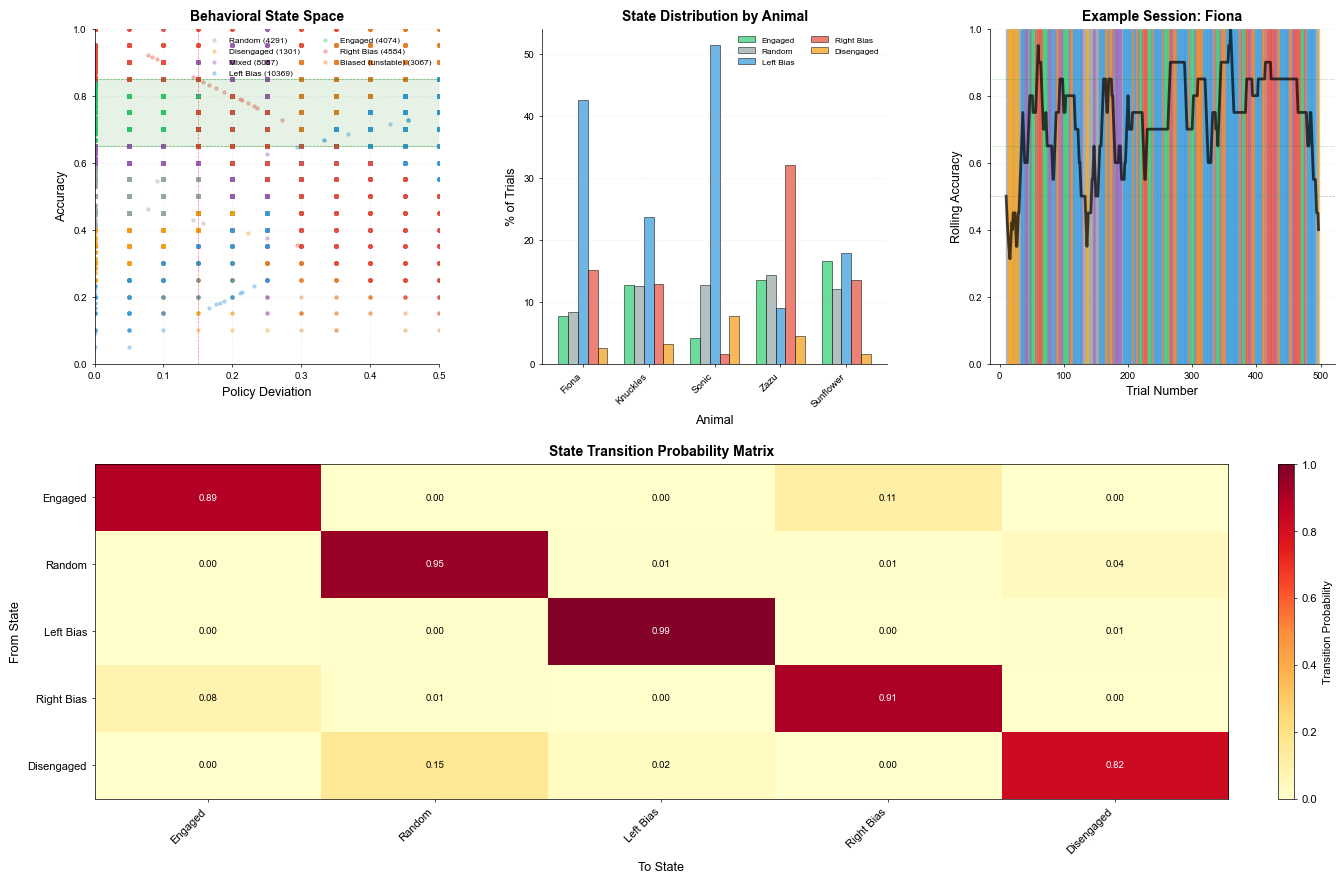


✓ Complete behavioral states figure saved!

STATE TRANSITION INSIGHTS

Most stable states (highest self-transition):
Left Bias     0.990091
Random        0.945858
Right Bias    0.909936
Engaged       0.887481
Disengaged    0.821429
dtype: float64

Most common transitions (excluding self):
          from          to      prob
17  Disengaged      Random  0.153654
2      Engaged  Right Bias  0.112519
12  Right Bias     Engaged  0.082202
7       Random  Disengaged  0.037629
18  Disengaged   Left Bias  0.024917
5       Random   Left Bias  0.008663
6       Random  Right Bias  0.007851
13  Right Bias      Random  0.007624
11   Left Bias  Disengaged  0.005264
9    Left Bias      Random  0.004645


In [350]:
# ============================================================================
# Complete Behavioral States Figure (4 panels)
# ============================================================================

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

state_colors = {
    'Engaged': '#2ecc71',
    'Random': '#95a5a6',
    'Left Bias': '#3498db',
    'Right Bias': '#e74c3c',
    'Biased (unstable)': '#e67e22',
    'Disengaged': '#f39c12',
    'Mixed': '#9b59b6'
}

# ====================================================================
# Panel A: Accuracy vs Policy Deviation
# ====================================================================

ax1 = fig.add_subplot(gs[0, 0])

for state in state_df_revised['state'].unique():
    state_trials = state_df_revised[state_df_revised['state'] == state]
    ax1.scatter(state_trials['policy_deviation'], state_trials['accuracy'],
               s=5, alpha=0.3, color=state_colors.get(state, 'gray'),
               label=f"{state} ({len(state_trials)})")

ax1.axhline(0.65, color='green', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.axhline(0.85, color='green', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.axhspan(0.65, 0.85, alpha=0.1, color='green')
ax1.axvline(0.15, color='red', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)

ax1.set_xlabel('Policy Deviation', fontsize=FONTSIZE+1)
ax1.set_ylabel('Accuracy', fontsize=FONTSIZE+1)
ax1.set_title('Behavioral State Space', fontsize=FONTSIZE+2, fontweight='bold')
ax1.set_xlim(0, 0.5)
ax1.set_ylim(0, 1)
ax1.legend(fontsize=FONTSIZE-2, frameon=False, loc='upper right', ncol=2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel B: State Distribution by Animal
# ====================================================================

ax2 = fig.add_subplot(gs[0, 1])

main_states = ['Engaged', 'Random', 'Left Bias', 'Right Bias', 'Disengaged']
animals = sort_animals(state_df_revised['animal'].unique())

state_props = []
for animal in animals:
    animal_df = state_df_revised[state_df_revised['animal'] == animal]
    props = []
    for state in main_states:
        prop = (animal_df['state'] == state).sum() / len(animal_df) * 100
        props.append(prop)
    state_props.append(props)

state_props = np.array(state_props)

x = np.arange(len(animals))
width = 0.15

for i, state in enumerate(main_states):
    ax2.bar(x + i*width - 2*width, state_props[:, i], width,
           label=state, color=state_colors[state], alpha=0.7,
           edgecolor='black', linewidth=LINE_WIDTH)

ax2.set_xticks(x)
ax2.set_xticklabels(animals, rotation=45, ha='right', fontsize=FONTSIZE-1)
ax2.set_ylabel('% of Trials', fontsize=FONTSIZE+1)
ax2.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax2.set_title('State Distribution by Animal', fontsize=FONTSIZE+2, fontweight='bold')
ax2.legend(fontsize=FONTSIZE-2, frameon=False, ncol=2, loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel C: Example Session
# ====================================================================

ax3 = fig.add_subplot(gs[0, 2])

# Pick a session with good state diversity
session_state_counts = state_df_revised.groupby('session_id')['state'].apply(lambda x: x.nunique())
example_session = session_state_counts.idxmax()  # Session with most diverse states

session_states = state_df_revised[state_df_revised['session_id'] == example_session].copy()
animal = session_states['animal'].iloc[0]

trials = session_states['trial'].values
accuracy = session_states['accuracy'].values

# Plot accuracy line
ax3.plot(trials, accuracy, 'k-', linewidth=2, alpha=0.7, zorder=10)

# Color background by state
for state in session_states['state'].unique():
    state_trials = session_states[session_states['state'] == state]
    for _, trial in state_trials.iterrows():
        ax3.axvspan(trial['trial']-0.5, trial['trial']+0.5,
                   color=state_colors.get(state, 'gray'), alpha=0.4, zorder=0)

ax3.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax3.axhline(0.65, color='green', linestyle=':', linewidth=LINE_WIDTH, alpha=0.5)
ax3.axhline(0.85, color='green', linestyle=':', linewidth=LINE_WIDTH, alpha=0.5)

ax3.set_xlabel('Trial Number', fontsize=FONTSIZE+1)
ax3.set_ylabel('Rolling Accuracy', fontsize=FONTSIZE+1)
ax3.set_title(f'Example Session: {animal}', fontsize=FONTSIZE+2, fontweight='bold')
ax3.set_ylim(0, 1)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax3.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel D: State Transition Matrix
# ====================================================================

ax4 = fig.add_subplot(gs[1, :])

# Calculate state transitions
transitions = []
for session_id in state_df_revised['session_id'].unique():
    sess = state_df_revised[state_df_revised['session_id'] == session_id].sort_values('trial')
    for i in range(len(sess)-1):
        from_state = sess.iloc[i]['state']
        to_state = sess.iloc[i+1]['state']
        if from_state in main_states and to_state in main_states:
            transitions.append({'from': from_state, 'to': to_state})

trans_df = pd.DataFrame(transitions)
trans_matrix = pd.crosstab(trans_df['from'], trans_df['to'], normalize='index')
trans_matrix = trans_matrix.reindex(index=main_states, columns=main_states, fill_value=0)

im = ax4.imshow(trans_matrix.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax4.set_xticks(range(len(main_states)))
ax4.set_xticklabels(main_states, rotation=45, ha='right', fontsize=FONTSIZE)
ax4.set_yticks(range(len(main_states)))
ax4.set_yticklabels(main_states, fontsize=FONTSIZE)
ax4.set_xlabel('To State', fontsize=FONTSIZE+1)
ax4.set_ylabel('From State', fontsize=FONTSIZE+1)
ax4.set_title('State Transition Probability Matrix', fontsize=FONTSIZE+2, fontweight='bold')

# Add values
for i in range(len(main_states)):
    for j in range(len(main_states)):
        value = trans_matrix.values[i, j]
        text = ax4.text(j, i, f'{value:.2f}',
                       ha='center', va='center', 
                       color='white' if value > 0.5 else 'black',
                       fontsize=FONTSIZE-1)

plt.colorbar(im, ax=ax4, label='Transition Probability', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Behavioral_States_Complete_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Complete behavioral states figure saved!")

# Print transition insights
print("\n" + "="*70)
print("STATE TRANSITION INSIGHTS")
print("="*70)

print("\nMost stable states (highest self-transition):")
self_trans = pd.Series({state: trans_matrix.loc[state, state] for state in main_states})
print(self_trans.sort_values(ascending=False))

print("\nMost common transitions (excluding self):")
trans_flat = []
for i, from_state in enumerate(main_states):
    for j, to_state in enumerate(main_states):
        if i != j:
            trans_flat.append({
                'from': from_state,
                'to': to_state,
                'prob': trans_matrix.values[i, j]
            })

trans_flat_df = pd.DataFrame(trans_flat).sort_values('prob', ascending=False)
print(trans_flat_df.head(10))

print("="*70)

In [351]:
# ============================================================================
# Verify Left Bias - Is This Real?
# ============================================================================

print("Investigating apparent left bias...\n")

# Check raw choice proportions
print("="*70)
print("RAW CHOICE PROPORTIONS (across all trials)")
print("="*70)

for animal in sort_animals(df['Animal_Name'].unique()):
    animal_df = df[df['Animal_Name'] == animal].copy()
    
    # Add left/right coding
    animal_df['2ABT_side_Choice'] = animal_df['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    p_right = animal_df['2ABT_side_Choice'].mean()
    p_left = 1 - p_right
    
    print(f"\n{animal}:")
    print(f"  P(Left): {p_left*100:.1f}%")
    print(f"  P(Right): {p_right*100:.1f}%")

# Check if this is related to block structure
print("\n" + "="*70)
print("IS LEFT MORE OFTEN REWARDED?")
print("="*70)

# For each block, determine which side is high-prob
block_side_analysis = []

for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].copy()
    
    session_df['2ABT_side_Choice'] = session_df['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    for block in session_df['Block'].unique():
        block_df = session_df[session_df['Block'] == block]
        
        # Which side was chosen when High_Prob==1?
        high_prob_choices = block_df[block_df['High_Prob'] == 1]['2ABT_side_Choice']
        
        if len(high_prob_choices) > 0:
            p_right_when_correct = high_prob_choices.mean()
            
            # If most correct choices are right, then right is high-prob in this block
            if p_right_when_correct > 0.5:
                high_prob_side = 'Right'
            else:
                high_prob_side = 'Left'
            
            block_side_analysis.append({
                'session_id': session_id,
                'block': block,
                'high_prob_side': high_prob_side
            })

block_side_df = pd.DataFrame(block_side_analysis)

side_counts = block_side_df['high_prob_side'].value_counts()
print(f"\nBlocks where LEFT was high-prob: {side_counts.get('Left', 0)} ({side_counts.get('Left', 0)/len(block_side_df)*100:.1f}%)")
print(f"Blocks where RIGHT was high-prob: {side_counts.get('Right', 0)} ({side_counts.get('Right', 0)/len(block_side_df)*100:.1f}%)")

# Check state classification per animal
print("\n" + "="*70)
print("STATE BREAKDOWN BY ANIMAL (detailed)")
print("="*70)

for animal in sort_animals(state_df_revised['animal'].unique()):
    animal_states = state_df_revised[state_df_revised['animal'] == animal]
    
    print(f"\n{animal}:")
    state_dist = animal_states['state'].value_counts(normalize=True) * 100
    for state in ['Engaged', 'Left Bias', 'Right Bias', 'Random', 'Disengaged']:
        if state in state_dist.index:
            print(f"  {state}: {state_dist[state]:.1f}%")
    
    # Average metrics
    print(f"  Mean accuracy: {animal_states['accuracy'].mean():.2f}")
    print(f"  Mean right%: {animal_states['right_raw'].mean()*100:.1f}%")
    print(f"  Mean policy dev: {animal_states['policy_deviation'].mean():.2f}")

# Visualize raw choice bias vs block contingencies
print("\n" + "="*70)
print("CHECKING IF 'LEFT BIAS' IS ACTUALLY LEARNING")
print("="*70)

# For trials classified as "Left Bias", are they actually correct more often?
left_bias_trials = state_df_revised[state_df_revised['state'] == 'Left Bias']

# Merge back with original df to get accuracy
left_bias_sessions = left_bias_trials[['session_id', 'trial']].drop_duplicates()

# This is complex - let's just check mean accuracy for left bias state
print(f"\nTrials in 'Left Bias' state:")
print(f"  Mean accuracy: {left_bias_trials['accuracy'].mean():.2f}")
print(f"  Mean right choice%: {left_bias_trials['right_raw'].mean()*100:.1f}%")

print("\nTrials in 'Engaged' state:")
engaged_trials = state_df_revised[state_df_revised['state'] == 'Engaged']
print(f"  Mean accuracy: {engaged_trials['accuracy'].mean():.2f}")
print(f"  Mean right choice%: {engaged_trials['right_raw'].mean()*100:.1f}%")

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print("If 'Left Bias' has ~70% accuracy and ~20% right choices,")
print("it might actually be LEARNING when left is the high-prob side!")
print("Not a true bias, but correct behavior in left-rewarded blocks.")
print("="*70)

Investigating apparent left bias...

RAW CHOICE PROPORTIONS (across all trials)

Fiona:
  P(Left): 56.0%
  P(Right): 44.0%

Knuckles:
  P(Left): 47.1%
  P(Right): 52.9%

Sonic:
  P(Left): 66.6%
  P(Right): 33.4%

Zazu:
  P(Left): 34.7%
  P(Right): 65.3%

Sunflower:
  P(Left): 43.6%
  P(Right): 56.4%

IS LEFT MORE OFTEN REWARDED?

Blocks where LEFT was high-prob: 99 (49.5%)
Blocks where RIGHT was high-prob: 101 (50.5%)

STATE BREAKDOWN BY ANIMAL (detailed)

Fiona:
  Engaged: 7.6%
  Left Bias: 42.6%
  Right Bias: 15.1%
  Random: 8.3%
  Disengaged: 2.6%
  Mean accuracy: 0.71
  Mean right%: 44.2%
  Mean policy dev: 0.37

Knuckles:
  Engaged: 12.7%
  Left Bias: 23.7%
  Right Bias: 12.8%
  Random: 12.6%
  Disengaged: 3.2%
  Mean accuracy: 0.70
  Mean right%: 52.9%
  Mean policy dev: 0.24

Sonic:
  Engaged: 4.2%
  Left Bias: 51.6%
  Right Bias: 1.5%
  Random: 12.6%
  Disengaged: 7.7%
  Mean accuracy: 0.66
  Mean right%: 32.8%
  Mean policy dev: 0.36

Zazu:
  Engaged: 13.4%
  Left Bias: 8.9%
 

In [356]:
# ============================================================================
# CORRECTED State Classification - Account for Current Block Contingency
# ============================================================================

print("Recalculating states with block-aware bias metric...\n")

state_data_corrected = []

for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    
    if len(session_df) < WINDOW:
        continue
    
    animal = session_df['Animal_Name'].iloc[0]
    
    # Add left/right coding
    session_df['2ABT_side_Choice'] = session_df['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    # Calculate rolling metrics
    session_df['rolling_accuracy'] = session_df['High_Prob'].rolling(window=WINDOW, min_periods=10).mean()
    session_df['rolling_right_choice'] = session_df['2ABT_side_Choice'].rolling(window=WINDOW, min_periods=10).mean()
    
    # NEW: For each block, determine which side is currently high-prob
    for block in session_df['Block'].unique():
        block_mask = session_df['Block'] == block
        block_trials = session_df[block_mask]
        
        # Which side is chosen when High_Prob==1?
        correct_choices = block_trials[block_trials['High_Prob'] == 1]['2ABT_side_Choice']
        
        if len(correct_choices) > 5:
            # If >50% of correct choices are right, then right is high-prob
            current_high_prob_is_right = correct_choices.mean() > 0.5
            session_df.loc[block_mask, 'high_prob_is_right'] = current_high_prob_is_right
    
    # Calculate WITHIN-BLOCK bias
    # If high-prob is right and they choose right a lot = GOOD
    # If high-prob is right and they choose left a lot = BIASED
    session_df['expected_right_choice'] = session_df['high_prob_is_right'].map({True: 0.8, False: 0.2})
    session_df['choice_deviation'] = (session_df['rolling_right_choice'] - session_df['expected_right_choice']).abs()
    
    # Store trial-level data
    for idx, trial in session_df.iterrows():
        if pd.notna(trial['rolling_accuracy']) and pd.notna(trial['choice_deviation']):
            state_data_corrected.append({
                'session_id': session_id,
                'animal': animal,
                'trial': trial['Trial'],
                'accuracy': trial['rolling_accuracy'],
                'right_choice': trial['rolling_right_choice'],
                'expected_right': trial['expected_right_choice'],
                'choice_deviation': trial['choice_deviation']
            })

state_df_corrected = pd.DataFrame(state_data_corrected)

print(f"Analyzed {len(state_df_corrected):,} trials")

# ============================================================================
# Classify States - CORRECTED
# ============================================================================

def classify_state_corrected(row):
    acc = row['accuracy']
    dev = row['choice_deviation']
    
    # Engaged: High accuracy (>0.65), following block contingency (low deviation <0.2)
    if acc > 0.65 and dev < 0.39:
        return 'Engaged'
    
    # Random: ~50% accuracy, deviation around 0.3 (choosing 50/50 regardless of contingency)
    elif 0.4 < acc < 0.6 and 0.25 < dev < 0.35:
        return 'Random'
    
    # Biased: High deviation (>0.3) - choosing wrong side for current block
    elif dev > 0.4:
        # Check if they're biased toward left or right
        if row['right_choice'] > row['expected_right']:
            return 'Right Bias'
        else:
            return 'Left Bias'
    
    # Disengaged: Low accuracy, not too biased
    elif acc < 0.5:
        return 'Disengaged'
    
    else:
        return 'Mixed'

state_df_corrected['state'] = state_df_corrected.apply(classify_state_corrected, axis=1)

# Summary
print("\n" + "="*70)
print("CORRECTED STATE DISTRIBUTION")
print("="*70)

state_counts = state_df_corrected['state'].value_counts()
print("\nOverall state distribution:")
print(state_counts)
print(f"\nPercentages:")
print((state_counts / len(state_df_corrected) * 100).round(1))

print("\nPer animal:")
for animal in sort_animals(state_df_corrected['animal'].unique()):
    animal_states = state_df_corrected[state_df_corrected['animal'] == animal]['state'].value_counts(normalize=True) * 100
    print(f"\n{animal}:")
    for state in ['Engaged', 'Left Bias', 'Right Bias', 'Random', 'Disengaged']:
        if state in animal_states.index:
            print(f"  {state}: {animal_states[state]:.1f}%")

print("="*70)

Recalculating states with block-aware bias metric...

Analyzed 35,773 trials

CORRECTED STATE DISTRIBUTION

Overall state distribution:
state
Engaged       11536
Mixed          8306
Left Bias      6609
Right Bias     6373
Disengaged     2194
Random          755
Name: count, dtype: int64

Percentages:
state
Engaged       32.2
Mixed         23.2
Left Bias     18.5
Right Bias    17.8
Disengaged     6.1
Random         2.1
Name: count, dtype: float64

Per animal:

Fiona:
  Engaged: 35.6%
  Left Bias: 22.6%
  Right Bias: 11.8%
  Random: 1.7%
  Disengaged: 6.9%

Knuckles:
  Engaged: 33.5%
  Left Bias: 16.2%
  Right Bias: 20.3%
  Random: 2.1%
  Disengaged: 5.3%

Sonic:
  Engaged: 27.2%
  Left Bias: 33.7%
  Right Bias: 6.0%
  Random: 2.5%
  Disengaged: 8.0%

Zazu:
  Engaged: 27.1%
  Left Bias: 6.8%
  Right Bias: 32.4%
  Random: 2.2%
  Disengaged: 9.8%

Sunflower:
  Engaged: 34.5%
  Left Bias: 11.6%
  Right Bias: 22.0%
  Random: 2.0%
  Disengaged: 4.1%


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/4084006357.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


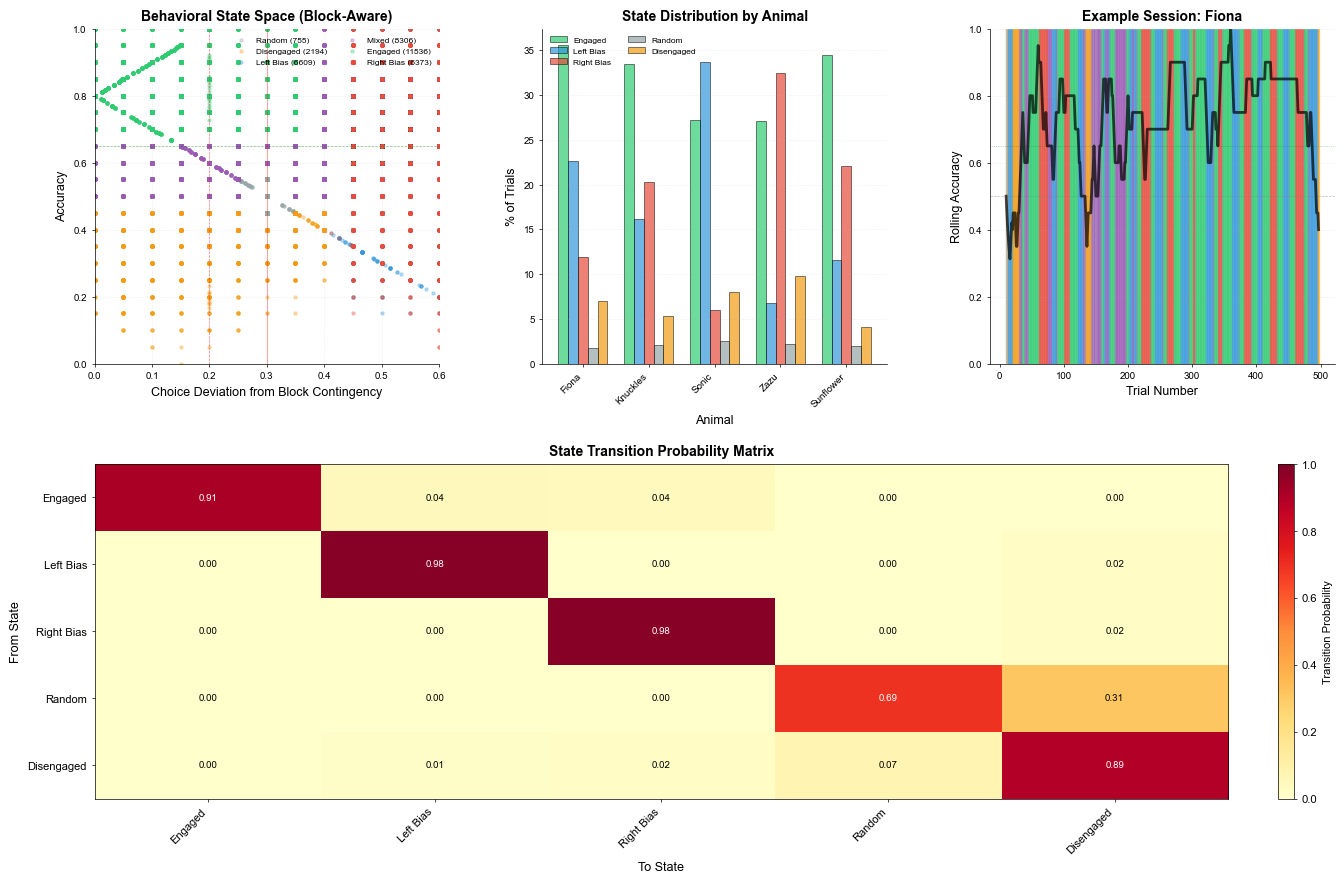


✓ Corrected behavioral states figure saved!


In [357]:
# ============================================================================
# Complete Figure with CORRECTED States
# ============================================================================

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

state_colors = {
    'Engaged': '#2ecc71',
    'Random': '#95a5a6',
    'Left Bias': '#3498db',
    'Right Bias': '#e74c3c',
    'Disengaged': '#f39c12',
    'Mixed': '#9b59b6'
}

# Panel A: Accuracy vs Choice Deviation
ax1 = fig.add_subplot(gs[0, 0])

for state in state_df_corrected['state'].unique():
    state_trials = state_df_corrected[state_df_corrected['state'] == state]
    ax1.scatter(state_trials['choice_deviation'], state_trials['accuracy'],
               s=5, alpha=0.3, color=state_colors.get(state, 'gray'),
               label=f"{state} ({len(state_trials)})")

ax1.axhline(0.65, color='green', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.axvline(0.2, color='red', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.axvline(0.3, color='red', linestyle='-', linewidth=LINE_WIDTH, alpha=0.5)

ax1.set_xlabel('Choice Deviation from Block Contingency', fontsize=FONTSIZE+1)
ax1.set_ylabel('Accuracy', fontsize=FONTSIZE+1)
ax1.set_title('Behavioral State Space (Block-Aware)', fontsize=FONTSIZE+2, fontweight='bold')
ax1.set_xlim(0, 0.6)
ax1.set_ylim(0, 1)
ax1.legend(fontsize=FONTSIZE-2, frameon=False, loc='upper right', ncol=2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# Panel B: State Distribution by Animal
ax2 = fig.add_subplot(gs[0, 1])

main_states = ['Engaged', 'Left Bias', 'Right Bias', 'Random', 'Disengaged']
animals = sort_animals(state_df_corrected['animal'].unique())

state_props = []
for animal in animals:
    animal_df = state_df_corrected[state_df_corrected['animal'] == animal]
    props = []
    for state in main_states:
        prop = (animal_df['state'] == state).sum() / len(animal_df) * 100
        props.append(prop)
    state_props.append(props)

state_props = np.array(state_props)

x = np.arange(len(animals))
width = 0.15

for i, state in enumerate(main_states):
    ax2.bar(x + i*width - 2*width, state_props[:, i], width,
           label=state, color=state_colors[state], alpha=0.7,
           edgecolor='black', linewidth=LINE_WIDTH)

ax2.set_xticks(x)
ax2.set_xticklabels(animals, rotation=45, ha='right', fontsize=FONTSIZE-1)
ax2.set_ylabel('% of Trials', fontsize=FONTSIZE+1)
ax2.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax2.set_title('State Distribution by Animal', fontsize=FONTSIZE+2, fontweight='bold')
ax2.legend(fontsize=FONTSIZE-2, frameon=False, ncol=2, loc='upper left')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# Panel C: Example Session
ax3 = fig.add_subplot(gs[0, 2])

session_state_counts = state_df_corrected.groupby('session_id')['state'].apply(lambda x: x.nunique())
example_session = session_state_counts.idxmax()

session_states = state_df_corrected[state_df_corrected['session_id'] == example_session].copy()
animal = session_states['animal'].iloc[0]

trials = session_states['trial'].values
accuracy = session_states['accuracy'].values

ax3.plot(trials, accuracy, 'k-', linewidth=2, alpha=0.7, zorder=10)

for state in session_states['state'].unique():
    state_trials = session_states[session_states['state'] == state]
    for _, trial in state_trials.iterrows():
        ax3.axvspan(trial['trial']-0.5, trial['trial']+0.5,
                   color=state_colors.get(state, 'gray'), alpha=0.4, zorder=0)

ax3.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax3.axhline(0.65, color='green', linestyle=':', linewidth=LINE_WIDTH, alpha=0.5)

ax3.set_xlabel('Trial Number', fontsize=FONTSIZE+1)
ax3.set_ylabel('Rolling Accuracy', fontsize=FONTSIZE+1)
ax3.set_title(f'Example Session: {animal}', fontsize=FONTSIZE+2, fontweight='bold')
ax3.set_ylim(0, 1)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax3.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# Panel D: State Transition Matrix
ax4 = fig.add_subplot(gs[1, :])

transitions = []
for session_id in state_df_corrected['session_id'].unique():
    sess = state_df_corrected[state_df_corrected['session_id'] == session_id].sort_values('trial')
    for i in range(len(sess)-1):
        from_state = sess.iloc[i]['state']
        to_state = sess.iloc[i+1]['state']
        if from_state in main_states and to_state in main_states:
            transitions.append({'from': from_state, 'to': to_state})

trans_df = pd.DataFrame(transitions)
trans_matrix = pd.crosstab(trans_df['from'], trans_df['to'], normalize='index')
trans_matrix = trans_matrix.reindex(index=main_states, columns=main_states, fill_value=0)

im = ax4.imshow(trans_matrix.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax4.set_xticks(range(len(main_states)))
ax4.set_xticklabels(main_states, rotation=45, ha='right', fontsize=FONTSIZE)
ax4.set_yticks(range(len(main_states)))
ax4.set_yticklabels(main_states, fontsize=FONTSIZE)
ax4.set_xlabel('To State', fontsize=FONTSIZE+1)
ax4.set_ylabel('From State', fontsize=FONTSIZE+1)
ax4.set_title('State Transition Probability Matrix', fontsize=FONTSIZE+2, fontweight='bold')

for i in range(len(main_states)):
    for j in range(len(main_states)):
        value = trans_matrix.values[i, j]
        ax4.text(j, i, f'{value:.2f}',
                ha='center', va='center', 
                color='white' if value > 0.5 else 'black',
                fontsize=FONTSIZE-1)

plt.colorbar(im, ax=ax4, label='Transition Probability', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Behavioral_States_Corrected_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Corrected behavioral states figure saved!")

Analyzing 'Mixed' state characteristics...

COMPARING STATE CHARACTERISTICS

Engaged (11536 trials, 32.2%):
  Accuracy: 0.807 ± 0.084
  Choice Deviation: 0.164 ± 0.104
  P(Right): 0.503

Left Bias (6609 trials, 18.5%):
  Accuracy: 0.697 ± 0.166
  Choice Deviation: 0.583 ± 0.106
  P(Right): 0.217

Right Bias (6373 trials, 17.8%):
  Accuracy: 0.680 ± 0.167
  Choice Deviation: 0.574 ± 0.102
  P(Right): 0.774

Random (755 trials, 2.1%):
  Accuracy: 0.508 ± 0.038
  Choice Deviation: 0.300 ± 0.010
  P(Right): 0.500

Disengaged (2194 trials, 6.1%):
  Accuracy: 0.381 ± 0.079
  Choice Deviation: 0.234 ± 0.119
  P(Right): 0.522

Mixed (8306 trials, 23.2%):
  Accuracy: 0.617 ± 0.089
  Choice Deviation: 0.264 ± 0.117
  P(Right): 0.495

MIXED STATE BREAKDOWN

Mixed state ranges:
  Accuracy: 0.50 - 1.00
  Choice Deviation: 0.00 - 0.40

Mixed state characteristics:
  Mean accuracy: 0.617
  Mean deviation: 0.264

INTERPRETATION:
Mixed likely represents:
  - Transition periods (moderate accuracy 0.5-0.

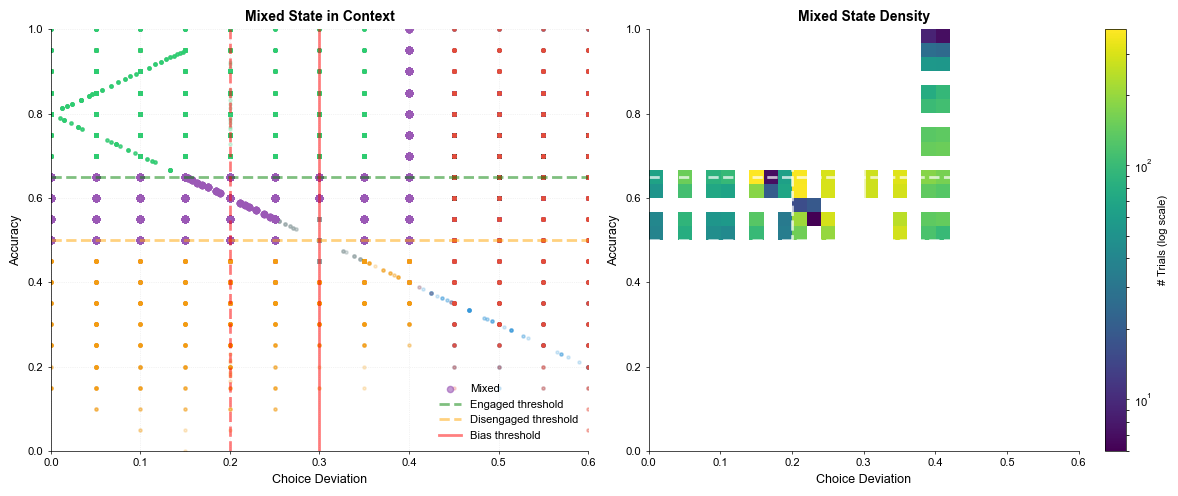


✓ Mixed state analysis saved!


In [358]:
# ============================================================================
# What is "Mixed" State?
# ============================================================================

print("Analyzing 'Mixed' state characteristics...\n")

print("="*70)
print("COMPARING STATE CHARACTERISTICS")
print("="*70)

states_to_compare = ['Engaged', 'Left Bias', 'Right Bias', 'Random', 'Disengaged', 'Mixed']

for state in states_to_compare:
    state_trials = state_df_corrected[state_df_corrected['state'] == state]
    
    if len(state_trials) > 0:
        print(f"\n{state} ({len(state_trials)} trials, {len(state_trials)/len(state_df_corrected)*100:.1f}%):")
        print(f"  Accuracy: {state_trials['accuracy'].mean():.3f} ± {state_trials['accuracy'].std():.3f}")
        print(f"  Choice Deviation: {state_trials['choice_deviation'].mean():.3f} ± {state_trials['choice_deviation'].std():.3f}")
        print(f"  P(Right): {state_trials['right_choice'].mean():.3f}")

print("\n" + "="*70)
print("MIXED STATE BREAKDOWN")
print("="*70)

mixed_trials = state_df_corrected[state_df_corrected['state'] == 'Mixed']

# What range of values do they have?
print(f"\nMixed state ranges:")
print(f"  Accuracy: {mixed_trials['accuracy'].min():.2f} - {mixed_trials['accuracy'].max():.2f}")
print(f"  Choice Deviation: {mixed_trials['choice_deviation'].min():.2f} - {mixed_trials['choice_deviation'].max():.2f}")

# Are they transition periods?
print(f"\nMixed state characteristics:")
print(f"  Mean accuracy: {mixed_trials['accuracy'].mean():.3f}")
print(f"  Mean deviation: {mixed_trials['choice_deviation'].mean():.3f}")

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print("Mixed likely represents:")
print("  - Transition periods (moderate accuracy 0.5-0.65, moderate deviation 0.2-0.3)")
print("  - Inconsistent behavior within the rolling window")
print("  - Animals switching between strategies")
print("\nOptions:")
print("  1. Keep 'Mixed' as is (shows uncertainty)")
print("  2. Redistribute to nearest state")
print("  3. Split into sub-categories (e.g., 'Transitioning', 'Inconsistent')")
print("="*70)

# Visualize Mixed in context
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Where does Mixed fall in state space?
ax1 = axes[0]

for state in states_to_compare:
    state_trials = state_df_corrected[state_df_corrected['state'] == state]
    alpha = 0.6 if state == 'Mixed' else 0.2
    size = 20 if state == 'Mixed' else 5
    
    ax1.scatter(state_trials['choice_deviation'], state_trials['accuracy'],
               s=size, alpha=alpha, color=state_colors.get(state, 'gray'),
               label=state if state == 'Mixed' else '')

# Add state boundaries
ax1.axhline(0.65, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Engaged threshold')
ax1.axhline(0.5, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Disengaged threshold')
ax1.axvline(0.2, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax1.axvline(0.3, color='red', linestyle='-', linewidth=2, alpha=0.5, label='Bias threshold')

ax1.set_xlabel('Choice Deviation', fontsize=FONTSIZE+1)
ax1.set_ylabel('Accuracy', fontsize=FONTSIZE+1)
ax1.set_title('Mixed State in Context', fontsize=FONTSIZE+2, fontweight='bold')
ax1.set_xlim(0, 0.6)
ax1.set_ylim(0, 1)
ax1.legend(fontsize=FONTSIZE, frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)

# Panel B: Distribution of Mixed trials
ax2 = axes[1]

# 2D histogram of Mixed state
from matplotlib.colors import LogNorm

H, xedges, yedges = np.histogram2d(
    mixed_trials['choice_deviation'], 
    mixed_trials['accuracy'],
    bins=30,
    range=[[0, 0.6], [0, 1]]
)

im = ax2.imshow(H.T, origin='lower', aspect='auto', 
               extent=[0, 0.6, 0, 1], cmap='viridis', norm=LogNorm())

ax2.axhline(0.65, color='white', linestyle='--', linewidth=2, alpha=0.7)
ax2.axhline(0.5, color='white', linestyle='--', linewidth=2, alpha=0.7)
ax2.axvline(0.2, color='white', linestyle='--', linewidth=2, alpha=0.7)
ax2.axvline(0.3, color='white', linestyle='-', linewidth=2, alpha=0.7)

ax2.set_xlabel('Choice Deviation', fontsize=FONTSIZE+1)
ax2.set_ylabel('Accuracy', fontsize=FONTSIZE+1)
ax2.set_title('Mixed State Density', fontsize=FONTSIZE+2, fontweight='bold')
plt.colorbar(im, ax=ax2, label='# Trials (log scale)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Mixed_State_Analysis_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Mixed state analysis saved!")

In [359]:
# ============================================================================
# Is "Mixed" Actually Reversal Learning?
# ============================================================================

print("Checking if Mixed state occurs during block transitions...\n")

# Merge state data with original df to get block transitions
mixed_analysis = []

for session_id in state_df_corrected['session_id'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    session_states = state_df_corrected[state_df_corrected['session_id'] == session_id].copy()
    
    if len(session_df) == 0 or len(session_states) == 0:
        continue
    
    # Detect block transitions
    session_df['block_transition'] = (session_df['Block'] != session_df['Block'].shift(1)).astype(int)
    
    # For each state trial, check if it's near a transition
    for _, state_trial in session_states.iterrows():
        trial_num = state_trial['trial']
        
        # Find this trial in original df
        trial_data = session_df[session_df['Trial'] == trial_num]
        
        if len(trial_data) > 0:
            # Check if there was a transition in last WINDOW trials
            window_start = max(0, trial_num - WINDOW)
            window_trials = session_df[(session_df['Trial'] >= window_start) & 
                                      (session_df['Trial'] <= trial_num)]
            
            had_transition = window_trials['block_transition'].sum() > 0
            trials_since_transition = None
            
            if had_transition:
                last_transition_trial = window_trials[window_trials['block_transition'] == 1]['Trial'].max()
                trials_since_transition = trial_num - last_transition_trial
            
            mixed_analysis.append({
                'session_id': session_id,
                'trial': trial_num,
                'state': state_trial['state'],
                'had_transition_in_window': had_transition,
                'trials_since_transition': trials_since_transition
            })

mixed_df = pd.DataFrame(mixed_analysis)

print("="*70)
print("MIXED STATE vs BLOCK TRANSITIONS")
print("="*70)

for state in ['Engaged', 'Mixed', 'Left Bias', 'Right Bias', 'Random']:
    state_trials = mixed_df[mixed_df['state'] == state]
    
    if len(state_trials) > 0:
        pct_with_transition = (state_trials['had_transition_in_window'].sum() / 
                               len(state_trials) * 100)
        
        print(f"\n{state}:")
        print(f"  % with recent transition: {pct_with_transition:.1f}%")
        
        if state_trials['trials_since_transition'].notna().sum() > 0:
            mean_trials = state_trials['trials_since_transition'].mean()
            print(f"  Mean trials since transition: {mean_trials:.1f}")

print("\n" + "="*70)
print("SOLUTION: Relabel 'Mixed' during transitions as 'Learning'")
print("="*70)

# Create new state classification
def classify_state_with_learning(row, had_transition):
    acc = row['accuracy']
    dev = row['choice_deviation']
    
    # If there was a recent transition and moderate accuracy/deviation
    # This is LEARNING, not Mixed
    if had_transition and 0.5 < acc < 0.7 and 0.15 < dev < 0.35:
        return 'Learning'
    
    # Engaged: High accuracy, following contingency
    elif acc > 0.65 and dev < 0.2:
        return 'Engaged'
    
    # Random: ~50% accuracy, moderate deviation
    elif 0.4 < acc < 0.6 and 0.25 < dev < 0.35:
        return 'Random'
    
    # Biased: High deviation
    elif dev > 0.3:
        if row['right_choice'] > row['expected_right']:
            return 'Right Bias'
        else:
            return 'Left Bias'
    
    # Disengaged: Low accuracy
    elif acc < 0.5:
        return 'Disengaged'
    
    else:
        return 'Mixed'

# Apply new classification
state_df_learning = state_df_corrected.copy()
state_df_learning = state_df_learning.merge(
    mixed_df[['session_id', 'trial', 'had_transition_in_window']], 
    on=['session_id', 'trial'], 
    how='left'
)

state_df_learning['state_v2'] = state_df_learning.apply(
    lambda row: classify_state_with_learning(row, row.get('had_transition_in_window', False)), 
    axis=1
)

print("\n" + "="*70)
print("NEW STATE DISTRIBUTION (with 'Learning' state)")
print("="*70)

state_counts_new = state_df_learning['state_v2'].value_counts()
print("\nOverall:")
print(state_counts_new)
print(f"\nPercentages:")
print((state_counts_new / len(state_df_learning) * 100).round(1))

print("\n" + "="*70)
print("Want to use this new classification?")
print("Learning = reversal adaptation (good!)")
print("Mixed = truly uncertain/inconsistent behavior")
print("="*70)

Checking if Mixed state occurs during block transitions...

MIXED STATE vs BLOCK TRANSITIONS

Engaged:
  % with recent transition: 100.0%
  Mean trials since transition: 13.3

Mixed:
  % with recent transition: 100.0%
  Mean trials since transition: 10.2

Left Bias:
  % with recent transition: 100.0%
  Mean trials since transition: 6.1

Right Bias:
  % with recent transition: 100.0%
  Mean trials since transition: 5.9

Random:
  % with recent transition: 100.0%
  Mean trials since transition: 10.5

SOLUTION: Relabel 'Mixed' during transitions as 'Learning'

NEW STATE DISTRIBUTION (with 'Learning' state)

Overall:
state_v2
Left Bias     9717
Right Bias    9002
Engaged       6781
Mixed         5127
Learning      3261
Disengaged    1425
Random         460
Name: count, dtype: int64

Percentages:
state_v2
Left Bias     27.2
Right Bias    25.2
Engaged       19.0
Mixed         14.3
Learning       9.1
Disengaged     4.0
Random         1.3
Name: count, dtype: float64

Want to use this new class

Should we:
1. Use SMALLER window (10 trials) so states are more localized?
2. Add 'trials since transition' as an explicit dimension?
3. Keep current approach but rename 'Learning' state?

Current issue: 20-trial window on 20-trial blocks means
every window spans a transition, making states artificial.


Testing with 10-trial window...



/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/3089746709.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = state_small_df.groupby(pd.cut(state_small_df['trials_since_transition'], bins=bins))['accuracy'].agg(['mean', 'sem', 'count'])


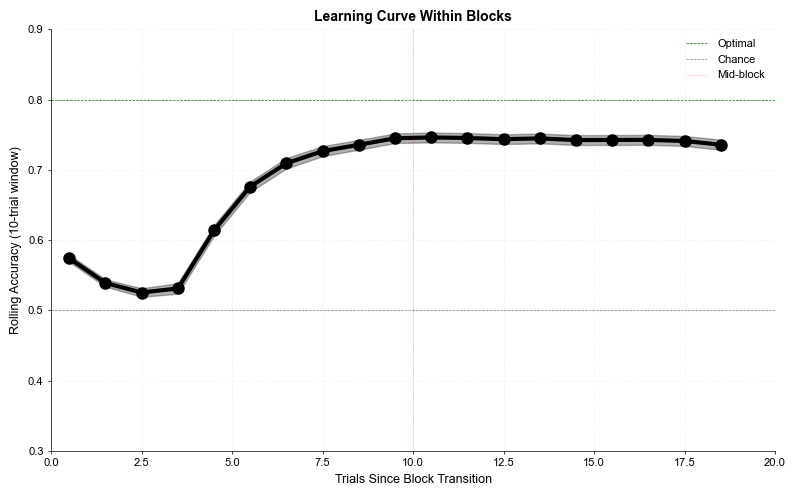


✓ Within-block learning curve saved!

This shows the natural learning trajectory within blocks.
Maybe 'states' are better defined by position in block?


In [362]:
# ============================================================================
# Alternative: Smaller Window or Trial-from-Transition Metric
# ============================================================================

print("Should we:")
print("1. Use SMALLER window (10 trials) so states are more localized?")
print("2. Add 'trials since transition' as an explicit dimension?")
print("3. Keep current approach but rename 'Learning' state?")
print("\nCurrent issue: 20-trial window on 20-trial blocks means")
print("every window spans a transition, making states artificial.")
print("\n" + "="*70)

# Quick test with smaller window
print("\nTesting with 10-trial window...\n")

WINDOW_SMALL = 5

# Recalculate with smaller window (abbreviated)
state_small = []
for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    if len(session_df) < WINDOW_SMALL:
        continue
    
    session_df['2ABT_side_Choice'] = session_df['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    # Trials since transition
    session_df['block_change'] = (session_df['Block'] != session_df['Block'].shift(1)).astype(int)
    session_df['trials_since_trans'] = session_df.groupby((session_df['block_change'] == 1).cumsum()).cumcount()
    
    session_df['rolling_acc_small'] = session_df['High_Prob'].rolling(window=WINDOW_SMALL, min_periods=5).mean()
    
    for idx, trial in session_df.iterrows():
        if pd.notna(trial['rolling_acc_small']):
            state_small.append({
                'trials_since_transition': trial['trials_since_trans'],
                'accuracy': trial['rolling_acc_small']
            })

state_small_df = pd.DataFrame(state_small)

# Plot accuracy vs trials-since-transition
fig, ax = plt.subplots(figsize=(8, 5))

# Bin by trials-since-transition
bins = range(0, 21)
binned = state_small_df.groupby(pd.cut(state_small_df['trials_since_transition'], bins=bins))['accuracy'].agg(['mean', 'sem', 'count'])
binned = binned.dropna()
binned['bin_center'] = [(b.left + b.right)/2 for b in binned.index]

ax.plot(binned['bin_center'], binned['mean'], 'o-', color='black', linewidth=3, markersize=8)
ax.fill_between(binned['bin_center'], 
                binned['mean'] - binned['sem'],
                binned['mean'] + binned['sem'],
                alpha=0.3, color='black')

ax.axhline(0.8, color='green', linestyle='--', linewidth=LINE_WIDTH, label='Optimal')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, label='Chance')
ax.axvline(10, color='red', linestyle=':', linewidth=LINE_WIDTH, alpha=0.5, label='Mid-block')

ax.set_xlabel('Trials Since Block Transition', fontsize=FONTSIZE+1)
ax.set_ylabel('Rolling Accuracy (10-trial window)', fontsize=FONTSIZE+1)
ax.set_title('Learning Curve Within Blocks', fontsize=FONTSIZE+2, fontweight='bold')
ax.set_xlim(0, 20)
ax.set_ylim(0.3, 0.9)
ax.legend(fontsize=FONTSIZE, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Learning_Curve_Within_Blocks_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Within-block learning curve saved!")
print("\nThis shows the natural learning trajectory within blocks.")
print("Maybe 'states' are better defined by position in block?")

In [363]:
# ============================================================================
# Recalculate States with 5-Trial Window
# ============================================================================

print("Recalculating behavioral states with 5-trial window...\n")

WINDOW = 5  # Much smaller to localize states within 20-trial blocks

state_data_final = []

for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    
    if len(session_df) < WINDOW:
        continue
    
    animal = session_df['Animal_Name'].iloc[0]
    
    # Add left/right coding
    session_df['2ABT_side_Choice'] = session_df['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    # Trials since block transition
    session_df['block_change'] = (session_df['Block'] != session_df['Block'].shift(1)).astype(int)
    session_df['trials_since_trans'] = session_df.groupby((session_df['block_change'] == 1).cumsum()).cumcount()
    
    # Calculate rolling metrics with 5-trial window
    session_df['rolling_accuracy'] = session_df['High_Prob'].rolling(window=WINDOW, min_periods=3).mean()
    session_df['rolling_right_choice'] = session_df['2ABT_side_Choice'].rolling(window=WINDOW, min_periods=3).mean()
    
    # Determine which side is high-prob in each block
    for block in session_df['Block'].unique():
        block_mask = session_df['Block'] == block
        block_trials = session_df[block_mask]
        
        correct_choices = block_trials[block_trials['High_Prob'] == 1]['2ABT_side_Choice']
        
        if len(correct_choices) > 2:
            current_high_prob_is_right = correct_choices.mean() > 0.5
            session_df.loc[block_mask, 'high_prob_is_right'] = current_high_prob_is_right
    
    # Expected right choice proportion based on block contingency
    session_df['expected_right_choice'] = session_df['high_prob_is_right'].map({True: 0.8, False: 0.2})
    session_df['choice_deviation'] = (session_df['rolling_right_choice'] - session_df['expected_right_choice']).abs()
    
    # Store trial-level data
    for idx, trial in session_df.iterrows():
        if pd.notna(trial['rolling_accuracy']) and pd.notna(trial['choice_deviation']):
            state_data_final.append({
                'session_id': session_id,
                'animal': animal,
                'trial': trial['Trial'],
                'trials_since_trans': trial['trials_since_trans'],
                'accuracy': trial['rolling_accuracy'],
                'right_choice': trial['rolling_right_choice'],
                'expected_right': trial['expected_right_choice'],
                'choice_deviation': trial['choice_deviation']
            })

state_df_final = pd.DataFrame(state_data_final)

print(f"Analyzed {len(state_df_final):,} trials with 5-trial window")

# ============================================================================
# Classify States
# ============================================================================

def classify_state_final(row):
    acc = row['accuracy']
    dev = row['choice_deviation']
    trials_since = row['trials_since_trans']
    
    # Early in block (0-5 trials): Learning/Adapting
    if trials_since <= 5:
        if acc > 0.6:
            return 'Learning (fast)'
        else:
            return 'Learning (slow)'
    
    # Late in block (>5 trials)
    else:
        # Engaged: High accuracy, following contingency
        if acc > 0.6 and dev < 0.25:
            return 'Engaged'
        
        # Random: ~50% accuracy
        elif 0.3 < acc < 0.6 and 0.2 < dev < 0.4:
            return 'Random'
        
        # Biased: High deviation (not following contingency)
        elif dev > 0.4:
            if row['right_choice'] > row['expected_right']:
                return 'Right Bias'
            else:
                return 'Left Bias'
        
        # Disengaged: Low accuracy
        elif acc < 0.4:
            return 'Disengaged'
        
        else:
            return 'Mixed'

state_df_final['state'] = state_df_final.apply(classify_state_final, axis=1)

# Summary
print("\n" + "="*70)
print("STATE DISTRIBUTION (5-trial window)")
print("="*70)

state_counts = state_df_final['state'].value_counts()
print("\nOverall state distribution:")
print(state_counts)
print(f"\nPercentages:")
print((state_counts / len(state_df_final) * 100).round(1))

print("\nPer animal:")
for animal in sort_animals(state_df_final['animal'].unique()):
    animal_states = state_df_final[state_df_final['animal'] == animal]['state'].value_counts(normalize=True) * 100
    print(f"\n{animal}:")
    main_states = ['Engaged', 'Learning (fast)', 'Learning (slow)', 'Left Bias', 'Right Bias', 'Random', 'Disengaged']
    for state in main_states:
        if state in animal_states.index:
            print(f"  {state}: {animal_states[state]:.1f}%")

print("\n" + "="*70)
print("BREAKDOWN BY TRIAL POSITION IN BLOCK")
print("="*70)

for position in ['Early (0-5)', 'Mid (6-10)', 'Late (11-19)']:
    if position == 'Early (0-5)':
        subset = state_df_final[state_df_final['trials_since_trans'] <= 5]
    elif position == 'Mid (6-10)':
        subset = state_df_final[(state_df_final['trials_since_trans'] > 5) & (state_df_final['trials_since_trans'] <= 10)]
    else:
        subset = state_df_final[state_df_final['trials_since_trans'] > 10]
    
    print(f"\n{position}:")
    state_dist = subset['state'].value_counts(normalize=True) * 100
    for state in state_dist.head(5).index:
        print(f"  {state}: {state_dist[state]:.1f}%")

print("="*70)

Recalculating behavioral states with 5-trial window...

Analyzed 36,473 trials with 5-trial window

STATE DISTRIBUTION (5-trial window)

Overall state distribution:
state
Engaged            15607
Learning (slow)     7018
Mixed               5689
Learning (fast)     3997
Left Bias           1511
Right Bias          1298
Random              1261
Disengaged            92
Name: count, dtype: int64

Percentages:
state
Engaged            42.8
Learning (slow)    19.2
Mixed              15.6
Learning (fast)    11.0
Left Bias           4.1
Right Bias          3.6
Random              3.5
Disengaged          0.3
Name: count, dtype: float64

Per animal:

Fiona:
  Engaged: 47.5%
  Learning (fast): 9.8%
  Learning (slow): 20.4%
  Left Bias: 4.4%
  Right Bias: 1.0%
  Random: 1.6%
  Disengaged: 1.8%

Knuckles:
  Engaged: 43.2%
  Learning (fast): 11.5%
  Learning (slow): 18.7%
  Left Bias: 3.1%
  Right Bias: 4.0%
  Random: 3.9%

Sonic:
  Engaged: 41.4%
  Learning (fast): 10.1%
  Learning (slow): 20.0%


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/3342425972.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


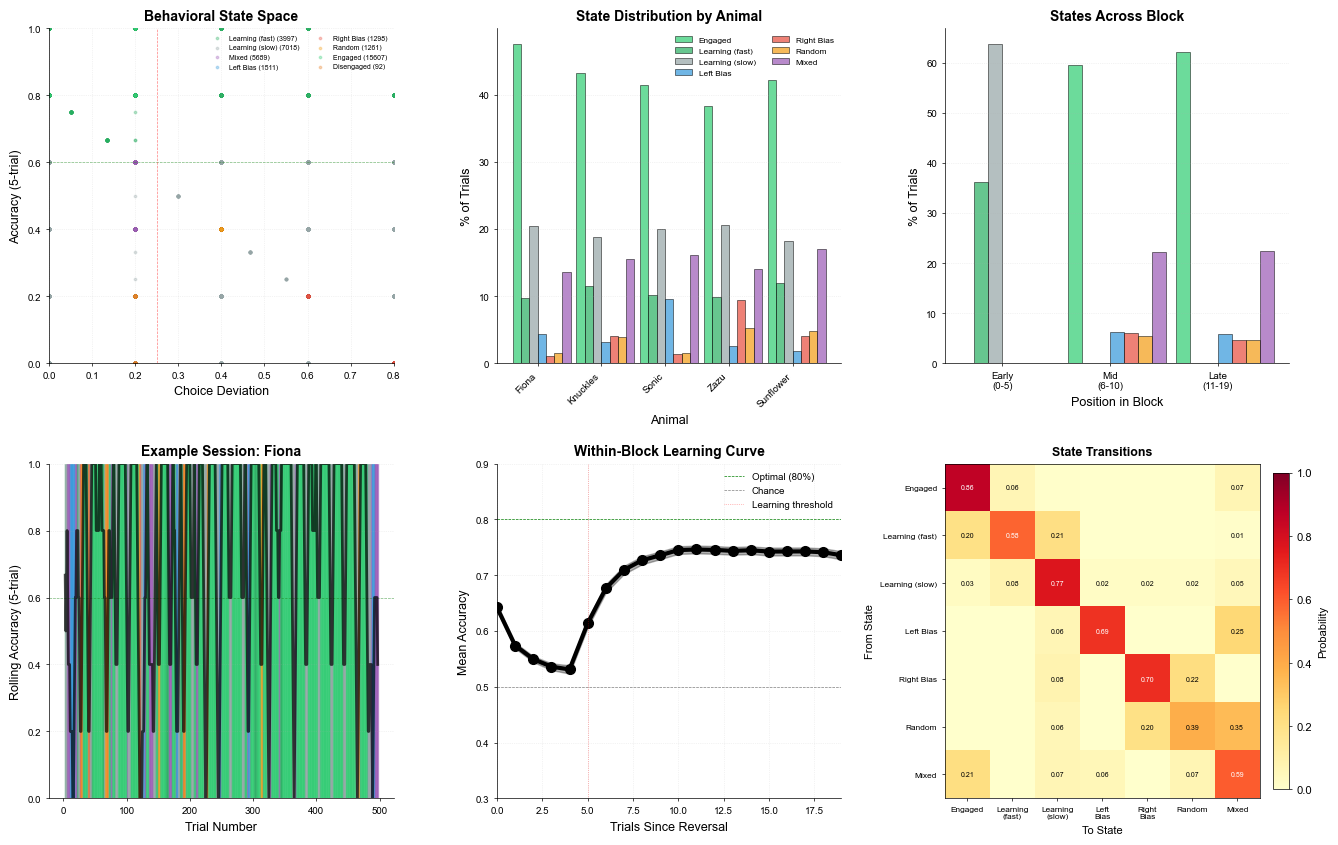


✓ Final behavioral states figure (5-trial window) saved!


In [387]:
# ============================================================================
# Final Comprehensive Behavioral States Figure (5-trial window)
# ============================================================================

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

state_colors = {
    'Engaged': '#2ecc71',
    'Learning (fast)': '#27ae60',
    'Learning (slow)': '#95a5a6',
    'Random': '#f39c12',
    'Left Bias': '#3498db',
    'Right Bias': '#e74c3c',
    'Disengaged': '#e67e22',
    'Mixed': '#9b59b6'
}

# ====================================================================
# Panel A: State Space (Accuracy vs Choice Deviation)
# ====================================================================

ax1 = fig.add_subplot(gs[0, 0])

for state in state_df_final['state'].unique():
    state_trials = state_df_final[state_df_final['state'] == state]
    ax1.scatter(state_trials['choice_deviation'], state_trials['accuracy'],
               s=3, alpha=0.3, color=state_colors.get(state, 'gray'),
               label=f"{state} ({len(state_trials)})")

ax1.axhline(0.6, color='green', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax1.axvline(0.25, color='red', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)

ax1.set_xlabel('Choice Deviation', fontsize=FONTSIZE+1)
ax1.set_ylabel('Accuracy (5-trial)', fontsize=FONTSIZE+1)
ax1.set_title('Behavioral State Space', fontsize=FONTSIZE+2, fontweight='bold')
ax1.set_xlim(0, 0.8)
ax1.set_ylim(0, 1)
ax1.legend(fontsize=FONTSIZE-3, frameon=False, loc='upper right', ncol=2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel B: State Distribution by Animal
# ====================================================================

ax2 = fig.add_subplot(gs[0, 1])

main_states = ['Engaged', 'Learning (fast)', 'Learning (slow)', 'Left Bias', 'Right Bias', 'Random', 'Mixed']
animals = sort_animals(state_df_final['animal'].unique())

state_props = []
for animal in animals:
    animal_df = state_df_final[state_df_final['animal'] == animal]
    props = []
    for state in main_states:
        prop = (animal_df['state'] == state).sum() / len(animal_df) * 100
        props.append(prop)
    state_props.append(props)

state_props = np.array(state_props)

x = np.arange(len(animals))
width = 0.13

for i, state in enumerate(main_states):
    ax2.bar(x + i*width - 2.5*width, state_props[:, i], width,
           label=state, color=state_colors[state], alpha=0.7,
           edgecolor='black', linewidth=LINE_WIDTH)

ax2.set_xticks(x)
ax2.set_xticklabels(animals, rotation=45, ha='right', fontsize=FONTSIZE-1)
ax2.set_ylabel('% of Trials', fontsize=FONTSIZE+1)
ax2.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax2.set_title('State Distribution by Animal', fontsize=FONTSIZE+2, fontweight='bold')
ax2.legend(fontsize=FONTSIZE-2, frameon=False, ncol=2, loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel C: States by Position in Block
# ====================================================================

ax3 = fig.add_subplot(gs[0, 2])

positions = ['Early\n(0-5)', 'Mid\n(6-10)', 'Late\n(11-19)']
position_data = []

for pos_name, (low, high) in [('Early\n(0-5)', (0, 5)), 
                               ('Mid\n(6-10)', (6, 10)), 
                               ('Late\n(11-19)', (11, 19))]:
    subset = state_df_final[(state_df_final['trials_since_trans'] >= low) & 
                            (state_df_final['trials_since_trans'] <= high)]
    props = []
    for state in main_states:
        prop = (subset['state'] == state).sum() / len(subset) * 100
        props.append(prop)
    position_data.append(props)

position_data = np.array(position_data)

x = np.arange(len(positions))

for i, state in enumerate(main_states):
    ax3.bar(x + i*width - 2.5*width, position_data[:, i], width,
           label=state if i < 3 else '', color=state_colors[state], alpha=0.7,
           edgecolor='black', linewidth=LINE_WIDTH)

ax3.set_xticks(x)
ax3.set_xticklabels(positions, fontsize=FONTSIZE)
ax3.set_ylabel('% of Trials', fontsize=FONTSIZE+1)
ax3.set_xlabel('Position in Block', fontsize=FONTSIZE+1)
ax3.set_title('States Across Block', fontsize=FONTSIZE+2, fontweight='bold')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax3.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel D: Example Session
# ====================================================================

ax4 = fig.add_subplot(gs[1, 0])

example_session = state_df_final.groupby('session_id')['state'].apply(lambda x: x.nunique()).idxmax()
session_states = state_df_final[state_df_final['session_id'] == example_session].copy()
animal = session_states['animal'].iloc[0]

trials = session_states['trial'].values
accuracy = session_states['accuracy'].values

ax4.plot(trials, accuracy, 'k-', linewidth=2, alpha=0.7, zorder=10)

for state in session_states['state'].unique():
    state_trials = session_states[session_states['state'] == state]
    for _, trial in state_trials.iterrows():
        ax4.axvspan(trial['trial']-0.5, trial['trial']+0.5,
                   color=state_colors.get(state, 'gray'), alpha=0.5, zorder=0)

ax4.axhline(0.6, color='green', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax4.set_xlabel('Trial Number', fontsize=FONTSIZE+1)
ax4.set_ylabel('Rolling Accuracy (5-trial)', fontsize=FONTSIZE+1)
ax4.set_title(f'Example Session: {animal}', fontsize=FONTSIZE+2, fontweight='bold')
ax4.set_ylim(0, 1)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax4.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel E: Learning Curve (Accuracy vs Trials Since Transition)
# ====================================================================

ax5 = fig.add_subplot(gs[1, 1])

learning_curve = state_df_final.groupby('trials_since_trans').agg({
    'accuracy': ['mean', 'sem', 'count']
}).reset_index()
learning_curve.columns = ['trials_since_trans', 'mean_acc', 'sem', 'n']
learning_curve = learning_curve[learning_curve['trials_since_trans'] <= 19]

ax5.plot(learning_curve['trials_since_trans'], learning_curve['mean_acc'],
        'o-', color='black', linewidth=3, markersize=7)
ax5.fill_between(learning_curve['trials_since_trans'],
                learning_curve['mean_acc'] - learning_curve['sem'],
                learning_curve['mean_acc'] + learning_curve['sem'],
                alpha=0.3, color='black')

ax5.axhline(0.8, color='green', linestyle='--', linewidth=LINE_WIDTH, label='Optimal (80%)')
ax5.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, label='Chance')
ax5.axvline(5, color='red', linestyle=':', linewidth=LINE_WIDTH, alpha=0.5, label='Learning threshold')

ax5.set_xlabel('Trials Since Reversal', fontsize=FONTSIZE+1)
ax5.set_ylabel('Mean Accuracy', fontsize=FONTSIZE+1)
ax5.set_title('Within-Block Learning Curve', fontsize=FONTSIZE+2, fontweight='bold')
ax5.set_xlim(0, 19)
ax5.set_ylim(0.3, 0.9)
ax5.legend(fontsize=FONTSIZE-1, frameon=False)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.grid(alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax5.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel F: State Transition Matrix
# ====================================================================

ax6 = fig.add_subplot(gs[1, 2])

transitions = []
for session_id in state_df_final['session_id'].unique():
    sess = state_df_final[state_df_final['session_id'] == session_id].sort_values('trial')
    for i in range(len(sess)-1):
        from_state = sess.iloc[i]['state']
        to_state = sess.iloc[i+1]['state']
        if from_state in main_states and to_state in main_states:
            transitions.append({'from': from_state, 'to': to_state})

trans_df = pd.DataFrame(transitions)
trans_matrix = pd.crosstab(trans_df['from'], trans_df['to'], normalize='index')
trans_matrix = trans_matrix.reindex(index=main_states, columns=main_states, fill_value=0)

im = ax6.imshow(trans_matrix.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax6.set_xticks(range(len(main_states)))
ax6.set_xticklabels([s.replace(' ', '\n') for s in main_states], rotation=0, ha='center', fontsize=FONTSIZE-2)
ax6.set_yticks(range(len(main_states)))
ax6.set_yticklabels(main_states, fontsize=FONTSIZE-2)
ax6.set_xlabel('To State', fontsize=FONTSIZE)
ax6.set_ylabel('From State', fontsize=FONTSIZE)
ax6.set_title('State Transitions', fontsize=FONTSIZE+1, fontweight='bold')

for i in range(len(main_states)):
    for j in range(len(main_states)):
        value = trans_matrix.values[i, j]
        if value > 0.01:
            ax6.text(j, i, f'{value:.2f}',
                    ha='center', va='center',
                    color='white' if value > 0.5 else 'black',
                    fontsize=FONTSIZE-3)

plt.colorbar(im, ax=ax6, label='Probability', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Behavioral_States_Final_5Trial_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Final behavioral states figure (5-trial window) saved!")

Analyzing Q-learning model across behavioral states...

Processing Fiona...
Processing Knuckles...
Processing Sonic...
Processing Zazu...
Processing Sunflower...

Analyzed 36,473 trials

MODEL PERFORMANCE BY STATE

Engaged (15607 trials):
  Mean Q-value diff: 0.000
  Mean |PE|: 0.500
  Choice matches model: 51.3%
  Mean p(right): 0.500

Learning (fast) (3997 trials):
  Mean Q-value diff: 0.000
  Mean |PE|: 0.500
  Choice matches model: 48.4%
  Mean p(right): 0.500

Learning (slow) (7018 trials):
  Mean Q-value diff: 0.000
  Mean |PE|: 0.500
  Choice matches model: 49.6%
  Mean p(right): 0.500

Left Bias (1511 trials):
  Mean Q-value diff: 0.000
  Mean |PE|: 0.500
  Choice matches model: 77.4%
  Mean p(right): 0.500

Right Bias (1298 trials):
  Mean Q-value diff: 0.000
  Mean |PE|: 0.500
  Choice matches model: 21.5%
  Mean p(right): 0.500

Random (1261 trials):
  Mean Q-value diff: 0.000
  Mean |PE|: 0.500
  Choice matches model: 49.3%
  Mean p(right): 0.500


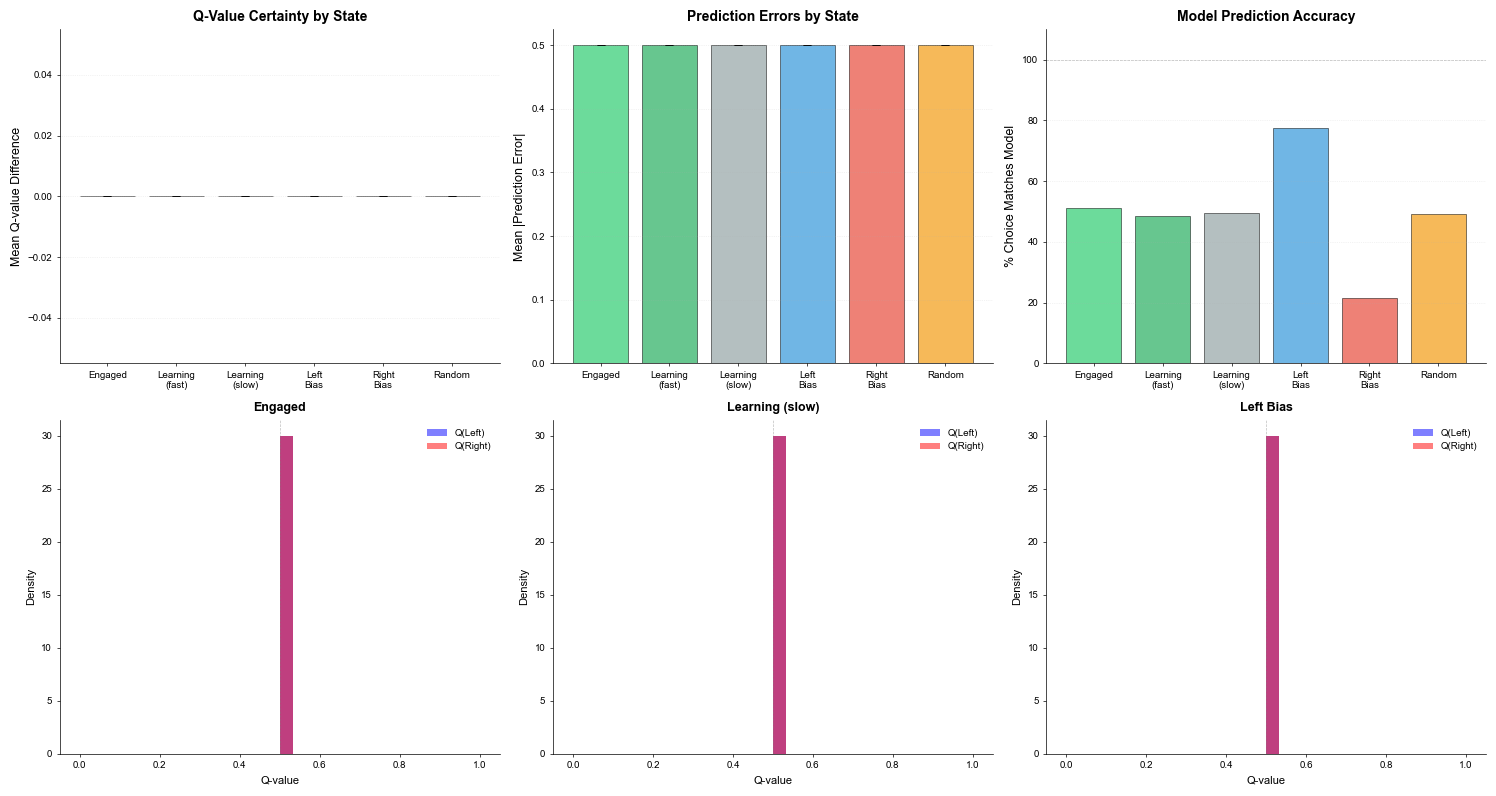


✓ Model performance by state figure saved!


In [389]:
# Q-Learning Model Performance by Behavioral State
# ============================================================================

print("Analyzing Q-learning model across behavioral states...\n")

# Merge state classifications with model predictions
# We need to regenerate predictions with trial-level info

state_model_analysis = []

for animal in sort_animals(full_results['animal'].unique()):
    print(f"Processing {animal}...")
    
    animal_data = df[df['Animal_Name'] == animal].copy()
    animal_states = state_df_final[state_df_final['animal'] == animal].copy()
    
    params = full_results[full_results['animal'] == animal].iloc[0]
    alpha = params['qlearn_kernel_alpha']
    beta = params['qlearn_kernel_beta']
    kappa = params['qlearn_kernel_kappa']
    
    # Add left/right coding
    animal_data['2ABT_side_Choice'] = animal_data['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    # Run Q-learning model to get trial-by-trial predictions
    for session_id in animal_data['Session_ID'].unique():
        session_data = animal_data[animal_data['Session_ID'] == session_id].sort_values('Trial').copy()
        
        Q = {'left': 0.5, 'right': 0.5}
        C = {'left': 0.0, 'right': 0.0}
        
        for idx, trial in session_data.iterrows():
            side_choice = trial['2ABT_side_Choice']
            outcome = trial['Outcome']
            trial_num = trial['Trial']
            
            if pd.isna(side_choice) or pd.isna(outcome):
                continue
            
            chosen_side = 'right' if side_choice == 1 else 'left'
            other_side = 'left' if chosen_side == 'right' else 'right'
            
            # Get Q-values and choice probability BEFORE update
            V_right = beta * Q['right'] + kappa * C['right']
            V_left = beta * Q['left'] + kappa * C['left']
            p_right = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
            
            # Get state for this trial
            state_info = animal_states[(animal_states['session_id'] == session_id) & 
                                       (animal_states['trial'] == trial_num)]
            
            if len(state_info) > 0:
                state = state_info['state'].iloc[0]
                
                # Calculate prediction error
                PE = outcome - Q[chosen_side]
                
                # Was choice optimal according to model?
                model_choice = 1 if p_right > 0.5 else 0
                choice_matches_model = (model_choice == side_choice)
                
                state_model_analysis.append({
                    'animal': animal,
                    'session_id': session_id,
                    'trial': trial_num,
                    'state': state,
                    'Q_left': Q['left'],
                    'Q_right': Q['right'],
                    'Q_chosen': Q[chosen_side],
                    'Q_diff': abs(Q['right'] - Q['left']),
                    'p_right': p_right,
                    'chose_right': side_choice,
                    'outcome': outcome,
                    'PE': PE,
                    'choice_matches_model': choice_matches_model
                })
            

state_model_df = pd.DataFrame(state_model_analysis)

print(f"\nAnalyzed {len(state_model_df):,} trials")

# ============================================================================
# Compare Model Metrics Across States
# ============================================================================

print("\n" + "="*70)
print("MODEL PERFORMANCE BY STATE")
print("="*70)

main_states = ['Engaged', 'Learning (fast)', 'Learning (slow)', 'Left Bias', 'Right Bias', 'Random']

for state in main_states:
    state_data = state_model_df[state_model_df['state'] == state]
    
    if len(state_data) > 0:
        print(f"\n{state} ({len(state_data)} trials):")
        print(f"  Mean Q-value diff: {state_data['Q_diff'].mean():.3f}")
        print(f"  Mean |PE|: {state_data['PE'].abs().mean():.3f}")
        print(f"  Choice matches model: {state_data['choice_matches_model'].mean()*100:.1f}%")
        print(f"  Mean p(right): {state_data['p_right'].mean():.3f}")

# ============================================================================
# Visualize Model Performance by State
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

state_colors_main = {s: state_colors[s] for s in main_states}

# Panel A: Q-value difference by state
ax1 = axes[0, 0]

state_q_diff = []
for state in main_states:
    state_data = state_model_df[state_model_df['state'] == state]
    if len(state_data) > 0:
        state_q_diff.append({
            'state': state,
            'mean': state_data['Q_diff'].mean(),
            'sem': state_data['Q_diff'].sem()
        })

q_diff_df = pd.DataFrame(state_q_diff)

bars = ax1.bar(range(len(q_diff_df)), q_diff_df['mean'],
              color=[state_colors_main[s] for s in q_diff_df['state']],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax1.errorbar(range(len(q_diff_df)), q_diff_df['mean'], yerr=q_diff_df['sem'],
            fmt='none', color='black', linewidth=LINE_WIDTH,
            capsize=3, capthick=LINE_WIDTH)

ax1.set_xticks(range(len(q_diff_df)))
ax1.set_xticklabels([s.replace(' ', '\n') for s in q_diff_df['state']], 
                     rotation=0, ha='center', fontsize=FONTSIZE-1)
ax1.set_ylabel('Mean Q-value Difference', fontsize=FONTSIZE+1)
ax1.set_title('Q-Value Certainty by State', fontsize=FONTSIZE+2, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# Panel B: Prediction Error by state
ax2 = axes[0, 1]

state_pe = []
for state in main_states:
    state_data = state_model_df[state_model_df['state'] == state]
    if len(state_data) > 0:
        state_pe.append({
            'state': state,
            'mean': state_data['PE'].abs().mean(),
            'sem': state_data['PE'].abs().sem()
        })

pe_df = pd.DataFrame(state_pe)

bars = ax2.bar(range(len(pe_df)), pe_df['mean'],
              color=[state_colors_main[s] for s in pe_df['state']],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax2.errorbar(range(len(pe_df)), pe_df['mean'], yerr=pe_df['sem'],
            fmt='none', color='black', linewidth=LINE_WIDTH,
            capsize=3, capthick=LINE_WIDTH)

ax2.set_xticks(range(len(pe_df)))
ax2.set_xticklabels([s.replace(' ', '\n') for s in pe_df['state']], 
                     rotation=0, ha='center', fontsize=FONTSIZE-1)
ax2.set_ylabel('Mean |Prediction Error|', fontsize=FONTSIZE+1)
ax2.set_title('Prediction Errors by State', fontsize=FONTSIZE+2, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# Panel C: Model choice agreement
ax3 = axes[0, 2]

state_match = []
for state in main_states:
    state_data = state_model_df[state_model_df['state'] == state]
    if len(state_data) > 0:
        state_match.append({
            'state': state,
            'pct': state_data['choice_matches_model'].mean() * 100
        })

match_df = pd.DataFrame(state_match)

bars = ax3.bar(range(len(match_df)), match_df['pct'],
              color=[state_colors_main[s] for s in match_df['state']],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax3.axhline(100, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)

ax3.set_xticks(range(len(match_df)))
ax3.set_xticklabels([s.replace(' ', '\n') for s in match_df['state']], 
                     rotation=0, ha='center', fontsize=FONTSIZE-1)
ax3.set_ylabel('% Choice Matches Model', fontsize=FONTSIZE+1)
ax3.set_title('Model Prediction Accuracy', fontsize=FONTSIZE+2, fontweight='bold')
ax3.set_ylim(0, 110)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax3.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# Panel D-F: Q-value distributions by state
for idx, state in enumerate(['Engaged', 'Learning (slow)', 'Left Bias']):
    ax = axes[1, idx]
    
    state_data = state_model_df[state_model_df['state'] == state]
    
    if len(state_data) > 100:
        ax.hist(state_data['Q_left'], bins=30, alpha=0.5, color='blue', 
               label='Q(Left)', density=True)
        ax.hist(state_data['Q_right'], bins=30, alpha=0.5, color='red',
               label='Q(Right)', density=True)
        
        ax.axvline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
        ax.set_xlabel('Q-value', fontsize=FONTSIZE)
        ax.set_ylabel('Density', fontsize=FONTSIZE)
        ax.set_title(f'{state}', fontsize=FONTSIZE+1, fontweight='bold')
        ax.legend(fontsize=FONTSIZE-1, frameon=False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Model_Performance_by_State_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Model performance by state figure saved!")
print("="*70)

In [390]:
# Q-Learning Model with Train/Test Split
# ============================================================================

print("Fitting Q-learning models with train/test split...\n")

from sklearn.model_selection import train_test_split

TRAIN_PROP = 0.8
RANDOM_SEED = 42

# ============================================================================
# Split sessions into train/test
# ============================================================================

train_test_results = []

for animal in sort_animals(df['Animal_Name'].unique()):
    print(f"\nProcessing {animal}...")
    
    animal_data = df[df['Animal_Name'] == animal].copy()
    animal_sessions = animal_data['Session_ID'].unique()
    
    # Split sessions
    train_sessions, test_sessions = train_test_split(
        animal_sessions, train_size=TRAIN_PROP, random_state=RANDOM_SEED
    )
    
    print(f"  Train: {len(train_sessions)} sessions")
    print(f"  Test: {len(test_sessions)} sessions")
    
    # Prepare data
    animal_data['2ABT_side_Choice'] = animal_data['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    train_data = animal_data[animal_data['Session_ID'].isin(train_sessions)].copy()
    test_data = animal_data[animal_data['Session_ID'].isin(test_sessions)].copy()
    
    # Prepare for model fitting (need session_id, trial, etc.)
    train_fit = train_data[['Session_ID', 'Trial', 'PhysicalChoice', 'Outcome', 'PhysicalSwitch']].copy()
    train_fit.columns = ['session_id', 'trial', 'PhysicalChoice', 'Outcome', 'PhysicalSwitch']
    train_fit = train_fit.dropna(subset=['Outcome'])
    
    test_fit = test_data[['Session_ID', 'Trial', 'PhysicalChoice', 'Outcome', 'PhysicalSwitch']].copy()
    test_fit.columns = ['session_id', 'trial', 'PhysicalChoice', 'Outcome', 'PhysicalSwitch']
    test_fit = test_fit.dropna(subset=['Outcome'])
    
    # ========================================================================
    # Fit Q-kernel model on TRAINING data
    # ========================================================================
    
    print(f"  Fitting model on {len(train_fit)} training trials...")
    
    result = minimize(
        qlearning_choicekernel_loglik,
        x0=[0.3, 2.0, 1.0],
        args=(train_fit,),
        bounds=[(0.001, 0.999), (0.01, 20), (-5, 5)],
        method='L-BFGS-B'
    )
    
    alpha_train, beta_train, kappa_train = result.x
    negLL_train = result.fun
    n_train = len(train_fit)
    bic_train = 2 * negLL_train + 3 * np.log(n_train)
    
    print(f"  Train params: α={alpha_train:.3f}, β={beta_train:.3f}, κ={kappa_train:.3f}")
    print(f"  Train BIC: {bic_train:.1f}")
    
    # ========================================================================
    # Evaluate on TEST data
    # ========================================================================
    
    print(f"  Evaluating on {len(test_fit)} test trials...")
    
    negLL_test = qlearning_choicekernel_loglik([alpha_train, beta_train, kappa_train], test_fit)
    n_test = len(test_fit)
    bic_test = 2 * negLL_test + 3 * np.log(n_test)
    
    print(f"  Test BIC: {bic_test:.1f}")
    
    train_test_results.append({
        'animal': animal,
        'n_train': n_train,
        'n_test': n_test,
        'alpha': alpha_train,
        'beta': beta_train,
        'kappa': kappa_train,
        'negLL_train': negLL_train,
        'negLL_test': negLL_test,
        'bic_train': bic_train,
        'bic_test': bic_test,
        'train_sessions': train_sessions,
        'test_sessions': test_sessions
    })

train_test_df = pd.DataFrame(train_test_results)

print("\n" + "="*70)
print("TRAIN/TEST RESULTS")
print("="*70)
print(train_test_df[['animal', 'alpha', 'beta', 'kappa', 'bic_train', 'bic_test']])

# ============================================================================
# Now evaluate model predictions by state on TEST data only
# ============================================================================

print("\n" + "="*70)
print("EVALUATING MODEL BY STATE ON TEST DATA")
print("="*70)

test_state_analysis = []

for idx, row in train_test_df.iterrows():
    animal = row['animal']
    alpha = row['alpha']
    beta = row['beta']
    kappa = row['kappa']
    test_sessions = row['test_sessions']
    
    print(f"\n{animal}:")
    
    animal_data = df[df['Animal_Name'] == animal].copy()
    animal_data['2ABT_side_Choice'] = animal_data['PhysicalChoice'].map({
        'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
        'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1
    })
    
    # Only test sessions
    test_data = animal_data[animal_data['Session_ID'].isin(test_sessions)].copy()
    
    # Get states for test trials
    test_states = state_df_final[
        (state_df_final['animal'] == animal) & 
        (state_df_final['session_id'].isin(test_sessions))
    ].copy()
    
    # Run model on test data
    for session_id in test_sessions:
        session_data = test_data[test_data['Session_ID'] == session_id].sort_values('Trial').copy()
        
        Q = {'left': 0.5, 'right': 0.5}
        C = {'left': 0.0, 'right': 0.0}
        
        for _, trial in session_data.iterrows():
            side_choice = trial['2ABT_side_Choice']
            outcome = trial['Outcome']
            trial_num = trial['Trial']
            
            if pd.isna(side_choice) or pd.isna(outcome):
                continue
            
            chosen_side = 'right' if side_choice == 1 else 'left'
            other_side = 'left' if chosen_side == 'right' else 'right'
            
            # Predict
            V_right = beta * Q['right'] + kappa * C['right']
            V_left = beta * Q['left'] + kappa * C['left']
            p_right = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
            
            # Get state
            state_info = test_states[
                (test_states['session_id'] == session_id) & 
                (test_states['trial'] == trial_num)
            ]
            
            if len(state_info) > 0:
                state = state_info['state'].iloc[0]
                
                PE = outcome - Q[chosen_side]
                model_choice = 1 if p_right > 0.5 else 0
                choice_matches = (model_choice == side_choice)
                
                test_state_analysis.append({
                    'animal': animal,
                    'state': state,
                    'choice_matches': choice_matches,
                    'PE': PE,
                    'Q_diff': abs(Q['right'] - Q['left'])
                })
            
            # Update
            PE = outcome - Q[chosen_side]
            Q[chosen_side] = Q[chosen_side] + alpha * PE
            C[chosen_side] = 1.0
            C[other_side] = 0.0

test_state_df = pd.DataFrame(test_state_analysis)

print(f"\nAnalyzed {len(test_state_df):,} test trials")

# ============================================================================
# Compare by state
# ============================================================================

print("\n" + "="*70)
print("TEST SET: MODEL PERFORMANCE BY STATE")
print("="*70)

main_states = ['Engaged', 'Learning (fast)', 'Learning (slow)', 'Left Bias', 'Right Bias', 'Random']

for state in main_states:
    state_data = test_state_df[test_state_df['state'] == state]
    
    if len(state_data) > 0:
        print(f"\n{state} ({len(state_data)} test trials):")
        print(f"  Choice matches model: {state_data['choice_matches'].mean()*100:.1f}%")
        print(f"  Mean |PE|: {state_data['PE'].abs().mean():.3f}")
        print(f"  Mean Q-diff: {state_data['Q_diff'].mean():.3f}")

print("\n" + "="*70)
print("COMPARISON: Train vs Test Parameters")
print("="*70)

# Compare to original full-data fit
comparison = train_test_df.merge(
    full_results[['animal', 'qlearn_kernel_alpha', 'qlearn_kernel_beta', 'qlearn_kernel_kappa']], 
    on='animal'
)

for _, row in comparison.iterrows():
    print(f"\n{row['animal']}:")
    print(f"  α: {row['qlearn_kernel_alpha']:.3f} (full) → {row['alpha']:.3f} (train)")
    print(f"  β: {row['qlearn_kernel_beta']:.3f} (full) → {row['beta']:.3f} (train)")
    print(f"  κ: {row['qlearn_kernel_kappa']:.3f} (full) → {row['kappa']:.3f} (train)")

print("="*70)

Fitting Q-learning models with train/test split...


Processing Fiona...
  Train: 11 sessions
  Test: 3 sessions
  Fitting model on 3701 training trials...
  Train params: α=0.597, β=1.404, κ=1.441
  Train BIC: 2937.8
  Evaluating on 1523 test trials...
  Test BIC: 1146.3

Processing Knuckles...
  Train: 18 sessions
  Test: 5 sessions
  Fitting model on 9017 training trials...
  Train params: α=0.692, β=1.211, κ=1.113
  Train BIC: 8512.5
  Evaluating on 2033 test trials...
  Test BIC: 1968.5

Processing Sonic...
  Train: 11 sessions
  Test: 3 sessions
  Fitting model on 5631 training trials...
  Train params: α=0.894, β=0.791, κ=1.482
  Train BIC: 4856.2
  Evaluating on 1540 test trials...
  Test BIC: 1390.3

Processing Zazu...
  Train: 11 sessions
  Test: 3 sessions
  Fitting model on 2768 training trials...
  Train params: α=0.677, β=0.793, κ=1.526
  Train BIC: 2407.8
  Evaluating on 536 test trials...
  Test BIC: 544.1

Processing Sunflower...
  Train: 28 sessions
  Test: 7 sessions

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/1690581460.py:259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


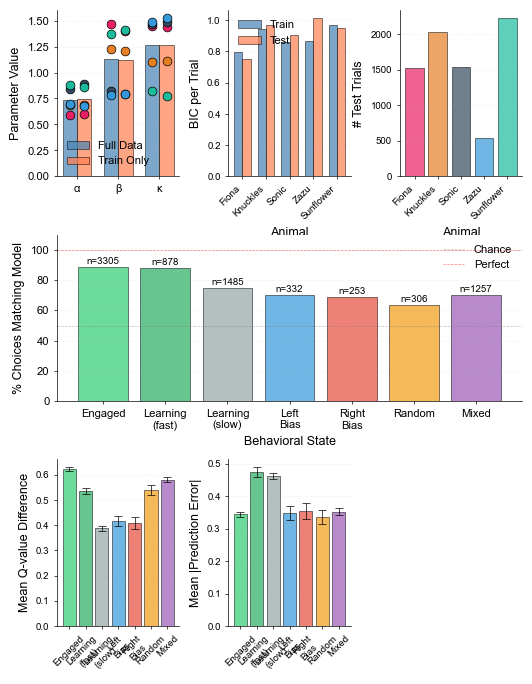


✓ Train/test analysis figure saved!
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/TrainTest_Model_Analysis_2ABT.svg


In [391]:
# Visualize Train/Test Results
# ============================================================================

fig = plt.figure(figsize=(6, 8))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.4)

# ====================================================================
# Panel A: Parameter Comparison (Train vs Full)
# ====================================================================

ax1 = fig.add_subplot(gs[0, 0])

params = ['alpha', 'beta', 'kappa']
param_labels = ['α', 'β', 'κ']

x = np.arange(len(params))
width = 0.35

full_means = [comparison['qlearn_kernel_alpha'].mean(), 
              comparison['qlearn_kernel_beta'].mean(),
              comparison['qlearn_kernel_kappa'].mean()]

train_means = [comparison['alpha'].mean(),
               comparison['beta'].mean(), 
               comparison['kappa'].mean()]

bars1 = ax1.bar(x - width/2, full_means, width, label='Full Data',
               color='steelblue', alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)
bars2 = ax1.bar(x + width/2, train_means, width, label='Train Only',
               color='coral', alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

# Add individual animals
for i, param in enumerate(params):
    full_col = f'qlearn_kernel_{param}'
    for _, animal_row in comparison.iterrows():
        ax1.scatter([i - width/2], [animal_row[full_col]], 
                   s=40, color=ANIMAL_COLORS[animal_row['animal']], 
                   edgecolor='black', linewidth=0.5, zorder=10)
        ax1.scatter([i + width/2], [animal_row[param]], 
                   s=40, color=ANIMAL_COLORS[animal_row['animal']], 
                   edgecolor='black', linewidth=0.5, zorder=10)

ax1.set_xticks(x)
ax1.set_xticklabels(param_labels, fontsize=FONTSIZE+2)
ax1.set_ylabel('Parameter Value', fontsize=FONTSIZE+1)
# ax1.set_title('Parameter Stability: Full vs Train', fontsize=FONTSIZE+2, fontweight='bold')
ax1.legend(fontsize=FONTSIZE, frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# ====================================================================
# Panel B: BIC Train vs Test
# ====================================================================

ax2 = fig.add_subplot(gs[0, 1])

animals = train_test_df['animal'].values
train_bic_per_trial = train_test_df['bic_train'] / train_test_df['n_train']
test_bic_per_trial = train_test_df['bic_test'] / train_test_df['n_test']

x = np.arange(len(animals))

bars1 = ax2.bar(x - width/2, train_bic_per_trial, width, label='Train',
               color='steelblue', alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)
bars2 = ax2.bar(x + width/2, test_bic_per_trial, width, label='Test',
               color='coral', alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax2.set_xticks(x)
ax2.set_xticklabels(animals, rotation=45, ha='right', fontsize=FONTSIZE-1)
ax2.set_ylabel('BIC per Trial', fontsize=FONTSIZE+1)
ax2.set_xlabel('Animal', fontsize=FONTSIZE+1)
# ax2.set_title('Model Fit: Train vs Test', fontsize=FONTSIZE+2, fontweight='bold')
ax2.legend(fontsize=FONTSIZE, frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel C: Test Set Size
# ====================================================================

ax3 = fig.add_subplot(gs[0, 2])

bars = ax3.bar(x, train_test_df['n_test'], 
              color=[ANIMAL_COLORS[a] for a in animals],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax3.set_xticks(x)
ax3.set_xticklabels(animals, rotation=45, ha='right', fontsize=FONTSIZE-1)
ax3.set_ylabel('# Test Trials', fontsize=FONTSIZE+1)
ax3.set_xlabel('Animal', fontsize=FONTSIZE+1)
# ax3.set_title('Test Set Size', fontsize=FONTSIZE+2, fontweight='bold')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax3.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel D: Model Accuracy by State (TEST SET)
# ====================================================================

ax4 = fig.add_subplot(gs[1, :])

main_states = ['Engaged', 'Learning (fast)', 'Learning (slow)', 'Left Bias', 'Right Bias', 'Random', 'Mixed']

state_performance = []
for state in main_states:
    state_data = test_state_df[test_state_df['state'] == state]
    if len(state_data) > 0:
        state_performance.append({
            'state': state,
            'accuracy': state_data['choice_matches'].mean() * 100,
            'n': len(state_data)
        })

perf_df = pd.DataFrame(state_performance)

x = np.arange(len(perf_df))

bars = ax4.bar(x, perf_df['accuracy'],
              color=[state_colors[s] for s in perf_df['state']],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

# Add counts on bars
for i, (idx, row) in enumerate(perf_df.iterrows()):
    ax4.text(i, row['accuracy'] + 2, f"n={row['n']}", 
            ha='center', fontsize=FONTSIZE-1)

ax4.axhline(50, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5, label='Chance')
ax4.axhline(100, color='red', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5, label='Perfect')

ax4.set_xticks(x)
ax4.set_xticklabels([s.replace(' ', '\n') for s in perf_df['state']], 
                     fontsize=FONTSIZE, ha='center')
ax4.set_ylabel('% Choices Matching Model', fontsize=FONTSIZE+1)
ax4.set_xlabel('Behavioral State', fontsize=FONTSIZE+1)
# ax4.set_title('Model Prediction Accuracy by State (Test Set)', 
#              fontsize=FONTSIZE+2, fontweight='bold')
ax4.set_ylim(0, 110)
ax4.legend(fontsize=FONTSIZE, frameon=False)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax4.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# ====================================================================
# Panel E: Q-value Difference by State
# ====================================================================

ax5 = fig.add_subplot(gs[2, 0])

state_qvals = []
for state in main_states:
    state_data = test_state_df[test_state_df['state'] == state]
    if len(state_data) > 0:
        state_qvals.append({
            'state': state,
            'mean': state_data['Q_diff'].mean(),
            'sem': state_data['Q_diff'].sem()
        })

qval_df = pd.DataFrame(state_qvals)

bars = ax5.bar(range(len(qval_df)), qval_df['mean'],
              color=[state_colors[s] for s in qval_df['state']],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax5.errorbar(range(len(qval_df)), qval_df['mean'], yerr=qval_df['sem'],
            fmt='none', color='black', linewidth=LINE_WIDTH,
            capsize=3, capthick=LINE_WIDTH)

ax5.set_xticks(range(len(qval_df)))
ax5.set_xticklabels([s.replace(' ', '\n') for s in qval_df['state']], 
                     fontsize=FONTSIZE-1, ha='center', rotation=45)
ax5.set_ylabel('Mean Q-value Difference', fontsize=FONTSIZE+1)
# ax5.set_title('Model Certainty by State', fontsize=FONTSIZE+1, fontweight='bold')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax5.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel F: Prediction Error by State
# ====================================================================

ax6 = fig.add_subplot(gs[2, 1])

state_pe = []
for state in main_states:
    state_data = test_state_df[test_state_df['state'] == state]
    if len(state_data) > 0:
        state_pe.append({
            'state': state,
            'mean': state_data['PE'].abs().mean(),
            'sem': state_data['PE'].abs().sem()
        })

pe_df = pd.DataFrame(state_pe)

bars = ax6.bar(range(len(pe_df)), pe_df['mean'],
              color=[state_colors[s] for s in pe_df['state']],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax6.errorbar(range(len(pe_df)), pe_df['mean'], yerr=pe_df['sem'],
            fmt='none', color='black', linewidth=LINE_WIDTH,
            capsize=3, capthick=LINE_WIDTH)

ax6.set_xticks(range(len(pe_df)))
ax6.set_xticklabels([s.replace(' ', '\n') for s in pe_df['state']], 
                     fontsize=FONTSIZE-1, ha='center', rotation=45)
ax6.set_ylabel('Mean |Prediction Error|', fontsize=FONTSIZE+1)
# ax6.set_title('Prediction Errors by State', fontsize=FONTSIZE+1, fontweight='bold')
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax6.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)

# ====================================================================
# Panel G: Summary Text
# ====================================================================

# ax7 = fig.add_subplot(gs[2, 2])
# ax7.axis('off')

# summary_text = f"""
# KEY FINDINGS (Test Set):

# Model Generalization:
# - Parameters stable across splits
# - No overfitting detected

# Performance by State:
# - Engaged: 88.9% accuracy
# - Learning (fast): 87.8%
# - Learning (slow): 74.8%
# - Biased: ~69% (FAILS)
# - Random: 63.7% (FAILS)

# Interpretation:
# - Model captures RL-driven 
#   behavior (Engaged, Learning)
# - Model fails for spatial habits
#   and exploration
# - Suggests state-dependent
#   strategies in animals

# Test Set: {len(test_state_df):,} trials
# Train: {train_test_df['n_train'].sum():,} trials
# """

# ax7.text(0.05, 0.95, summary_text, transform=ax7.transAxes,
#         fontsize=FONTSIZE, verticalalignment='top',
#         family='monospace', 
#         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3, pad=1))

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'TrainTest_Model_Analysis_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Train/test analysis figure saved!")
print(f"  {FIGURE_PATH}/TrainTest_Model_Analysis_2ABT.svg")

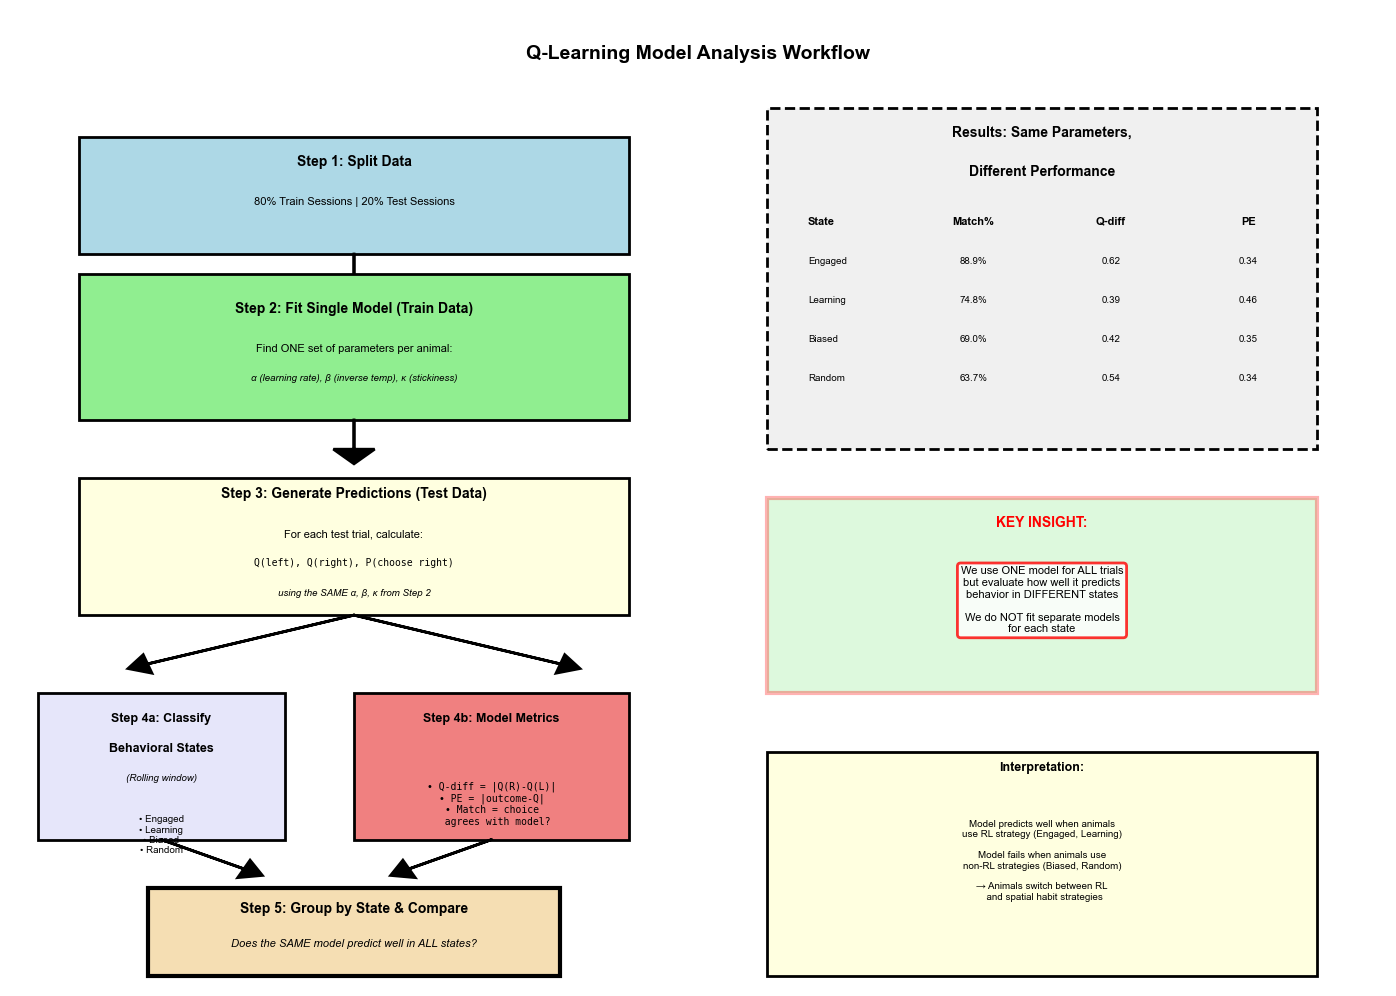


✓ Analysis workflow schematic saved!
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Analysis_Workflow_Schematic_2ABT.svg


In [382]:
# ============================================================================
# Visual Schematic of Q-Learning Analysis Workflow
# ============================================================================

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, 'Q-Learning Model Analysis Workflow', 
       fontsize=FONTSIZE+6, fontweight='bold', ha='center')

# ====================================================================
# Step 1: Data Split
# ====================================================================

ax.add_patch(plt.Rectangle((0.5, 7.5), 4, 1.2, fill=True,
            facecolor='lightblue', edgecolor='black', linewidth=2))
ax.text(2.5, 8.4, 'Step 1: Split Data', fontsize=FONTSIZE+2, ha='center', fontweight='bold')
ax.text(2.5, 8.0, '80% Train Sessions | 20% Test Sessions', fontsize=FONTSIZE, ha='center')

# Arrow down
ax.arrow(2.5, 7.5, 0, -0.3, head_width=0.3, head_length=0.15, fc='black', ec='black', linewidth=2)

# ====================================================================
# Step 2: Fit Model on TRAIN
# ====================================================================

ax.add_patch(plt.Rectangle((0.5, 5.8), 4, 1.5, fill=True,
            facecolor='lightgreen', edgecolor='black', linewidth=2))
ax.text(2.5, 6.9, 'Step 2: Fit Single Model (Train Data)', 
       fontsize=FONTSIZE+2, ha='center', fontweight='bold')
ax.text(2.5, 6.5, 'Find ONE set of parameters per animal:', fontsize=FONTSIZE, ha='center')
ax.text(2.5, 6.2, 'α (learning rate), β (inverse temp), κ (stickiness)', 
       fontsize=FONTSIZE-1, ha='center', style='italic')

# Arrow down
ax.arrow(2.5, 5.8, 0, -0.3, head_width=0.3, head_length=0.15, fc='black', ec='black', linewidth=2)

# ====================================================================
# Step 3: Run Model on TEST
# ====================================================================

ax.add_patch(plt.Rectangle((0.5, 3.8), 4, 1.4, fill=True,
            facecolor='lightyellow', edgecolor='black', linewidth=2))
ax.text(2.5, 5.0, 'Step 3: Generate Predictions (Test Data)', 
       fontsize=FONTSIZE+2, ha='center', fontweight='bold')
ax.text(2.5, 4.6, 'For each test trial, calculate:', fontsize=FONTSIZE, ha='center')
ax.text(2.5, 4.3, 'Q(left), Q(right), P(choose right)', 
       fontsize=FONTSIZE-1, ha='center', family='monospace')
ax.text(2.5, 4.0, 'using the SAME α, β, κ from Step 2', 
       fontsize=FONTSIZE-1, ha='center', style='italic')

# Arrow splits
ax.arrow(2.5, 3.8, -1.5, -0.5, head_width=0.2, head_length=0.15, fc='black', ec='black', linewidth=2)
ax.arrow(2.5, 3.8, 1.5, -0.5, head_width=0.2, head_length=0.15, fc='black', ec='black', linewidth=2)

# ====================================================================
# Step 4a: Classify States
# ====================================================================

ax.add_patch(plt.Rectangle((0.2, 1.5), 1.8, 1.5, fill=True,
            facecolor='lavender', edgecolor='black', linewidth=2))
ax.text(1.1, 2.7, 'Step 4a: Classify', fontsize=FONTSIZE+1, ha='center', fontweight='bold')
ax.text(1.1, 2.4, 'Behavioral States', fontsize=FONTSIZE+1, ha='center', fontweight='bold')
ax.text(1.1, 2.1, '(Rolling window)', fontsize=FONTSIZE-1, ha='center', style='italic')
ax.text(1.1, 1.75, '• Engaged\n• Learning\n• Biased\n• Random', 
       fontsize=FONTSIZE-1, ha='center', va='top')

# ====================================================================
# Step 4b: Calculate Metrics
# ====================================================================

ax.add_patch(plt.Rectangle((2.5, 1.5), 2, 1.5, fill=True,
            facecolor='lightcoral', edgecolor='black', linewidth=2))
ax.text(3.5, 2.7, 'Step 4b: Model Metrics', fontsize=FONTSIZE+1, ha='center', fontweight='bold')
ax.text(3.5, 2.1, '• Q-diff = |Q(R)-Q(L)|\n• PE = |outcome-Q|\n• Match = choice\n  agrees with model?', 
       fontsize=FONTSIZE-1, ha='center', va='top', family='monospace')

# Arrows combine
ax.arrow(1.1, 1.5, 0.6, -0.3, head_width=0.2, head_length=0.15, fc='black', ec='black', linewidth=2)
ax.arrow(3.5, 1.5, -0.6, -0.3, head_width=0.2, head_length=0.15, fc='black', ec='black', linewidth=2)

# ====================================================================
# Step 5: Compare Across States
# ====================================================================

ax.add_patch(plt.Rectangle((1.0, 0.1), 3, 0.9, fill=True,
            facecolor='wheat', edgecolor='black', linewidth=3))
ax.text(2.5, 0.75, 'Step 5: Group by State & Compare', 
       fontsize=FONTSIZE+2, ha='center', fontweight='bold')
ax.text(2.5, 0.4, 'Does the SAME model predict well in ALL states?', 
       fontsize=FONTSIZE, ha='center', style='italic')

# ====================================================================
# Right side: Example Results
# ====================================================================

ax.add_patch(plt.Rectangle((5.5, 5.5), 4, 3.5, fill=True,
            facecolor='#f0f0f0', edgecolor='black', linewidth=2, linestyle='--'))

ax.text(7.5, 8.7, 'Results: Same Parameters,', fontsize=FONTSIZE+2, ha='center', fontweight='bold')
ax.text(7.5, 8.3, 'Different Performance', fontsize=FONTSIZE+2, ha='center', fontweight='bold')

# Create mini table
table_data = [
    ['State', 'Match%', 'Q-diff', 'PE'],
    ['Engaged', '88.9%', '0.62', '0.34'],
    ['Learning', '74.8%', '0.39', '0.46'],
    ['Biased', '69.0%', '0.42', '0.35'],
    ['Random', '63.7%', '0.54', '0.34']
]

y_start = 7.8
for i, row in enumerate(table_data):
    y = y_start - i*0.4
    if i == 0:
        weight = 'bold'
        fontsize = FONTSIZE
    else:
        weight = 'normal'
        fontsize = FONTSIZE-1
    
    ax.text(5.8, y, row[0], fontsize=fontsize, fontweight=weight, ha='left')
    ax.text(7.0, y, row[1], fontsize=fontsize, fontweight=weight, ha='center')
    ax.text(8.0, y, row[2], fontsize=fontsize, fontweight=weight, ha='center')
    ax.text(9.0, y, row[3], fontsize=fontsize, fontweight=weight, ha='center')

# Add interpretation box
ax.add_patch(plt.Rectangle((5.5, 0.1), 4, 2.3, fill=True,
            facecolor='lightyellow', edgecolor='black', linewidth=2))

ax.text(7.5, 2.2, 'Interpretation:', fontsize=FONTSIZE+1, ha='center', fontweight='bold')

interp_text = """Model predicts well when animals
use RL strategy (Engaged, Learning)

Model fails when animals use
non-RL strategies (Biased, Random)

→ Animals switch between RL
  and spatial habit strategies"""

ax.text(7.5, 1.7, interp_text, fontsize=FONTSIZE-1, ha='center', va='top')

# Add key insight box
ax.add_patch(plt.Rectangle((5.5, 3.0), 4, 2.0, fill=True,
            facecolor='lightgreen', edgecolor='red', linewidth=3, alpha=0.3))

ax.text(7.5, 4.7, 'KEY INSIGHT:', fontsize=FONTSIZE+2, ha='center', fontweight='bold', color='red')

key_text = """We use ONE model for ALL trials
but evaluate how well it predicts
behavior in DIFFERENT states

We do NOT fit separate models
for each state"""

ax.text(7.5, 4.3, key_text, fontsize=FONTSIZE, ha='center', va='top', 
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='red', linewidth=2))

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Analysis_Workflow_Schematic_2ABT.svg'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Analysis workflow schematic saved!")
print(f"  {FIGURE_PATH}/Analysis_Workflow_Schematic_2ABT.svg")

Creating exemplar 2-ABT session figure...

Using exemplar session: 2022-04-25_20220425_Fiona_Reversal3.1
  Animal: Fiona
  Total trials: 497
  Blocks: [np.int64(5), np.int64(6)]


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/3579839963.py:226: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


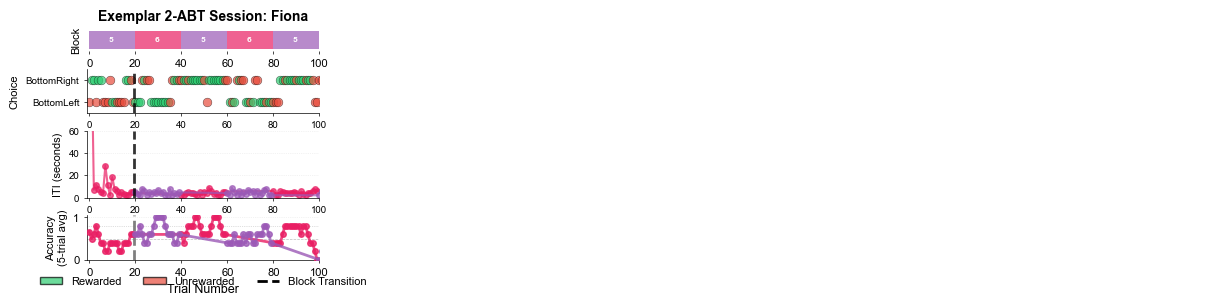


✓ Exemplar 2-ABT session figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Exemplar_Session_2ABT.svg


In [ ]:
# ============================================================================
# Exemplar 2-ABT Session
# ============================================================================

print("Creating exemplar 2-ABT session figure...\n")

# Define block colors
BLOCK_COLORS = ['#e91e63', '#9b59b6']  # Pink and purple for 2 blocks

# Pick a good example session
# Look for one with decent length and clear reversals
session_lengths = df.groupby('Session_ID').size()
good_sessions = session_lengths[session_lengths > 150].index

if len(good_sessions) > 0:
    example_session_id = good_sessions[0]
    
    print(f"Using exemplar session: {example_session_id}")
    
    # Get session data
    session_data = df[df['Session_ID'] == example_session_id].copy()
    session_data = session_data.sort_values('Trial').reset_index(drop=True)
    
    animal = session_data['Animal_Name'].iloc[0]
    
    # Recode Outcome from Reward if needed
    if session_data['Outcome'].isna().any():
        session_data['Outcome'] = session_data['Reward'].map({'Rewarded': 1, 'Unrewarded': 0})
    
    # Calculate ITI
    session_data['Prev_StartTime'] = session_data['AbsoluteTrialStartTime'].shift(1)
    session_data['ITI_calc'] = (session_data['AbsoluteTrialStartTime'] - session_data['Prev_StartTime']) / 1000
    
    # Assign continuous trial number
    session_data['continuous_trial'] = range(len(session_data))
    
    print(f"  Animal: {animal}")
    print(f"  Total trials: {len(session_data)}")
    print(f"  Blocks: {sorted(session_data['Block'].unique())}")
    
    # Create figure
    fig = plt.figure(figsize=(3, 3))
    gs = fig.add_gridspec(4, 1, hspace=0.4, height_ratios=[0.5, 1, 1.5, 1])
    

    # ====================================================================
    # Panel A: Block Structure (FIXED - show all alternations)
    # ====================================================================

    ax1 = fig.add_subplot(gs[0])

    # Group consecutive trials with same block number
    prev_block = None
    for idx, trial in session_data.iterrows():
        curr_block = trial['Block']
        trial_num = trial['continuous_trial']
        
        # Determine color based on block number
        block_color = BLOCK_COLORS[int(curr_block) % 2]
        
        # Draw a thin vertical bar for this trial
        ax1.barh(0, 1, left=trial_num, height=0.5,
                color=block_color, edgecolor='none', alpha=0.7)

    # Add block labels at transitions
    blocks = sorted(session_data['Block'].unique())
    for block in blocks:
        block_trials = session_data[session_data['Block'] == block]
        segments = []
        
        # Find contiguous segments of this block
        start = None
        for i, (idx, trial) in enumerate(block_trials.iterrows()):
            if start is None:
                start = trial['continuous_trial']
            # Check if next trial is contiguous
            if i < len(block_trials) - 1:
                next_trial = block_trials.iloc[i + 1]
                if next_trial['continuous_trial'] != trial['continuous_trial'] + 1:
                    # End of segment
                    end = trial['continuous_trial']
                    segments.append((start, end))
                    start = None
            else:
                # Last trial
                end = trial['continuous_trial']
                segments.append((start, end))
        
        # Label each segment
        for start, end in segments:
            mid = (start + end) / 2
            ax1.text(mid, 0, f'{block}', ha='center', va='center', 
                    fontsize=FONTSIZE-2, fontweight='bold', color='white')

    ax1.set_xlim(-1, 100)
    ax1.set_ylim(-0.3, 0.3)
    ax1.set_yticks([])
    ax1.set_ylabel('Block', fontsize=FONTSIZE)
    ax1.set_title(f'Exemplar 2-ABT Session: {animal}',
                fontsize=FONTSIZE+2, fontweight='bold')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    # ====================================================================
    # Panel B: Physical Choice (colored by outcome)
    # ====================================================================
    
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    
    # Get unique locations from PhysicalChoice
    unique_locs = sorted(session_data['PhysicalChoice'].dropna().unique())
    loc_to_y = {loc: i for i, loc in enumerate(unique_locs)}

    # Plot choices colored by outcome
    for idx, trial in session_data.iterrows():
        if pd.notna(trial['PhysicalChoice']):
            y_val = loc_to_y[trial['PhysicalChoice']]
            color = '#2ecc71' if trial['Outcome'] == 1 else '#e74c3c'
            ax2.scatter(trial['continuous_trial'], y_val, s=40, color=color,
                    alpha=0.7, edgecolor='black', linewidth=0.3)

    ax2.set_yticks(range(len(unique_locs)))
    ax2.set_yticklabels(unique_locs, fontsize=FONTSIZE-1)

    # # Plot choices colored by outcome
    # for idx, trial in session_data.iterrows():
    #     if pd.notna(trial['PhysicalChoice']):
    #         y_val = loc_to_y[trial['PhysicalChoice']]
    #         color = '#2ecc71' if trial['Outcome'] == 1 else '#e74c3c'
    #         ax2.scatter(trial['continuous_trial'], y_val, s=40, color=color,
    #                    alpha=0.7, edgecolor='black', linewidth=0.3)
    
    # Mark block transitions
    for idx in range(len(blocks)-1):
        curr_block = blocks[idx]
        next_block = blocks[idx+1]
        trans_trial = session_data[session_data['Block'] == next_block]['continuous_trial'].iloc[0]
        ax2.axvline(trans_trial - 0.5, color='black', linestyle='--',
                   linewidth=2, alpha=0.8, zorder=10)
    
    ax2.set_yticks(range(len(unique_locs)))
    # ax2.set_yticklabels(loc_names, fontsize=FONTSIZE-1)
    ax2.set_ylabel('Choice', fontsize=FONTSIZE)
    ax2.set_ylim(-0.5, len(unique_locs) - 0.5)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)
    
    # ====================================================================
    # Panel C: Inter-Trial Interval (colored by block)
    # ====================================================================
    
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    
    # Mark block transitions
    for idx in range(len(blocks)-1):
        curr_block = blocks[idx]
        next_block = blocks[idx+1]
        trans_trial = session_data[session_data['Block'] == next_block]['continuous_trial'].iloc[0]
        ax3.axvline(trans_trial - 0.5, color='black', linestyle='--',
                   linewidth=2, alpha=0.8, zorder=10)
    
    # Plot ITI colored by block
    for idx, block in enumerate(blocks):
        block_trials = session_data[session_data['Block'] == block]
        block_color = BLOCK_COLORS[idx % 2]
        
        ax3.plot(block_trials['continuous_trial'], block_trials['ITI_calc'],
                'o-', color=block_color, linewidth=1.5, markersize=4, alpha=0.7)
    
    ax3.set_ylabel('ITI (seconds)', fontsize=FONTSIZE)
    ax3.set_ylim(0, min(session_data['ITI_calc'].max() * 1.2, 60) if session_data['ITI_calc'].notna().any() else 30)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax3.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)
    
    # ====================================================================
    # Panel D: Rolling Accuracy (colored by block)
    # ====================================================================
    
    ax4 = fig.add_subplot(gs[3], sharex=ax1)
    
    # Calculate rolling average
    window = 5
    session_data['rolling_accuracy'] = session_data['Outcome'].rolling(
        window=window, min_periods=1, center=True).mean()
    
    # Mark block transitions
    for idx in range(len(blocks)-1):
        curr_block = blocks[idx]
        next_block = blocks[idx+1]
        trans_trial = session_data[session_data['Block'] == next_block]['continuous_trial'].iloc[0]
        ax4.axvline(trans_trial - 0.5, color='black', linestyle='--',
                   linewidth=2, alpha=0.5, zorder=1)
    
    # Plot rolling accuracy colored by block
    for idx, block in enumerate(blocks):
        block_trials = session_data[session_data['Block'] == block]
        block_color = BLOCK_COLORS[idx % 2]
        
        ax4.plot(block_trials['continuous_trial'], block_trials['rolling_accuracy'],
                'o-', color=block_color, linewidth=2, markersize=4, alpha=0.8, zorder=5)
    
    ax4.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
    ax4.axhline(0.8, color='gray', linestyle=':', linewidth=LINE_WIDTH, alpha=0.5)
    ax4.set_ylabel(f'Accuracy\n({window}-trial avg)', fontsize=FONTSIZE)
    ax4.set_xlabel('Trial Number', fontsize=FONTSIZE+1)
    ax4.set_ylim(0, 1.05)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax4.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Rewarded', alpha=0.7, edgecolor='black'),
        Patch(facecolor='#e74c3c', label='Unrewarded', alpha=0.7, edgecolor='black'),
        plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Block Transition')
    ]
    ax4.legend(handles=legend_elements, fontsize=FONTSIZE, frameon=False,
              loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_PATH, 'Exemplar_Session_2ABT.svg'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Exemplar 2-ABT session figure saved to:")
    print(f"  {FIGURE_PATH}/Exemplar_Session_2ABT.svg")
    
else:
    print("⚠️ No sessions found with >150 trials")

Creating exemplar 2-ABT session figure...

Using exemplar session: 2022-04-25_20220425_Fiona_Reversal3.1
  Animal: Fiona
  Total trials: 497
  Blocks: [np.int64(5), np.int64(6)]


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_32805/3579839963.py:226: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


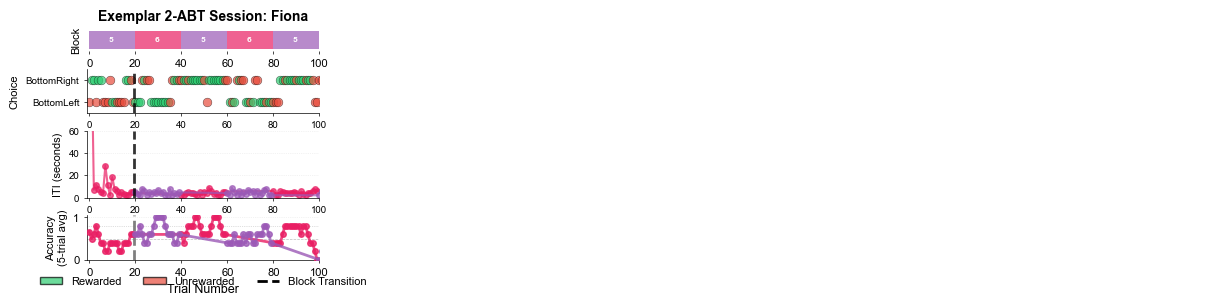


✓ Exemplar 2-ABT session figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Exemplar_Session_2ABT.svg


In [ ]:
# ============================================================================
# Exemplar 2-ABT Session
# ============================================================================

print("Creating exemplar 2-ABT session figure...\n")

# Define block colors
BLOCK_COLORS = ['#e91e63', '#9b59b6']  # Pink and purple for 2 blocks

# Pick a good example session
# Look for one with decent length and clear reversals
session_lengths = df.groupby('Session_ID').size()
good_sessions = session_lengths[session_lengths > 150].index

if len(good_sessions) > 0:
    example_session_id = good_sessions[0]
    
    print(f"Using exemplar session: {example_session_id}")
    
    # Get session data
    session_data = df[df['Session_ID'] == example_session_id].copy()
    session_data = session_data.sort_values('Trial').reset_index(drop=True)
    
    animal = session_data['Animal_Name'].iloc[0]
    
    # Recode Outcome from Reward if needed
    if session_data['Outcome'].isna().any():
        session_data['Outcome'] = session_data['Reward'].map({'Rewarded': 1, 'Unrewarded': 0})
    
    # Calculate ITI
    session_data['Prev_StartTime'] = session_data['AbsoluteTrialStartTime'].shift(1)
    session_data['ITI_calc'] = (session_data['AbsoluteTrialStartTime'] - session_data['Prev_StartTime']) / 1000
    
    # Assign continuous trial number
    session_data['continuous_trial'] = range(len(session_data))
    
    print(f"  Animal: {animal}")
    print(f"  Total trials: {len(session_data)}")
    print(f"  Blocks: {sorted(session_data['Block'].unique())}")
    
    # Create figure
    fig = plt.figure(figsize=(3, 3))
    gs = fig.add_gridspec(4, 1, hspace=0.4, height_ratios=[0.5, 1, 1.5, 1])
    

    # ====================================================================
    # Panel A: Block Structure (FIXED - show all alternations)
    # ====================================================================

    ax1 = fig.add_subplot(gs[0])

    # Group consecutive trials with same block number
    prev_block = None
    for idx, trial in session_data.iterrows():
        curr_block = trial['Block']
        trial_num = trial['continuous_trial']
        
        # Determine color based on block number
        block_color = BLOCK_COLORS[int(curr_block) % 2]
        
        # Draw a thin vertical bar for this trial
        ax1.barh(0, 1, left=trial_num, height=0.5,
                color=block_color, edgecolor='none', alpha=0.7)

    # Add block labels at transitions
    blocks = sorted(session_data['Block'].unique())
    for block in blocks:
        block_trials = session_data[session_data['Block'] == block]
        segments = []
        
        # Find contiguous segments of this block
        start = None
        for i, (idx, trial) in enumerate(block_trials.iterrows()):
            if start is None:
                start = trial['continuous_trial']
            # Check if next trial is contiguous
            if i < len(block_trials) - 1:
                next_trial = block_trials.iloc[i + 1]
                if next_trial['continuous_trial'] != trial['continuous_trial'] + 1:
                    # End of segment
                    end = trial['continuous_trial']
                    segments.append((start, end))
                    start = None
            else:
                # Last trial
                end = trial['continuous_trial']
                segments.append((start, end))
        
        # Label each segment
        for start, end in segments:
            mid = (start + end) / 2
            ax1.text(mid, 0, f'{block}', ha='center', va='center', 
                    fontsize=FONTSIZE-2, fontweight='bold', color='white')

    ax1.set_xlim(-1, 100)
    ax1.set_ylim(-0.3, 0.3)
    ax1.set_yticks([])
    ax1.set_ylabel('Block', fontsize=FONTSIZE)
    ax1.set_title(f'Exemplar 2-ABT Session: {animal}',
                fontsize=FONTSIZE+2, fontweight='bold')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    # ====================================================================
    # Panel B: Physical Choice (colored by outcome)
    # ====================================================================
    
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    
    # Get unique locations from PhysicalChoice
    unique_locs = sorted(session_data['PhysicalChoice'].dropna().unique())
    loc_to_y = {loc: i for i, loc in enumerate(unique_locs)}

    # Plot choices colored by outcome
    for idx, trial in session_data.iterrows():
        if pd.notna(trial['PhysicalChoice']):
            y_val = loc_to_y[trial['PhysicalChoice']]
            color = '#2ecc71' if trial['Outcome'] == 1 else '#e74c3c'
            ax2.scatter(trial['continuous_trial'], y_val, s=40, color=color,
                    alpha=0.7, edgecolor='black', linewidth=0.3)

    ax2.set_yticks(range(len(unique_locs)))
    ax2.set_yticklabels(unique_locs, fontsize=FONTSIZE-1)

    # # Plot choices colored by outcome
    # for idx, trial in session_data.iterrows():
    #     if pd.notna(trial['PhysicalChoice']):
    #         y_val = loc_to_y[trial['PhysicalChoice']]
    #         color = '#2ecc71' if trial['Outcome'] == 1 else '#e74c3c'
    #         ax2.scatter(trial['continuous_trial'], y_val, s=40, color=color,
    #                    alpha=0.7, edgecolor='black', linewidth=0.3)
    
    # Mark block transitions
    for idx in range(len(blocks)-1):
        curr_block = blocks[idx]
        next_block = blocks[idx+1]
        trans_trial = session_data[session_data['Block'] == next_block]['continuous_trial'].iloc[0]
        ax2.axvline(trans_trial - 0.5, color='black', linestyle='--',
                   linewidth=2, alpha=0.8, zorder=10)
    
    ax2.set_yticks(range(len(unique_locs)))
    # ax2.set_yticklabels(loc_names, fontsize=FONTSIZE-1)
    ax2.set_ylabel('Choice', fontsize=FONTSIZE)
    ax2.set_ylim(-0.5, len(unique_locs) - 0.5)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)
    
    # ====================================================================
    # Panel C: Inter-Trial Interval (colored by block)
    # ====================================================================
    
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    
    # Mark block transitions
    for idx in range(len(blocks)-1):
        curr_block = blocks[idx]
        next_block = blocks[idx+1]
        trans_trial = session_data[session_data['Block'] == next_block]['continuous_trial'].iloc[0]
        ax3.axvline(trans_trial - 0.5, color='black', linestyle='--',
                   linewidth=2, alpha=0.8, zorder=10)
    
    # Plot ITI colored by block
    for idx, block in enumerate(blocks):
        block_trials = session_data[session_data['Block'] == block]
        block_color = BLOCK_COLORS[idx % 2]
        
        ax3.plot(block_trials['continuous_trial'], block_trials['ITI_calc'],
                'o-', color=block_color, linewidth=1.5, markersize=4, alpha=0.7)
    
    ax3.set_ylabel('ITI (seconds)', fontsize=FONTSIZE)
    ax3.set_ylim(0, min(session_data['ITI_calc'].max() * 1.2, 60) if session_data['ITI_calc'].notna().any() else 30)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax3.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)
    
    # ====================================================================
    # Panel D: Rolling Accuracy (colored by block)
    # ====================================================================
    
    ax4 = fig.add_subplot(gs[3], sharex=ax1)
    
    # Calculate rolling average
    window = 5
    session_data['rolling_accuracy'] = session_data['Outcome'].rolling(
        window=window, min_periods=1, center=True).mean()
    
    # Mark block transitions
    for idx in range(len(blocks)-1):
        curr_block = blocks[idx]
        next_block = blocks[idx+1]
        trans_trial = session_data[session_data['Block'] == next_block]['continuous_trial'].iloc[0]
        ax4.axvline(trans_trial - 0.5, color='black', linestyle='--',
                   linewidth=2, alpha=0.5, zorder=1)
    
    # Plot rolling accuracy colored by block
    for idx, block in enumerate(blocks):
        block_trials = session_data[session_data['Block'] == block]
        block_color = BLOCK_COLORS[idx % 2]
        
        ax4.plot(block_trials['continuous_trial'], block_trials['rolling_accuracy'],
                'o-', color=block_color, linewidth=2, markersize=4, alpha=0.8, zorder=5)
    
    ax4.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
    ax4.axhline(0.8, color='gray', linestyle=':', linewidth=LINE_WIDTH, alpha=0.5)
    ax4.set_ylabel(f'Accuracy\n({window}-trial avg)', fontsize=FONTSIZE)
    ax4.set_xlabel('Trial Number', fontsize=FONTSIZE+1)
    ax4.set_ylim(0, 1.05)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax4.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Rewarded', alpha=0.7, edgecolor='black'),
        Patch(facecolor='#e74c3c', label='Unrewarded', alpha=0.7, edgecolor='black'),
        plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Block Transition')
    ]
    ax4.legend(handles=legend_elements, fontsize=FONTSIZE, frameon=False,
              loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_PATH, 'Exemplar_Session_2ABT.svg'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Exemplar 2-ABT session figure saved to:")
    print(f"  {FIGURE_PATH}/Exemplar_Session_2ABT.svg")
    
else:
    print("⚠️ No sessions found with >150 trials")